# Clinical v21: aggregate result audit

이 노트북은 집계 JSON만 포함한다. 세 seed는 독립 모델이고, AP 주지표는 소견 보정 전이다.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
R = json.loads('{"version": "clinical_condition_v21", "n": 4068, "years": {"2021": 1039, "2022": 1013, "2023": 1010, "2024": 1006}, "scope": "KNHANES 2021-2024, ages 19-39; exploratory follow-up on an already inspected cohort", "input": "Same 19 noninvasive raw columns, fit-only engineered 72-column encoding for all families", "test_views": ["clean", "missing20_0", "missing20_1", "missing20_2", "missing10", "missing30", "missing40", "body_missing", "behavior_missing", "HE_BMI_gaussian_fitSD10pct_all_observed", "HE_BMI_gaussian_fitSD25pct_all_observed", "HE_wc_gaussian_fitSD10pct_all_observed", "HE_wc_gaussian_fitSD25pct_all_observed"], "primary_metric": "raw_components_macro_ap", "primary_ids": ["enhanced_AP_EPF", "enhanced_AP_MLP", "LR_AP", "LR_BCE"], "tuning_candidate_fits": 640, "selection": {"1": {"selection_digest": "bcd7aa980edaec5b9850c3c25b8623f6407e4ee1e68a9fca93806922d9b9c145", "selections": {"plain": {"EPF": {"candidate_count": 32, "independent_training_per_policy": false, "AP": {"config": {"architecture": {"dimension": 12, "head_width": 32, "steps": 4}, "batch_size": 256, "dropout": 0.1, "family": "EPF", "field_weight_decay": 0.0001, "id": 3, "linear_lr_ratio": 1.0, "lr": 0.0003, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "off", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "plain"}, "trial_id": 3, "epoch": 27, "validation_AP": 0.46560648454126, "validation_BCE": 0.3039494222516329, "stored_parameters": 4491, "checkpoint_sha256": "42bc6de2d2a4fac1f2d5080959b7e3fd667c20293198a7263071b6afa733bccf"}, "BCE": {"config": {"architecture": {"dimension": 12, "head_width": 32, "steps": 4}, "batch_size": 256, "dropout": 0.1, "family": "EPF", "field_weight_decay": 0.01, "id": 15, "linear_lr_ratio": 1.0, "lr": 0.001, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "off", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "plain"}, "trial_id": 15, "epoch": 10, "validation_AP": 0.4552906741537521, "validation_BCE": 0.3033079534304813, "stored_parameters": 4491, "checkpoint_sha256": "ca62017394a8704dc322bf9cf3eb4857e70546a55102a848203accdf1d3fb821"}}, "MLP": {"candidate_count": 32, "independent_training_per_policy": false, "AP": {"config": {"architecture": {"head_width": 64, "hidden_layers": 1}, "batch_size": 512, "dropout": 0.1, "family": "MLP", "field_weight_decay": 1e-05, "id": 8, "linear_lr_ratio": 0.0, "lr": 0.002, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "off", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "plain"}, "trial_id": 8, "epoch": 12, "validation_AP": 0.4711116222051408, "validation_BCE": 0.3038491077710024, "stored_parameters": 5352, "checkpoint_sha256": "8b3aa0bbeb1eb41a55b9df42917ac853d5124e69120c75a84fcec5f972bdf972"}, "BCE": {"config": {"architecture": {"head_width": 128, "hidden_layers": 2}, "batch_size": 512, "dropout": 0.1, "family": "MLP", "field_weight_decay": 1e-05, "id": 27, "linear_lr_ratio": 1.0, "lr": 0.002, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "off", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "plain"}, "trial_id": 27, "epoch": 6, "validation_AP": 0.4604495935937198, "validation_BCE": 0.302419414553466, "stored_parameters": 27176, "checkpoint_sha256": "17e0b7c38bade0c92f1cbfea7d3190bc51a011b21f0dd4a0e70ca0345a5491aa"}}}, "enhanced": {"EPF": {"candidate_count": 32, "independent_training_per_policy": false, "AP": {"config": {"architecture": {"dimension": 12, "head_width": 32, "steps": 4}, "batch_size": 256, "dropout": 0.1, "family": "EPF", "field_weight_decay": 0.01, "id": 14, "linear_lr_ratio": 0.1, "lr": 0.001, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "field", "plasticity": true, "quartic": true, "residual_gate": "trainable", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "enhanced"}, "trial_id": 14, "epoch": 15, "validation_AP": 0.46173019587040304, "validation_BCE": 0.3045720831312957, "stored_parameters": 4719, "checkpoint_sha256": "5e4eed84ef1f368ad4f7c1399362e610955a138dc30cf689b0edde93cbc80fd9"}, "BCE": {"config": {"architecture": {"dimension": 12, "head_width": 32, "steps": 4}, "batch_size": 256, "dropout": 0.1, "family": "EPF", "field_weight_decay": 0.0001, "id": 9, "linear_lr_ratio": 0.0, "lr": 0.001, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "field", "plasticity": true, "quartic": true, "residual_gate": "trainable", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.001, "stage": "enhanced"}, "trial_id": 9, "epoch": 17, "validation_AP": 0.4497306163471397, "validation_BCE": 0.30392150743608437, "stored_parameters": 4719, "checkpoint_sha256": "43fbf0ff17226fecb0ab31b303565f9e64dfc8df1cf1c0427fd41eff076a38e6"}}, "MLP": {"candidate_count": 32, "independent_training_per_policy": false, "AP": {"config": {"architecture": {"head_width": 128, "hidden_layers": 2}, "batch_size": 512, "dropout": 0.1, "family": "MLP", "field_weight_decay": 1e-05, "id": 27, "linear_lr_ratio": 0.1, "lr": 0.002, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "trainable", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.001, "stage": "enhanced"}, "trial_id": 27, "epoch": 12, "validation_AP": 0.46553159538157013, "validation_BCE": 0.3040284249765694, "stored_parameters": 27180, "checkpoint_sha256": "45e21826d9e988a9a2b69c77b72b10d949776c4dbb2bf068976b7146a63ebaee"}, "BCE": {"config": {"architecture": {"head_width": 128, "hidden_layers": 2}, "batch_size": 512, "dropout": 0.1, "family": "MLP", "field_weight_decay": 0.001, "id": 22, "linear_lr_ratio": 0.1, "lr": 0.0005, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "trainable", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "enhanced"}, "trial_id": 22, "epoch": 41, "validation_AP": 0.4586920219266933, "validation_BCE": 0.3031567869678654, "stored_parameters": 27180, "checkpoint_sha256": "d3072e23382aab08244cfe5d3540aeb5b0a720495d5a46d9580353f7ada9133d"}}}}}, "2": {"selection_digest": "34469c7466c3eee842970577af502727961c085fba16fec25ba9a77be11133da", "selections": {"plain": {"EPF": {"candidate_count": 32, "independent_training_per_policy": false, "AP": {"config": {"architecture": {"dimension": 12, "head_width": 32, "steps": 4}, "batch_size": 256, "dropout": 0.1, "family": "EPF", "field_weight_decay": 0.0001, "id": 10, "linear_lr_ratio": 0.1, "lr": 0.001, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "off", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "plain"}, "trial_id": 10, "epoch": 16, "validation_AP": 0.39669357675962746, "validation_BCE": 0.3289200064579719, "stored_parameters": 4491, "checkpoint_sha256": "dc609007fcb5508ffdd8e2b0e6d64dcff6a6e66271e7f2b24b8db7aa567eb576"}, "BCE": {"config": {"architecture": {"dimension": 12, "head_width": 32, "steps": 4}, "batch_size": 256, "dropout": 0.1, "family": "EPF", "field_weight_decay": 0.0001, "id": 9, "linear_lr_ratio": 0.01, "lr": 0.001, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "off", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "plain"}, "trial_id": 9, "epoch": 4, "validation_AP": 0.37642466749110853, "validation_BCE": 0.3254027778217249, "stored_parameters": 4491, "checkpoint_sha256": "695498861d45a599a9dfff9d4c4a68b375b07875f28bfb1fa592f7e5a1e2e308"}}, "MLP": {"candidate_count": 32, "independent_training_per_policy": false, "AP": {"config": {"architecture": {"head_width": 128, "hidden_layers": 2}, "batch_size": 512, "dropout": 0.1, "family": "MLP", "field_weight_decay": 1e-05, "id": 27, "linear_lr_ratio": 1.0, "lr": 0.002, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "off", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "plain"}, "trial_id": 27, "epoch": 12, "validation_AP": 0.41196815064913467, "validation_BCE": 0.3362345255570474, "stored_parameters": 27176, "checkpoint_sha256": "6b5a03858461559e2e4fbcf5c3f3c0e3f138ab29a138634ff0ee997c48e89f54"}, "BCE": {"config": {"architecture": {"head_width": 128, "hidden_layers": 2}, "batch_size": 512, "dropout": 0.1, "family": "MLP", "field_weight_decay": 1e-05, "id": 27, "linear_lr_ratio": 1.0, "lr": 0.002, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "off", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "plain"}, "trial_id": 27, "epoch": 3, "validation_AP": 0.37011571076412986, "validation_BCE": 0.3273539908976408, "stored_parameters": 27176, "checkpoint_sha256": "8af85394fd27538dc4127782691c3d2c0c90f5df1db915e11dc708bd5dcc5f46"}}}, "enhanced": {"EPF": {"candidate_count": 32, "independent_training_per_policy": false, "AP": {"config": {"architecture": {"dimension": 12, "head_width": 32, "steps": 4}, "batch_size": 256, "dropout": 0.1, "family": "EPF", "field_weight_decay": 0.0001, "id": 11, "linear_lr_ratio": 0.1, "lr": 0.001, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "field", "plasticity": true, "quartic": true, "residual_gate": "trainable", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.001, "stage": "enhanced"}, "trial_id": 11, "epoch": 41, "validation_AP": 0.3983361989897893, "validation_BCE": 0.3322799009660709, "stored_parameters": 4719, "checkpoint_sha256": "853182ae3cb1ad52925559100faeb220951651d4ddd794bfab2588679945c908"}, "BCE": {"config": {"architecture": {"dimension": 24, "head_width": 96, "steps": 6}, "batch_size": 256, "dropout": 0.1, "family": "EPF", "field_weight_decay": 0.0001, "id": 16, "linear_lr_ratio": 0.0, "lr": 0.0003, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "field", "plasticity": true, "quartic": true, "residual_gate": "trainable", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "enhanced"}, "trial_id": 16, "epoch": 13, "validation_AP": 0.3742507945941209, "validation_BCE": 0.3250632190924842, "stored_parameters": 17679, "checkpoint_sha256": "fe98c7ff9f75be6e3d3d829e75d5721216c1e5dd7ff2a07273dbbf3958778b93"}}, "MLP": {"candidate_count": 32, "independent_training_per_policy": false, "AP": {"config": {"architecture": {"head_width": 128, "hidden_layers": 2}, "batch_size": 512, "dropout": 0.1, "family": "MLP", "field_weight_decay": 1e-05, "id": 26, "linear_lr_ratio": 0.1, "lr": 0.002, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "trainable", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "enhanced"}, "trial_id": 26, "epoch": 24, "validation_AP": 0.42648431960102784, "validation_BCE": 0.33929048928900923, "stored_parameters": 27180, "checkpoint_sha256": "c759d45652d3ce224ae8e292b2c2028c920055e0c54b85278b4bb946f77f6689"}, "BCE": {"config": {"architecture": {"head_width": 128, "hidden_layers": 2}, "batch_size": 512, "dropout": 0.1, "family": "MLP", "field_weight_decay": 0.001, "id": 31, "linear_lr_ratio": 0.1, "lr": 0.002, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "trainable", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.001, "stage": "enhanced"}, "trial_id": 31, "epoch": 12, "validation_AP": 0.3834446666561583, "validation_BCE": 0.3264109311946727, "stored_parameters": 27180, "checkpoint_sha256": "1fe5752102844057aac89684b7abc6af3c896d6c7d3cf3e448a95b448ac5b698"}}}}}, "3": {"selection_digest": "bc5f8862fe7c5c4197f406e9241ef662205f7a7afdb255191eabecd77589c7c9", "selections": {"plain": {"EPF": {"candidate_count": 32, "independent_training_per_policy": false, "AP": {"config": {"architecture": {"dimension": 12, "head_width": 32, "steps": 4}, "batch_size": 256, "dropout": 0.1, "family": "EPF", "field_weight_decay": 0.01, "id": 7, "linear_lr_ratio": 1.0, "lr": 0.0003, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "off", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "plain"}, "trial_id": 7, "epoch": 36, "validation_AP": 0.41435983125253517, "validation_BCE": 0.36766214094892935, "stored_parameters": 4491, "checkpoint_sha256": "70dc5775d523558efcf51ece2cfde089c86ea4dead0f4b5170287ff9fc917a07"}, "BCE": {"config": {"architecture": {"dimension": 12, "head_width": 32, "steps": 4}, "batch_size": 256, "dropout": 0.1, "family": "EPF", "field_weight_decay": 0.01, "id": 15, "linear_lr_ratio": 1.0, "lr": 0.001, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "off", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "plain"}, "trial_id": 15, "epoch": 5, "validation_AP": 0.4081942447792205, "validation_BCE": 0.36529559323242944, "stored_parameters": 4491, "checkpoint_sha256": "f0353cb47e293712d4a461c554a64a63f3e95b056b9efd318b610dd7f5f8fa88"}}, "MLP": {"candidate_count": 32, "independent_training_per_policy": false, "AP": {"config": {"architecture": {"head_width": 64, "hidden_layers": 1}, "batch_size": 512, "dropout": 0.1, "family": "MLP", "field_weight_decay": 0.001, "id": 15, "linear_lr_ratio": 1.0, "lr": 0.002, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "off", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "plain"}, "trial_id": 15, "epoch": 5, "validation_AP": 0.4100379626970304, "validation_BCE": 0.36820068540044465, "stored_parameters": 5352, "checkpoint_sha256": "d25e8a9469373daf05c53f1b1833c7c168d7e40dd31ec21772b9b3f60308f132"}, "BCE": {"config": {"architecture": {"head_width": 64, "hidden_layers": 1}, "batch_size": 512, "dropout": 0.1, "family": "MLP", "field_weight_decay": 0.001, "id": 15, "linear_lr_ratio": 1.0, "lr": 0.002, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "off", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "plain"}, "trial_id": 15, "epoch": 2, "validation_AP": 0.40813659229107, "validation_BCE": 0.3658493009093328, "stored_parameters": 5352, "checkpoint_sha256": "4792f063b40de339d6bfe4b3b882c6d7f09f8dba09f3390dafcc4f9ba5e46eb0"}}}, "enhanced": {"EPF": {"candidate_count": 32, "independent_training_per_policy": false, "AP": {"config": {"architecture": {"dimension": 24, "head_width": 96, "steps": 6}, "batch_size": 256, "dropout": 0.1, "family": "EPF", "field_weight_decay": 0.0001, "id": 18, "linear_lr_ratio": 0.1, "lr": 0.0003, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "field", "plasticity": true, "quartic": true, "residual_gate": "trainable", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "enhanced"}, "trial_id": 18, "epoch": 24, "validation_AP": 0.4099549858284539, "validation_BCE": 0.36719810952108894, "stored_parameters": 17679, "checkpoint_sha256": "e0d9823295e38e8889a5fe63800d2c1301469cf55e7334be9927c31223d03ff2"}, "BCE": {"config": {"architecture": {"dimension": 12, "head_width": 32, "steps": 4}, "batch_size": 256, "dropout": 0.1, "family": "EPF", "field_weight_decay": 0.0001, "id": 0, "linear_lr_ratio": 0.0, "lr": 0.0003, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "field", "plasticity": true, "quartic": true, "residual_gate": "trainable", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "enhanced"}, "trial_id": 0, "epoch": 0, "validation_AP": 0.40374590697747326, "validation_BCE": 0.3658157173007728, "stored_parameters": 4719, "checkpoint_sha256": "c2e97bce75f8902029a2d275fc4fa62fd3c20d19ab8ea0d6894e534933cfbef5"}}, "MLP": {"candidate_count": 32, "independent_training_per_policy": false, "AP": {"config": {"architecture": {"head_width": 128, "hidden_layers": 2}, "batch_size": 512, "dropout": 0.1, "family": "MLP", "field_weight_decay": 1e-05, "id": 26, "linear_lr_ratio": 0.1, "lr": 0.002, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "trainable", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "enhanced"}, "trial_id": 26, "epoch": 6, "validation_AP": 0.4089994491268783, "validation_BCE": 0.36668718138606504, "stored_parameters": 27180, "checkpoint_sha256": "5ad397e8b72b43eb82f5f65c637506c45d664887a75517ae372434abd1593c39"}, "BCE": {"config": {"architecture": {"head_width": 128, "hidden_layers": 2}, "batch_size": 512, "dropout": 0.1, "family": "MLP", "field_weight_decay": 0.001, "id": 29, "linear_lr_ratio": 0.0, "lr": 0.002, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "trainable", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.001, "stage": "enhanced"}, "trial_id": 29, "epoch": 2, "validation_AP": 0.4047193975165263, "validation_BCE": 0.36584984069907167, "stored_parameters": 27180, "checkpoint_sha256": "b93851fc9edf6d6c6a77c69d98b5c56ed502fb4dcdf47cce5fa301958a154a11"}}}}}, "4": {"selection_digest": "d69722c5bbc1ada603670932896a5d20d5c5173ee069437db996042be4286ee1", "selections": {"plain": {"EPF": {"candidate_count": 32, "independent_training_per_policy": false, "AP": {"config": {"architecture": {"dimension": 24, "head_width": 96, "steps": 6}, "batch_size": 256, "dropout": 0.1, "family": "EPF", "field_weight_decay": 0.01, "id": 22, "linear_lr_ratio": 0.1, "lr": 0.0003, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "off", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "plain"}, "trial_id": 22, "epoch": 11, "validation_AP": 0.41780507395738553, "validation_BCE": 0.31780205682957513, "stored_parameters": 17099, "checkpoint_sha256": "6a5fea7953fca9b23ba73984c868499809b02d374d9a302f30608980ad3da6d9"}, "BCE": {"config": {"architecture": {"dimension": 24, "head_width": 96, "steps": 6}, "batch_size": 256, "dropout": 0.1, "family": "EPF", "field_weight_decay": 0.0001, "id": 16, "linear_lr_ratio": 0.0, "lr": 0.0003, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "off", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "plain"}, "trial_id": 16, "epoch": 11, "validation_AP": 0.4167400511747704, "validation_BCE": 0.31775660621668367, "stored_parameters": 17099, "checkpoint_sha256": "888537476aafc10cf5d1274305af7a29eac5bedb297bea81db2371e682593953"}}, "MLP": {"candidate_count": 32, "independent_training_per_policy": false, "AP": {"config": {"architecture": {"head_width": 128, "hidden_layers": 2}, "batch_size": 512, "dropout": 0.1, "family": "MLP", "field_weight_decay": 1e-05, "id": 16, "linear_lr_ratio": 0.0, "lr": 0.0005, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "off", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "plain"}, "trial_id": 16, "epoch": 0, "validation_AP": 0.4180419317686833, "validation_BCE": 0.3179987390035631, "stored_parameters": 27176, "checkpoint_sha256": "b7fd8105d7a91bbeecce0f029093e0cf0771e9eed74dc2494725b2596945a312"}, "BCE": {"config": {"architecture": {"head_width": 128, "hidden_layers": 2}, "batch_size": 512, "dropout": 0.1, "family": "MLP", "field_weight_decay": 1e-05, "id": 19, "linear_lr_ratio": 1.0, "lr": 0.0005, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "off", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "plain"}, "trial_id": 19, "epoch": 1, "validation_AP": 0.41475452978250316, "validation_BCE": 0.3176847599217829, "stored_parameters": 27176, "checkpoint_sha256": "335c4cc141afef1cd95e8387cfa1c962c549371aed39a1184dc8ca50d9830799"}}}, "enhanced": {"EPF": {"candidate_count": 32, "independent_training_per_policy": false, "AP": {"config": {"architecture": {"dimension": 12, "head_width": 32, "steps": 4}, "batch_size": 256, "dropout": 0.1, "family": "EPF", "field_weight_decay": 0.0001, "id": 10, "linear_lr_ratio": 0.1, "lr": 0.001, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "field", "plasticity": true, "quartic": true, "residual_gate": "trainable", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "enhanced"}, "trial_id": 10, "epoch": 2, "validation_AP": 0.4123011824868645, "validation_BCE": 0.3184307542942442, "stored_parameters": 4719, "checkpoint_sha256": "a79336e1938a81f0b296d95bbdb38dac4a2b5c7820fb871726878e26b249af12"}, "BCE": {"config": {"architecture": {"dimension": 24, "head_width": 96, "steps": 6}, "batch_size": 256, "dropout": 0.1, "family": "EPF", "field_weight_decay": 0.01, "id": 29, "linear_lr_ratio": 0.0, "lr": 0.001, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "field", "plasticity": true, "quartic": true, "residual_gate": "trainable", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.001, "stage": "enhanced"}, "trial_id": 29, "epoch": 8, "validation_AP": 0.40726606362057916, "validation_BCE": 0.31804357169940495, "stored_parameters": 17679, "checkpoint_sha256": "f6a4bcd4f9e8b2abcfeb76fd03f3c990218317ffecb55b4984bdca654c826dfc"}}, "MLP": {"candidate_count": 32, "independent_training_per_policy": false, "AP": {"config": {"architecture": {"head_width": 64, "hidden_layers": 1}, "batch_size": 512, "dropout": 0.1, "family": "MLP", "field_weight_decay": 1e-05, "id": 0, "linear_lr_ratio": 0.0, "lr": 0.0005, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "trainable", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "enhanced"}, "trial_id": 0, "epoch": 0, "validation_AP": 0.41516596885593227, "validation_BCE": 0.3185044152610823, "stored_parameters": 5356, "checkpoint_sha256": "14808be3dbac6ac61e6ffad1035394f584f38fa83b715e0b3d340420d64b4b53"}, "BCE": {"config": {"architecture": {"head_width": 128, "hidden_layers": 2}, "batch_size": 512, "dropout": 0.1, "family": "MLP", "field_weight_decay": 1e-05, "id": 24, "linear_lr_ratio": 0.0, "lr": 0.002, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "trainable", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "enhanced"}, "trial_id": 24, "epoch": 4, "validation_AP": 0.4100625852890295, "validation_BCE": 0.3181579125953116, "stored_parameters": 27180, "checkpoint_sha256": "27ed8e74435d6c49aa43e51e00fa21914365d2e068f5ec346f1596f38c607fd6"}}}}}, "5": {"selection_digest": "b1510232bfc7c0d9b4f1106cba64da1b9bdd95995ebb6901753c9b1d0c6b2938", "selections": {"plain": {"EPF": {"candidate_count": 32, "independent_training_per_policy": false, "AP": {"config": {"architecture": {"dimension": 12, "head_width": 32, "steps": 4}, "batch_size": 256, "dropout": 0.1, "family": "EPF", "field_weight_decay": 0.01, "id": 4, "linear_lr_ratio": 0.0, "lr": 0.0003, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "off", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "plain"}, "trial_id": 4, "epoch": 18, "validation_AP": 0.3974296661786907, "validation_BCE": 0.32495063030281596, "stored_parameters": 4491, "checkpoint_sha256": "62521467c36b0d45ed63b147be53416901ccc7277c57ed66e493e49237b1a2d2"}, "BCE": {"config": {"architecture": {"dimension": 24, "head_width": 96, "steps": 6}, "batch_size": 256, "dropout": 0.1, "family": "EPF", "field_weight_decay": 0.0001, "id": 26, "linear_lr_ratio": 0.1, "lr": 0.001, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "off", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "plain"}, "trial_id": 26, "epoch": 5, "validation_AP": 0.3893393448859088, "validation_BCE": 0.324386411996748, "stored_parameters": 17099, "checkpoint_sha256": "835825160e2c0a6608e544be6a82503caa88e2c9519b6e90974590aac9954db7"}}, "MLP": {"candidate_count": 32, "independent_training_per_policy": false, "AP": {"config": {"architecture": {"head_width": 64, "hidden_layers": 1}, "batch_size": 512, "dropout": 0.1, "family": "MLP", "field_weight_decay": 1e-05, "id": 10, "linear_lr_ratio": 0.1, "lr": 0.002, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "off", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "plain"}, "trial_id": 10, "epoch": 11, "validation_AP": 0.4024896975097006, "validation_BCE": 0.3245732826965085, "stored_parameters": 5352, "checkpoint_sha256": "71b2659a2e287cfdc320d3c1ae57be7cf95c63bbd0ff2c66f089ccf256a02f43"}, "BCE": {"config": {"architecture": {"head_width": 64, "hidden_layers": 1}, "batch_size": 512, "dropout": 0.1, "family": "MLP", "field_weight_decay": 0.001, "id": 15, "linear_lr_ratio": 1.0, "lr": 0.002, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "off", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "plain"}, "trial_id": 15, "epoch": 9, "validation_AP": 0.3903684007127971, "validation_BCE": 0.3230024023285642, "stored_parameters": 5352, "checkpoint_sha256": "2da7f568d0668d38cab8ca07e93aaf511f2d5e5c526616bdec8900c37d2610de"}}}, "enhanced": {"EPF": {"candidate_count": 32, "independent_training_per_policy": false, "AP": {"config": {"architecture": {"dimension": 24, "head_width": 96, "steps": 6}, "batch_size": 256, "dropout": 0.1, "family": "EPF", "field_weight_decay": 0.01, "id": 28, "linear_lr_ratio": 0.0, "lr": 0.001, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "field", "plasticity": true, "quartic": true, "residual_gate": "trainable", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "enhanced"}, "trial_id": 28, "epoch": 6, "validation_AP": 0.3908270718401069, "validation_BCE": 0.3243787565222683, "stored_parameters": 17679, "checkpoint_sha256": "b128de17c7677a1624a78a8edb0b9d04833f7d80e58355c23ea4d4b6014af843"}, "BCE": {"config": {"architecture": {"dimension": 24, "head_width": 96, "steps": 6}, "batch_size": 256, "dropout": 0.1, "family": "EPF", "field_weight_decay": 0.01, "id": 28, "linear_lr_ratio": 0.0, "lr": 0.001, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "field", "plasticity": true, "quartic": true, "residual_gate": "trainable", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.0, "stage": "enhanced"}, "trial_id": 28, "epoch": 8, "validation_AP": 0.3879125342436489, "validation_BCE": 0.32353935464343203, "stored_parameters": 17679, "checkpoint_sha256": "5f48a880a7b823135187ed4f3f252071e5e076fc6d0f34bf0bad63fc2fdf77ab"}}, "MLP": {"candidate_count": 32, "independent_training_per_policy": false, "AP": {"config": {"architecture": {"head_width": 64, "hidden_layers": 1}, "batch_size": 512, "dropout": 0.1, "family": "MLP", "field_weight_decay": 1e-05, "id": 3, "linear_lr_ratio": 0.1, "lr": 0.0005, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "trainable", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.001, "stage": "enhanced"}, "trial_id": 3, "epoch": 75, "validation_AP": 0.395897680676185, "validation_BCE": 0.3232798225808332, "stored_parameters": 5356, "checkpoint_sha256": "392539c31ffa809134ea19e9214bbf9cc56f1555bb137310ee5c305076253274"}, "BCE": {"config": {"architecture": {"head_width": 64, "hidden_layers": 1}, "batch_size": 512, "dropout": 0.1, "family": "MLP", "field_weight_decay": 0.001, "id": 5, "linear_lr_ratio": 0.0, "lr": 0.0005, "model_options": {"event_mode": "hard", "initialization": "linear_anchor", "numeric_embedding": false, "plastic_readout": "none", "plasticity": true, "quartic": true, "residual_gate": "trainable", "use_linear_skip": true}, "probe": null, "residual_shrink": 0.001, "stage": "enhanced"}, "trial_id": 5, "epoch": 79, "validation_AP": 0.39306575772614216, "validation_BCE": 0.32269420427380946, "stored_parameters": 5356, "checkpoint_sha256": "3daa9f0a30e20da062e962af6d4258894f03b4160ef3277c9131c9b2283fcf1c"}}}}}}, "role_audit": {"1": {"fit": {"n": 2205, "positive_n_by_label": [282, 204, 364, 363], "years": {"2021": 583, "2022": 606, "2023": 508, "2024": 508}}, "validation": {"n": 327, "positive_n_by_label": [27, 25, 55, 48], "years": {"2021": 96, "2022": 76, "2023": 89, "2024": 66}}, "calibration": {"n": 362, "positive_n_by_label": [51, 36, 57, 50], "years": {"2021": 89, "2022": 120, "2023": 62, "2024": 91}}, "threshold": {"n": 338, "positive_n_by_label": [31, 29, 74, 49], "years": {"2021": 64, "2022": 42, "2023": 87, "2024": 145}}, "test": {"n": 836, "positive_n_by_label": [106, 82, 155, 137], "years": {"2021": 207, "2022": 169, "2023": 264, "2024": 196}}}, "2": {"fit": {"n": 2303, "positive_n_by_label": [277, 220, 399, 376], "years": {"2021": 557, "2022": 523, "2023": 633, "2024": 590}}, "validation": {"n": 323, "positive_n_by_label": [41, 26, 51, 44], "years": {"2021": 73, "2022": 106, "2023": 58, "2024": 86}}, "calibration": {"n": 300, "positive_n_by_label": [38, 37, 56, 49], "years": {"2021": 111, "2022": 71, "2023": 47, "2024": 71}}, "threshold": {"n": 355, "positive_n_by_label": [47, 33, 60, 57], "years": {"2021": 83, "2022": 81, "2023": 114, "2024": 77}}, "test": {"n": 787, "positive_n_by_label": [94, 60, 139, 121], "years": {"2021": 215, "2022": 232, "2023": 158, "2024": 182}}}, "3": {"fit": {"n": 2253, "positive_n_by_label": [288, 218, 405, 351], "years": {"2021": 596, "2022": 544, "2023": 569, "2024": 544}}, "validation": {"n": 342, "positive_n_by_label": [53, 31, 63, 64], "years": {"2021": 89, "2022": 102, "2023": 84, "2024": 67}}, "calibration": {"n": 306, "positive_n_by_label": [33, 29, 47, 58], "years": {"2021": 87, "2022": 65, "2023": 102, "2024": 52}}, "threshold": {"n": 301, "positive_n_by_label": [33, 29, 59, 53], "years": {"2021": 66, "2022": 75, "2023": 67, "2024": 93}}, "test": {"n": 866, "positive_n_by_label": [90, 69, 131, 121], "years": {"2021": 201, "2022": 227, "2023": 188, "2024": 250}}}, "4": {"fit": {"n": 2353, "positive_n_by_label": [287, 199, 387, 370], "years": {"2021": 563, "2022": 614, "2023": 605, "2024": 571}}, "validation": {"n": 314, "positive_n_by_label": [32, 29, 51, 45], "years": {"2021": 100, "2022": 96, "2023": 74, "2024": 44}}, "calibration": {"n": 275, "positive_n_by_label": [41, 34, 52, 44], "years": {"2021": 70, "2022": 65, "2023": 53, "2024": 87}}, "threshold": {"n": 322, "positive_n_by_label": [40, 29, 67, 50], "years": {"2021": 97, "2022": 57, "2023": 84, "2024": 84}}, "test": {"n": 804, "positive_n_by_label": [97, 85, 148, 138], "years": {"2021": 209, "2022": 181, "2023": 194, "2024": 220}}}, "5": {"fit": {"n": 2284, "positive_n_by_label": [284, 217, 408, 362], "years": {"2021": 590, "2022": 559, "2023": 555, "2024": 580}}, "validation": {"n": 308, "positive_n_by_label": [32, 23, 54, 51], "years": {"2021": 68, "2022": 63, "2023": 45, "2024": 132}}, "calibration": {"n": 351, "positive_n_by_label": [27, 32, 58, 53], "years": {"2021": 82, "2022": 107, "2023": 95, "2024": 67}}, "threshold": {"n": 350, "positive_n_by_label": [44, 24, 53, 51], "years": {"2021": 92, "2022": 80, "2023": 109, "2024": 69}}, "test": {"n": 775, "positive_n_by_label": [110, 80, 132, 130], "years": {"2021": 207, "2022": 204, "2023": 206, "2024": 158}}}}, "interpretation": {"seed_mean": "Mean of separately fitted seed metrics, not an ensemble", "selection": "AP and BCE checkpoints from the same training trajectory; the policies are not independent training objectives", "calibration": "A positive monotone component slope preserves within-fold ranking; a zero slope or numerical saturation can create ties. Different fold calibrators may change pooled cross-fold ranking, and gamma may change between-person q0 ranking", "screening": "90/95 percent are threshold-role targets, not necessarily achieved held-out sensitivity", "mechanism": "Diagnostic output RMS is not a causal share; ablation performance differences require retraining and remain conditional", "prior_exploration": "Same cohort previously inspected in v16-v20; no independent confirmation or new temporal validation"}, "contrasts": {"primary/EPF_vs_MLP": {"left": "enhanced_AP_EPF", "right": "enhanced_AP_MLP", "tier": "primary", "metric": "raw_components_macro_ap", "interpretation": null, "seed_paired_raw_macro_ap": [0.005782458919653233, 0.007924908311839118, 0.0013160968922281135], "seed_paired_mean": 0.0050078213745734885, "seed_paired_sd": 0.0033718162152882214, "seed_paired_range": [0.0013160968922281135, 0.007924908311839118], "seed_paired_signs": ["positive", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.005007821374573451, "ci95": [0.0005587394868321439, 0.009630739109098244], "valid_replicates": 2000}, "raw_components_brier": {"estimate": -0.00093528691531157, "ci95": [-0.0014242548556351164, -0.0004799624912971448], "valid_replicates": 2000}, "adjusted_any_ap": {"estimate": 0.002751249748470741, "ci95": [-0.0005111655882064275, 0.005812879320839562], "valid_replicates": 2000}, "adjusted_any_brier": {"estimate": -0.0009144325155201471, "ci95": [-0.001747085895835531, -0.00012639061015626304], "valid_replicates": 2000}}}, "primary/EPF_vs_LR_AP": {"left": "enhanced_AP_EPF", "right": "LR_AP", "tier": "primary", "metric": "raw_components_macro_ap", "interpretation": null, "seed_paired_raw_macro_ap": [-0.00037984580399774703, 0.004290938933020794, 0.00038490711357053176], "seed_paired_mean": 0.0014320000808645261, "seed_paired_sd": 0.0025052665080802774, "seed_paired_range": [-0.00037984580399774703, 0.004290938933020794], "seed_paired_signs": ["negative", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.0014320000808645261, "ci95": [-0.003952387512011135, 0.006336381100167024], "valid_replicates": 2000}, "raw_components_brier": {"estimate": -0.00034556974454783007, "ci95": [-0.0007569047281072658, 9.767845822891125e-05], "valid_replicates": 2000}, "adjusted_any_ap": {"estimate": 0.003109216760753375, "ci95": [-0.0011500561570561923, 0.007425970142555153], "valid_replicates": 2000}, "adjusted_any_brier": {"estimate": -0.0008193726303555582, "ci95": [-0.001693860876902524, 7.540341751830003e-05], "valid_replicates": 2000}}}, "primary/EPF_vs_LR_BCE": {"left": "enhanced_AP_EPF", "right": "LR_BCE", "tier": "primary", "metric": "raw_components_macro_ap", "interpretation": null, "seed_paired_raw_macro_ap": [-0.007443287943846799, -0.0027725032068282585, -0.00667853502627852], "seed_paired_mean": -0.005631442058984526, "seed_paired_sd": 0.0025052665080802774, "seed_paired_range": [-0.007443287943846799, -0.0027725032068282585], "seed_paired_signs": ["negative", "negative", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": -0.0056314420589845815, "ci95": [-0.010765187941524815, -0.0010133531775951459], "valid_replicates": 2000}, "raw_components_brier": {"estimate": 0.00040448712824914246, "ci95": [9.941469055079929e-05, 0.00073326169770311], "valid_replicates": 2000}, "adjusted_any_ap": {"estimate": -0.0008329911065274587, "ci95": [-0.0036831559075834602, 0.0023664381953654385], "valid_replicates": 2000}, "adjusted_any_brier": {"estimate": -0.0001433037492820921, "ci95": [-0.0007088079027019404, 0.0003970947631365068], "valid_replicates": 2000}}}, "secondary/enhanced_vs_plain_EPF": {"left": "enhanced_AP_EPF", "right": "plain_AP_EPF", "tier": "secondary", "metric": "raw_components_macro_ap", "interpretation": null, "seed_paired_raw_macro_ap": [-0.003462447083384057, 0.0003868954091711396, -0.0010129257157593385], "seed_paired_mean": -0.0013628257966574187, "seed_paired_sd": 0.0019483793152790157, "seed_paired_range": [-0.003462447083384057, 0.0003868954091711396], "seed_paired_signs": ["negative", "positive", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": -0.0013628257966574187, "ci95": [-0.003597408458685054, 0.0007368376039111032], "valid_replicates": 2000}, "raw_components_brier": {"estimate": 0.00015798302371998474, "ci95": [-1.2866299936960937e-06, 0.00033350214106565195], "valid_replicates": 2000}, "adjusted_any_ap": {"estimate": -0.0006907608995320169, "ci95": [-0.0024957237576113235, 0.0010638918574459079], "valid_replicates": 2000}, "adjusted_any_brier": {"estimate": 3.6329416744917964e-05, "ci95": [-0.0002652163881395886, 0.00035030191848901387], "valid_replicates": 2000}}}, "secondary/AP_vs_BCE_enhanced_EPF": {"left": "enhanced_AP_EPF", "right": "enhanced_BCE_EPF", "tier": "secondary", "metric": "raw_components_macro_ap", "interpretation": null, "seed_paired_raw_macro_ap": [-0.0075675693185955906, 0.0009038006816354249, -0.004051851019324038], "seed_paired_mean": -0.003571873218761401, "seed_paired_sd": 0.004256032358544542, "seed_paired_range": [-0.0075675693185955906, 0.0009038006816354249], "seed_paired_signs": ["negative", "positive", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": -0.003571873218761401, "ci95": [-0.006787152776564287, -0.00032273149525197884], "valid_replicates": 2000}, "raw_components_brier": {"estimate": 0.00031920262947648936, "ci95": [8.764689804340899e-05, 0.0005713731428322727], "valid_replicates": 2000}, "adjusted_any_ap": {"estimate": -0.0008110800925529293, "ci95": [-0.003267574080278346, 0.0016863633951869042], "valid_replicates": 2000}, "adjusted_any_brier": {"estimate": -2.0026486711788305e-05, "ci95": [-0.00046157290282609827, 0.00044541451315763584], "valid_replicates": 2000}}}, "secondary/same_AP_config_AP_vs_BCE_enhanced_EPF": {"left": "enhanced_AP_EPF", "right": "enhanced_APconfig_BCE_EPF", "tier": "secondary", "metric": "raw_components_macro_ap", "interpretation": null, "seed_paired_raw_macro_ap": [-0.005774945407145238, -0.00038859275213892763, -0.003781894515096307], "seed_paired_mean": -0.0033151442247934906, "seed_paired_sd": 0.0027233418085408786, "seed_paired_range": [-0.005774945407145238, -0.00038859275213892763], "seed_paired_signs": ["negative", "negative", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": -0.0033151442247935092, "ci95": [-0.006564278731058544, -0.0002504020404942124], "valid_replicates": 2000}, "raw_components_brier": {"estimate": 0.0003078774115170685, "ci95": [8.821683758701987e-05, 0.0005435518886692325], "valid_replicates": 2000}, "adjusted_any_ap": {"estimate": -0.0009048858549225436, "ci95": [-0.0031501268481380768, 0.0015117332377869517], "valid_replicates": 2000}, "adjusted_any_brier": {"estimate": 2.463977657701788e-05, "ci95": [-0.00037945773301729447, 0.00045050927010729334], "valid_replicates": 2000}}}, "secondary/same_BCE_config_AP_vs_BCE_enhanced_EPF": {"left": "enhanced_BCEconfig_AP_EPF", "right": "enhanced_BCE_EPF", "tier": "secondary", "metric": "raw_components_macro_ap", "interpretation": null, "seed_paired_raw_macro_ap": [-0.0012508713150132245, -9.894974630586528e-05, -0.0020492076467706344], "seed_paired_mean": -0.0011330095693632414, "seed_paired_sd": 0.0009804565328952928, "seed_paired_range": [-0.0020492076467706344, -9.894974630586528e-05], "seed_paired_signs": ["negative", "negative", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": -0.0011330095693633524, "ci95": [-0.0030253684908602254, 0.0007961079271703724], "valid_replicates": 2000}, "raw_components_brier": {"estimate": 7.68519400702744e-05, "ci95": [-6.311465954145431e-05, 0.00021785710729245306], "valid_replicates": 2000}, "adjusted_any_ap": {"estimate": -0.0005463522409631105, "ci95": [-0.0024743955097178832, 0.0013505302313294551], "valid_replicates": 2000}, "adjusted_any_brier": {"estimate": -7.286719262575292e-05, "ci95": [-0.00033943580913709664, 0.00019049998785256375], "valid_replicates": 2000}}}, "secondary/AP_vs_BCE_enhanced_MLP": {"left": "enhanced_AP_MLP", "right": "enhanced_BCE_MLP", "tier": "secondary", "metric": "raw_components_macro_ap", "interpretation": null, "seed_paired_raw_macro_ap": [-0.01195422158161874, -0.009496492267088374, -0.007450375167356138], "seed_paired_mean": -0.00963369633868775, "seed_paired_sd": 0.002255055841606613, "seed_paired_range": [-0.01195422158161874, -0.007450375167356138], "seed_paired_signs": ["negative", "negative", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": -0.009633696338687658, "ci95": [-0.014236054439073569, -0.005254261904514363], "valid_replicates": 2000}, "raw_components_brier": {"estimate": 0.0011580389514883466, "ci95": [0.0007536093504212811, 0.0016123686671191163], "valid_replicates": 2000}, "adjusted_any_ap": {"estimate": -0.0025872963336304178, "ci95": [-0.005324228530834088, 0.00036547607000425906], "valid_replicates": 2000}, "adjusted_any_brier": {"estimate": 0.0005149318240484091, "ci95": [-0.00013043220447975234, 0.0011782023105871681], "valid_replicates": 2000}}}, "secondary/same_AP_config_AP_vs_BCE_enhanced_MLP": {"left": "enhanced_AP_MLP", "right": "enhanced_APconfig_BCE_MLP", "tier": "secondary", "metric": "raw_components_macro_ap", "interpretation": null, "seed_paired_raw_macro_ap": [-0.012045521763877187, -0.00951877224860187, -0.006830230425960926], "seed_paired_mean": -0.009464841479479994, "seed_paired_sd": 0.002608063904648361, "seed_paired_range": [-0.012045521763877187, -0.006830230425960926], "seed_paired_signs": ["negative", "negative", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": -0.009464841479480013, "ci95": [-0.013965818529760437, -0.005044271201102486], "valid_replicates": 2000}, "raw_components_brier": {"estimate": 0.0011500545321037614, "ci95": [0.0007405086146194805, 0.0016071228889510457], "valid_replicates": 2000}, "adjusted_any_ap": {"estimate": -0.0024983346506965987, "ci95": [-0.005185660231587055, 0.00031943793080653346], "valid_replicates": 2000}, "adjusted_any_brier": {"estimate": 0.0005294656716684498, "ci95": [-9.793837539230492e-05, 0.001185503814522358], "valid_replicates": 2000}}}, "secondary/same_BCE_config_AP_vs_BCE_enhanced_MLP": {"left": "enhanced_BCEconfig_AP_MLP", "right": "enhanced_BCE_MLP", "tier": "secondary", "metric": "raw_components_macro_ap", "interpretation": null, "seed_paired_raw_macro_ap": [-0.011561495853653292, -0.0091571971568159, -0.00918565550235445], "seed_paired_mean": -0.009968116170941213, "seed_paired_sd": 0.0013799806445444914, "seed_paired_range": [-0.011561495853653292, -0.0091571971568159], "seed_paired_signs": ["negative", "negative", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": -0.009968116170941232, "ci95": [-0.015044907126435777, -0.005201861220064176], "valid_replicates": 2000}, "raw_components_brier": {"estimate": 0.001214572088853727, "ci95": [0.0007812367418677836, 0.0017108857974400986], "valid_replicates": 2000}, "adjusted_any_ap": {"estimate": -0.002102263362746326, "ci95": [-0.004900666676946316, 0.0007539142626367], "valid_replicates": 2000}, "adjusted_any_brier": {"estimate": 0.0004309925613594223, "ci95": [-0.00024371417957698774, 0.0011536777911999706], "valid_replicates": 2000}}}, "secondary/AP_vs_BCE_plain_EPF": {"left": "plain_AP_EPF", "right": "plain_BCE_EPF", "tier": "secondary", "metric": "raw_components_macro_ap", "interpretation": null, "seed_paired_raw_macro_ap": [-0.004903939515459643, 0.001969812054149478, -0.004244346114348152], "seed_paired_mean": -0.002392824525219439, "seed_paired_sd": 0.003792520837969549, "seed_paired_range": [-0.004903939515459643, 0.001969812054149478], "seed_paired_signs": ["negative", "positive", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": -0.002392824525219328, "ci95": [-0.004834553439146005, -0.0001148283653514354], "valid_replicates": 2000}, "raw_components_brier": {"estimate": 0.0001685688100060423, "ci95": [-1.2303407613968543e-06, 0.00036253365486562793], "valid_replicates": 2000}, "adjusted_any_ap": {"estimate": -0.00016482820457797143, "ci95": [-0.0019130711470256938, 0.001568156497486572], "valid_replicates": 2000}, "adjusted_any_brier": {"estimate": -1.1734593456186326e-05, "ci95": [-0.00031393386165155313, 0.0003154754786107341], "valid_replicates": 2000}}}, "secondary/same_AP_config_AP_vs_BCE_plain_EPF": {"left": "plain_AP_EPF", "right": "plain_APconfig_BCE_EPF", "tier": "secondary", "metric": "raw_components_macro_ap", "interpretation": null, "seed_paired_raw_macro_ap": [-0.005938434609064569, 0.0004055879740202384, -0.003991867492801338], "seed_paired_mean": -0.0031749047092818894, "seed_paired_sd": 0.003249957965253457, "seed_paired_range": [-0.005938434609064569, 0.0004055879740202384], "seed_paired_signs": ["negative", "positive", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": -0.003174904709281945, "ci95": [-0.005433317231753146, -0.0008844281494230094], "valid_replicates": 2000}, "raw_components_brier": {"estimate": 0.00021635621256600734, "ci95": [5.140644707751253e-05, 0.00038654600933855985], "valid_replicates": 2000}, "adjusted_any_ap": {"estimate": -0.0004417474460033377, "ci95": [-0.0019854754431902987, 0.0011445856327630254], "valid_replicates": 2000}, "adjusted_any_brier": {"estimate": -7.526446704522738e-05, "ci95": [-0.0003322625088451943, 0.00018878192987862582], "valid_replicates": 2000}}}, "secondary/same_BCE_config_AP_vs_BCE_plain_EPF": {"left": "plain_BCEconfig_AP_EPF", "right": "plain_BCE_EPF", "tier": "secondary", "metric": "raw_components_macro_ap", "interpretation": null, "seed_paired_raw_macro_ap": [-0.00679106915304617, 0.0014416094354057774, -0.005111018865297523], "seed_paired_mean": -0.0034868261943126386, "seed_paired_sd": 0.004350028799852887, "seed_paired_range": [-0.00679106915304617, 0.0014416094354057774], "seed_paired_signs": ["negative", "positive", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": -0.003486826194312509, "ci95": [-0.005910716980734058, -0.0009758091381539826], "valid_replicates": 2000}, "raw_components_brier": {"estimate": 0.000208481058619564, "ci95": [1.6380991633190013e-05, 0.0004130731681574306], "valid_replicates": 2000}, "adjusted_any_ap": {"estimate": -0.0011003796512371045, "ci95": [-0.003186102815073638, 0.0010013700116092582], "valid_replicates": 2000}, "adjusted_any_brier": {"estimate": 3.449881138853361e-05, "ci95": [-0.00027023316295350723, 0.00034401637034507307], "valid_replicates": 2000}}}, "secondary/AP_vs_BCE_plain_MLP": {"left": "plain_AP_MLP", "right": "plain_BCE_MLP", "tier": "secondary", "metric": "raw_components_macro_ap", "interpretation": null, "seed_paired_raw_macro_ap": [-0.011767376297736665, -0.016559959040121253, -0.007457443362844318], "seed_paired_mean": -0.011928259566900745, "seed_paired_sd": 0.0045533899990546365, "seed_paired_range": [-0.016559959040121253, -0.007457443362844318], "seed_paired_signs": ["negative", "negative", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": -0.011928259566900967, "ci95": [-0.017708178588247882, -0.006525674005725137], "valid_replicates": 2000}, "raw_components_brier": {"estimate": 0.0014062339698347887, "ci95": [0.0009047589401740278, 0.0019134481046492252], "valid_replicates": 2000}, "adjusted_any_ap": {"estimate": -0.0036528143255609713, "ci95": [-0.006958136445297042, -0.0002171623737600073], "valid_replicates": 2000}, "adjusted_any_brier": {"estimate": 0.0009609876191475908, "ci95": [0.0001847334263023276, 0.0017826397251527507], "valid_replicates": 2000}}}, "secondary/same_AP_config_AP_vs_BCE_plain_MLP": {"left": "plain_AP_MLP", "right": "plain_APconfig_BCE_MLP", "tier": "secondary", "metric": "raw_components_macro_ap", "interpretation": null, "seed_paired_raw_macro_ap": [-0.011966095927197495, -0.017453808110666102, -0.007799644165005726], "seed_paired_mean": -0.012406516067623108, "seed_paired_sd": 0.004842127404095392, "seed_paired_range": [-0.017453808110666102, -0.007799644165005726], "seed_paired_signs": ["negative", "negative", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": -0.012406516067623219, "ci95": [-0.01798103409279503, -0.007088330131283079], "valid_replicates": 2000}, "raw_components_brier": {"estimate": 0.0014467259398385779, "ci95": [0.0009601256460658271, 0.0019456040693223136], "valid_replicates": 2000}, "adjusted_any_ap": {"estimate": -0.003913001037403219, "ci95": [-0.007180315159127287, -0.0005205616612074393], "valid_replicates": 2000}, "adjusted_any_brier": {"estimate": 0.0010196855628594181, "ci95": [0.00026607260675653234, 0.0018608733656901204], "valid_replicates": 2000}}}, "secondary/same_BCE_config_AP_vs_BCE_plain_MLP": {"left": "plain_BCEconfig_AP_MLP", "right": "plain_BCE_MLP", "tier": "secondary", "metric": "raw_components_macro_ap", "interpretation": null, "seed_paired_raw_macro_ap": [-0.01263139475886288, -0.016055026260554495, -0.008589588219932554], "seed_paired_mean": -0.012425336413116642, "seed_paired_sd": 0.003736982247212321, "seed_paired_range": [-0.016055026260554495, -0.008589588219932554], "seed_paired_signs": ["negative", "negative", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": -0.012425336413116828, "ci95": [-0.01810132479700135, -0.007129413348471272], "valid_replicates": 2000}, "raw_components_brier": {"estimate": 0.0014566887721181032, "ci95": [0.0009584275438355702, 0.001954212059435606], "valid_replicates": 2000}, "adjusted_any_ap": {"estimate": -0.0038491880926566635, "ci95": [-0.00726220319862107, -0.0004950552890127223], "valid_replicates": 2000}, "adjusted_any_brier": {"estimate": 0.0009798058776194218, "ci95": [0.00015511878275385402, 0.0018184833042752778], "valid_replicates": 2000}}}, "exploratory_probe/probe_EPF_capacity_control": {"left": "enhanced_AP_EPF", "right": "probe_EPF_capacity_control", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [-0.0028979726628530766, 0.00013438049760206017, 0.00021492593877275867], "seed_paired_mean": -0.0008495554088260859, "seed_paired_sd": 0.0017744384539819782, "seed_paired_range": [-0.0028979726628530766, 0.00021492593877275867], "seed_paired_signs": ["negative", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": -0.0008495554088261414, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": 9.378095795604946e-05, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": -0.0008250152131422661, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": 0.00010402747500845577, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_EPF_capacity_control_BCE": {"left": "enhanced_APconfig_BCE_EPF", "right": "probe_EPF_capacity_control_BCE", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [-0.00018382172815484266, 0.004813598866418134, -3.497361307552849e-05], "seed_paired_mean": 0.0015316011750625875, "seed_paired_sd": 0.0028432675876336397, "seed_paired_range": [-0.00018382172815484266, 0.004813598866418134], "seed_paired_signs": ["negative", "positive", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": 0.001531601175062569, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -8.491792038999024e-05, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 0.0007868810086723022, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -7.685782453187295e-05, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_EPF_field_only": {"left": "enhanced_AP_EPF", "right": "probe_EPF_field_only", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Independent field-only control, not one-factor ablation", "seed_paired_raw_macro_ap": [0.007811218685208898, 0.018654425401193553, 0.022453513249194645], "seed_paired_mean": 0.016306385778532367, "seed_paired_sd": 0.007598300143902044, "seed_paired_range": [0.007811218685208898, 0.022453513249194645], "seed_paired_signs": ["positive", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.016306385778532162, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -0.0021494088527361788, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 0.008562162694544906, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -0.004838386534494726, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_EPF_field_only_BCE": {"left": "enhanced_APconfig_BCE_EPF", "right": "probe_EPF_field_only_BCE", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Independent field-only control, not one-factor ablation", "seed_paired_raw_macro_ap": [0.006923429812966508, 0.014056344039174773, 0.0036434923442470457], "seed_paired_mean": 0.00820775539879611, "seed_paired_sd": 0.005323907330424922, "seed_paired_range": [0.0036434923442470457, 0.014056344039174773], "seed_paired_signs": ["positive", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.00820775539879609, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -0.0009408093335834117, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 0.0034480464371273722, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -0.0008920591212725759, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_EPF_native_prior": {"left": "enhanced_AP_EPF", "right": "probe_EPF_native_prior", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [0.0061391524590488356, 0.016272962851522244, 0.007231981409392851], "seed_paired_mean": 0.00988136557332131, "seed_paired_sd": 0.0055621898208984815, "seed_paired_range": [0.0061391524590488356, 0.016272962851522244], "seed_paired_signs": ["positive", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.009881365573321366, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -0.0010748153106885927, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 0.006330950275759917, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -0.0014787378166039866, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_EPF_native_prior_BCE": {"left": "enhanced_APconfig_BCE_EPF", "right": "probe_EPF_native_prior_BCE", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [0.007761394638270802, 0.012005852402466433, 0.00686027536278494], "seed_paired_mean": 0.008875840801174059, "seed_paired_sd": 0.002747859795428377, "seed_paired_range": [0.00686027536278494, 0.012005852402466433], "seed_paired_signs": ["positive", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.008875840801174095, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -0.0009938487684157948, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 0.00386024020823883, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -0.00041003422621543884, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_EPF_native_zero": {"left": "enhanced_AP_EPF", "right": "probe_EPF_native_zero", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [0.01026778564450681, 0.011173093716387639, 0.014204526751796787], "seed_paired_mean": 0.011881802037563746, "seed_paired_sd": 0.0020618397730752186, "seed_paired_range": [0.01026778564450681, 0.014204526751796787], "seed_paired_signs": ["positive", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.011881802037563671, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -0.0013465194516612128, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 0.010436212911693055, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -0.003054481536914261, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_EPF_native_zero_BCE": {"left": "enhanced_APconfig_BCE_EPF", "right": "probe_EPF_native_zero_BCE", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [0.014143893642575456, 0.014008509528278978, 0.021407915701720015], "seed_paired_mean": 0.01652010629085815, "seed_paired_sd": 0.004233508337334807, "seed_paired_range": [0.014008509528278978, 0.021407915701720015], "seed_paired_signs": ["positive", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.016520106290858094, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -0.0015190471750060885, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 0.009130967224881825, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -0.002520422654839566, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "preplanned_probe/probe_EPF_no_Preadout": {"left": "enhanced_AP_EPF", "right": "probe_EPF_no_Preadout", "tier": "preplanned_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [-0.0005923268987974017, 1.2954390681607642e-05, 0.0001748778930369399], "seed_paired_mean": -0.00013483153835961806, "seed_paired_sd": 0.0004043900453402971, "seed_paired_range": [-0.0005923268987974017, 0.0001748778930369399], "seed_paired_signs": ["negative", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": -0.00013483153835963657, "ci95": [-0.00038443601666346416, 0.00010461686096615421], "valid_replicates": 2000}, "raw_components_brier": {"estimate": 2.1339056708702397e-05, "ci95": [4.443104831311148e-06, 4.007011407164761e-05], "valid_replicates": 2000}, "adjusted_any_ap": {"estimate": -1.1417879721919988e-05, "ci95": [-0.00022485397307746847, 0.00022530206729669264], "valid_replicates": 2000}, "adjusted_any_brier": {"estimate": -5.90544132175741e-06, "ci95": [-3.1116553607917624e-05, 1.8524599129537958e-05], "valid_replicates": 2000}}}, "exploratory_probe/probe_EPF_no_Preadout_BCE": {"left": "enhanced_APconfig_BCE_EPF", "right": "probe_EPF_no_Preadout_BCE", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [-9.755496882585257e-05, -2.8390613437956347e-06, 3.208097884466188e-05], "seed_paired_mean": -2.2771017108328778e-05, "seed_paired_sd": 6.707705924947492e-05, "seed_paired_range": [-9.755496882585257e-05, 3.208097884466188e-05], "seed_paired_signs": ["negative", "negative", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": -2.277101710829177e-05, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": 1.2546610830832527e-06, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 6.8587225137139995e-06, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -2.3389895472680777e-06, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_EPF_no_gate": {"left": "enhanced_AP_EPF", "right": "probe_EPF_no_gate", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [-9.969454368258246e-05, 0.0010423187175421234, 0.004093769370908773], "seed_paired_mean": 0.0016787978482561046, "seed_paired_sd": 0.0021679746685837414, "seed_paired_range": [-9.969454368258246e-05, 0.004093769370908773], "seed_paired_signs": ["negative", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.0016787978482560861, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -0.00011157717763009278, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": -4.4400102517827555e-05, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -0.0001025005161368886, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_EPF_no_gate_BCE": {"left": "enhanced_APconfig_BCE_EPF", "right": "probe_EPF_no_gate_BCE", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [0.00047063786994933077, 0.004351112324894435, 0.0002711015883226642], "seed_paired_mean": 0.0016976172610554767, "seed_paired_sd": 0.002300158847185263, "seed_paired_range": [0.0002711015883226642, 0.004351112324894435], "seed_paired_signs": ["positive", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.0016976172610554952, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -0.0001295874385648238, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 0.0006613848926393384, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -6.203462754197919e-05, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "preplanned_probe/probe_EPF_no_plasticity": {"left": "enhanced_AP_EPF", "right": "probe_EPF_no_plasticity", "tier": "preplanned_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [4.402275779824549e-05, 1.0261495812013965e-05, -0.00013943830679041813], "seed_paired_mean": -2.8384684393386223e-05, "seed_paired_sd": 9.764546066434757e-05, "seed_paired_range": [-0.00013943830679041813, 4.402275779824549e-05], "seed_paired_signs": ["positive", "positive", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": -2.8384684393423232e-05, "ci95": [-0.00038819267647796223, 0.0003558642687391792], "valid_replicates": 2000}, "raw_components_brier": {"estimate": 5.388966216587909e-06, "ci95": [-1.670505659875539e-05, 2.8579574092069793e-05], "valid_replicates": 2000}, "adjusted_any_ap": {"estimate": 0.00011712225328952552, "ci95": [-0.00013663380327014473, 0.000390561597756919], "valid_replicates": 2000}, "adjusted_any_brier": {"estimate": -1.8873240039268824e-05, "ci95": [-5.710619893204566e-05, 1.7711173342253153e-05], "valid_replicates": 2000}}}, "exploratory_probe/probe_EPF_no_plasticity_BCE": {"left": "enhanced_APconfig_BCE_EPF", "right": "probe_EPF_no_plasticity_BCE", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [0.0001042069843809057, 0.00486218476852307, -1.0652022155388519e-05], "seed_paired_mean": 0.0016519132435828625, "seed_paired_sd": 0.0027807697847407418, "seed_paired_range": [-1.0652022155388519e-05, 0.00486218476852307], "seed_paired_signs": ["positive", "positive", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": 0.0016519132435828254, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -7.625291652846311e-05, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 0.0007641114354501877, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -7.997051758762419e-05, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "preplanned_probe/probe_EPF_no_quartic": {"left": "enhanced_AP_EPF", "right": "probe_EPF_no_quartic", "tier": "preplanned_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [-0.0005297286554198921, 5.309381216622722e-05, 0.0017290918515841525], "seed_paired_mean": 0.00041748566944349585, "seed_paired_sd": 0.0011726694291030978, "seed_paired_range": [-0.0005297286554198921, 0.0017290918515841525], "seed_paired_signs": ["negative", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.00041748566944355137, "ci95": [-0.0005438606795468495, 0.0012788825518954825], "valid_replicates": 2000}, "raw_components_brier": {"estimate": -5.196995487008471e-05, "ci95": [-0.0001261943490036211, 1.5657866044544915e-05], "valid_replicates": 2000}, "adjusted_any_ap": {"estimate": 0.00011702732047691455, "ci95": [-0.0005583731972666317, 0.0008463601490469262], "valid_replicates": 2000}, "adjusted_any_brier": {"estimate": -4.9328562653411234e-05, "ci95": [-0.00020452994615030446, 9.095902825694413e-05], "valid_replicates": 2000}}}, "exploratory_probe/probe_EPF_no_quartic_BCE": {"left": "enhanced_APconfig_BCE_EPF", "right": "probe_EPF_no_quartic_BCE", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [-2.821525102908451e-05, 3.98683946802314e-05, -3.938383598184325e-05], "seed_paired_mean": -9.24356411023212e-06, "seed_paired_sd": 4.289723411408814e-05, "seed_paired_range": [-3.938383598184325e-05, 3.98683946802314e-05], "seed_paired_signs": ["negative", "positive", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": -9.243564110250624e-06, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": 1.4267384283242479e-05, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 3.891404682709876e-05, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -2.3122696948152388e-05, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_EPF_no_shrink": {"left": "enhanced_AP_EPF", "right": "probe_EPF_no_shrink", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Fold-specific; see interpretation_by_fold", "seed_paired_raw_macro_ap": [0.00021944797968259655, 9.201917227003031e-05, 8.79366549833005e-05], "seed_paired_mean": 0.0001331346023119758, "seed_paired_sd": 7.477744360227556e-05, "seed_paired_range": [8.79366549833005e-05, 0.00021944797968259655], "seed_paired_signs": ["positive", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.00013313460231190177, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -1.0705780803643705e-05, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 2.786169469026767e-05, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -5.352954774801022e-06, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_EPF_no_shrink_BCE": {"left": "enhanced_APconfig_BCE_EPF", "right": "probe_EPF_no_shrink_BCE", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Fold-specific; see interpretation_by_fold", "seed_paired_raw_macro_ap": [2.806856976461658e-05, 5.709947614285227e-06, 1.3751796659855486e-05], "seed_paired_mean": 1.5843438012919098e-05, "seed_paired_sd": 1.1325114514993051e-05, "seed_paired_range": [5.709947614285227e-06, 2.806856976461658e-05], "seed_paired_signs": ["positive", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 1.5843438012919098e-05, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -1.1578229112685356e-06, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 9.578650543851097e-06, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": 1.6773966705074805e-06, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_EPF_numeric_embedding": {"left": "enhanced_AP_EPF", "right": "probe_EPF_numeric_embedding", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [-7.414161566310362e-05, 0.00024109021556495414, 0.0009057334706678577], "seed_paired_mean": 0.0003575606901899027, "seed_paired_sd": 0.0005002127795224227, "seed_paired_range": [-7.414161566310362e-05, 0.0009057334706678577], "seed_paired_signs": ["negative", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.00035756069018993974, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -2.572195069745764e-05, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 0.00020259592851457064, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -3.523455654569352e-05, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_EPF_numeric_embedding_BCE": {"left": "enhanced_APconfig_BCE_EPF", "right": "probe_EPF_numeric_embedding_BCE", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [0.0004989272885736473, 0.0002378720321236094, 0.0001436222819187205], "seed_paired_mean": 0.00029347386753865906, "seed_paired_sd": 0.00018406272032830574, "seed_paired_range": [0.0001436222819187205, 0.0004989272885736473], "seed_paired_signs": ["positive", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.00029347386753852955, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -2.01891505884344e-05, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 0.00011522411053943582, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -1.765255690605594e-05, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_EPF_smooth_event": {"left": "enhanced_AP_EPF", "right": "probe_EPF_smooth_event", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [-0.0013774537257708053, -0.0007627224380373221, -0.0028349076738142798], "seed_paired_mean": -0.0016583612792074691, "seed_paired_sd": 0.0010642695631400583, "seed_paired_range": [-0.0028349076738142798, -0.0007627224380373221], "seed_paired_signs": ["negative", "negative", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": -0.001658361279207432, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": 0.00018766791062985178, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 0.00015206240577769758, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -4.54709917382945e-05, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_EPF_smooth_event_BCE": {"left": "enhanced_APconfig_BCE_EPF", "right": "probe_EPF_smooth_event_BCE", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [-0.0005165815666878792, -0.0007715595383373519, 1.0025065451446658e-05], "seed_paired_mean": -0.00042603867985792815, "seed_paired_sd": 0.00039858140195767955, "seed_paired_range": [-0.0007715595383373519, 1.0025065451446658e-05], "seed_paired_signs": ["negative", "negative", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": -0.00042603867985779864, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": 3.564099831573908e-05, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": -9.627771143239094e-05, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": 1.3213879683643404e-05, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_MLP_native_prior": {"left": "enhanced_AP_MLP", "right": "probe_MLP_native_prior", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [0.008467045791480277, 0.009460411591714513, 0.00878520630731039], "seed_paired_mean": 0.008904221230168393, "seed_paired_sd": 0.0005072645435726051, "seed_paired_range": [0.008467045791480277, 0.009460411591714513], "seed_paired_signs": ["positive", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.00890422123016843, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -0.0008365193898122597, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 0.007240584719720444, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -0.0019266233580001457, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_MLP_native_prior_BCE": {"left": "enhanced_APconfig_BCE_MLP", "right": "probe_MLP_native_prior_BCE", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [0.008668776709768178, 0.008206325693874805, 0.007319448611598223], "seed_paired_mean": 0.008064850338413735, "seed_paired_sd": 0.000685698939972831, "seed_paired_range": [0.007319448611598223, 0.008668776709768178], "seed_paired_signs": ["positive", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.008064850338413754, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -0.0011048199719637664, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 0.010040555255335759, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -0.0031018803019987884, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_MLP_native_zero": {"left": "enhanced_AP_MLP", "right": "probe_MLP_native_zero", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [0.009452611731491256, 0.015622067604404322, 0.02776047063600423], "seed_paired_mean": 0.017611716657299936, "seed_paired_sd": 0.009314690114660556, "seed_paired_range": [0.009452611731491256, 0.02776047063600423], "seed_paired_signs": ["positive", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.01761171665729988, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -0.0020182931660056996, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 0.008622546739972203, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -0.004453414586852639, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_MLP_native_zero_BCE": {"left": "enhanced_APconfig_BCE_MLP", "right": "probe_MLP_native_zero_BCE", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [0.012944884883922203, 0.015101490231106851, 0.014084488715660759], "seed_paired_mean": 0.014043621276896604, "seed_paired_sd": 0.0010788833424146054, "seed_paired_range": [0.012944884883922203, 0.015101490231106851], "seed_paired_signs": ["positive", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.014043621276896623, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -0.001871098134552246, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 0.006683079682035853, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -0.003933831089378309, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_MLP_no_gate": {"left": "enhanced_AP_MLP", "right": "probe_MLP_no_gate", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [-0.002350589121490998, 0.0035540357060404038, 0.0020814337400200666], "seed_paired_mean": 0.0010949601081898241, "seed_paired_sd": 0.0030734339521449492, "seed_paired_range": [-0.002350589121490998, 0.0035540357060404038], "seed_paired_signs": ["negative", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.0010949601081898797, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -0.00015663203996796327, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 0.0006545020802810608, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -0.0002934183666685186, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_MLP_no_gate_BCE": {"left": "enhanced_APconfig_BCE_MLP", "right": "probe_MLP_no_gate_BCE", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [-0.002680928058063081, -0.0008666625933720362, -0.0019303526941366056], "seed_paired_mean": -0.0018259811151905743, "seed_paired_sd": 0.0009116248482579987, "seed_paired_range": [-0.002680928058063081, -0.0008666625933720362], "seed_paired_signs": ["negative", "negative", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": -0.0018259811151906113, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": 0.00017199073422392852, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": -0.0008508368144717338, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": 0.00022827446591913714, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_MLP_no_shrink": {"left": "enhanced_AP_MLP", "right": "probe_MLP_no_shrink", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Fold-specific; see interpretation_by_fold", "seed_paired_raw_macro_ap": [-2.6693943799727116e-05, 1.0273671523508554e-05, -4.1084126591539594e-05], "seed_paired_mean": -1.9168132955919386e-05, "seed_paired_sd": 2.6493097751095306e-05, "seed_paired_range": [-4.1084126591539594e-05, 1.0273671523508554e-05], "seed_paired_signs": ["negative", "positive", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": -1.9168132955882378e-05, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -1.1182854124658359e-07, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 2.1152821871650573e-05, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -3.2451399904209755e-06, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_MLP_no_shrink_BCE": {"left": "enhanced_APconfig_BCE_MLP", "right": "probe_MLP_no_shrink_BCE", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Fold-specific; see interpretation_by_fold", "seed_paired_raw_macro_ap": [4.3362798524682056e-05, -2.886591630024693e-05, -2.2783717363139555e-05], "seed_paired_mean": -2.762278379568143e-06, "seed_paired_sd": 4.0061082431018806e-05, "seed_paired_range": [-2.886591630024693e-05, 4.3362798524682056e-05], "seed_paired_signs": ["positive", "negative", "negative"], "metrics": {"raw_components_macro_ap": {"estimate": -2.7622783794756245e-06, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -6.140359548462149e-07, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 1.60953410056619e-05, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -3.0885990183748824e-06, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_MLP_numeric_embedding": {"left": "enhanced_AP_MLP", "right": "probe_MLP_numeric_embedding", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [0.00118086448058502, 0.0007457316778004541, 0.003330284288912466], "seed_paired_mean": 0.0017522934824326468, "seed_paired_sd": 0.0013837905831504676, "seed_paired_range": [0.0007457316778004541, 0.003330284288912466], "seed_paired_signs": ["positive", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.0017522934824326653, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -0.0001944354732463377, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 0.00041676715548422116, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -6.266365921811512e-05, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}, "exploratory_probe/probe_MLP_numeric_embedding_BCE": {"left": "enhanced_APconfig_BCE_MLP", "right": "probe_MLP_numeric_embedding_BCE", "tier": "exploratory_probe", "metric": "raw_components_macro_ap", "interpretation": "Frozen enhanced_AP configuration, conditional effect", "seed_paired_raw_macro_ap": [0.0004504757099146883, 0.0001124596661270516, 0.00040528785578214377], "seed_paired_mean": 0.0003227410772746279, "seed_paired_sd": 0.00018350528451774366, "seed_paired_range": [0.0001124596661270516, 0.0004504757099146883], "seed_paired_signs": ["positive", "positive", "positive"], "metrics": {"raw_components_macro_ap": {"estimate": 0.0003227410772747019, "ci95": null, "valid_replicates": 0}, "raw_components_brier": {"estimate": -1.4795546108919977e-05, "ci95": null, "valid_replicates": 0}, "adjusted_any_ap": {"estimate": 0.0003574992779131758, "ci95": null, "valid_replicates": 0}, "adjusted_any_brier": {"estimate": -2.0710353575925655e-05, "ci95": null, "valid_replicates": 0}}, "interval_status": "Exploratory point estimate only; no PSU interval calculated"}}, "uncertainty": {"replicates_requested": 2000, "survey": {"full_frame_psus": 768, "domain_psus": 699, "strata": 108, "singleton_strata": 0, "method": "n_h-1 draws with replacement; multiplicity*n_h/(n_h-1); full survey PSUs; no FPC"}, "scope": "Paired full-frame PSU intervals conditional on fixed OOF predictions", "limits": "No full retraining or selection uncertainty, multiplicity adjustment, independent cohort, or new temporal validation", "seed_variation": "Three paired seed differences are descriptive, not a confidence interval", "bootstrap_contrasts": ["primary/EPF_vs_MLP", "primary/EPF_vs_LR_AP", "primary/EPF_vs_LR_BCE", "secondary/enhanced_vs_plain_EPF", "secondary/AP_vs_BCE_enhanced_EPF", "secondary/same_AP_config_AP_vs_BCE_enhanced_EPF", "secondary/same_BCE_config_AP_vs_BCE_enhanced_EPF", "secondary/AP_vs_BCE_enhanced_MLP", "secondary/same_AP_config_AP_vs_BCE_enhanced_MLP", "secondary/same_BCE_config_AP_vs_BCE_enhanced_MLP", "secondary/AP_vs_BCE_plain_EPF", "secondary/same_AP_config_AP_vs_BCE_plain_EPF", "secondary/same_BCE_config_AP_vs_BCE_plain_EPF", "secondary/AP_vs_BCE_plain_MLP", "secondary/same_AP_config_AP_vs_BCE_plain_MLP", "secondary/same_BCE_config_AP_vs_BCE_plain_MLP", "preplanned_probe/probe_EPF_no_Preadout", "preplanned_probe/probe_EPF_no_plasticity", "preplanned_probe/probe_EPF_no_quartic"], "screening_clean": {"enhanced_AP_EPF": {"raw_any_precal/0.9": {"sensitivity": {"estimate": 0.8676297129056888, "ci95": [0.8486122272550969, 0.8855034685825096], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.6352094276555226, "ci95": [0.616607925075548, 0.6533149233399527], "valid_replicates": 2000}}, "raw_any_precal/0.95": {"sensitivity": {"estimate": 0.9259801927519785, "ci95": [0.9099847882277723, 0.9408035298556797], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.7553240878868376, "ci95": [0.7387356021448321, 0.7717633391147749], "valid_replicates": 2000}}, "raw_any/0.9": {"sensitivity": {"estimate": 0.8692972082010533, "ci95": [0.8499306233872057, 0.887715330306849], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.6429533269632761, "ci95": [0.6250958097598824, 0.6607390084796868], "valid_replicates": 2000}}, "raw_any/0.95": {"sensitivity": {"estimate": 0.927465731231308, "ci95": [0.9118509368065845, 0.941960138507036], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.7577442672383468, "ci95": [0.7410569430598075, 0.7741500445689888], "valid_replicates": 2000}}, "adjusted_any/0.9": {"sensitivity": {"estimate": 0.8662638388800472, "ci95": [0.8459608749476126, 0.8850941740948355], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.63784017188265, "ci95": [0.6200046161355556, 0.6555779807939356], "valid_replicates": 2000}}, "adjusted_any/0.95": {"sensitivity": {"estimate": 0.9250744384487177, "ci95": [0.9091383145646167, 0.9399435294245722], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.755865737730732, "ci95": [0.7391051535290393, 0.772161456611824], "valid_replicates": 2000}}}, "enhanced_AP_MLP": {"raw_any_precal/0.9": {"sensitivity": {"estimate": 0.8665344215030769, "ci95": [0.8473450794777546, 0.8850166688612566], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.6361811811421708, "ci95": [0.6176125703212061, 0.6546631405979026], "valid_replicates": 2000}}, "raw_any_precal/0.95": {"sensitivity": {"estimate": 0.9220240817660764, "ci95": [0.9054300948151744, 0.9369426516729245], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.751614641313827, "ci95": [0.734727731350276, 0.7679678491777837], "valid_replicates": 2000}}, "raw_any/0.9": {"sensitivity": {"estimate": 0.8663293583602836, "ci95": [0.8467408302130547, 0.8839634563589422], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.6417940075410034, "ci95": [0.6232920552522218, 0.6591997674166555], "valid_replicates": 2000}}, "raw_any/0.95": {"sensitivity": {"estimate": 0.9276307984628621, "ci95": [0.911712497607669, 0.9418977125975305], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.756429620840476, "ci95": [0.7399012694336139, 0.7724033051279325], "valid_replicates": 2000}}, "adjusted_any/0.9": {"sensitivity": {"estimate": 0.8672779573914177, "ci95": [0.8477927287293093, 0.8857621576319346], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.6410382945113703, "ci95": [0.6227422334984405, 0.6586988836814663], "valid_replicates": 2000}}, "adjusted_any/0.95": {"sensitivity": {"estimate": 0.9258844321559523, "ci95": [0.9099981256000107, 0.9401512490681238], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.7558337413510644, "ci95": [0.7396076588306019, 0.772014666244159], "valid_replicates": 2000}}}, "LR_AP": {"raw_any_precal/0.9": {"sensitivity": {"estimate": 0.8599208405847217, "ci95": [0.8397541992684496, 0.8790461878626711], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.6260481098034534, "ci95": [0.6079301091247865, 0.6440410278005945], "valid_replicates": 2000}}, "raw_any_precal/0.95": {"sensitivity": {"estimate": 0.9278643386420139, "ci95": [0.9121298022585085, 0.9420868445720252], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.7574528975603251, "ci95": [0.739766286525553, 0.7743856663130857], "valid_replicates": 2000}}, "raw_any/0.9": {"sensitivity": {"estimate": 0.8699140584853562, "ci95": [0.8501594225889741, 0.888247427626521], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.6471345884671548, "ci95": [0.6293559514880508, 0.6646187675745867], "valid_replicates": 2000}}, "raw_any/0.95": {"sensitivity": {"estimate": 0.925334193602596, "ci95": [0.9094663664086016, 0.9400840788501], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.7557000270758513, "ci95": [0.7384164787765053, 0.7723736368710643], "valid_replicates": 2000}}, "adjusted_any/0.9": {"sensitivity": {"estimate": 0.8637379914661772, "ci95": [0.8438853989615298, 0.8825472972312166], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.635182865205284, "ci95": [0.6172527446930719, 0.6533699990808808], "valid_replicates": 2000}}, "adjusted_any/0.95": {"sensitivity": {"estimate": 0.924223697746823, "ci95": [0.9077737570965919, 0.9390365062117024], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.7559872482737425, "ci95": [0.738170395105428, 0.7730090814962868], "valid_replicates": 2000}}}, "LR_BCE": {"raw_any_precal/0.9": {"sensitivity": {"estimate": 0.8669661830953469, "ci95": [0.8469938765234774, 0.8853643124929748], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.636882493762705, "ci95": [0.618393677146252, 0.6554082728313637], "valid_replicates": 2000}}, "raw_any_precal/0.95": {"sensitivity": {"estimate": 0.9265636385071652, "ci95": [0.9107634882906871, 0.9408287285173559], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.7581908607895196, "ci95": [0.7412358797512955, 0.7747569610957951], "valid_replicates": 2000}}, "raw_any/0.9": {"sensitivity": {"estimate": 0.8707927399510592, "ci95": [0.8501206187591945, 0.8893659890651988], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.6507017207703615, "ci95": [0.6332439469926304, 0.6688177133531094], "valid_replicates": 2000}}, "raw_any/0.95": {"sensitivity": {"estimate": 0.9244040090109813, "ci95": [0.9087230392379817, 0.9392953848006906], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.7545811084673973, "ci95": [0.7377637911767969, 0.7713011939249059], "valid_replicates": 2000}}, "adjusted_any/0.9": {"sensitivity": {"estimate": 0.866109393804677, "ci95": [0.8460636326038089, 0.8847289100060738], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.642694621407695, "ci95": [0.6247198432598241, 0.6603263504808399], "valid_replicates": 2000}}, "adjusted_any/0.95": {"sensitivity": {"estimate": 0.9219135058823524, "ci95": [0.9056294741335846, 0.9371680573815357], "valid_replicates": 2000}, "referral_rate": {"estimate": 0.753874891542353, "ci95": [0.7367377035659011, 0.7709114414080112], "valid_replicates": 2000}}}}}, "source_manifest_sha256": "84466baf7d4d47d44497a9be73f4d25cf8879e7e42604fd38c35f2495b765495", "analysis_manifest_sha256": "fe463ac1c7317e20755403e40ab995947d15dcf1cf93a2573acf8fb46945f8dd", "source_file_count": 31, "analysis_file_count": 6, "training_freeze_sha256": "442b8cb96622a382f624b6dc4e2aea5f09bacb18b890a5ec45bcf8e2579c9833", "training_digest": "bf13357a13c00658b442d734cd2ba55c707606e76c83a72c85ba6c639c4e7ead", "evaluation_index_sha256": "1114ab9317d88cf740690f021436c0f806bbb1bb64ddcd43d213031f35642d43", "evaluation_verification_sha256": "2bde817b7ed58f102254b4d0eaa5257f5c97f28811f6bf0422831ecbc7a645f0", "full_forward_sources_sha256": "8d0792ad1a5ffbcd58676951a432e6c112572f148a360fe10b3c2072f208a7fc", "full_forward_verification_sha256": "c7168dac68a275a064a2967b77872be50f0b4941594e60e51ada062da74d1597", "full_forward_verification_status": "passed", "models": {"enhanced_AP_EPF": {"family": "EPF", "stage": "enhanced", "policy": "AP", "config_policy": "AP", "group": "primary", "seedless": false, "interpretation": null, "exact_reused_alias_folds": 0, "performance": {"clean": {"raw_components": {"macro_ap": 0.3626841354984025, "macro_brier": 0.10583983564924465, "macro_nll": 0.3451483840382065, "per_label": [{"ap": 0.3750500689815106, "auc": 0.8037216013964462, "brier": 0.09544767027584004, "nll": 0.3147659029508824, "observed_rate": 0.12882212778159, "predicted_mean": 0.1285595619561761, "mean_risk_gap": -0.00026256582541390555, "absolute_mean_risk_gap": 0.000761240818586297}, {"ap": 0.26582841893339354, "auc": 0.7558100089681412, "brier": 0.08287306095899061, "nll": 0.2882101292820978, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09990781244701548, "mean_risk_gap": -0.0011237067806437416, "absolute_mean_risk_gap": 0.0011237067806437416}, {"ap": 0.4387736895155416, "auc": 0.8016324623584045, "brier": 0.12493278094316174, "nll": 0.39145740420066594, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18205411090094495, "mean_risk_gap": -0.004509938748416283, "absolute_mean_risk_gap": 0.004509938748416283}, {"ap": 0.37108436456316424, "auc": 0.7637791709071983, "brier": 0.12010583041898622, "nll": 0.38616009971918, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1606305497218061, "mean_risk_gap": -0.003213901208564416, "absolute_mean_risk_gap": 0.003213901208564416}]}, "calibrated_components": {"macro_ap": 0.3615212014185642, "macro_brier": 0.10622456372116958, "macro_nll": 0.34669152248952567, "per_label": [{"ap": 0.3640895876133527, "auc": 0.7962007050600407, "brier": 0.09634468474252149, "nll": 0.3185201591950728, "observed_rate": 0.12882212778159, "predicted_mean": 0.12961061433878684, "mean_risk_gap": 0.0007884865571968583, "absolute_mean_risk_gap": 0.0007884865571968583}, {"ap": 0.26533097628242636, "auc": 0.7558571925786269, "brier": 0.0838788088643573, "nll": 0.2908802167009741, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12056687732639475, "mean_risk_gap": 0.019535358098735495, "absolute_mean_risk_gap": 0.019535358098735495}, {"ap": 0.44091538379858375, "auc": 0.8045849723211805, "brier": 0.12458332818840939, "nll": 0.3899041042095559, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18928264451778198, "mean_risk_gap": 0.002718594868420724, "absolute_mean_risk_gap": 0.002718594868420724}, {"ap": 0.37574885797989394, "auc": 0.7602006359606106, "brier": 0.12009143308939023, "nll": 0.3874616098524999, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16802059728982613, "mean_risk_gap": 0.004176146359455624, "absolute_mean_risk_gap": 0.004176146359455624}]}, "raw_any_precal": {"ap": 0.6990064492143486, "auc": 0.7929761782698117, "brier": 0.17716839523827588, "nll": 0.5341886195787939, "observed_rate": 0.3799226528155136, "predicted_mean": 0.40829244459527714, "mean_risk_gap": 0.028369791779763565, "absolute_mean_risk_gap": 0.028369791779763565}, "raw_any": {"ap": 0.696914593986952, "auc": 0.7920879603689795, "brier": 0.17941222040957405, "nll": 0.5402323965355633, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4309689945363286, "mean_risk_gap": 0.05104634172081498, "absolute_mean_risk_gap": 0.05104634172081498}, "adjusted_any": {"ap": 0.6927586939861562, "auc": 0.7905472393150602, "brier": 0.17764275108150887, "nll": 0.5342115034782741, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3905024271232614, "mean_risk_gap": 0.010579774307747813, "absolute_mean_risk_gap": 0.010579774307747813}}, "per_seed_clean": [{"seed": 42, "metrics": {"raw_components": {"macro_ap": 0.36087228961354023, "macro_brier": 0.10597771820753749, "macro_nll": 0.3455929363733261, "per_label": [{"ap": 0.3722188262557809, "auc": 0.802382790999252, "brier": 0.0957495783709043, "nll": 0.3156154354273189, "observed_rate": 0.12882212778159, "predicted_mean": 0.12746723688054762, "mean_risk_gap": -0.001354890901042377, "absolute_mean_risk_gap": 0.001354890901042377}, {"ap": 0.2633037461642981, "auc": 0.7546851219803254, "brier": 0.08308268847652922, "nll": 0.2888144319880692, "observed_rate": 0.10103151922765924, "predicted_mean": 0.100277574001299, "mean_risk_gap": -0.000753945226360242, "absolute_mean_risk_gap": 0.000753945226360242}, {"ap": 0.4376382895702661, "auc": 0.8013163101462293, "brier": 0.1250190076348877, "nll": 0.3919002760919419, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18165393214569464, "mean_risk_gap": -0.0049101175036666, "absolute_mean_risk_gap": 0.0049101175036666}, {"ap": 0.3703282964638157, "auc": 0.7652501206512496, "brier": 0.1200595983478287, "nll": 0.3860416019859746, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16050553322750172, "mean_risk_gap": -0.0033389177028687878, "absolute_mean_risk_gap": 0.0033389177028687878}]}, "calibrated_components": {"macro_ap": 0.3613919925733632, "macro_brier": 0.10626663449652853, "macro_nll": 0.34687939004309937, "per_label": [{"ap": 0.36200649937563, "auc": 0.7944895773327656, "brier": 0.09658955048176922, "nll": 0.319365237771456, "observed_rate": 0.12882212778159, "predicted_mean": 0.12992022317967525, "mean_risk_gap": 0.0010980953980852526, "absolute_mean_risk_gap": 0.0010980953980852526}, {"ap": 0.26334121595744137, "auc": 0.7548126027641917, "brier": 0.08415936821318404, "nll": 0.2915915656844024, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12098694906753439, "mean_risk_gap": 0.019955429839875152, "absolute_mean_risk_gap": 0.019955429839875152}, {"ap": 0.44188553481046283, "auc": 0.8046325524130862, "brier": 0.12450017213720285, "nll": 0.38977376386314755, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18967974755250244, "mean_risk_gap": 0.0031156979031412013, "absolute_mean_risk_gap": 0.0031156979031412013}, {"ap": 0.3783347201499186, "auc": 0.7621210436348937, "brier": 0.11981744715395798, "nll": 0.38678699285339163, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1679243998962083, "mean_risk_gap": 0.0040799489658377985, "absolute_mean_risk_gap": 0.0040799489658377985}]}, "raw_any_precal": {"ap": 0.7008959870730075, "auc": 0.7948070535490481, "brier": 0.1765114599552265, "nll": 0.5324484811556625, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4072317111513603, "mean_risk_gap": 0.027309058335846736, "absolute_mean_risk_gap": 0.027309058335846736}, "raw_any": {"ap": 0.6988448456966989, "auc": 0.79294484480011, "brier": 0.17914526092990873, "nll": 0.5394936032826305, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4323439498261945, "mean_risk_gap": 0.052421297010680934, "absolute_mean_risk_gap": 0.052421297010680934}, "adjusted_any": {"ap": 0.6941285989685109, "auc": 0.7914046053902444, "brier": 0.1773447426583845, "nll": 0.5335002333894255, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3921882771728034, "mean_risk_gap": 0.01226562435728984, "absolute_mean_risk_gap": 0.01226562435728984}}}, {"seed": 43, "metrics": {"raw_components": {"macro_ap": 0.36554307435055877, "macro_brier": 0.10559398427318273, "macro_nll": 0.34454338331684553, "per_label": [{"ap": 0.3801868002656179, "auc": 0.8049355708869845, "brier": 0.09511542770155484, "nll": 0.31398740737958525, "observed_rate": 0.12882212778159, "predicted_mean": 0.12957014027134858, "mean_risk_gap": 0.0007480124897585871, "absolute_mean_risk_gap": 0.0007480124897585871}, {"ap": 0.2661141948283914, "auc": 0.7581575289847295, "brier": 0.08268411157946627, "nll": 0.28732178386030993, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09886835817272278, "mean_risk_gap": -0.002163161054936455, "absolute_mean_risk_gap": 0.002163161054936455}, {"ap": 0.443162144591404, "auc": 0.8014904013012832, "brier": 0.12462219199916738, "nll": 0.3912333150377853, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1826083624757477, "mean_risk_gap": -0.0039556871736135535, "absolute_mean_risk_gap": 0.0039556871736135535}, {"ap": 0.3727091577168217, "auc": 0.7643885813753394, "brier": 0.11995420581254249, "nll": 0.38563102698970175, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16037960130988319, "mean_risk_gap": -0.0034648496204873203, "absolute_mean_risk_gap": 0.0034648496204873203}]}, "calibrated_components": {"macro_ap": 0.3637948506586668, "macro_brier": 0.10605570383878167, "macro_nll": 0.3461930693822597, "per_label": [{"ap": 0.3687134294513088, "auc": 0.7967866271645151, "brier": 0.09605111014332282, "nll": 0.31788314254112177, "observed_rate": 0.12882212778159, "predicted_mean": 0.12930418420392178, "mean_risk_gap": 0.00048205642233178914, "absolute_mean_risk_gap": 0.00048205642233178914}, {"ap": 0.2669632489073921, "auc": 0.7584624661066613, "brier": 0.08365043291349408, "nll": 0.2899029991116173, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12037403940080718, "mean_risk_gap": 0.019342520173147942, "absolute_mean_risk_gap": 0.019342520173147942}, {"ap": 0.44525788844967923, "auc": 0.8051172029921772, "brier": 0.12431593797086173, "nll": 0.38937439136306745, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18921601288242046, "mean_risk_gap": 0.002651963233059218, "absolute_mean_risk_gap": 0.002651963233059218}, {"ap": 0.37424483582628704, "auc": 0.7596060716419001, "brier": 0.12020533432744805, "nll": 0.38761174451323227, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16796056637333048, "mean_risk_gap": 0.004116115442959978, "absolute_mean_risk_gap": 0.004116115442959978}]}, "raw_any_precal": {"ap": 0.6999878595159685, "auc": 0.793518941310624, "brier": 0.17697519045425728, "nll": 0.5335442054055456, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4096053968935495, "mean_risk_gap": 0.02968274407803595, "absolute_mean_risk_gap": 0.02968274407803595}, "raw_any": {"ap": 0.6972003636230462, "auc": 0.7928445553612841, "brier": 0.17908855584091904, "nll": 0.5395033033795392, "observed_rate": 0.3799226528155136, "predicted_mean": 0.42984289272961934, "mean_risk_gap": 0.04992023991410577, "absolute_mean_risk_gap": 0.04992023991410577}, "adjusted_any": {"ap": 0.6930078127806492, "auc": 0.791228199370855, "brier": 0.17744019294151128, "nll": 0.5335733140086418, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3895093304890384, "mean_risk_gap": 0.009586677673524835, "absolute_mean_risk_gap": 0.009586677673524835}}}, {"seed": 44, "metrics": {"raw_components": {"macro_ap": 0.3616370425311085, "macro_brier": 0.10594780446701374, "macro_nll": 0.3453088324244479, "per_label": [{"ap": 0.3727445804231331, "auc": 0.8038464423031022, "brier": 0.09547800475506096, "nll": 0.31469486604574315, "observed_rate": 0.12882212778159, "predicted_mean": 0.12864130871663207, "mean_risk_gap": -0.00018081906495792666, "absolute_mean_risk_gap": 0.00018081906495792666}, {"ap": 0.2680673158074911, "auc": 0.7545873759393684, "brier": 0.08285238282097633, "nll": 0.2884941719979143, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10057750516702471, "mean_risk_gap": -0.00045401406063452776, "absolute_mean_risk_gap": 0.00045401406063452776}, {"ap": 0.4355206343849546, "auc": 0.8020906756277006, "brier": 0.12515714319543014, "nll": 0.3912386214722704, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18190003808139255, "mean_risk_gap": -0.0046640115679686955, "absolute_mean_risk_gap": 0.0046640115679686955}, {"ap": 0.37021563950885517, "auc": 0.7616988106950058, "brier": 0.12030368709658751, "nll": 0.38680767018186374, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16100651462803336, "mean_risk_gap": -0.0028379363023371407, "absolute_mean_risk_gap": 0.0028379363023371407}]}, "calibrated_components": {"macro_ap": 0.35937676102366256, "macro_brier": 0.10635135282819858, "macro_nll": 0.34700210804321796, "per_label": [{"ap": 0.3615488340131192, "auc": 0.7973259106828413, "brier": 0.09639339360247239, "nll": 0.31831209727264076, "observed_rate": 0.12882212778159, "predicted_mean": 0.12960743563276353, "mean_risk_gap": 0.0007853078511735334, "absolute_mean_risk_gap": 0.0007853078511735334}, {"ap": 0.2656884639824457, "auc": 0.7542965088650275, "brier": 0.08382662546639377, "nll": 0.29114608530690256, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12033964351084263, "mean_risk_gap": 0.01930812428318339, "absolute_mean_risk_gap": 0.01930812428318339}, {"ap": 0.43560272813560913, "auc": 0.8040051615582781, "brier": 0.12493387445716359, "nll": 0.3905641574024527, "observed_rate": 0.18656404964936124, "predicted_mean": 0.188952173118423, "mean_risk_gap": 0.0023881234690617537, "absolute_mean_risk_gap": 0.0023881234690617537}, {"ap": 0.3746670179634762, "auc": 0.7588747926050379, "brier": 0.1202515177867646, "nll": 0.3879860921908757, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1681768255999396, "mean_risk_gap": 0.0043323746695690946, "absolute_mean_risk_gap": 0.0043323746695690946}]}, "raw_any_precal": {"ap": 0.6961355010540698, "auc": 0.7906025399497629, "brier": 0.17801853530534387, "nll": 0.5365731721751739, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4080402257409216, "mean_risk_gap": 0.028117572925408008, "absolute_mean_risk_gap": 0.028117572925408008}, "raw_any": {"ap": 0.694698572641111, "auc": 0.7904744809455448, "brier": 0.18000284445789438, "nll": 0.5417002829445201, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4307201410531718, "mean_risk_gap": 0.05079748823765823, "absolute_mean_risk_gap": 0.05079748823765823}, "adjusted_any": {"ap": 0.6911396702093087, "auc": 0.7890089131840811, "brier": 0.1781433176446309, "nll": 0.5355609630367546, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38980967370794234, "mean_risk_gap": 0.009887020892428766, "absolute_mean_risk_gap": 0.009887020892428766}}}], "per_fold_clean": [{"fold": 1, "n": 836, "metrics": {"raw_components": {"macro_ap": 0.38984362987162174, "macro_brier": 0.10934282099140391, "macro_nll": 0.35518639370613325, "per_label": [{"ap": 0.38920787993510775, "auc": 0.8050231740481624, "brier": 0.09846335271528041, "nll": 0.3221969223010778, "observed_rate": 0.1340186492433526, "predicted_mean": 0.1349935802536223, "mean_risk_gap": 0.0009749310102697047, "absolute_mean_risk_gap": 0.0016192230722744487}, {"ap": 0.26376280040057826, "auc": 0.7475923116059011, "brier": 0.08944344964749167, "nll": 0.30638703821504304, "observed_rate": 0.10820837449133623, "predicted_mean": 0.10046924365125254, "mean_risk_gap": -0.007739130840083684, "absolute_mean_risk_gap": 0.007739130840083684}, {"ap": 0.48899619549811485, "auc": 0.8051260208198373, "brier": 0.12986126994793779, "nll": 0.40538548201613817, "observed_rate": 0.2019712001810264, "predicted_mean": 0.17851212569350147, "mean_risk_gap": -0.023459074487524895, "absolute_mean_risk_gap": 0.023459074487524895}, {"ap": 0.4174076436526864, "auc": 0.7631943853326807, "brier": 0.11960321165490573, "nll": 0.38677613229227426, "observed_rate": 0.16702587453619086, "predicted_mean": 0.15647659632609168, "mean_risk_gap": -0.010549278210099164, "absolute_mean_risk_gap": 0.010549278210099164}]}, "calibrated_components": {"macro_ap": 0.38984362987162174, "macro_brier": 0.11028053084393437, "macro_nll": 0.35767317559352635, "per_label": [{"ap": 0.38920787993510775, "auc": 0.8050231740481624, "brier": 0.09952364363861776, "nll": 0.32720869199920805, "observed_rate": 0.1340186492433526, "predicted_mean": 0.1669914037643154, "mean_risk_gap": 0.03297275452096279, "absolute_mean_risk_gap": 0.03297275452096279}, {"ap": 0.26376280040057826, "auc": 0.7475923116059011, "brier": 0.0903005821658519, "nll": 0.3076627710620639, "observed_rate": 0.10820837449133623, "predicted_mean": 0.12381842249353754, "mean_risk_gap": 0.015610048002201301, "absolute_mean_risk_gap": 0.015610048002201301}, {"ap": 0.48899619549811485, "auc": 0.8051260208198373, "brier": 0.1300746903491454, "nll": 0.40546611879418903, "observed_rate": 0.2019712001810264, "predicted_mean": 0.18921399008977904, "mean_risk_gap": -0.012757210091247334, "absolute_mean_risk_gap": 0.012757210091247334}, {"ap": 0.4174076436526864, "auc": 0.7631943853326807, "brier": 0.12122320722212239, "nll": 0.3903551205186447, "observed_rate": 0.16702587453619086, "predicted_mean": 0.13901337168899638, "mean_risk_gap": -0.028012502847194476, "absolute_mean_risk_gap": 0.028012502847194476}]}, "raw_any_precal": {"ap": 0.7233287173494439, "auc": 0.7915323247880762, "brier": 0.18043374437671655, "nll": 0.5403467618667283, "observed_rate": 0.4020898829431317, "predicted_mean": 0.40970729929877686, "mean_risk_gap": 0.007617416355645131, "absolute_mean_risk_gap": 0.007617416355645131}, "raw_any": {"ap": 0.7232379382028985, "auc": 0.7904345326632889, "brier": 0.1818718847304591, "nll": 0.5435774933169341, "observed_rate": 0.4020898829431317, "predicted_mean": 0.44094795638962453, "mean_risk_gap": 0.038858073446492815, "absolute_mean_risk_gap": 0.038858073446492815}, "adjusted_any": {"ap": 0.7229178534479964, "auc": 0.7905404869727417, "brier": 0.1805630121584533, "nll": 0.5403598768082837, "observed_rate": 0.4020898829431317, "predicted_mean": 0.4184123113813755, "mean_risk_gap": 0.01632242843824383, "absolute_mean_risk_gap": 0.01632242843824383}}}, {"fold": 2, "n": 787, "metrics": {"raw_components": {"macro_ap": 0.3476815176590394, "macro_brier": 0.10882753326209127, "macro_nll": 0.35409589258950697, "per_label": [{"ap": 0.42058885853854305, "auc": 0.8106706587822289, "brier": 0.09521939131603185, "nll": 0.3143289768344231, "observed_rate": 0.1326903595710319, "predicted_mean": 0.1289121257034279, "mean_risk_gap": -0.0037782338676039993, "absolute_mean_risk_gap": 0.0037782338676039993}, {"ap": 0.2606505707643733, "auc": 0.7614732139337566, "brier": 0.07535603245413774, "nll": 0.26615096254231907, "observed_rate": 0.08950633555193632, "predicted_mean": 0.10326017248054593, "mean_risk_gap": 0.013753836928609611, "absolute_mean_risk_gap": 0.013753836928609611}, {"ap": 0.40438699837949216, "auc": 0.772992156411841, "brier": 0.13494764988655625, "nll": 0.4195328893325496, "observed_rate": 0.19006564154678937, "predicted_mean": 0.18957593727017788, "mean_risk_gap": -0.0004897042766114912, "absolute_mean_risk_gap": 0.0032672924757150557}, {"ap": 0.3050996429537491, "auc": 0.7071320447322447, "brier": 0.1297870593916393, "nll": 0.41637074164873583, "observed_rate": 0.16231588770357516, "predicted_mean": 0.17232102655673529, "mean_risk_gap": 0.010005138853160131, "absolute_mean_risk_gap": 0.010005138853160131}]}, "calibrated_components": {"macro_ap": 0.3476815176590394, "macro_brier": 0.10859030463125481, "macro_nll": 0.3539682785264963, "per_label": [{"ap": 0.42058885853854305, "auc": 0.8106706587822289, "brier": 0.09609207527033149, "nll": 0.3179356270289268, "observed_rate": 0.1326903595710319, "predicted_mean": 0.13026542886001038, "mean_risk_gap": -0.002424930711021502, "absolute_mean_risk_gap": 0.002424930711021502}, {"ap": 0.2606505707643733, "auc": 0.7614732139337566, "brier": 0.0790738280860487, "nll": 0.2749331378906223, "observed_rate": 0.08950633555193632, "predicted_mean": 0.12310652246729108, "mean_risk_gap": 0.033600186915354754, "absolute_mean_risk_gap": 0.033600186915354754}, {"ap": 0.40438699837949216, "auc": 0.772992156411841, "brier": 0.1326285317526, "nll": 0.41489744922400346, "observed_rate": 0.19006564154678937, "predicted_mean": 0.21055419030794154, "mean_risk_gap": 0.020488548761152147, "absolute_mean_risk_gap": 0.020488548761152147}, {"ap": 0.3050996429537491, "auc": 0.7071320447322447, "brier": 0.12656678341603908, "nll": 0.4081068999624325, "observed_rate": 0.16231588770357516, "predicted_mean": 0.16823956337892823, "mean_risk_gap": 0.005923675675353068, "absolute_mean_risk_gap": 0.005923675675353068}]}, "raw_any_precal": {"ap": 0.6745882398183309, "auc": 0.7751681252948982, "brier": 0.18797177218493263, "nll": 0.5606370700768746, "observed_rate": 0.38611792916874405, "predicted_mean": 0.41573590093222307, "mean_risk_gap": 0.02961797176347908, "absolute_mean_risk_gap": 0.02961797176347908}, "raw_any": {"ap": 0.6734230952976565, "auc": 0.7736516887551156, "brier": 0.19032390548583786, "nll": 0.5649831760222028, "observed_rate": 0.38611792916874405, "predicted_mean": 0.4517601257590649, "mean_risk_gap": 0.06564219659032085, "absolute_mean_risk_gap": 0.06564219659032085}, "adjusted_any": {"ap": 0.6715997138597007, "auc": 0.7739671877004305, "brier": 0.18615820107091882, "nll": 0.5528828077896902, "observed_rate": 0.38611792916874405, "predicted_mean": 0.3992783112558756, "mean_risk_gap": 0.013160382087131606, "absolute_mean_risk_gap": 0.013160382087131606}}}, {"fold": 3, "n": 866, "metrics": {"raw_components": {"macro_ap": 0.3490669530928005, "macro_brier": 0.09436358691241332, "macro_nll": 0.3145240063069716, "per_label": [{"ap": 0.3139496099510897, "auc": 0.8097505075805342, "brier": 0.0869839598103093, "nll": 0.28816961204272706, "observed_rate": 0.10880770072220296, "predicted_mean": 0.1271808461661492, "mean_risk_gap": 0.01837314544394626, "absolute_mean_risk_gap": 0.01837314544394626}, {"ap": 0.20854557113625746, "auc": 0.7478294865285077, "brier": 0.07567003701799736, "nll": 0.2666193991955639, "observed_rate": 0.085626393205596, "predicted_mean": 0.09925518615662064, "mean_risk_gap": 0.013628792951024657, "absolute_mean_risk_gap": 0.013628792951024657}, {"ap": 0.4312691270542289, "auc": 0.7987075942568476, "brier": 0.11360993504618984, "nll": 0.3665948425176735, "observed_rate": 0.16449663250864324, "predicted_mean": 0.17832268381296879, "mean_risk_gap": 0.013826051304325534, "absolute_mean_risk_gap": 0.013826051304325534}, {"ap": 0.4425035042296259, "auc": 0.7993929245311294, "brier": 0.10119041577515685, "nll": 0.33671217147192184, "observed_rate": 0.1424897709656689, "predicted_mean": 0.1476653946821778, "mean_risk_gap": 0.005175623716508898, "absolute_mean_risk_gap": 0.005175623716508898}]}, "calibrated_components": {"macro_ap": 0.3490669530928005, "macro_brier": 0.09484615707986459, "macro_nll": 0.3168901785293099, "per_label": [{"ap": 0.3139496099510897, "auc": 0.8097505075805342, "brier": 0.08647564013712063, "nll": 0.28665963586007215, "observed_rate": 0.10880770072220296, "predicted_mean": 0.10348721309129998, "mean_risk_gap": -0.005320487630902981, "absolute_mean_risk_gap": 0.005320487630902981}, {"ap": 0.20854557113625746, "auc": 0.7478294865285077, "brier": 0.07663284644760465, "nll": 0.2700220237301972, "observed_rate": 0.085626393205596, "predicted_mean": 0.11635552628463218, "mean_risk_gap": 0.030729133079036196, "absolute_mean_risk_gap": 0.030729133079036196}, {"ap": 0.4312691270542289, "auc": 0.7987075942568476, "brier": 0.11381538057078927, "nll": 0.36639982345244704, "observed_rate": 0.16449663250864324, "predicted_mean": 0.15454685724290199, "mean_risk_gap": -0.009949775265741265, "absolute_mean_risk_gap": 0.009949775265741265}, {"ap": 0.4425035042296259, "auc": 0.7993929245311294, "brier": 0.10246076116394376, "nll": 0.34447923107452333, "observed_rate": 0.1424897709656689, "predicted_mean": 0.18463522336404656, "mean_risk_gap": 0.04214545239837764, "absolute_mean_risk_gap": 0.04214545239837764}]}, "raw_any_precal": {"ap": 0.7148562177935854, "auc": 0.8120062949295871, "brier": 0.16305572159012383, "nll": 0.49883660337864405, "observed_rate": 0.34332015363631396, "predicted_mean": 0.39430000502000434, "mean_risk_gap": 0.05097985138369041, "absolute_mean_risk_gap": 0.05097985138369041}, "raw_any": {"ap": 0.7120449195897739, "auc": 0.8104153653696379, "brier": 0.16513296580024006, "nll": 0.504352918626625, "observed_rate": 0.34332015363631396, "predicted_mean": 0.4042343542153208, "mean_risk_gap": 0.060914200579006816, "absolute_mean_risk_gap": 0.060914200579006816}, "adjusted_any": {"ap": 0.7100985484658714, "auc": 0.8090881044081276, "brier": 0.16326683687800456, "nll": 0.49943208806240413, "observed_rate": 0.34332015363631396, "predicted_mean": 0.35247403252041926, "mean_risk_gap": 0.009153878884105312, "absolute_mean_risk_gap": 0.009153878884105312}}}, {"fold": 4, "n": 804, "metrics": {"raw_components": {"macro_ap": 0.38300627989845903, "macro_brier": 0.11015248234634907, "macro_nll": 0.3553305725711898, "per_label": [{"ap": 0.410234175268329, "auc": 0.8138569970281422, "brier": 0.0922557749290928, "nll": 0.30672145374532184, "observed_rate": 0.1279692080988215, "predicted_mean": 0.12280376301258174, "mean_risk_gap": -0.005165445086239766, "absolute_mean_risk_gap": 0.005165445086239766}, {"ap": 0.3362740429940681, "auc": 0.7638017912144494, "brier": 0.09029317505992145, "nll": 0.3100413798750702, "observed_rate": 0.11431254521726068, "predicted_mean": 0.09261101275693463, "mean_risk_gap": -0.021701532460326047, "absolute_mean_risk_gap": 0.021701532460326047}, {"ap": 0.4168122106320633, "auc": 0.7867779920927321, "brier": 0.13607818732707225, "nll": 0.4192678778336561, "observed_rate": 0.19682659952700812, "predicted_mean": 0.17732221869797607, "mean_risk_gap": -0.019504380829032036, "absolute_mean_risk_gap": 0.019504380829032036}, {"ap": 0.3687046906993758, "auc": 0.7896365627599612, "brier": 0.12198279206930984, "nll": 0.3852915788307109, "observed_rate": 0.16753391662326447, "predicted_mean": 0.17021582166627988, "mean_risk_gap": 0.0026819050430153903, "absolute_mean_risk_gap": 0.0026819050430153903}]}, "calibrated_components": {"macro_ap": 0.38300627989845903, "macro_brier": 0.11027366590024264, "macro_nll": 0.3566825473481026, "per_label": [{"ap": 0.410234175268329, "auc": 0.8138569970281422, "brier": 0.09273420347350016, "nll": 0.309461109070755, "observed_rate": 0.1279692080988215, "predicted_mean": 0.15323724978311978, "mean_risk_gap": 0.02526804168429826, "absolute_mean_risk_gap": 0.02526804168429826}, {"ap": 0.3362740429940681, "auc": 0.7638017912144494, "brier": 0.08954253926825911, "nll": 0.3090943699312625, "observed_rate": 0.11431254521726068, "predicted_mean": 0.13139004049207378, "mean_risk_gap": 0.01707749527481311, "absolute_mean_risk_gap": 0.01707749527481311}, {"ap": 0.4168122106320633, "auc": 0.7867779920927321, "brier": 0.1369203186414134, "nll": 0.42102997416961546, "observed_rate": 0.19682659952700812, "predicted_mean": 0.2066473410437316, "mean_risk_gap": 0.009820741516723491, "absolute_mean_risk_gap": 0.009820741516723491}, {"ap": 0.3687046906993758, "auc": 0.7896365627599612, "brier": 0.12189760221779784, "nll": 0.38714473622077755, "observed_rate": 0.16753391662326447, "predicted_mean": 0.177020061931264, "mean_risk_gap": 0.009486145307999535, "absolute_mean_risk_gap": 0.009486145307999535}]}, "raw_any_precal": {"ap": 0.6835296905946658, "auc": 0.7877419679785717, "brier": 0.17859461387414824, "nll": 0.5408558328402201, "observed_rate": 0.37551088110815317, "predicted_mean": 0.4092632906099079, "mean_risk_gap": 0.03375240950175475, "absolute_mean_risk_gap": 0.03375240950175475}, "raw_any": {"ap": 0.682908723143756, "auc": 0.7857705586163034, "brier": 0.1847370423988911, "nll": 0.5605587167323732, "observed_rate": 0.37551088110815317, "predicted_mean": 0.4558433762024925, "mean_risk_gap": 0.08033249509433937, "absolute_mean_risk_gap": 0.08033249509433937}, "adjusted_any": {"ap": 0.6828552979637333, "auc": 0.7859372435464261, "brier": 0.18120144372783584, "nll": 0.5478384434512448, "observed_rate": 0.37551088110815317, "predicted_mean": 0.43248503717311254, "mean_risk_gap": 0.05697415606495937, "absolute_mean_risk_gap": 0.05697415606495937}}}, {"fold": 5, "n": 775, "metrics": {"raw_components": {"macro_ap": 0.42333135388280335, "macro_brier": 0.10776992159509986, "macro_nll": 0.3500437623639125, "per_label": [{"ap": 0.39743206110070456, "auc": 0.7849835740754827, "brier": 0.10501512664931241, "nll": 0.3445575276154285, "observed_rate": 0.14257682835166016, "predicted_mean": 0.12926394601009336, "mean_risk_gap": -0.01331288234156681, "absolute_mean_risk_gap": 0.01331288234156681}, {"ap": 0.3602474594385792, "auc": 0.7631492478379153, "brier": 0.08400277261626382, "nll": 0.29300754798744627, "observed_rate": 0.10832003348512903, "predicted_mean": 0.10415992825444935, "mean_risk_gap": -0.004160105230679685, "absolute_mean_risk_gap": 0.004160105230679685}, {"ap": 0.5302885968872845, "auc": 0.8541598956240763, "brier": 0.11205400803740284, "nll": 0.3512611350389511, "observed_rate": 0.18215499009940125, "predicted_mean": 0.18710525112074597, "mean_risk_gap": 0.004950261021344715, "absolute_mean_risk_gap": 0.004950261021344715}, {"ap": 0.4053572981046451, "auc": 0.7644950749352305, "brier": 0.13000777907742037, "nll": 0.4113488388138238, "observed_rate": 0.1814916020115346, "predicted_mean": 0.1581486338137291, "mean_risk_gap": -0.023342968197805552, "absolute_mean_risk_gap": 0.023342968197805552}]}, "calibrated_components": {"macro_ap": 0.42333135388280335, "macro_brier": 0.10836178297650396, "macro_nll": 0.35154845909745314, "per_label": [{"ap": 0.39743206110070456, "auc": 0.7849835740754827, "brier": 0.10769962647926211, "nll": 0.35389811644320956, "observed_rate": 0.14257682835166016, "predicted_mean": 0.09806453164869443, "mean_risk_gap": -0.04451229670296575, "absolute_mean_risk_gap": 0.04451229670296575}, {"ap": 0.3602474594385792, "auc": 0.7631492478379153, "brier": 0.08440745370538501, "nll": 0.2941061478120077, "observed_rate": 0.10832003348512903, "predicted_mean": 0.10893306518762376, "mean_risk_gap": 0.0006130317024947244, "absolute_mean_risk_gap": 0.0006130317024947244}, {"ap": 0.5302885968872845, "auc": 0.8541598956240763, "brier": 0.11122897681723572, "nll": 0.34628780171438983, "observed_rate": 0.18215499009940125, "predicted_mean": 0.18965701428693452, "mean_risk_gap": 0.007502024187533272, "absolute_mean_risk_gap": 0.007502024187533272}, {"ap": 0.4053572981046451, "auc": 0.7644950749352305, "brier": 0.1301110749041331, "nll": 0.41190177042020554, "observed_rate": 0.1814916020115346, "predicted_mean": 0.1687507910065529, "mean_risk_gap": -0.01274081100498172, "absolute_mean_risk_gap": 0.01274081100498172}]}, "raw_any_precal": {"ap": 0.7103244436883168, "auc": 0.800042749762652, "brier": 0.17773096529467336, "nll": 0.5350389260779806, "observed_rate": 0.3966453749338423, "predicted_mean": 0.4140650814567803, "mean_risk_gap": 0.017419706522938023, "absolute_mean_risk_gap": 0.017419706522938023}, "raw_any": {"ap": 0.7130229601922581, "auc": 0.8005562870087641, "brier": 0.17697009614144477, "nll": 0.5324185517118967, "observed_rate": 0.3966453749338423, "predicted_mean": 0.40622014019057234, "mean_risk_gap": 0.009574765256730159, "absolute_mean_risk_gap": 0.009574765256730159}, "adjusted_any": {"ap": 0.7147818791527509, "auc": 0.80081713876717, "brier": 0.1788391044958804, "nll": 0.5348196173233886, "observed_rate": 0.3966453749338423, "predicted_mean": 0.35506276444651674, "mean_risk_gap": -0.04158261048732544, "absolute_mean_risk_gap": 0.04158261048732544}}}], "views": {"clean": {"raw_components": {"macro_ap": 0.3626841354984025, "macro_brier": 0.10583983564924465, "macro_nll": 0.3451483840382065, "per_label": [{"ap": 0.3750500689815106, "auc": 0.8037216013964462, "brier": 0.09544767027584004, "nll": 0.3147659029508824, "observed_rate": 0.12882212778159, "predicted_mean": 0.1285595619561761, "mean_risk_gap": -0.00026256582541390555, "absolute_mean_risk_gap": 0.000761240818586297}, {"ap": 0.26582841893339354, "auc": 0.7558100089681412, "brier": 0.08287306095899061, "nll": 0.2882101292820978, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09990781244701548, "mean_risk_gap": -0.0011237067806437416, "absolute_mean_risk_gap": 0.0011237067806437416}, {"ap": 0.4387736895155416, "auc": 0.8016324623584045, "brier": 0.12493278094316174, "nll": 0.39145740420066594, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18205411090094495, "mean_risk_gap": -0.004509938748416283, "absolute_mean_risk_gap": 0.004509938748416283}, {"ap": 0.37108436456316424, "auc": 0.7637791709071983, "brier": 0.12010583041898622, "nll": 0.38616009971918, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1606305497218061, "mean_risk_gap": -0.003213901208564416, "absolute_mean_risk_gap": 0.003213901208564416}]}, "calibrated_components": {"macro_ap": 0.3615212014185642, "macro_brier": 0.10622456372116958, "macro_nll": 0.34669152248952567, "per_label": [{"ap": 0.3640895876133527, "auc": 0.7962007050600407, "brier": 0.09634468474252149, "nll": 0.3185201591950728, "observed_rate": 0.12882212778159, "predicted_mean": 0.12961061433878684, "mean_risk_gap": 0.0007884865571968583, "absolute_mean_risk_gap": 0.0007884865571968583}, {"ap": 0.26533097628242636, "auc": 0.7558571925786269, "brier": 0.0838788088643573, "nll": 0.2908802167009741, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12056687732639475, "mean_risk_gap": 0.019535358098735495, "absolute_mean_risk_gap": 0.019535358098735495}, {"ap": 0.44091538379858375, "auc": 0.8045849723211805, "brier": 0.12458332818840939, "nll": 0.3899041042095559, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18928264451778198, "mean_risk_gap": 0.002718594868420724, "absolute_mean_risk_gap": 0.002718594868420724}, {"ap": 0.37574885797989394, "auc": 0.7602006359606106, "brier": 0.12009143308939023, "nll": 0.3874616098524999, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16802059728982613, "mean_risk_gap": 0.004176146359455624, "absolute_mean_risk_gap": 0.004176146359455624}]}, "raw_any_precal": {"ap": 0.6990064492143486, "auc": 0.7929761782698117, "brier": 0.17716839523827588, "nll": 0.5341886195787939, "observed_rate": 0.3799226528155136, "predicted_mean": 0.40829244459527714, "mean_risk_gap": 0.028369791779763565, "absolute_mean_risk_gap": 0.028369791779763565}, "raw_any": {"ap": 0.696914593986952, "auc": 0.7920879603689795, "brier": 0.17941222040957405, "nll": 0.5402323965355633, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4309689945363286, "mean_risk_gap": 0.05104634172081498, "absolute_mean_risk_gap": 0.05104634172081498}, "adjusted_any": {"ap": 0.6927586939861562, "auc": 0.7905472393150602, "brier": 0.17764275108150887, "nll": 0.5342115034782741, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3905024271232614, "mean_risk_gap": 0.010579774307747813, "absolute_mean_risk_gap": 0.010579774307747813}}, "missing20_0": {"raw_components": {"macro_ap": 0.3296524173167726, "macro_brier": 0.11012821700016458, "macro_nll": 0.3607272491378368, "per_label": [{"ap": 0.34480104558982255, "auc": 0.7850946548577814, "brier": 0.09868570489400719, "nll": 0.32597480596253203, "observed_rate": 0.12882212778159, "predicted_mean": 0.12142139996149094, "mean_risk_gap": -0.007400727820099054, "absolute_mean_risk_gap": 0.007400727820099054}, {"ap": 0.235565439542081, "auc": 0.7377211895088216, "brier": 0.08488433421137655, "nll": 0.2963658672655148, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09013616586849993, "mean_risk_gap": -0.010895353359159315, "absolute_mean_risk_gap": 0.010895353359159315}, {"ap": 0.4041873433982845, "auc": 0.760511500757652, "brier": 0.13244518745118547, "nll": 0.41887755744699656, "observed_rate": 0.18656404964936124, "predicted_mean": 0.16678757326601049, "mean_risk_gap": -0.019776476383350765, "absolute_mean_risk_gap": 0.019776476383350765}, {"ap": 0.33405584073690225, "auc": 0.7295722986869689, "brier": 0.12449764144408908, "nll": 0.4016907658763041, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16402505145677126, "mean_risk_gap": 0.0001806005264007778, "absolute_mean_risk_gap": 0.0005870532948408502}]}, "calibrated_components": {"macro_ap": 0.3281110750326533, "macro_brier": 0.11029015804502258, "macro_nll": 0.3614271696349312, "per_label": [{"ap": 0.33588451322804147, "auc": 0.7753125982346601, "brier": 0.09933449076893947, "nll": 0.3293062260997515, "observed_rate": 0.12882212778159, "predicted_mean": 0.12333794828473349, "mean_risk_gap": -0.005484179496856506, "absolute_mean_risk_gap": 0.005484179496856506}, {"ap": 0.2375082837374701, "auc": 0.7371934249093979, "brier": 0.08513487283896563, "nll": 0.29649688404854274, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10933759715582558, "mean_risk_gap": 0.008306077928166344, "absolute_mean_risk_gap": 0.008306077928166344}, {"ap": 0.40179632474787236, "auc": 0.760306692213936, "brier": 0.1322727381066797, "nll": 0.4172040018418957, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17533501919970287, "mean_risk_gap": -0.011229030449658367, "absolute_mean_risk_gap": 0.011229030449658367}, {"ap": 0.33725517841722946, "auc": 0.7270817458464833, "brier": 0.12441853046550555, "nll": 0.4027015665495349, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17285851539362362, "mean_risk_gap": 0.009014064463253119, "absolute_mean_risk_gap": 0.009014064463253119}]}, "raw_any_precal": {"ap": 0.6657515974189462, "auc": 0.7647140852293113, "brier": 0.18829943458363277, "nll": 0.560101346133875, "observed_rate": 0.3799226528155136, "predicted_mean": 0.40136866833296475, "mean_risk_gap": 0.021446015517451233, "absolute_mean_risk_gap": 0.021446015517451233}, "raw_any": {"ap": 0.6644101626789874, "auc": 0.7641887036048476, "brier": 0.1898639707701769, "nll": 0.5646505104898201, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4259067272668302, "mean_risk_gap": 0.045984074451316616, "absolute_mean_risk_gap": 0.045984074451316616}, "adjusted_any": {"ap": 0.660182541621124, "auc": 0.7616943404160962, "brier": 0.18883505445922302, "nll": 0.5604243507213423, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3853808835315178, "mean_risk_gap": 0.005458230716004227, "absolute_mean_risk_gap": 0.005458230716004227}}, "missing20_1": {"raw_components": {"macro_ap": 0.3440119526768284, "macro_brier": 0.10889602431163438, "macro_nll": 0.356773589128019, "per_label": [{"ap": 0.3467491414664636, "auc": 0.7810379205229169, "brier": 0.09846649235345394, "nll": 0.3265140700659637, "observed_rate": 0.12882212778159, "predicted_mean": 0.12272900466696428, "mean_risk_gap": -0.006093123114625736, "absolute_mean_risk_gap": 0.006093123114625736}, {"ap": 0.2597097233646759, "auc": 0.7465662660680916, "brier": 0.08354781826225482, "nll": 0.29175282813598685, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09144142661160391, "mean_risk_gap": -0.009590092616055326, "absolute_mean_risk_gap": 0.009590092616055326}, {"ap": 0.411262892356349, "auc": 0.7680918965034941, "brier": 0.13152150777006705, "nll": 0.414268748653377, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1668717276131412, "mean_risk_gap": -0.01969232203622003, "absolute_mean_risk_gap": 0.01969232203622003}, {"ap": 0.3583260535198252, "auc": 0.7437374651927455, "brier": 0.12204827886076176, "nll": 0.39455870965674816, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16307607418855977, "mean_risk_gap": -0.0007683767418107205, "absolute_mean_risk_gap": 0.0009660024413640222}]}, "calibrated_components": {"macro_ap": 0.34130028752458985, "macro_brier": 0.10913078839781304, "macro_nll": 0.3574772728530928, "per_label": [{"ap": 0.33626259746962317, "auc": 0.7734617521460727, "brier": 0.09927136101465443, "nll": 0.3295480934915056, "observed_rate": 0.12882212778159, "predicted_mean": 0.12418026787117024, "mean_risk_gap": -0.004641859910419752, "absolute_mean_risk_gap": 0.004641859910419752}, {"ap": 0.2561397977736282, "auc": 0.7460019900800505, "brier": 0.08396749558576332, "nll": 0.2923854514424878, "observed_rate": 0.10103151922765924, "predicted_mean": 0.11035252868612506, "mean_risk_gap": 0.00932100945846582, "absolute_mean_risk_gap": 0.00932100945846582}, {"ap": 0.4145765870847134, "auc": 0.7718509970559465, "brier": 0.13072123294167526, "nll": 0.41050333352242135, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17525626346655854, "mean_risk_gap": -0.011307786182802712, "absolute_mean_risk_gap": 0.011307786182802712}, {"ap": 0.358222167770395, "auc": 0.7390409917679545, "brier": 0.12256306404915918, "nll": 0.3974722129559561, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17255178320986433, "mean_risk_gap": 0.008707332279493838, "absolute_mean_risk_gap": 0.008707332279493838}]}, "raw_any_precal": {"ap": 0.6710498293096848, "auc": 0.7678323628896621, "brier": 0.18706641782644415, "nll": 0.5563563594551949, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4002037916819125, "mean_risk_gap": 0.020281138866398946, "absolute_mean_risk_gap": 0.020281138866398946}, "raw_any": {"ap": 0.6702488551904636, "auc": 0.7676455166132894, "brier": 0.1885212908158147, "nll": 0.5609136650769831, "observed_rate": 0.3799226528155136, "predicted_mean": 0.42467910778516743, "mean_risk_gap": 0.0447564549696538, "absolute_mean_risk_gap": 0.0447564549696538}, "adjusted_any": {"ap": 0.6657193839178457, "auc": 0.7652675040068679, "brier": 0.18759408258187868, "nll": 0.5567640359245699, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38408742136068613, "mean_risk_gap": 0.004164768545172541, "absolute_mean_risk_gap": 0.004164768545172541}}, "missing20_2": {"raw_components": {"macro_ap": 0.34186247610619325, "macro_brier": 0.1089109449565357, "macro_nll": 0.3568946503276235, "per_label": [{"ap": 0.3502798722209355, "auc": 0.7886695287700354, "brier": 0.09790040476841055, "nll": 0.3235965486343259, "observed_rate": 0.12882212778159, "predicted_mean": 0.12338690065446922, "mean_risk_gap": -0.005435227127120777, "absolute_mean_risk_gap": 0.005435227127120777}, {"ap": 0.24883145788096486, "auc": 0.7449708864694982, "brier": 0.08410322755840793, "nll": 0.29295796776287636, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09241580369594364, "mean_risk_gap": -0.008615715531715603, "absolute_mean_risk_gap": 0.008615715531715603}, {"ap": 0.41309303455535024, "auc": 0.7680428178222695, "brier": 0.13088689731312617, "nll": 0.41365965431202717, "observed_rate": 0.18656404964936124, "predicted_mean": 0.16699652597522543, "mean_risk_gap": -0.01956752367413579, "absolute_mean_risk_gap": 0.01956752367413579}, {"ap": 0.35524553976752254, "auc": 0.7345283963343414, "brier": 0.12275325018619809, "nll": 0.3973644306012645, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16435690122039706, "mean_risk_gap": 0.0005124502900265467, "absolute_mean_risk_gap": 0.0006416718911186059}]}, "calibrated_components": {"macro_ap": 0.3396490198104569, "macro_brier": 0.10916518758642756, "macro_nll": 0.35766922958709174, "per_label": [{"ap": 0.3338304234642206, "auc": 0.7824358326104517, "brier": 0.09904814148311507, "nll": 0.32715749264273164, "observed_rate": 0.12882212778159, "predicted_mean": 0.1252617495899673, "mean_risk_gap": -0.0035603781916226838, "absolute_mean_risk_gap": 0.0035603781916226838}, {"ap": 0.2453068321127678, "auc": 0.744518717910922, "brier": 0.08478407473174347, "nll": 0.294349248733019, "observed_rate": 0.10103151922765924, "predicted_mean": 0.1118671533875375, "mean_risk_gap": 0.01083563415987826, "absolute_mean_risk_gap": 0.01083563415987826}, {"ap": 0.4161329138908711, "auc": 0.7707898363440892, "brier": 0.13027884661740843, "nll": 0.41072277742069013, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17552212209773077, "mean_risk_gap": -0.01104192755163048, "absolute_mean_risk_gap": 0.01104192755163048}, {"ap": 0.36332590977396834, "auc": 0.7295984289645775, "brier": 0.12254968751344324, "nll": 0.3984473995519262, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17284009508512874, "mean_risk_gap": 0.00899564415475824, "absolute_mean_risk_gap": 0.00899564415475824}]}, "raw_any_precal": {"ap": 0.6716211900718093, "auc": 0.7658560082335346, "brier": 0.1871963900335912, "nll": 0.5566316071220239, "observed_rate": 0.3799226528155136, "predicted_mean": 0.40217006481366346, "mean_risk_gap": 0.02224741199814989, "absolute_mean_risk_gap": 0.02224741199814989}, "raw_any": {"ap": 0.6689092886896066, "auc": 0.7649427228902136, "brier": 0.18901339432377592, "nll": 0.5618166363957652, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4266128674792808, "mean_risk_gap": 0.046690214663767216, "absolute_mean_risk_gap": 0.046690214663767216}, "adjusted_any": {"ap": 0.6639953054966283, "auc": 0.7623348121498589, "brier": 0.18809856356599453, "nll": 0.5578613517078042, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3858358871820456, "mean_risk_gap": 0.005913234366532016, "absolute_mean_risk_gap": 0.005913234366532016}}, "missing10": {"raw_components": {"macro_ap": 0.3520556340985748, "macro_brier": 0.10759178273392533, "macro_nll": 0.35192494655205225, "per_label": [{"ap": 0.3690206264532527, "auc": 0.7964482556749944, "brier": 0.09636896216479422, "nll": 0.318612454095361, "observed_rate": 0.12882212778159, "predicted_mean": 0.12590054072190657, "mean_risk_gap": -0.002921587059683451, "absolute_mean_risk_gap": 0.002921587059683451}, {"ap": 0.26815688007759314, "auc": 0.7510350801037909, "brier": 0.08287517165332979, "nll": 0.2891614382224636, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09634892722183086, "mean_risk_gap": -0.004682592005828365, "absolute_mean_risk_gap": 0.004682592005828365}, {"ap": 0.4192948590889629, "auc": 0.7858063437384667, "brier": 0.12840447649736772, "nll": 0.40419059563937987, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1750683959248823, "mean_risk_gap": -0.011495653724478952, "absolute_mean_risk_gap": 0.011495653724478952}, {"ap": 0.3517501707744907, "auc": 0.7425866839509544, "brier": 0.12271852062020956, "nll": 0.39573529825100473, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16212186650991958, "mean_risk_gap": -0.0017225844204509417, "absolute_mean_risk_gap": 0.0017225844204509417}]}, "calibrated_components": {"macro_ap": 0.35158730423429724, "macro_brier": 0.1078181680011372, "macro_nll": 0.3529341128243306, "per_label": [{"ap": 0.3569540491620578, "auc": 0.7893442481011351, "brier": 0.09728352192600477, "nll": 0.32210954195365277, "observed_rate": 0.12882212778159, "predicted_mean": 0.12714053345868323, "mean_risk_gap": -0.0016815943229067931, "absolute_mean_risk_gap": 0.0016815943229067931}, {"ap": 0.2660485434314306, "auc": 0.7508391205383905, "brier": 0.08368602728848722, "nll": 0.2911748909732643, "observed_rate": 0.10103151922765924, "predicted_mean": 0.11644514706978565, "mean_risk_gap": 0.015413627842126404, "absolute_mean_risk_gap": 0.015413627842126404}, {"ap": 0.4236119318308513, "auc": 0.7875623577319398, "brier": 0.12787852593841767, "nll": 0.40204976334950304, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1830641037840924, "mean_risk_gap": -0.0034999458652688518, "absolute_mean_risk_gap": 0.0034999458652688518}, {"ap": 0.3597346925128491, "auc": 0.7384752391091084, "brier": 0.12242459685163916, "nll": 0.3964022550209023, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17040537989753937, "mean_risk_gap": 0.006560928967168885, "absolute_mean_risk_gap": 0.006560928967168885}]}, "raw_any_precal": {"ap": 0.6829623346621453, "auc": 0.7800392811562218, "brier": 0.18243153391138175, "nll": 0.5466123304666582, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4050407726747725, "mean_risk_gap": 0.02511811985925899, "absolute_mean_risk_gap": 0.02511811985925899}, "raw_any": {"ap": 0.681579324849575, "auc": 0.7793190087666547, "brier": 0.18428344368678196, "nll": 0.5519619024147889, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4287605836487738, "mean_risk_gap": 0.04883793083326027, "absolute_mean_risk_gap": 0.04883793083326027}, "adjusted_any": {"ap": 0.6773550083717105, "auc": 0.777917115547237, "brier": 0.18275130613444626, "nll": 0.5463995256100591, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3882630655528046, "mean_risk_gap": 0.008340412737291025, "absolute_mean_risk_gap": 0.008340412737291025}}, "missing30": {"raw_components": {"macro_ap": 0.3296736675124315, "macro_brier": 0.11060278782095352, "macro_nll": 0.36391002927560817, "per_label": [{"ap": 0.32625669674001245, "auc": 0.7634240908919571, "brier": 0.10041149383776515, "nll": 0.33457645489433263, "observed_rate": 0.12882212778159, "predicted_mean": 0.11953193256206929, "mean_risk_gap": -0.009290195219520713, "absolute_mean_risk_gap": 0.009290195219520713}, {"ap": 0.23212583521945454, "auc": 0.7311361150311892, "brier": 0.08530769339721174, "nll": 0.2987373368000165, "observed_rate": 0.10103151922765924, "predicted_mean": 0.08767351481143364, "mean_risk_gap": -0.013358004416225608, "absolute_mean_risk_gap": 0.013358004416225608}, {"ap": 0.4128753301450357, "auc": 0.7601514990588195, "brier": 0.1324497603350552, "nll": 0.4199839144258615, "observed_rate": 0.18656404964936124, "predicted_mean": 0.16024824092407602, "mean_risk_gap": -0.026315808725285217, "absolute_mean_risk_gap": 0.026315808725285217}, {"ap": 0.3474368079452235, "auc": 0.7202736125362402, "brier": 0.12424220371378199, "nll": 0.4023424109822223, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16543007245461583, "mean_risk_gap": 0.0015856215242453324, "absolute_mean_risk_gap": 0.0015856215242453324}]}, "calibrated_components": {"macro_ap": 0.32873111484302076, "macro_brier": 0.11065730303878579, "macro_nll": 0.363876741341363, "per_label": [{"ap": 0.31679183551362816, "auc": 0.7561093034250206, "brier": 0.10120962814114427, "nll": 0.33729389002482707, "observed_rate": 0.12882212778159, "predicted_mean": 0.12177527709413973, "mean_risk_gap": -0.007046850687450271, "absolute_mean_risk_gap": 0.007046850687450271}, {"ap": 0.23019963004082256, "auc": 0.7292491039989532, "brier": 0.0855249972888328, "nll": 0.2986986406690913, "observed_rate": 0.10103151922765924, "predicted_mean": 0.1061403384325693, "mean_risk_gap": 0.005108819204910062, "absolute_mean_risk_gap": 0.005108819204910062}, {"ap": 0.4161249121148159, "auc": 0.7651298333105849, "brier": 0.13156370286567887, "nll": 0.415360274230659, "observed_rate": 0.18656404964936124, "predicted_mean": 0.16949466005519528, "mean_risk_gap": -0.017069389594165957, "absolute_mean_risk_gap": 0.017069389594165957}, {"ap": 0.3518080817028164, "auc": 0.7138198958797389, "brier": 0.12433088385948722, "nll": 0.4041541604408745, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17551635634067267, "mean_risk_gap": 0.011671905410302183, "absolute_mean_risk_gap": 0.011671905410302183}]}, "raw_any_precal": {"ap": 0.6649817537835638, "auc": 0.7571003610360402, "brier": 0.19008227216334897, "nll": 0.5632254473233738, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3989058737380844, "mean_risk_gap": 0.018983220922570803, "absolute_mean_risk_gap": 0.018983220922570803}, "raw_any": {"ap": 0.6626579939523102, "auc": 0.7576015236505125, "brier": 0.19155992045344108, "nll": 0.5677639335920014, "observed_rate": 0.3799226528155136, "predicted_mean": 0.42437209122951386, "mean_risk_gap": 0.04444943841400025, "absolute_mean_risk_gap": 0.04444943841400025}, "adjusted_any": {"ap": 0.6560785526770068, "auc": 0.7542073764885702, "brier": 0.19110112681838365, "nll": 0.565228579976229, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38360663057930083, "mean_risk_gap": 0.003683977763787205, "absolute_mean_risk_gap": 0.003683977763787205}}, "missing40": {"raw_components": {"macro_ap": 0.318556601501827, "macro_brier": 0.11230711176667407, "macro_nll": 0.3697437032445396, "per_label": [{"ap": 0.322807150265898, "auc": 0.7619224240802801, "brier": 0.10061522488233478, "nll": 0.3357241097989716, "observed_rate": 0.12882212778159, "predicted_mean": 0.11702340191139605, "mean_risk_gap": -0.011798725870193935, "absolute_mean_risk_gap": 0.011798725870193935}, {"ap": 0.25029848165177704, "auc": 0.7406207434912669, "brier": 0.08438493033110428, "nll": 0.29501902737390534, "observed_rate": 0.10103151922765924, "predicted_mean": 0.08468938838587486, "mean_risk_gap": -0.016342130841784375, "absolute_mean_risk_gap": 0.016342130841784375}, {"ap": 0.37687503856244886, "auc": 0.7257688759036625, "brier": 0.1377756852243693, "nll": 0.43931753449857996, "observed_rate": 0.18656404964936124, "predicted_mean": 0.15454190955768932, "mean_risk_gap": -0.03202214009167192, "absolute_mean_risk_gap": 0.03202214009167192}, {"ap": 0.32424573552718416, "auc": 0.7046557052610742, "brier": 0.126452606628888, "nll": 0.4089141413067014, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1688297453929782, "mean_risk_gap": 0.004985294462607685, "absolute_mean_risk_gap": 0.004985294462607685}]}, "calibrated_components": {"macro_ap": 0.31278803278617934, "macro_brier": 0.11250340580473951, "macro_nll": 0.3696262677368422, "per_label": [{"ap": 0.3079427158772701, "auc": 0.7536399477185284, "brier": 0.101718904546845, "nll": 0.3392539500544845, "observed_rate": 0.12882212778159, "predicted_mean": 0.1198271098314659, "mean_risk_gap": -0.008995017950124104, "absolute_mean_risk_gap": 0.008995017950124104}, {"ap": 0.24904832501866717, "auc": 0.7394073858369007, "brier": 0.08413160758156418, "nll": 0.2938139385540813, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10290980510733089, "mean_risk_gap": 0.0018782858796716438, "absolute_mean_risk_gap": 0.0028394625112602204}, {"ap": 0.3770196514202402, "auc": 0.7314595830026821, "brier": 0.13693169465206598, "nll": 0.4337537113984209, "observed_rate": 0.18656404964936124, "predicted_mean": 0.16400841604937968, "mean_risk_gap": -0.022555633599981556, "absolute_mean_risk_gap": 0.022555633599981556}, {"ap": 0.31714143882854007, "auc": 0.7001619903441899, "brier": 0.1272314164384829, "nll": 0.41168347094038205, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17906634510654626, "mean_risk_gap": 0.015221894176175763, "absolute_mean_risk_gap": 0.015221894176175763}]}, "raw_any_precal": {"ap": 0.6339968090229925, "auc": 0.7372606441777245, "brier": 0.19752344448122594, "nll": 0.580812471760082, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3986347739299532, "mean_risk_gap": 0.018712121114439612, "absolute_mean_risk_gap": 0.018712121114439612}, "raw_any": {"ap": 0.6306014574610321, "auc": 0.7373505277272742, "brier": 0.1990623883521688, "nll": 0.585851761081951, "observed_rate": 0.3799226528155136, "predicted_mean": 0.42462316686731505, "mean_risk_gap": 0.04470051405180142, "absolute_mean_risk_gap": 0.04470051405180142}, "adjusted_any": {"ap": 0.6261431649062231, "auc": 0.7325926942375114, "brier": 0.19853468173023966, "nll": 0.5823633132657169, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3835605247570426, "mean_risk_gap": 0.0036378719415289993, "absolute_mean_risk_gap": 0.0036788803879731677}}, "body_missing": {"raw_components": {"macro_ap": 0.23931252112716542, "macro_brier": 0.12145781980733204, "macro_nll": 0.4045197067637231, "per_label": [{"ap": 0.24433873352811372, "auc": 0.6915237360494645, "brier": 0.10975098981925031, "nll": 0.3749839056420256, "observed_rate": 0.12882212778159, "predicted_mean": 0.07784720943555727, "mean_risk_gap": -0.05097491834603272, "absolute_mean_risk_gap": 0.05097491834603272}, {"ap": 0.19090316670445764, "auc": 0.6872107599469551, "brier": 0.08839214993757176, "nll": 0.31325030544466625, "observed_rate": 0.10103151922765924, "predicted_mean": 0.07306401777898526, "mean_risk_gap": -0.027967501448673975, "absolute_mean_risk_gap": 0.027967501448673975}, {"ap": 0.30305973774736755, "auc": 0.6493181991471104, "brier": 0.15075754951228207, "nll": 0.48153236365651314, "observed_rate": 0.18656404964936124, "predicted_mean": 0.11615676722451647, "mean_risk_gap": -0.07040728242484476, "absolute_mean_risk_gap": 0.07040728242484476}, {"ap": 0.2189484465287227, "auc": 0.6096637211405334, "brier": 0.13693058996022403, "nll": 0.44831225231168753, "observed_rate": 0.1638444509303705, "predicted_mean": 0.11801587338100188, "mean_risk_gap": -0.04582857754936862, "absolute_mean_risk_gap": 0.04582857754936862}]}, "calibrated_components": {"macro_ap": 0.23659081575712437, "macro_brier": 0.120579748719798, "macro_nll": 0.4004285209640381, "per_label": [{"ap": 0.2337567677699831, "auc": 0.681387346841157, "brier": 0.10966125587121667, "nll": 0.37422313531466306, "observed_rate": 0.12882212778159, "predicted_mean": 0.08268895466063539, "mean_risk_gap": -0.04613317312095461, "absolute_mean_risk_gap": 0.04613317312095461}, {"ap": 0.18790318670282966, "auc": 0.6848677799024668, "brier": 0.08751160188486899, "nll": 0.3089501462844565, "observed_rate": 0.10103151922765924, "predicted_mean": 0.0883723163902157, "mean_risk_gap": -0.012659202837443534, "absolute_mean_risk_gap": 0.012659202837443534}, {"ap": 0.3053600423730662, "auc": 0.664703038126864, "brier": 0.1487512441765707, "nll": 0.47168207722324623, "observed_rate": 0.18656404964936124, "predicted_mean": 0.12774921155122446, "mean_risk_gap": -0.058814838098136785, "absolute_mean_risk_gap": 0.058814838098136785}, {"ap": 0.21934326618261846, "auc": 0.5966352176841089, "brier": 0.13639489294653565, "nll": 0.4468587250337863, "observed_rate": 0.1638444509303705, "predicted_mean": 0.12668347052155285, "mean_risk_gap": -0.03716098040881763, "absolute_mean_risk_gap": 0.03716098040881763}]}, "raw_any_precal": {"ap": 0.5053284102217183, "auc": 0.6279153516450893, "brier": 0.22701061160533267, "nll": 0.6460505749807148, "observed_rate": 0.3799226528155136, "predicted_mean": 0.33183873922401735, "mean_risk_gap": -0.048083913591496254, "absolute_mean_risk_gap": 0.048083913591496254}, "raw_any": {"ap": 0.5097931602738394, "auc": 0.6276542620288142, "brier": 0.22478202057123597, "nll": 0.6410648735752688, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3610756094110536, "mean_risk_gap": -0.01884704340446001, "absolute_mean_risk_gap": 0.01884704340446001}, "adjusted_any": {"ap": 0.5034648022065689, "auc": 0.6203400942372427, "brier": 0.22899643338010414, "nll": 0.6504753159509663, "observed_rate": 0.3799226528155136, "predicted_mean": 0.32116580671599304, "mean_risk_gap": -0.05875684609952055, "absolute_mean_risk_gap": 0.05875684609952055}}, "behavior_missing": {"raw_components": {"macro_ap": 0.34925371183500187, "macro_brier": 0.10801594629383517, "macro_nll": 0.35243188617255267, "per_label": [{"ap": 0.35217540388501095, "auc": 0.7916774236698355, "brier": 0.09782759409483784, "nll": 0.3225907432827341, "observed_rate": 0.12882212778159, "predicted_mean": 0.14122672810799472, "mean_risk_gap": 0.012404600326404744, "absolute_mean_risk_gap": 0.012404600326404744}, {"ap": 0.26129447370007247, "auc": 0.7555964941015464, "brier": 0.08345859637911801, "nll": 0.2896510715320905, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09551138208594105, "mean_risk_gap": -0.005520137141718183, "absolute_mean_risk_gap": 0.006734782414239249}, {"ap": 0.4462162685133211, "auc": 0.7993223617949335, "brier": 0.1252379366908508, "nll": 0.3929216467230205, "observed_rate": 0.18656404964936124, "predicted_mean": 0.16997674008872954, "mean_risk_gap": -0.016587309560631692, "absolute_mean_risk_gap": 0.016587309560631692}, {"ap": 0.33732870124160286, "auc": 0.743315025321436, "brier": 0.12553965801053404, "nll": 0.40456408315236586, "observed_rate": 0.1638444509303705, "predicted_mean": 0.21153794372048232, "mean_risk_gap": 0.04769349279011184, "absolute_mean_risk_gap": 0.04769349279011184}]}, "calibrated_components": {"macro_ap": 0.3460614327206096, "macro_brier": 0.10871628567991966, "macro_nll": 0.3548182012511403, "per_label": [{"ap": 0.3390557830055143, "auc": 0.7850293257040991, "brier": 0.09860005311603585, "nll": 0.3259611097788774, "observed_rate": 0.12882212778159, "predicted_mean": 0.1417438117767247, "mean_risk_gap": 0.012921683995134714, "absolute_mean_risk_gap": 0.012921683995134714}, {"ap": 0.2586348534043046, "auc": 0.7539301584565591, "brier": 0.08446150898050132, "nll": 0.2925576318780375, "observed_rate": 0.10103151922765924, "predicted_mean": 0.11602225911280817, "mean_risk_gap": 0.014990739885148924, "absolute_mean_risk_gap": 0.014990739885148924}, {"ap": 0.44476357768796304, "auc": 0.8010548579517316, "brier": 0.12511699211041705, "nll": 0.39181171711469376, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1774669965569526, "mean_risk_gap": -0.009097053092408658, "absolute_mean_risk_gap": 0.009097053092408658}, {"ap": 0.3417915167846566, "auc": 0.7406800712643441, "brier": 0.12668658851272446, "nll": 0.4089423462329526, "observed_rate": 0.1638444509303705, "predicted_mean": 0.21985444041724114, "mean_risk_gap": 0.056009989486870644, "absolute_mean_risk_gap": 0.056009989486870644}]}, "raw_any_precal": {"ap": 0.6931210667428823, "auc": 0.7916597128169913, "brier": 0.18055475453218958, "nll": 0.5435507811066406, "observed_rate": 0.3799226528155136, "predicted_mean": 0.44025895821340116, "mean_risk_gap": 0.06033630539788761, "absolute_mean_risk_gap": 0.06033630539788761}, "raw_any": {"ap": 0.6912547995434748, "auc": 0.7917906489615231, "brier": 0.18367057046789745, "nll": 0.5523786754242549, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4616135041013916, "mean_risk_gap": 0.0816908512858781, "absolute_mean_risk_gap": 0.0816908512858781}, "adjusted_any": {"ap": 0.6860404467765774, "auc": 0.7889339416653964, "brier": 0.1801365588443232, "nll": 0.5416346603176482, "observed_rate": 0.3799226528155136, "predicted_mean": 0.41973623245640024, "mean_risk_gap": 0.03981357964088661, "absolute_mean_risk_gap": 0.03981357964088661}}, "HE_BMI_gaussian_fitSD10pct_all_observed": {"raw_components": {"macro_ap": 0.36259679827114083, "macro_brier": 0.10583271481879884, "macro_nll": 0.3451625413366433, "per_label": [{"ap": 0.37471289182942974, "auc": 0.8034492155780074, "brier": 0.09549142656880934, "nll": 0.3149186011627997, "observed_rate": 0.12882212778159, "predicted_mean": 0.12853490167367965, "mean_risk_gap": -0.00028722610791034886, "absolute_mean_risk_gap": 0.0007780902635941278}, {"ap": 0.2654507074332605, "auc": 0.7556110801977253, "brier": 0.08286814609594312, "nll": 0.2882523841664992, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09990869428618887, "mean_risk_gap": -0.001122824941470359, "absolute_mean_risk_gap": 0.001122824941470359}, {"ap": 0.43899667542303167, "auc": 0.8017446257398614, "brier": 0.12488830538442579, "nll": 0.3913451144301135, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18197817202166208, "mean_risk_gap": -0.004585877627699149, "absolute_mean_risk_gap": 0.004585877627699149}, {"ap": 0.3712269183988412, "auc": 0.7637838815503364, "brier": 0.12008298122601713, "nll": 0.38613406558716096, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16057903005589644, "mean_risk_gap": -0.0032654208744740767, "absolute_mean_risk_gap": 0.0032654208744740767}]}, "calibrated_components": {"macro_ap": 0.361434983881959, "macro_brier": 0.10622078160918465, "macro_nll": 0.346708871381537, "per_label": [{"ap": 0.3632823530499543, "auc": 0.7959960663693195, "brier": 0.09638715677674932, "nll": 0.3186595228983229, "observed_rate": 0.12882212778159, "predicted_mean": 0.12958468133550952, "mean_risk_gap": 0.0007625535539195205, "absolute_mean_risk_gap": 0.0007625535539195205}, {"ap": 0.2653701869817016, "auc": 0.7557297156641122, "brier": 0.08386429354234352, "nll": 0.290892148943523, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12055819305388936, "mean_risk_gap": 0.01952667382623012, "absolute_mean_risk_gap": 0.01952667382623012}, {"ap": 0.4410557330994758, "auc": 0.8047291612620563, "brier": 0.12456084640138924, "nll": 0.38984962195828915, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1892215024440638, "mean_risk_gap": 0.0026574527947025675, "absolute_mean_risk_gap": 0.0026574527947025675}, {"ap": 0.3760316623967043, "auc": 0.7603044686963081, "brier": 0.12007082971625647, "nll": 0.3874341917260131, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16798576792011555, "mean_risk_gap": 0.004141316989745024, "absolute_mean_risk_gap": 0.004141316989745024}]}, "raw_any_precal": {"ap": 0.6989417359014598, "auc": 0.7929190594087573, "brier": 0.17716967283990134, "nll": 0.5342420019822781, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4082151987283588, "mean_risk_gap": 0.02829254591284519, "absolute_mean_risk_gap": 0.02829254591284519}, "raw_any": {"ap": 0.6968824302341093, "auc": 0.7920256515618821, "brier": 0.17941310780700537, "nll": 0.5403101203509478, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4308872111963618, "mean_risk_gap": 0.05096455838084827, "absolute_mean_risk_gap": 0.05096455838084827}, "adjusted_any": {"ap": 0.6927185929383411, "auc": 0.7905445940219907, "brier": 0.17763648473532642, "nll": 0.5342665569873918, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3904400888398039, "mean_risk_gap": 0.010517436024290375, "absolute_mean_risk_gap": 0.010517436024290375}}, "HE_BMI_gaussian_fitSD25pct_all_observed": {"raw_components": {"macro_ap": 0.3624070968114761, "macro_brier": 0.10592238015612532, "macro_nll": 0.34536407042815864, "per_label": [{"ap": 0.37461845456539145, "auc": 0.8033376294191448, "brier": 0.09549798999004006, "nll": 0.31494432594897986, "observed_rate": 0.12882212778159, "predicted_mean": 0.1284351305269646, "mean_risk_gap": -0.00038699725462539486, "absolute_mean_risk_gap": 0.0008082511679304109}, {"ap": 0.2662131541822932, "auc": 0.7575319372854669, "brier": 0.08279295596190478, "nll": 0.2876710512097122, "observed_rate": 0.10103151922765924, "predicted_mean": 0.0998122703360476, "mean_risk_gap": -0.0012192488916116379, "absolute_mean_risk_gap": 0.0012192488916116379}, {"ap": 0.43771218999145384, "auc": 0.8002202727726756, "brier": 0.12524512191007028, "nll": 0.39240228002110955, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18144286879633317, "mean_risk_gap": -0.005121180853028077, "absolute_mean_risk_gap": 0.005121180853028077}, {"ap": 0.3710845885067658, "auc": 0.7630158340195026, "brier": 0.12015345276248614, "nll": 0.38643862453283306, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1603540719151378, "mean_risk_gap": -0.003490379015232692, "absolute_mean_risk_gap": 0.003490379015232692}]}, "calibrated_components": {"macro_ap": 0.36142831369635003, "macro_brier": 0.10629593263912661, "macro_nll": 0.3468905454892828, "per_label": [{"ap": 0.3639616433641197, "auc": 0.7959057013654198, "brier": 0.09638142573254176, "nll": 0.3186730812959182, "observed_rate": 0.12882212778159, "predicted_mean": 0.12949573719409416, "mean_risk_gap": 0.0006736094125041614, "absolute_mean_risk_gap": 0.0006736094125041614}, {"ap": 0.26641095315862334, "auc": 0.7572863925299161, "brier": 0.08377298368963508, "nll": 0.2903406297784749, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12044628590286184, "mean_risk_gap": 0.019414766675202613, "absolute_mean_risk_gap": 0.019414766675202613}, {"ap": 0.43994307839789587, "auc": 0.8033112442694357, "brier": 0.12487922282518378, "nll": 0.3907793692851141, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1887745231522223, "mean_risk_gap": 0.00221047350286104, "absolute_mean_risk_gap": 0.00221047350286104}, {"ap": 0.3753975798647613, "auc": 0.7594219180419285, "brier": 0.12015009830914582, "nll": 0.38776910159762407, "observed_rate": 0.1638444509303705, "predicted_mean": 0.167736784802168, "mean_risk_gap": 0.0038923338717974745, "absolute_mean_risk_gap": 0.0038923338717974745}]}, "raw_any_precal": {"ap": 0.6986132051902644, "auc": 0.7924728218416179, "brier": 0.17733763461763322, "nll": 0.5345865620632294, "observed_rate": 0.3799226528155136, "predicted_mean": 0.40772873047607594, "mean_risk_gap": 0.027806077660562367, "absolute_mean_risk_gap": 0.027806077660562367}, "raw_any": {"ap": 0.6964433109632152, "auc": 0.7916653688681509, "brier": 0.17953508942451998, "nll": 0.5405876258951015, "observed_rate": 0.3799226528155136, "predicted_mean": 0.43044953747259757, "mean_risk_gap": 0.05052688465708403, "absolute_mean_risk_gap": 0.05052688465708403}, "adjusted_any": {"ap": 0.6920351296539092, "auc": 0.7900017572548969, "brier": 0.17785615106566424, "nll": 0.5347754013266323, "observed_rate": 0.3799226528155136, "predicted_mean": 0.39005310816026545, "mean_risk_gap": 0.010130455344751913, "absolute_mean_risk_gap": 0.010130455344751913}}, "HE_wc_gaussian_fitSD10pct_all_observed": {"raw_components": {"macro_ap": 0.36124833112991, "macro_brier": 0.10599178724471466, "macro_nll": 0.34568024993238033, "per_label": [{"ap": 0.37388822720382225, "auc": 0.8035747883532239, "brier": 0.09554818320462977, "nll": 0.3149836746216463, "observed_rate": 0.12882212778159, "predicted_mean": 0.12856484845196195, "mean_risk_gap": -0.00025727932962803696, "absolute_mean_risk_gap": 0.0007745510168458055}, {"ap": 0.2637221416007083, "auc": 0.7554544136737914, "brier": 0.08298842631738083, "nll": 0.28854710606331313, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09995944861724916, "mean_risk_gap": -0.0010720706104100641, "absolute_mean_risk_gap": 0.0010720706104100641}, {"ap": 0.43614484172314355, "auc": 0.7995985539528258, "brier": 0.1252777165063931, "nll": 0.39279557793364345, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18201281083657125, "mean_risk_gap": -0.004551238812790005, "absolute_mean_risk_gap": 0.004551238812790005}, {"ap": 0.37123811399196605, "auc": 0.7625350847413713, "brier": 0.12015282295045494, "nll": 0.3863946411109184, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16059885800559107, "mean_risk_gap": -0.003245592924779439, "absolute_mean_risk_gap": 0.003245592924779439}]}, "calibrated_components": {"macro_ap": 0.36047358401951707, "macro_brier": 0.10634437939960904, "macro_nll": 0.347154293234, "per_label": [{"ap": 0.3625607914038553, "auc": 0.7956860253494504, "brier": 0.09644223766397848, "nll": 0.31880723424593743, "observed_rate": 0.12882212778159, "predicted_mean": 0.12963607031851473, "mean_risk_gap": 0.0008139425369247388, "absolute_mean_risk_gap": 0.0008139425369247388}, {"ap": 0.26337170537576665, "auc": 0.7551546941630161, "brier": 0.08398508620437418, "nll": 0.2912263766656569, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12063307067473687, "mean_risk_gap": 0.019601551447077634, "absolute_mean_risk_gap": 0.019601551447077634}, {"ap": 0.4397532379119331, "auc": 0.8031158399598152, "brier": 0.12486995420167502, "nll": 0.390939213687672, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18927276508080684, "mean_risk_gap": 0.002708715431445611, "absolute_mean_risk_gap": 0.002708715431445611}, {"ap": 0.3762086013865134, "auc": 0.7583995967025441, "brier": 0.12008023952840848, "nll": 0.3876443483367336, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16802402650612805, "mean_risk_gap": 0.0041795755757575714, "absolute_mean_risk_gap": 0.0041795755757575714}]}, "raw_any_precal": {"ap": 0.6985731496029873, "auc": 0.7912837668082545, "brier": 0.17783291600337758, "nll": 0.5357351709627184, "observed_rate": 0.3799226528155136, "predicted_mean": 0.40796454865209314, "mean_risk_gap": 0.028041895836579605, "absolute_mean_risk_gap": 0.028041895836579605}, "raw_any": {"ap": 0.6960472175861515, "auc": 0.7905252331443964, "brier": 0.17996757929434526, "nll": 0.5414760422166317, "observed_rate": 0.3799226528155136, "predicted_mean": 0.43067072461762557, "mean_risk_gap": 0.050748071802112014, "absolute_mean_risk_gap": 0.050748071802112014}, "adjusted_any": {"ap": 0.6919808235297017, "auc": 0.7890677784401504, "brier": 0.17814523376005686, "nll": 0.5354300927143438, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3902492042200914, "mean_risk_gap": 0.01032655140457787, "absolute_mean_risk_gap": 0.01032655140457787}}, "HE_wc_gaussian_fitSD25pct_all_observed": {"raw_components": {"macro_ap": 0.3526792793664413, "macro_brier": 0.10703884146588515, "macro_nll": 0.34895522100177806, "per_label": [{"ap": 0.3662876296180672, "auc": 0.7967766566503668, "brier": 0.09635141329950163, "nll": 0.3184374503940531, "observed_rate": 0.12882212778159, "predicted_mean": 0.12947682613319586, "mean_risk_gap": 0.0006546983516058461, "absolute_mean_risk_gap": 0.0009940812661549299}, {"ap": 0.2635426972051606, "auc": 0.7580348656150667, "brier": 0.08296081671332595, "nll": 0.28796014413021326, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10044753176812536, "mean_risk_gap": -0.000583987459533882, "absolute_mean_risk_gap": 0.000583987459533882}, {"ap": 0.4252182602519092, "auc": 0.793341889628317, "brier": 0.1270304503636335, "nll": 0.3978992408246827, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18312966797741706, "mean_risk_gap": -0.0034343816719441624, "absolute_mean_risk_gap": 0.0034343816719441624}, {"ap": 0.3556685303906282, "auc": 0.7533351702700871, "brier": 0.1218126854870795, "nll": 0.3915240486581632, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1617482900385718, "mean_risk_gap": -0.002096160891798713, "absolute_mean_risk_gap": 0.002096160891798713}]}, "calibrated_components": {"macro_ap": 0.35106561029328126, "macro_brier": 0.10746290070149221, "macro_nll": 0.35052693305949906, "per_label": [{"ap": 0.3557617107031868, "auc": 0.7894704574482057, "brier": 0.09714423648377184, "nll": 0.32186479897256665, "observed_rate": 0.12882212778159, "predicted_mean": 0.1305438036525403, "mean_risk_gap": 0.0017216758709503177, "absolute_mean_risk_gap": 0.0017216758709503177}, {"ap": 0.26522471253605934, "auc": 0.7574563802179082, "brier": 0.08406783794476828, "nll": 0.2909986988029782, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12120438053941802, "mean_risk_gap": 0.02017286131175879, "absolute_mean_risk_gap": 0.02017286131175879}, {"ap": 0.4248173894177252, "auc": 0.796120732638853, "brier": 0.12681655535861006, "nll": 0.3962392711066777, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1901772687544312, "mean_risk_gap": 0.0036132191050699445, "absolute_mean_risk_gap": 0.0036132191050699445}, {"ap": 0.3584586285161539, "auc": 0.7486000201872426, "brier": 0.12182297301881867, "nll": 0.39300496335577356, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16879378966738248, "mean_risk_gap": 0.004949338737011977, "absolute_mean_risk_gap": 0.004949338737011977}]}, "raw_any_precal": {"ap": 0.6859642670025726, "auc": 0.7851622695382835, "brier": 0.18037128322037146, "nll": 0.5439555555669261, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4085443715980193, "mean_risk_gap": 0.0286217187825058, "absolute_mean_risk_gap": 0.0286217187825058}, "raw_any": {"ap": 0.6843487422593176, "auc": 0.7841333308130648, "brier": 0.18250852010121368, "nll": 0.549636226095044, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4309607834917705, "mean_risk_gap": 0.05103813067625692, "absolute_mean_risk_gap": 0.05103813067625692}, "adjusted_any": {"ap": 0.6811649487057186, "auc": 0.7824579882181676, "brier": 0.18049702565655437, "nll": 0.5423684862381012, "observed_rate": 0.3799226528155136, "predicted_mean": 0.390703294978664, "mean_risk_gap": 0.010780642163150425, "absolute_mean_risk_gap": 0.010780642163150425}}, "missing20_mean": {"raw_components": {"macro_ap": 0.33850894869993137, "macro_brier": 0.10931172875611156, "macro_nll": 0.35813182953115974, "per_label": [{"ap": 0.34727668642574044, "auc": 0.7849340347169113, "brier": 0.0983508673386239, "nll": 0.32536180822094063, "observed_rate": 0.12882212778159, "predicted_mean": 0.12251243509430815, "mean_risk_gap": -0.006309692687281856, "absolute_mean_risk_gap": 0.006309692687281856}, {"ap": 0.2480355402625739, "auc": 0.7430861140154704, "brier": 0.08417846001067977, "nll": 0.2936922210547926, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09133113205868248, "mean_risk_gap": -0.009700387168976747, "absolute_mean_risk_gap": 0.009700387168976747}, {"ap": 0.4095144234366612, "auc": 0.7655487383611385, "brier": 0.1316178641781262, "nll": 0.41560198680413357, "observed_rate": 0.18656404964936124, "predicted_mean": 0.16688527561812572, "mean_risk_gap": -0.019678774031235528, "absolute_mean_risk_gap": 0.019678774031235528}, {"ap": 0.34920914467475006, "auc": 0.7359460534046853, "brier": 0.12309972349701631, "nll": 0.3978713020447723, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16381934228857603, "mean_risk_gap": -2.510864179446533e-05, "absolute_mean_risk_gap": 0.0007315758757744928}]}, "calibrated_components": {"macro_ap": 0.33635346078923345, "macro_brier": 0.10952871134308774, "macro_nll": 0.3588578906917052, "per_label": [{"ap": 0.3353258447206284, "auc": 0.7770700609970614, "brier": 0.09921799775556966, "nll": 0.32867060407799625, "observed_rate": 0.12882212778159, "predicted_mean": 0.12425998858195701, "mean_risk_gap": -0.00456213919963298, "absolute_mean_risk_gap": 0.00456213919963298}, {"ap": 0.24631830454128872, "auc": 0.7425713776334568, "brier": 0.0846288143854908, "nll": 0.29441052807468315, "observed_rate": 0.10103151922765924, "predicted_mean": 0.11051909307649604, "mean_risk_gap": 0.009487573848836809, "absolute_mean_risk_gap": 0.009487573848836809}, {"ap": 0.4108352752411523, "auc": 0.7676491752046571, "brier": 0.13109093922192114, "nll": 0.4128100375950024, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17537113492133075, "mean_risk_gap": -0.01119291472803052, "absolute_mean_risk_gap": 0.01119291472803052}, {"ap": 0.35293441865386427, "auc": 0.7319070555263384, "brier": 0.12317709400936933, "nll": 0.3995403930191391, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17275013122953892, "mean_risk_gap": 0.0089056802991684, "absolute_mean_risk_gap": 0.0089056802991684}]}, "raw_any_precal": {"ap": 0.6694742056001466, "auc": 0.7661341521175026, "brier": 0.18752074748122272, "nll": 0.5576964375703645, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4012475082761803, "mean_risk_gap": 0.02132485546066669, "absolute_mean_risk_gap": 0.02132485546066669}, "raw_any": {"ap": 0.6678561021863526, "auc": 0.7655923143694502, "brier": 0.1891328853032558, "nll": 0.5624602706541896, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4257329008437594, "mean_risk_gap": 0.045810248028245876, "absolute_mean_risk_gap": 0.045810248028245876}, "adjusted_any": {"ap": 0.6632990770118661, "auc": 0.7630988855242743, "brier": 0.1881759002023654, "nll": 0.5583499127845722, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38510139735808313, "mean_risk_gap": 0.005178744542569595, "absolute_mean_risk_gap": 0.005178744542569595}}}, "screening": {"raw_any_precal": {"0.9": {"clean": {"sensitivity": 0.8676297129056888, "specificity": 0.5071949542192923, "referral_rate": 0.6352094276555226}, "missing20_mean": {"sensitivity": 0.8820824863556465, "specificity": 0.41674423724916415, "referral_rate": 0.6967868043149438}}, "0.95": {"clean": {"sensitivity": 0.9259801927519785, "specificity": 0.34923725494228014, "referral_rate": 0.7553240878868376}, "missing20_mean": {"sensitivity": 0.9482054952115487, "specificity": 0.2526195976623022, "referral_rate": 0.8236784043742532}}}, "raw_any": {"0.9": {"clean": {"sensitivity": 0.8692972082010533, "specificity": 0.49572802980435177, "referral_rate": 0.6429533269632761}, "missing20_mean": {"sensitivity": 0.8874641737342336, "specificity": 0.40320283544651664, "referral_rate": 0.7072281457673852}}, "0.95": {"clean": {"sensitivity": 0.927465731231308, "specificity": 0.3462444192258825, "referral_rate": 0.7577442672383468}, "missing20_mean": {"sensitivity": 0.9491193133718766, "specificity": 0.24963861153604297, "referral_rate": 0.8258740265630806}}}, "adjusted_any": {"0.9": {"clean": {"sensitivity": 0.8662638388800472, "specificity": 0.5021154738533955, "referral_rate": 0.63784017188265}, "missing20_mean": {"sensitivity": 0.8852960399470985, "specificity": 0.4105343821163439, "referral_rate": 0.7018582966175323}}, "0.95": {"clean": {"sensitivity": 0.9250744384487177, "specificity": 0.3478087776311669, "referral_rate": 0.755865737730732}, "missing20_mean": {"sensitivity": 0.9494450796339586, "specificity": 0.2551205008656587, "referral_rate": 0.8225985971525014}}}}, "descriptive_matched_sensitivity": {"raw_any_precal": {"0.9": {"test_ROC_interpolated_specificity": 0.42586292734721215, "test_ROC_interpolated_referral_rate": 0.6979397804647698, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}, "0.95": {"test_ROC_interpolated_specificity": 0.2795989741573099, "test_ROC_interpolated_referral_rate": 0.8076308771882559, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}}, "raw_any": {"0.9": {"test_ROC_interpolated_specificity": 0.4299682606732432, "test_ROC_interpolated_referral_rate": 0.6953941562666563, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}, "0.95": {"test_ROC_interpolated_specificity": 0.306250335491116, "test_ROC_interpolated_referral_rate": 0.7911049717535341, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}}, "adjusted_any": {"0.9": {"test_ROC_interpolated_specificity": 0.4251475766827498, "test_ROC_interpolated_referral_rate": 0.6983833532070962, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}, "0.95": {"test_ROC_interpolated_specificity": 0.29495829046420013, "test_ROC_interpolated_referral_rate": 0.798106913078112, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}}}}, "training": {"units": 15, "stored_parameters_min": 4719.0, "stored_parameters_mean": 9903.0, "stored_parameters_max": 17679.0, "optimized_trainable_parameters_min": 4719.0, "optimized_trainable_parameters_mean": 9844.6, "optimized_trainable_parameters_max": 17679.0, "updates_min": 369.0, "updates_mean": 489.4, "updates_max": 729.0, "updates_sum": 7341.0, "best_epoch_min": 0.0, "best_epoch_mean": 12.4, "best_epoch_max": 41.0, "epochs_min": 40.0, "epochs_mean": 53.4, "epochs_max": 81.0, "fit_seconds_min": 9.03717439999673, "fit_seconds_mean": 13.672204706666525, "fit_seconds_max": 22.702858100001322, "fit_seconds_sum": 205.08307059999788, "validation_AP_min": 0.3881688974283134, "validation_AP_mean": 0.4135101975091025, "validation_AP_max": 0.46173019587040304, "validation_BCE_min": 0.3045720831312957, "validation_BCE_mean": 0.3289515797869365, "validation_BCE_max": 0.36719810952108894, "epoch_zero_units": 1, "activity": {"gate_mean": {"n": 15, "mean": 0.1051189947873354, "min": 0.09959745407104492, "max": 0.12488816492259502}, "P_projection_norm": {"n": 15, "mean": 0.004236685232208393, "min": 0.0012469479486372141, "max": 0.010703928603180897}, "linear_mean": {"n": 15, "mean": -2.2291626117075793, "min": -2.294792816916015, "max": -2.1673850757360924}, "field_mean": {"n": 15, "mean": -0.08743986609806474, "min": -0.26504871795678264, "max": -0.00016859625859821925}, "linear_centered_sd": {"n": 15, "mean": 1.0851061681477128, "min": 1.0090891759598126, "max": 1.1612652855307068}, "field_centered_sd": {"n": 15, "mean": 0.1440207686351795, "min": 0.0017809592364194035, "max": 0.5312848729311884}, "linear_rms": {"n": 15, "mean": 2.4995446559841685, "min": 2.426705768803526, "max": 2.5481088010168538}, "field_rms": {"n": 15, "mean": 0.17202281245860582, "min": 0.0018010456059082646, "max": 0.5935322646059521}, "gradient_norm": {"n": 15, "mean": 0.23896738390127817, "min": 0.12952956557273865, "max": 0.4141474962234497}, "P_gradient_norm": {"n": 15, "mean": 0.0012988120215302037, "min": 0.00016231619176057744, "max": 0.005367802541734219}, "event_rate": {"n": 15, "mean": 0.25379503617684046, "min": 0.1440022811293602, "max": 0.4884847104549408}}, "fixed_threshold_cutoffs": {"raw_any_precal": {"0.9": {"n": 15, "min": 0.19100137697818434, "mean": 0.24682880082211905, "max": 0.32333495359682884}, "0.95": {"n": 15, "min": 0.13780236476942853, "mean": 0.18120932758451, "max": 0.25985289394548344}}, "raw_any": {"0.9": {"n": 15, "min": 0.19324264384334203, "mean": 0.2716728746016699, "max": 0.3463296511026818}, "0.95": {"n": 15, "min": 0.16507523833042703, "mean": 0.20734126896039973, "max": 0.2931725380772208}}, "adjusted_any": {"0.9": {"n": 15, "min": 0.1700692110653339, "mean": 0.24442767590920375, "max": 0.3212115164202291}, "0.95": {"n": 15, "min": 0.1373862596346363, "mean": 0.1863874623004665, "max": 0.2786950810025997}}}, "units_metadata": [{"fold": 1, "seed": 42, "thresholds": {"raw_any_precal": {"0.9": 0.30403247228857483, "0.95": 0.2333163835688447}, "raw_any": {"0.9": 0.3353564332741349, "0.95": 0.2854355229682349}, "adjusted_any": {"0.9": 0.3168831222527497, "0.95": 0.2690033160157105}}, "stored_parameters": 4719, "optimized_trainable_parameters": 4719, "updates": 495, "best_epoch": 15, "epochs": 55, "fit_seconds": 11.657580499999312, "validation_AP": 0.46173019587040304, "validation_BCE": 0.3045720831312957, "activity": {"gate_mean": 0.11010739207267761, "P_projection_norm": 0.0037794160418350184, "linear_mean": -2.242536362115061, "field_mean": -0.1087213928656574, "linear_centered_sd": 1.1603549977435899, "field_centered_sd": 0.16945899928918837, "linear_rms": 2.544410971958776, "field_rms": 0.20850079648931796, "gradient_norm": 0.2514992654323578, "P_gradient_norm": 0.000802772252038544, "event_rate": 0.3258463591337204}}, {"fold": 1, "seed": 43, "thresholds": {"raw_any_precal": {"0.9": 0.2928032479159506, "0.95": 0.23101306046738912}, "raw_any": {"0.9": 0.3424025815645947, "0.95": 0.28013004763723587}, "adjusted_any": {"0.9": 0.3212115164202291, "0.95": 0.2607048532783227}}, "stored_parameters": 4719, "optimized_trainable_parameters": 4719, "updates": 513, "best_epoch": 13, "epochs": 57, "fit_seconds": 12.410520699999324, "validation_AP": 0.4611547020905722, "validation_BCE": 0.30494523713242894, "activity": {"gate_mean": 0.10552415810525417, "P_projection_norm": 0.0032059315694572665, "linear_mean": -2.241880302259233, "field_mean": -0.1163412750813464, "linear_centered_sd": 1.1612652855307068, "field_centered_sd": 0.1403727535919192, "linear_rms": 2.5442812444225122, "field_rms": 0.18706757176714076, "gradient_norm": 0.3334539532661438, "P_gradient_norm": 0.001233339219181983, "event_rate": 0.2795410305261612}}, {"fold": 1, "seed": 44, "thresholds": {"raw_any_precal": {"0.9": 0.32333495359682884, "0.95": 0.25985289394548344}, "raw_any": {"0.9": 0.32844994186896026, "0.95": 0.2931725380772208}, "adjusted_any": {"0.9": 0.3109010272760792, "0.95": 0.2786950810025997}}, "stored_parameters": 4719, "optimized_trainable_parameters": 4719, "updates": 405, "best_epoch": 5, "epochs": 45, "fit_seconds": 9.327659999999014, "validation_AP": 0.4547890559701009, "validation_BCE": 0.30550793121528314, "activity": {"gate_mean": 0.10082461684942245, "P_projection_norm": 0.0019386957827910187, "linear_mean": -2.24951162643265, "field_mean": -0.004805745093718228, "linear_centered_sd": 1.1559576216758654, "field_centered_sd": 0.014365103015949133, "linear_rms": 2.5481088010168538, "field_rms": 0.015334352999932247, "gradient_norm": 0.18264082074165344, "P_gradient_norm": 0.00023236429211619502, "event_rate": 0.1790771558880806}}, {"fold": 2, "seed": 42, "thresholds": {"raw_any_precal": {"0.9": 0.2588456070920291, "0.95": 0.16592614523776752}, "raw_any": {"0.9": 0.3463296511026818, "0.95": 0.22771816546241988}, "adjusted_any": {"0.9": 0.29595884572610776, "0.95": 0.21042695333470812}}, "stored_parameters": 4719, "optimized_trainable_parameters": 4719, "updates": 729, "best_epoch": 41, "epochs": 81, "fit_seconds": 17.063415599999644, "validation_AP": 0.3983361989897893, "validation_BCE": 0.3322799009660709, "activity": {"gate_mean": 0.12488816492259502, "P_projection_norm": 0.010703928603180897, "linear_mean": -2.2553411085391417, "field_mean": -0.2595098746225091, "linear_centered_sd": 1.0882400668674406, "field_centered_sd": 0.5312848729311884, "linear_rms": 2.5177447356290754, "field_rms": 0.5935322646059521, "gradient_norm": 0.1978369802236557, "P_gradient_norm": 0.00142688423837213, "event_rate": 0.4884847104549408}}, {"fold": 2, "seed": 43, "thresholds": {"raw_any_precal": {"0.9": 0.21281083025397085, "0.95": 0.166015463790769}, "raw_any": {"0.9": 0.2548212698398056, "0.95": 0.2170731664222714}, "adjusted_any": {"0.9": 0.2257334225028196, "0.95": 0.1854967483869931}}, "stored_parameters": 4719, "optimized_trainable_parameters": 4719, "updates": 495, "best_epoch": 15, "epochs": 55, "fit_seconds": 11.544141000002128, "validation_AP": 0.3881688974283134, "validation_BCE": 0.3255834165320401, "activity": {"gate_mean": 0.10783902183175087, "P_projection_norm": 0.004681467398983444, "linear_mean": -2.259441521251574, "field_mean": -0.16645582479451093, "linear_centered_sd": 1.0959429683706505, "field_centered_sd": 0.2540637006572949, "linear_rms": 2.525969863652871, "field_rms": 0.3077437882561419, "gradient_norm": 0.23332259058952332, "P_gradient_norm": 0.0013562962575406838, "event_rate": 0.3139648512005806}}, {"fold": 2, "seed": 44, "thresholds": {"raw_any_precal": {"0.9": 0.19292993992163124, "0.95": 0.13780236476942853}, "raw_any": {"0.9": 0.2583559576908913, "0.95": 0.20835157939330745}, "adjusted_any": {"0.9": 0.22834327613443245, "0.95": 0.17690873041770436}}, "stored_parameters": 4719, "optimized_trainable_parameters": 4719, "updates": 576, "best_epoch": 24, "epochs": 64, "fit_seconds": 13.982458600003156, "validation_AP": 0.39882076281923595, "validation_BCE": 0.32964466056752956, "activity": {"gate_mean": 0.11273043788969517, "P_projection_norm": 0.004723115681579301, "linear_mean": -2.250304553541355, "field_mean": -0.26504871795678264, "linear_centered_sd": 1.0947572819945446, "field_centered_sd": 0.4320771584210049, "linear_rms": 2.517415809342061, "field_rms": 0.508121316938363, "gradient_norm": 0.21631203591823578, "P_gradient_norm": 0.0010817216474078455, "event_rate": 0.4232991635799408}}, {"fold": 3, "seed": 42, "thresholds": {"raw_any_precal": {"0.9": 0.2514633684296478, "0.95": 0.15667350748211578}, "raw_any": {"0.9": 0.2720158819897322, "0.95": 0.19293761840530707}, "adjusted_any": {"0.9": 0.23978315851413118, "0.95": 0.17078672835949607}}, "stored_parameters": 17679, "optimized_trainable_parameters": 17679, "updates": 576, "best_epoch": 24, "epochs": 64, "fit_seconds": 22.702858100001322, "validation_AP": 0.4099549858284539, "validation_BCE": 0.36719810952108894, "activity": {"gate_mean": 0.10350861586630344, "P_projection_norm": 0.004948876596441282, "linear_mean": -2.1673850757360924, "field_mean": -0.09786378097563109, "linear_centered_sd": 1.1318028162855651, "field_centered_sd": 0.13608536052932008, "linear_rms": 2.464747551556906, "field_rms": 0.17476609027083403, "gradient_norm": 0.14300529658794403, "P_gradient_norm": 0.0001699792374281269, "event_rate": 0.273708775639534}}, {"fold": 3, "seed": 43, "thresholds": {"raw_any_precal": {"0.9": 0.2630223769669515, "0.95": 0.16496276773019827}, "raw_any": {"0.9": 0.2779495133890957, "0.95": 0.19666859352161795}, "adjusted_any": {"0.9": 0.23914257064573302, "0.95": 0.17452002795893642}}, "stored_parameters": 17679, "optimized_trainable_parameters": 17679, "updates": 531, "best_epoch": 19, "epochs": 59, "fit_seconds": 21.88611270000183, "validation_AP": 0.40951479747706165, "validation_BCE": 0.36655287510903606, "activity": {"gate_mean": 0.10333867371082306, "P_projection_norm": 0.005675922973776456, "linear_mean": -2.1701803740288597, "field_mean": -0.054543141282854535, "linear_centered_sd": 1.1301862463745285, "field_centered_sd": 0.0833267373679838, "linear_rms": 2.4664000937001536, "field_rms": 0.10132610821151655, "gradient_norm": 0.14249299466609955, "P_gradient_norm": 0.00016231619176057744, "event_rate": 0.2334798201918602}}, {"fold": 3, "seed": 44, "thresholds": {"raw_any_precal": {"0.9": 0.26721776414463105, "0.95": 0.17737698092816034}, "raw_any": {"0.9": 0.2760064961524267, "0.95": 0.20208549170209236}, "adjusted_any": {"0.9": 0.23580359226851694, "0.95": 0.17926115191289982}}, "stored_parameters": 17679, "optimized_trainable_parameters": 17679, "updates": 450, "best_epoch": 10, "epochs": 50, "fit_seconds": 18.779278499998327, "validation_AP": 0.40794921171180915, "validation_BCE": 0.366298291164125, "activity": {"gate_mean": 0.10164307244122028, "P_projection_norm": 0.005353738907580098, "linear_mean": -2.172426535951672, "field_mean": -0.017797273112117706, "linear_centered_sd": 1.1282681968339574, "field_centered_sd": 0.03385207095805982, "linear_rms": 2.4673113726396654, "field_rms": 0.03951700513520903, "gradient_norm": 0.12952956557273865, "P_gradient_norm": 0.00020909368565398187, "event_rate": 0.1982421875}}, {"fold": 4, "seed": 42, "thresholds": {"raw_any_precal": {"0.9": 0.23097005510590662, "0.95": 0.1526471741273918}, "raw_any": {"0.9": 0.26571755261727364, "0.95": 0.16521326622285323}, "adjusted_any": {"0.9": 0.24510052301034824, "0.95": 0.1573298350974621}}, "stored_parameters": 4719, "optimized_trainable_parameters": 4719, "updates": 510, "best_epoch": 2, "epochs": 51, "fit_seconds": 11.477881699998761, "validation_AP": 0.4123011824868645, "validation_BCE": 0.3184307542942442, "activity": {"gate_mean": 0.0998828336596489, "P_projection_norm": 0.0012469479486372141, "linear_mean": -2.2923031279351562, "field_mean": -0.0003868620909170499, "linear_centered_sd": 1.0349333033169719, "field_centered_sd": 0.0026460230081373414, "linear_rms": 2.5382436145009533, "field_rms": 0.002871043275363092, "gradient_norm": 0.4141474962234497, "P_gradient_norm": 0.001906386799527995, "event_rate": 0.1440022811293602}}, {"fold": 4, "seed": 43, "thresholds": {"raw_any_precal": {"0.9": 0.23062810901393008, "0.95": 0.15225644568033625}, "raw_any": {"0.9": 0.26572400635103377, "0.95": 0.16507523833042703}, "adjusted_any": {"0.9": 0.2450681876579831, "0.95": 0.15721731561141325}}, "stored_parameters": 4719, "optimized_trainable_parameters": 4719, "updates": 410, "best_epoch": 1, "epochs": 41, "fit_seconds": 9.471868199998426, "validation_AP": 0.4124218677601464, "validation_BCE": 0.3185657510200823, "activity": {"gate_mean": 0.09959745407104492, "P_projection_norm": 0.0014565934128901992, "linear_mean": -2.294792816916015, "field_mean": -0.000562029413373133, "linear_centered_sd": 1.0334402938191065, "field_centered_sd": 0.002140837120308704, "linear_rms": 2.5397975445706438, "field_rms": 0.002265043787828218, "gradient_norm": 0.2963730990886688, "P_gradient_norm": 0.001094047412477964, "event_rate": 0.1448160856962204}}, {"fold": 4, "seed": 44, "thresholds": {"raw_any_precal": {"0.9": 0.23065747987132457, "0.95": 0.15268726756979897}, "raw_any": {"0.9": 0.265490662086773, "0.95": 0.16541851420690562}, "adjusted_any": {"0.9": 0.24485344458743302, "0.95": 0.15752879231819894}}, "stored_parameters": 4719, "optimized_trainable_parameters": 4719, "updates": 400, "best_epoch": 0, "epochs": 40, "fit_seconds": 9.03717439999673, "validation_AP": 0.4143274132091416, "validation_BCE": 0.3184798239733537, "activity": {"gate_mean": 0.10000000149011612, "P_projection_norm": 0.001647626063407278, "linear_mean": -2.2932169281120878, "field_mean": -0.00016859625859821925, "linear_centered_sd": 1.0341759155233268, "field_centered_sd": 0.0017809592364194035, "linear_rms": 2.5386209303614833, "field_rms": 0.0018010456059082646, "gradient_norm": 0.2725873291492462, "P_gradient_norm": 0.0006048104637676184, "event_rate": 0.1480306051671505}}, {"fold": 5, "seed": 42, "thresholds": {"raw_any_precal": {"0.9": 0.2165035730241633, "0.95": 0.1943161620030575}, "raw_any": {"0.9": 0.19609687363292108, "0.95": 0.16829203150458294}, "adjusted_any": {"0.9": 0.1747943190999097, "0.95": 0.13830974455602738}}, "stored_parameters": 17679, "optimized_trainable_parameters": 17387, "updates": 432, "best_epoch": 6, "epochs": 48, "fit_seconds": 12.221598000000085, "validation_AP": 0.3908270718401069, "validation_BCE": 0.3243787565222683, "activity": {"gate_mean": 0.10194147936999798, "P_projection_norm": 0.004639933903972926, "linear_mean": -2.1827062809315976, "field_mean": -0.05034456270172063, "linear_centered_sd": 1.0090891759598126, "field_centered_sd": 0.07992018030880595, "linear_rms": 2.426705768803526, "field_rms": 0.10042139556635847, "gradient_norm": 0.3057239353656769, "P_gradient_norm": 0.005367802541734219, "event_rate": 0.2350802980363369}}, {"fold": 5, "seed": 43, "thresholds": {"raw_any_precal": {"0.9": 0.2362108577280612, "0.95": 0.21080113014453722}, "raw_any": {"0.9": 0.19324264384334203, "0.95": 0.1755268110172521}, "adjusted_any": {"0.9": 0.1727689214762491, "0.95": 0.14223639662188842}}, "stored_parameters": 17679, "optimized_trainable_parameters": 17387, "updates": 369, "best_epoch": 1, "epochs": 41, "fit_seconds": 11.093622399999731, "validation_AP": 0.3897730225924341, "validation_BCE": 0.32526971972421603, "activity": {"gate_mean": 0.10000785812735558, "P_projection_norm": 0.003443310554600304, "linear_mean": -2.1827062809315976, "field_mean": -0.001420361783545765, "linear_centered_sd": 1.0090891759598126, "field_centered_sd": 0.006401113443365265, "linear_rms": 2.426705768803526, "field_rms": 0.006701686327371472, "gradient_norm": 0.22725670039653778, "P_gradient_norm": 0.0018637185824694046, "event_rate": 0.1522081196308136}}, {"fold": 5, "seed": 44, "thresholds": {"raw_any_precal": {"0.9": 0.19100137697818434, "0.95": 0.16249216632237143}, "raw_any": {"0.9": 0.19713365362138166, "0.95": 0.16702044953426645}, "adjusted_any": {"0.9": 0.1700692110653339, "0.95": 0.1373862596346363}}, "stored_parameters": 17679, "optimized_trainable_parameters": 17387, "updates": 450, "best_epoch": 10, "epochs": 50, "fit_seconds": 12.426900200000091, "validation_AP": 0.39258359656210423, "validation_BCE": 0.3265663859309855, "activity": {"gate_mean": 0.10495114140212536, "P_projection_norm": 0.0061047730439931815, "linear_mean": -2.1827062809315976, "field_mean": -0.16762855343768823, "linear_centered_sd": 1.0090891759598126, "field_centered_sd": 0.2725356596487476, "linear_rms": 2.426705768803526, "field_rms": 0.33037267764184963, "gradient_norm": 0.2383286952972412, "P_gradient_norm": 0.0019706475014757835, "event_rate": 0.2671440988779068}}], "activity_interpretation": "Descriptive output magnitudes and training activity; RMS ratios are not causal contribution shares"}, "calibration_role": {"units": 15, "n_min": 275, "effective_n_min": 220.677619894434, "positive_n_min": 107, "component_positive_n_min": [27, 29, 47, 44], "gamma_mean": -0.2047673723121161, "gamma_min": -0.2937643087401879, "gamma_max": -0.10195961370228175, "gamma_lower_endpoint_units": 0, "gamma_upper_endpoint_units": 0, "weighted_prevalence_min": 0.34244772989938893, "weighted_prevalence_mean": 0.3915909359147645, "weighted_prevalence_max": 0.46775072978847154, "mean_calibration_bce": 0.5511593672127333, "role_metrics": {"pre_components": [{"observed_rate": 0.1283398755113361, "predicted_mean": 0.12584555988071042, "brier": 0.09755735963743022, "nll": 0.32203895532309446}, {"observed_rate": 0.11976290037142365, "predicted_mean": 0.0988485803523428, "brier": 0.09302855745330733, "nll": 0.3127612151506503}, {"observed_rate": 0.1866046242455613, "predicted_mean": 0.17764736135945053, "brier": 0.12803800144456873, "nll": 0.40189023016140357}, {"observed_rate": 0.16632411184105678, "predicted_mean": 0.16104894006387246, "brier": 0.12598825125559762, "nll": 0.4008189217689379}], "post_components": [{"observed_rate": 0.1283398755113361, "predicted_mean": 0.12833988123079917, "brier": 0.0957948572704637, "nll": 0.3172932190075079}, {"observed_rate": 0.11976290037142365, "predicted_mean": 0.11976378956487851, "brier": 0.09145879122434834, "nll": 0.3080547991484824}, {"observed_rate": 0.1866046242455613, "predicted_mean": 0.18660545648258114, "brier": 0.1261742766511919, "nll": 0.3961881334730513}, {"observed_rate": 0.16632411184105678, "predicted_mean": 0.16632474852946158, "brier": 0.12375471178872503, "nll": 0.39515783835237805}], "raw_any_precal": {"observed_rate": 0.3915909359147645, "predicted_mean": 0.4048979018265098, "brier": 0.18829279894225245, "nll": 0.5629071039562069}, "raw_any": {"observed_rate": 0.3915909359147645, "predicted_mean": 0.42806824381040054, "brier": 0.18669388180276023, "nll": 0.5579565911960891}, "adjusted_any": {"observed_rate": 0.3915909359147645, "predicted_mean": 0.3879945448890093, "brier": 0.18473247437666201, "nll": 0.5511593672127333}}, "coefficient_boundary_counts": {"slope_zero": [0, 0, 0, 0], "slope_twenty": [0, 0, 0, 0], "intercept_minus_twenty": [0, 0, 0, 0], "intercept_plus_twenty": [0, 0, 0, 0]}, "gamma_interpretation": "Gamma can change between-person q0 ordering; component calibration can change pooled cross-fold ordering", "test_minus_mean_calibration_any_prevalence": -0.011668283099250942}}, "enhanced_AP_MLP": {"family": "MLP", "stage": "enhanced", "policy": "AP", "config_policy": "AP", "group": "primary", "seedless": false, "interpretation": null, "exact_reused_alias_folds": 0, "performance": {"clean": {"raw_components": {"macro_ap": 0.357676314123829, "macro_brier": 0.10677512256455622, "macro_nll": 0.34800493335996635, "per_label": [{"ap": 0.37379477292285895, "auc": 0.8014407936945324, "brier": 0.09578345055625366, "nll": 0.3158868464374497, "observed_rate": 0.12882212778159, "predicted_mean": 0.12902930747276822, "mean_risk_gap": 0.00020717969117822754, "absolute_mean_risk_gap": 0.0009300111509778127}, {"ap": 0.2670709579635367, "auc": 0.7579386567867846, "brier": 0.08286992350474331, "nll": 0.28770090510631785, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10002084942108207, "mean_risk_gap": -0.0010106698065771673, "absolute_mean_risk_gap": 0.0010106698065771673}, {"ap": 0.4356891939565939, "auc": 0.7973976136709163, "brier": 0.1261412394847304, "nll": 0.3954991248443678, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18337038951513226, "mean_risk_gap": -0.003193660134228967, "absolute_mean_risk_gap": 0.003193660134228967}, {"ap": 0.3541503316523265, "auc": 0.7533730353711214, "brier": 0.12230587671249749, "nll": 0.39293285705173003, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16256974692301385, "mean_risk_gap": -0.00127470400735664, "absolute_mean_risk_gap": 0.0020162728990678336}]}, "calibrated_components": {"macro_ap": 0.3606645436910818, "macro_brier": 0.1064312153555751, "macro_nll": 0.3473023801330892, "per_label": [{"ap": 0.3624015465566514, "auc": 0.7942828885213075, "brier": 0.09649556033581846, "nll": 0.3192952171487779, "observed_rate": 0.12882212778159, "predicted_mean": 0.12973871324345326, "mean_risk_gap": 0.0009165854618632766, "absolute_mean_risk_gap": 0.0009165854618632766}, {"ap": 0.269299359381762, "auc": 0.7581302120486564, "brier": 0.08361851384066847, "nll": 0.289661575987022, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12052630539984333, "mean_risk_gap": 0.019494786172184086, "absolute_mean_risk_gap": 0.019494786172184086}, {"ap": 0.44087171151798615, "auc": 0.8027883092702316, "brier": 0.1249161581626242, "nll": 0.3910192916223791, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18918345229099787, "mean_risk_gap": 0.002619402641636598, "absolute_mean_risk_gap": 0.002619402641636598}, {"ap": 0.37008555730792764, "auc": 0.7560299038850292, "brier": 0.12069462908318929, "nll": 0.38923343577417757, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16822194654795683, "mean_risk_gap": 0.004377495617586306, "absolute_mean_risk_gap": 0.004377495617586306}]}, "raw_any_precal": {"ap": 0.6925961996206768, "auc": 0.788910443224654, "brier": 0.17921900130525983, "nll": 0.5402062850537827, "observed_rate": 0.3799226528155136, "predicted_mean": 0.40743414959573276, "mean_risk_gap": 0.02751149678021921, "absolute_mean_risk_gap": 0.02751149678021921}, "raw_any": {"ap": 0.6938117074550468, "auc": 0.790006668793108, "brier": 0.18045267710524412, "nll": 0.5425491227638433, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4321932552721584, "mean_risk_gap": 0.05227060245664483, "absolute_mean_risk_gap": 0.05227060245664483}, "adjusted_any": {"ap": 0.6900074442376857, "auc": 0.7885540115747819, "brier": 0.17855718359702907, "nll": 0.5362432473548503, "observed_rate": 0.3799226528155136, "predicted_mean": 0.39070917376470576, "mean_risk_gap": 0.010786520949192191, "absolute_mean_risk_gap": 0.010786520949192191}}, "per_seed_clean": [{"seed": 42, "metrics": {"raw_components": {"macro_ap": 0.355089830693887, "macro_brier": 0.10721321431823583, "macro_nll": 0.3490910250190469, "per_label": [{"ap": 0.3751517179354793, "auc": 0.8007957441626157, "brier": 0.09580848291011303, "nll": 0.3162573062619358, "observed_rate": 0.12882212778159, "predicted_mean": 0.12773788059189062, "mean_risk_gap": -0.0010842471896993777, "absolute_mean_risk_gap": 0.0010842471896993777}, {"ap": 0.264832087564926, "auc": 0.7568093994378586, "brier": 0.08306416916475233, "nll": 0.2882572669494568, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10072693923736126, "mean_risk_gap": -0.0003045799902979818, "absolute_mean_risk_gap": 0.0003045799902979818}, {"ap": 0.43497028720011033, "auc": 0.7976993020720018, "brier": 0.1264400929174502, "nll": 0.39594951903851516, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18639338086501203, "mean_risk_gap": -0.0001706687843492094, "absolute_mean_risk_gap": 0.0001706687843492094}, {"ap": 0.3454052300750324, "auc": 0.7502170246592803, "brier": 0.12354011228062776, "nll": 0.3959000078262797, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1649568042679373, "mean_risk_gap": 0.0011123533375667904, "absolute_mean_risk_gap": 0.0011123533375667904}]}, "calibrated_components": {"macro_ap": 0.3612956305046145, "macro_brier": 0.10644893268790179, "macro_nll": 0.3474767822782915, "per_label": [{"ap": 0.3642581692943968, "auc": 0.7937158238901862, "brier": 0.09645191192750503, "nll": 0.31937678389847124, "observed_rate": 0.12882212778159, "predicted_mean": 0.12976274734721685, "mean_risk_gap": 0.0009406195656268546, "absolute_mean_risk_gap": 0.0009406195656268546}, {"ap": 0.2705625142303875, "auc": 0.7577125511223535, "brier": 0.08361503308896272, "nll": 0.2897187523814977, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12035287749812157, "mean_risk_gap": 0.01932135827046233, "absolute_mean_risk_gap": 0.01932135827046233}, {"ap": 0.44237502270913587, "auc": 0.802885208599508, "brier": 0.1247597768197052, "nll": 0.3908102254713247, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18892822007158236, "mean_risk_gap": 0.002364170422221118, "absolute_mean_risk_gap": 0.002364170422221118}, {"ap": 0.3679868157845379, "auc": 0.7543677184401363, "brier": 0.1209690089154342, "nll": 0.3900013673618723, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16843713332779234, "mean_risk_gap": 0.004592682397421832, "absolute_mean_risk_gap": 0.004592682397421832}]}, "raw_any_precal": {"ap": 0.6907997348185043, "auc": 0.7874908505437943, "brier": 0.18012057505894202, "nll": 0.5426898072519059, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4094765054108639, "mean_risk_gap": 0.029553852595350316, "absolute_mean_risk_gap": 0.029553852595350316}, "raw_any": {"ap": 0.6943619293862711, "auc": 0.7893479835253385, "brier": 0.18073650081458134, "nll": 0.5429498451382574, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4326338587826834, "mean_risk_gap": 0.05271120596716983, "absolute_mean_risk_gap": 0.05271120596716983}, "adjusted_any": {"ap": 0.6902361616649055, "auc": 0.7878761887738588, "brier": 0.17876476955255707, "nll": 0.5366896358174121, "observed_rate": 0.3799226528155136, "predicted_mean": 0.39113430419326717, "mean_risk_gap": 0.011211651377753595, "absolute_mean_risk_gap": 0.011211651377753595}}}, {"seed": 43, "metrics": {"raw_components": {"macro_ap": 0.35761816603871965, "macro_brier": 0.10673122393245306, "macro_nll": 0.3478242342775544, "per_label": [{"ap": 0.3708288921056413, "auc": 0.8014860578044704, "brier": 0.09597254067838194, "nll": 0.3161197590612496, "observed_rate": 0.12882212778159, "predicted_mean": 0.13040779560940674, "mean_risk_gap": 0.0015856678278167446, "absolute_mean_risk_gap": 0.0015856678278167446}, {"ap": 0.2698817302008643, "auc": 0.7600969175638999, "brier": 0.08266560085516991, "nll": 0.2867979087350148, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10051429391067629, "mean_risk_gap": -0.0005172253169829499, "absolute_mean_risk_gap": 0.0005172253169829499}, {"ap": 0.43648777378366577, "auc": 0.7978798436030963, "brier": 0.1258986752528155, "nll": 0.39493008268551977, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18346851897444053, "mean_risk_gap": -0.0030955306749207157, "absolute_mean_risk_gap": 0.0030955306749207157}, {"ap": 0.3532742680647071, "auc": 0.7534652579689098, "brier": 0.1223880789434449, "nll": 0.39344918662843326, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16366365806847413, "mean_risk_gap": -0.00018079286189637278, "absolute_mean_risk_gap": 0.00018079286189637278}]}, "calibrated_components": {"macro_ap": 0.361801056872738, "macro_brier": 0.10633946932861688, "macro_nll": 0.3469711233832156, "per_label": [{"ap": 0.3609219132859808, "auc": 0.794502919458424, "brier": 0.09660762427791265, "nll": 0.31938432697077274, "observed_rate": 0.12882212778159, "predicted_mean": 0.12951395300277735, "mean_risk_gap": 0.0006918252211873532, "absolute_mean_risk_gap": 0.0006918252211873532}, {"ap": 0.2710274657952883, "auc": 0.7600355702314077, "brier": 0.0834847214308556, "nll": 0.28895856591081404, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12079785942703804, "mean_risk_gap": 0.0197663401993788, "absolute_mean_risk_gap": 0.0197663401993788}, {"ap": 0.44228180426072183, "auc": 0.8028520239282926, "brier": 0.12481830211931894, "nll": 0.3908442974097573, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1895171941407564, "mean_risk_gap": 0.0029531444913951654, "absolute_mean_risk_gap": 0.0029531444913951654}, {"ap": 0.37297304414896093, "auc": 0.757021142434945, "brier": 0.12044722948638033, "nll": 0.3886973032415184, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16811503901849173, "mean_risk_gap": 0.004270588088121224, "absolute_mean_risk_gap": 0.004270588088121224}]}, "raw_any_precal": {"ap": 0.6938166543624201, "auc": 0.7897778623294371, "brier": 0.1787456034302863, "nll": 0.5394979046770543, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4093146479872618, "mean_risk_gap": 0.02939199517174823, "absolute_mean_risk_gap": 0.02939199517174823}, "raw_any": {"ap": 0.6953151315272823, "auc": 0.7905841944787774, "brier": 0.1801394520307935, "nll": 0.5418615293199116, "observed_rate": 0.3799226528155136, "predicted_mean": 0.43235610971874405, "mean_risk_gap": 0.05243345690323048, "absolute_mean_risk_gap": 0.05243345690323048}, "adjusted_any": {"ap": 0.6918609049357989, "auc": 0.7893092168836762, "brier": 0.17821805570729504, "nll": 0.5355394815311546, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3909557447276784, "mean_risk_gap": 0.011033091912164839, "absolute_mean_risk_gap": 0.011033091912164839}}}, {"seed": 44, "metrics": {"raw_components": {"macro_ap": 0.3603209456388804, "macro_brier": 0.10638092944297976, "macro_nll": 0.34709954078329774, "per_label": [{"ap": 0.3754037087274561, "auc": 0.8020405791165108, "brier": 0.09556932808026605, "nll": 0.31528347398916357, "observed_rate": 0.12882212778159, "predicted_mean": 0.1289422462170073, "mean_risk_gap": 0.0001201184354173157, "absolute_mean_risk_gap": 0.0001201184354173157}, {"ap": 0.2664990561248199, "auc": 0.7569096533585953, "brier": 0.0828800004943077, "nll": 0.28804753963448193, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09882131511520867, "mean_risk_gap": -0.00221020411245057, "absolute_mean_risk_gap": 0.00221020411245057}, {"ap": 0.4356095208860057, "auc": 0.7966136953376508, "brier": 0.1260849502839255, "nll": 0.39561777280906835, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18024926870594427, "mean_risk_gap": -0.0063147809434169755, "absolute_mean_risk_gap": 0.0063147809434169755}, {"ap": 0.3637714968172402, "auc": 0.7564368234851742, "brier": 0.12098943891341979, "nll": 0.3894493767004771, "observed_rate": 0.1638444509303705, "predicted_mean": 0.15908877843263017, "mean_risk_gap": -0.0047556724977403375, "absolute_mean_risk_gap": 0.0047556724977403375}]}, "calibrated_components": {"macro_ap": 0.3588969436958929, "macro_brier": 0.10650524405020667, "macro_nll": 0.3474592347377603, "per_label": [{"ap": 0.3620245570895765, "auc": 0.7946299222153119, "brier": 0.09642714480203769, "nll": 0.31912454057708967, "observed_rate": 0.12882212778159, "predicted_mean": 0.12993943938036562, "mean_risk_gap": 0.0011173115987756221, "absolute_mean_risk_gap": 0.0011173115987756221}, {"ap": 0.2663080981196103, "auc": 0.756642514792208, "brier": 0.08375578700218707, "nll": 0.2903074096687543, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12042817927437037, "mean_risk_gap": 0.01939666004671113, "absolute_mean_risk_gap": 0.01939666004671113}, {"ap": 0.43795830758410076, "auc": 0.8026276952828939, "brier": 0.12517039554884854, "nll": 0.3914033519860552, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18910494266065475, "mean_risk_gap": 0.00254089301129351, "absolute_mean_risk_gap": 0.00254089301129351}, {"ap": 0.3692968119902842, "auc": 0.7567008507800066, "brier": 0.12066764884775336, "nll": 0.38900163671914195, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16811366729758637, "mean_risk_gap": 0.004269216367215861, "absolute_mean_risk_gap": 0.004269216367215861}]}, "raw_any_precal": {"ap": 0.6931722096811055, "auc": 0.7894626168007306, "brier": 0.17879082542655128, "nll": 0.538431143232388, "observed_rate": 0.3799226528155136, "predicted_mean": 0.40351129538907266, "mean_risk_gap": 0.023588642573559082, "absolute_mean_risk_gap": 0.023588642573559082}, "raw_any": {"ap": 0.6917580614515872, "auc": 0.7900878283752083, "brier": 0.18048207847035744, "nll": 0.5428359938333608, "observed_rate": 0.3799226528155136, "predicted_mean": 0.43158979731504776, "mean_risk_gap": 0.05166714449953419, "absolute_mean_risk_gap": 0.05166714449953419}, "adjusted_any": {"ap": 0.6879252661123524, "auc": 0.7884766290668105, "brier": 0.178688725531235, "nll": 0.536500624715984, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3900374723731717, "mean_risk_gap": 0.010114819557658139, "absolute_mean_risk_gap": 0.010114819557658139}}}], "per_fold_clean": [{"fold": 1, "n": 836, "metrics": {"raw_components": {"macro_ap": 0.39092171395541336, "macro_brier": 0.10923508439973302, "macro_nll": 0.3554350281492024, "per_label": [{"ap": 0.38809206315028977, "auc": 0.8035593118930029, "brier": 0.09869511961433125, "nll": 0.32290142647294723, "observed_rate": 0.1340186492433526, "predicted_mean": 0.13550696526767128, "mean_risk_gap": 0.0014883160243186848, "absolute_mean_risk_gap": 0.001921324814525301}, {"ap": 0.2614538558392309, "auc": 0.7460241441574365, "brier": 0.0896508879915291, "nll": 0.3073060825703809, "observed_rate": 0.10820837449133623, "predicted_mean": 0.10104577380165207, "mean_risk_gap": -0.007162600689684158, "absolute_mean_risk_gap": 0.007162600689684158}, {"ap": 0.4911750847615681, "auc": 0.8054107600886743, "brier": 0.12954532738663413, "nll": 0.40603799943267216, "observed_rate": 0.2019712001810264, "predicted_mean": 0.1783091508422506, "mean_risk_gap": -0.023662049338775776, "absolute_mean_risk_gap": 0.023662049338775776}, {"ap": 0.422965852070565, "auc": 0.7638345991025037, "brier": 0.11904900260643765, "nll": 0.3854946041208094, "observed_rate": 0.16702587453619086, "predicted_mean": 0.1574751311177145, "mean_risk_gap": -0.009550743418476337, "absolute_mean_risk_gap": 0.009550743418476337}]}, "calibrated_components": {"macro_ap": 0.39092171395541336, "macro_brier": 0.11020525985076679, "macro_nll": 0.3578888133905566, "per_label": [{"ap": 0.38809206315028977, "auc": 0.8035593118930029, "brier": 0.09943613777002934, "nll": 0.3274551589216265, "observed_rate": 0.1340186492433526, "predicted_mean": 0.16536469959416558, "mean_risk_gap": 0.03134605035081298, "absolute_mean_risk_gap": 0.03134605035081298}, {"ap": 0.2614538558392309, "auc": 0.7460241441574365, "brier": 0.09050469638772897, "nll": 0.3083256159357552, "observed_rate": 0.10820837449133623, "predicted_mean": 0.12361515657156608, "mean_risk_gap": 0.015406782080229844, "absolute_mean_risk_gap": 0.015406782080229844}, {"ap": 0.4911750847615681, "auc": 0.8054107600886743, "brier": 0.12998429101594206, "nll": 0.4061882902423027, "observed_rate": 0.2019712001810264, "predicted_mean": 0.18826814377692638, "mean_risk_gap": -0.013703056404100003, "absolute_mean_risk_gap": 0.013703056404100003}, {"ap": 0.422965852070565, "auc": 0.7638345991025037, "brier": 0.1208959142293668, "nll": 0.389586188462542, "observed_rate": 0.16702587453619086, "predicted_mean": 0.13863752015056927, "mean_risk_gap": -0.028388354385621557, "absolute_mean_risk_gap": 0.028388354385621557}]}, "raw_any_precal": {"ap": 0.7205630115944741, "auc": 0.7895030800120121, "brier": 0.18143868543420996, "nll": 0.5431549447671803, "observed_rate": 0.4020898829431317, "predicted_mean": 0.4088872531289916, "mean_risk_gap": 0.00679737018585989, "absolute_mean_risk_gap": 0.00679737018585989}, "raw_any": {"ap": 0.7207335115462546, "auc": 0.7884845446735387, "brier": 0.18260753117814618, "nll": 0.5455753549147694, "observed_rate": 0.4020898829431317, "predicted_mean": 0.44042825098867094, "mean_risk_gap": 0.038338368045539216, "absolute_mean_risk_gap": 0.038338368045539216}, "adjusted_any": {"ap": 0.7199500776479774, "auc": 0.7886058252011877, "brier": 0.181438706290917, "nll": 0.5426386497744596, "observed_rate": 0.4020898829431317, "predicted_mean": 0.41875897308601795, "mean_risk_gap": 0.016669090142886256, "absolute_mean_risk_gap": 0.016669090142886256}}}, {"fold": 2, "n": 787, "metrics": {"raw_components": {"macro_ap": 0.34454743541623567, "macro_brier": 0.11378368235485253, "macro_nll": 0.3692264524542109, "per_label": [{"ap": 0.4180478292496159, "auc": 0.8001310356807471, "brier": 0.09605454752930254, "nll": 0.3183963976499973, "observed_rate": 0.1326903595710319, "predicted_mean": 0.1266662867056366, "mean_risk_gap": -0.006024072865395307, "absolute_mean_risk_gap": 0.006737484771072615}, {"ap": 0.2816516099967839, "auc": 0.7745903630463906, "brier": 0.07508957509649938, "nll": 0.26262825390004313, "observed_rate": 0.08950633555193632, "predicted_mean": 0.10663269931381875, "mean_risk_gap": 0.017126363761882424, "absolute_mean_risk_gap": 0.017126363761882424}, {"ap": 0.4017947184787228, "auc": 0.7620343404156356, "brier": 0.14165229571873028, "nll": 0.4406224658508196, "observed_rate": 0.19006564154678937, "predicted_mean": 0.18992246700675883, "mean_risk_gap": -0.00014317454003053473, "absolute_mean_risk_gap": 0.012939625784953954}, {"ap": 0.2766955839398202, "auc": 0.6822069615283165, "brier": 0.1423383110748779, "nll": 0.4552586924159836, "observed_rate": 0.16231588770357516, "predicted_mean": 0.176077325064787, "mean_risk_gap": 0.013761437361211826, "absolute_mean_risk_gap": 0.018708006405355932}]}, "calibrated_components": {"macro_ap": 0.34454743541623567, "macro_brier": 0.10966131554135682, "macro_nll": 0.3568719482260252, "per_label": [{"ap": 0.4180478292496159, "auc": 0.8001310356807471, "brier": 0.09680834788032233, "nll": 0.32159475153228995, "observed_rate": 0.1326903595710319, "predicted_mean": 0.13259199018781961, "mean_risk_gap": -9.836938321227302e-05, "absolute_mean_risk_gap": 0.0009099874783789763}, {"ap": 0.2816516099967839, "auc": 0.7745903630463906, "brier": 0.07762527406382207, "nll": 0.26846839154990076, "observed_rate": 0.08950633555193632, "predicted_mean": 0.12287047080246777, "mean_risk_gap": 0.03336413525053144, "absolute_mean_risk_gap": 0.03336413525053144}, {"ap": 0.4017947184787228, "auc": 0.7620343404156356, "brier": 0.13471470921114917, "nll": 0.4202134563990693, "observed_rate": 0.19006564154678937, "predicted_mean": 0.2108478517513173, "mean_risk_gap": 0.020782210204527935, "absolute_mean_risk_gap": 0.020782210204527935}, {"ap": 0.2766955839398202, "auc": 0.6822069615283165, "brier": 0.12949693101013365, "nll": 0.41721119342284063, "observed_rate": 0.16231588770357516, "predicted_mean": 0.1701331644389342, "mean_risk_gap": 0.007817276735359008, "absolute_mean_risk_gap": 0.007817276735359008}]}, "raw_any_precal": {"ap": 0.6609571845462288, "auc": 0.7620729672791057, "brier": 0.19768778087668093, "nll": 0.5891966255546814, "observed_rate": 0.38611792916874405, "predicted_mean": 0.41144037677009576, "mean_risk_gap": 0.02532244760135166, "absolute_mean_risk_gap": 0.02532244760135166}, "raw_any": {"ap": 0.6660338918215535, "auc": 0.7641780456695776, "brier": 0.19485107025586124, "nll": 0.5746852218980315, "observed_rate": 0.38611792916874405, "predicted_mean": 0.4594427315135545, "mean_risk_gap": 0.07332480234481048, "absolute_mean_risk_gap": 0.07332480234481048}, "adjusted_any": {"ap": 0.661066671939468, "auc": 0.7634215084338458, "brier": 0.18996785921387616, "nll": 0.5616686092878665, "observed_rate": 0.38611792916874405, "predicted_mean": 0.3978499247511218, "mean_risk_gap": 0.011731995582377733, "absolute_mean_risk_gap": 0.011731995582377733}}}, {"fold": 3, "n": 866, "metrics": {"raw_components": {"macro_ap": 0.34663751250268143, "macro_brier": 0.09461711421803438, "macro_nll": 0.31464323868002797, "per_label": [{"ap": 0.31353084547881965, "auc": 0.8103992612138345, "brier": 0.08734063403595221, "nll": 0.2886588731225841, "observed_rate": 0.10880770072220296, "predicted_mean": 0.12872163736094488, "mean_risk_gap": 0.019913936638741952, "absolute_mean_risk_gap": 0.019913936638741952}, {"ap": 0.20989640271101095, "auc": 0.7497266328026805, "brier": 0.07571459993468205, "nll": 0.266359413281344, "observed_rate": 0.085626393205596, "predicted_mean": 0.09877364481813933, "mean_risk_gap": 0.013147251612543353, "absolute_mean_risk_gap": 0.013147251612543353}, {"ap": 0.42246499364780976, "auc": 0.7975004119020953, "brier": 0.11462657846302732, "nll": 0.3686491774368949, "observed_rate": 0.16449663250864324, "predicted_mean": 0.18186690734842048, "mean_risk_gap": 0.01737027483977724, "absolute_mean_risk_gap": 0.01737027483977724}, {"ap": 0.4406578081730852, "auc": 0.8014001258018496, "brier": 0.10078664443847603, "nll": 0.33490549087928895, "observed_rate": 0.1424897709656689, "predicted_mean": 0.1505367451203048, "mean_risk_gap": 0.008046974154635919, "absolute_mean_risk_gap": 0.008046974154635919}]}, "calibrated_components": {"macro_ap": 0.34663751250268143, "macro_brier": 0.09492298785404353, "macro_nll": 0.31669280846335607, "per_label": [{"ap": 0.31353084547881965, "auc": 0.8103992612138345, "brier": 0.08650871388697802, "nll": 0.28656429518664944, "observed_rate": 0.10880770072220296, "predicted_mean": 0.10352210044705983, "mean_risk_gap": -0.005285600275143118, "absolute_mean_risk_gap": 0.005285600275143118}, {"ap": 0.20989640271101095, "auc": 0.7497266328026805, "brier": 0.07654959965133658, "nll": 0.2695498774747376, "observed_rate": 0.085626393205596, "predicted_mean": 0.11637946305827361, "mean_risk_gap": 0.03075306985267762, "absolute_mean_risk_gap": 0.03075306985267762}, {"ap": 0.42246499364780976, "auc": 0.7975004119020953, "brier": 0.11432042244447566, "nll": 0.36732530264846136, "observed_rate": 0.16449663250864324, "predicted_mean": 0.15396664230016427, "mean_risk_gap": -0.010529990208478973, "absolute_mean_risk_gap": 0.010529990208478973}, {"ap": 0.4406578081730852, "auc": 0.8014001258018496, "brier": 0.10231321543338388, "nll": 0.34333175854357617, "observed_rate": 0.1424897709656689, "predicted_mean": 0.18401421075106647, "mean_risk_gap": 0.04152443978539757, "absolute_mean_risk_gap": 0.04152443978539757}]}, "raw_any_precal": {"ap": 0.712165315698595, "auc": 0.81307775991187, "brier": 0.162963365354768, "nll": 0.4991603473430383, "observed_rate": 0.34332015363631396, "predicted_mean": 0.3948391482513404, "mean_risk_gap": 0.051518994615026424, "absolute_mean_risk_gap": 0.051518994615026424}, "raw_any": {"ap": 0.7093742932198883, "auc": 0.8112276133742214, "brier": 0.16481506049851327, "nll": 0.5040569377476599, "observed_rate": 0.34332015363631396, "predicted_mean": 0.4028223969928804, "mean_risk_gap": 0.05950224335656645, "absolute_mean_risk_gap": 0.05950224335656645}, "adjusted_any": {"ap": 0.7067869642941488, "auc": 0.8094359726632466, "brier": 0.16319093910875782, "nll": 0.4991771213769673, "observed_rate": 0.34332015363631396, "predicted_mean": 0.3514728504012888, "mean_risk_gap": 0.008152696764974876, "absolute_mean_risk_gap": 0.008152696764974876}}}, {"fold": 4, "n": 804, "metrics": {"raw_components": {"macro_ap": 0.38325085353982774, "macro_brier": 0.11014484560985001, "macro_nll": 0.3553095083266804, "per_label": [{"ap": 0.41004659946826716, "auc": 0.8138561850158162, "brier": 0.09223370521305624, "nll": 0.3066385082028236, "observed_rate": 0.1279692080988215, "predicted_mean": 0.12307476350563072, "mean_risk_gap": -0.004894444593190786, "absolute_mean_risk_gap": 0.004894444593190786}, {"ap": 0.3367699280110911, "auc": 0.7638292588174466, "brier": 0.09028878245257366, "nll": 0.3100491457661385, "observed_rate": 0.11431254521726068, "predicted_mean": 0.0926227838655565, "mean_risk_gap": -0.021689761351704178, "absolute_mean_risk_gap": 0.021689761351704178}, {"ap": 0.41697802072597484, "auc": 0.7867317917034174, "brier": 0.13606292021486435, "nll": 0.41922572494410876, "observed_rate": 0.19682659952700812, "predicted_mean": 0.17753623519346537, "mean_risk_gap": -0.019290364333542764, "absolute_mean_risk_gap": 0.019290364333542764}, {"ap": 0.3692088659539776, "auc": 0.7896888005600661, "brier": 0.12199397455890582, "nll": 0.3853246543936506, "observed_rate": 0.16753391662326447, "predicted_mean": 0.1702520340921961, "mean_risk_gap": 0.0027181174689316265, "absolute_mean_risk_gap": 0.0027181174689316265}]}, "calibrated_components": {"macro_ap": 0.38325085353982774, "macro_brier": 0.1102702852734256, "macro_nll": 0.35667368933649174, "per_label": [{"ap": 0.41004659946826716, "auc": 0.8138561850158162, "brier": 0.09272867824780794, "nll": 0.3094249357557479, "observed_rate": 0.1279692080988215, "predicted_mean": 0.15330728287909215, "mean_risk_gap": 0.025338074780270642, "absolute_mean_risk_gap": 0.025338074780270642}, {"ap": 0.3367699280110911, "auc": 0.7638292588174466, "brier": 0.08953205970718318, "nll": 0.30910321119793344, "observed_rate": 0.11431254521726068, "predicted_mean": 0.13139073523235792, "mean_risk_gap": 0.017078190015097253, "absolute_mean_risk_gap": 0.017078190015097253}, {"ap": 0.41697802072597484, "auc": 0.7867317917034174, "brier": 0.13691064098340133, "nll": 0.42100368298386237, "observed_rate": 0.19682659952700812, "predicted_mean": 0.20663466520570806, "mean_risk_gap": 0.009808065678699943, "absolute_mean_risk_gap": 0.009808065678699943}, {"ap": 0.3692088659539776, "auc": 0.7896888005600661, "brier": 0.12190976215531002, "nll": 0.38716292740842334, "observed_rate": 0.16753391662326447, "predicted_mean": 0.1769727868013381, "mean_risk_gap": 0.009438870178073636, "absolute_mean_risk_gap": 0.009438870178073636}]}, "raw_any_precal": {"ap": 0.6834668710084498, "auc": 0.7877170420629286, "brier": 0.17860783420270243, "nll": 0.5409108245123242, "observed_rate": 0.37551088110815317, "predicted_mean": 0.40951032186457276, "mean_risk_gap": 0.03399944075641955, "absolute_mean_risk_gap": 0.03399944075641955}, "raw_any": {"ap": 0.6828877754238842, "auc": 0.7857153745053208, "brier": 0.18473025761566317, "nll": 0.5605439106472981, "observed_rate": 0.37551088110815317, "predicted_mean": 0.4558443460001434, "mean_risk_gap": 0.08033346489199024, "absolute_mean_risk_gap": 0.08033346489199024}, "adjusted_any": {"ap": 0.682837912828821, "auc": 0.785923467393783, "brier": 0.18119492138619497, "nll": 0.5478215627271678, "observed_rate": 0.37551088110815317, "predicted_mean": 0.4324829669375702, "mean_risk_gap": 0.05697208582941704, "absolute_mean_risk_gap": 0.05697208582941704}}}, {"fold": 5, "n": 775, "metrics": {"raw_components": {"macro_ap": 0.4272468802233183, "macro_brier": 0.10762030261482358, "macro_nll": 0.3497426695113998, "per_label": [{"ap": 0.4031388888807765, "auc": 0.7849366853198442, "brier": 0.10531639421599392, "nll": 0.34520018505508626, "observed_rate": 0.14257682835166016, "predicted_mean": 0.13126643780254252, "mean_risk_gap": -0.011310390549117663, "absolute_mean_risk_gap": 0.011310390549117663}, {"ap": 0.3626783306851293, "auc": 0.7619544700027232, "brier": 0.08399407655160414, "nll": 0.2931633587627636, "observed_rate": 0.10832003348512903, "predicted_mean": 0.10153630245436529, "mean_risk_gap": -0.00678373103076373, "absolute_mean_risk_gap": 0.00678373103076373}, {"ap": 0.5436862085991513, "auc": 0.8556293960838843, "brier": 0.11101549362325197, "nll": 0.3488351170565269, "observed_rate": 0.18215499009940125, "predicted_mean": 0.18947078355328886, "mean_risk_gap": 0.007315793453887637, "absolute_mean_risk_gap": 0.007315793453887637}, {"ap": 0.39948409272821656, "auc": 0.7618270652635731, "brier": 0.13015524606844428, "nll": 0.4117720171712224, "observed_rate": 0.1814916020115346, "predicted_mean": 0.1601732353637174, "mean_risk_gap": -0.02131836664781725, "absolute_mean_risk_gap": 0.02131836664781725}]}, "calibrated_components": {"macro_ap": 0.4272468802233183, "macro_brier": 0.10837949166540595, "macro_nll": 0.35188138241904526, "per_label": [{"ap": 0.4031388888807765, "auc": 0.7849366853198442, "brier": 0.10783237398391905, "nll": 0.3542280207584645, "observed_rate": 0.14257682835166016, "predicted_mean": 0.09797647845344111, "mean_risk_gap": -0.04460034989821906, "absolute_mean_risk_gap": 0.04460034989821906}, {"ap": 0.3626783306851293, "auc": 0.7619544700027232, "brier": 0.08437364885644627, "nll": 0.29396303800996276, "observed_rate": 0.10832003348512903, "predicted_mean": 0.10911945544665018, "mean_risk_gap": 0.0007994219615211351, "absolute_mean_risk_gap": 0.0007994219615211351}, {"ap": 0.5436862085991513, "auc": 0.8556293960838843, "brier": 0.11048732584745884, "nll": 0.3451997433823162, "observed_rate": 0.18215499009940125, "predicted_mean": 0.19042940478373496, "mean_risk_gap": 0.008274414684333728, "absolute_mean_risk_gap": 0.008274414684333728}, {"ap": 0.39948409272821656, "auc": 0.7618270652635731, "brier": 0.1308246179737996, "nll": 0.41413472752543745, "observed_rate": 0.1814916020115346, "predicted_mean": 0.1690550361646432, "mean_risk_gap": -0.012436565846891448, "absolute_mean_risk_gap": 0.012436565846891448}]}, "raw_any_precal": {"ap": 0.7084531403744242, "auc": 0.8000164986761992, "brier": 0.17795610029920597, "nll": 0.5351361676474408, "observed_rate": 0.3966453749338423, "predicted_mean": 0.4137781897880452, "mean_risk_gap": 0.017132814854203, "absolute_mean_risk_gap": 0.017132814854203}, "raw_any": {"ap": 0.7107803773209586, "auc": 0.8005522649305089, "brier": 0.17754783081455996, "nll": 0.5332721226436888, "observed_rate": 0.3966453749338423, "predicted_mean": 0.40713229437728615, "mean_risk_gap": 0.010486919443443913, "absolute_mean_risk_gap": 0.010486919443443913}, "adjusted_any": {"ap": 0.7126499061811286, "auc": 0.8005426176724287, "brier": 0.17906823241185701, "nll": 0.5348073576911578, "observed_rate": 0.3966453749338423, "predicted_mean": 0.3581591004893893, "mean_risk_gap": -0.03848627444445293, "absolute_mean_risk_gap": 0.03848627444445293}}}], "views": {"clean": {"raw_components": {"macro_ap": 0.357676314123829, "macro_brier": 0.10677512256455622, "macro_nll": 0.34800493335996635, "per_label": [{"ap": 0.37379477292285895, "auc": 0.8014407936945324, "brier": 0.09578345055625366, "nll": 0.3158868464374497, "observed_rate": 0.12882212778159, "predicted_mean": 0.12902930747276822, "mean_risk_gap": 0.00020717969117822754, "absolute_mean_risk_gap": 0.0009300111509778127}, {"ap": 0.2670709579635367, "auc": 0.7579386567867846, "brier": 0.08286992350474331, "nll": 0.28770090510631785, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10002084942108207, "mean_risk_gap": -0.0010106698065771673, "absolute_mean_risk_gap": 0.0010106698065771673}, {"ap": 0.4356891939565939, "auc": 0.7973976136709163, "brier": 0.1261412394847304, "nll": 0.3954991248443678, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18337038951513226, "mean_risk_gap": -0.003193660134228967, "absolute_mean_risk_gap": 0.003193660134228967}, {"ap": 0.3541503316523265, "auc": 0.7533730353711214, "brier": 0.12230587671249749, "nll": 0.39293285705173003, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16256974692301385, "mean_risk_gap": -0.00127470400735664, "absolute_mean_risk_gap": 0.0020162728990678336}]}, "calibrated_components": {"macro_ap": 0.3606645436910818, "macro_brier": 0.1064312153555751, "macro_nll": 0.3473023801330892, "per_label": [{"ap": 0.3624015465566514, "auc": 0.7942828885213075, "brier": 0.09649556033581846, "nll": 0.3192952171487779, "observed_rate": 0.12882212778159, "predicted_mean": 0.12973871324345326, "mean_risk_gap": 0.0009165854618632766, "absolute_mean_risk_gap": 0.0009165854618632766}, {"ap": 0.269299359381762, "auc": 0.7581302120486564, "brier": 0.08361851384066847, "nll": 0.289661575987022, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12052630539984333, "mean_risk_gap": 0.019494786172184086, "absolute_mean_risk_gap": 0.019494786172184086}, {"ap": 0.44087171151798615, "auc": 0.8027883092702316, "brier": 0.1249161581626242, "nll": 0.3910192916223791, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18918345229099787, "mean_risk_gap": 0.002619402641636598, "absolute_mean_risk_gap": 0.002619402641636598}, {"ap": 0.37008555730792764, "auc": 0.7560299038850292, "brier": 0.12069462908318929, "nll": 0.38923343577417757, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16822194654795683, "mean_risk_gap": 0.004377495617586306, "absolute_mean_risk_gap": 0.004377495617586306}]}, "raw_any_precal": {"ap": 0.6925961996206768, "auc": 0.788910443224654, "brier": 0.17921900130525983, "nll": 0.5402062850537827, "observed_rate": 0.3799226528155136, "predicted_mean": 0.40743414959573276, "mean_risk_gap": 0.02751149678021921, "absolute_mean_risk_gap": 0.02751149678021921}, "raw_any": {"ap": 0.6938117074550468, "auc": 0.790006668793108, "brier": 0.18045267710524412, "nll": 0.5425491227638433, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4321932552721584, "mean_risk_gap": 0.05227060245664483, "absolute_mean_risk_gap": 0.05227060245664483}, "adjusted_any": {"ap": 0.6900074442376857, "auc": 0.7885540115747819, "brier": 0.17855718359702907, "nll": 0.5362432473548503, "observed_rate": 0.3799226528155136, "predicted_mean": 0.39070917376470576, "mean_risk_gap": 0.010786520949192191, "absolute_mean_risk_gap": 0.010786520949192191}}, "missing20_0": {"raw_components": {"macro_ap": 0.3265274010411039, "macro_brier": 0.11105965713022876, "macro_nll": 0.3645380244197028, "per_label": [{"ap": 0.3439027497676134, "auc": 0.7827406916184564, "brier": 0.09904275064249994, "nll": 0.3269085235112699, "observed_rate": 0.12882212778159, "predicted_mean": 0.125701521417087, "mean_risk_gap": -0.003120606364503014, "absolute_mean_risk_gap": 0.003120606364503014}, {"ap": 0.24160153672380344, "auc": 0.7397609344399346, "brier": 0.08454883817569048, "nll": 0.2950271920640632, "observed_rate": 0.10103151922765924, "predicted_mean": 0.0912689271968361, "mean_risk_gap": -0.009762592030823128, "absolute_mean_risk_gap": 0.009762592030823128}, {"ap": 0.40196006900004094, "auc": 0.7517806693050374, "brier": 0.13393787126874016, "nll": 0.4262460181848386, "observed_rate": 0.18656404964936124, "predicted_mean": 0.16744315296318155, "mean_risk_gap": -0.019120896686179684, "absolute_mean_risk_gap": 0.019120896686179684}, {"ap": 0.3186452486729579, "auc": 0.716817195243951, "brier": 0.1267091684339845, "nll": 0.40997036391863934, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1651410089262538, "mean_risk_gap": 0.0012965579958833056, "absolute_mean_risk_gap": 0.001326580106441183}]}, "calibrated_components": {"macro_ap": 0.3269610228324851, "macro_brier": 0.1105606480423706, "macro_nll": 0.36250628843198224, "per_label": [{"ap": 0.33294304992742646, "auc": 0.7716622023613912, "brier": 0.09945356801546068, "nll": 0.3301621335484621, "observed_rate": 0.12882212778159, "predicted_mean": 0.12720237184473795, "mean_risk_gap": -0.0016197559368520225, "absolute_mean_risk_gap": 0.001826134982640985}, {"ap": 0.2448163476041514, "auc": 0.7395680150159937, "brier": 0.08469854315655373, "nll": 0.2948429226196694, "observed_rate": 0.10103151922765924, "predicted_mean": 0.11109295829974158, "mean_risk_gap": 0.010061439072082345, "absolute_mean_risk_gap": 0.010061439072082345}, {"ap": 0.399195226632647, "auc": 0.7557843869225147, "brier": 0.13291087978987384, "nll": 0.4198127343976022, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1755449259686186, "mean_risk_gap": -0.01101912368074264, "absolute_mean_risk_gap": 0.01101912368074264}, {"ap": 0.3308894671657157, "auc": 0.7209241122098705, "brier": 0.1251796012075942, "nll": 0.4052073631621953, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17343170708428093, "mean_risk_gap": 0.00958725615391041, "absolute_mean_risk_gap": 0.00958725615391041}]}, "raw_any_precal": {"ap": 0.656484743843212, "auc": 0.755985753429873, "brier": 0.19159987812707993, "nll": 0.5693284813629781, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4016519751967396, "mean_risk_gap": 0.021729322381226084, "absolute_mean_risk_gap": 0.021729322381226084}, "raw_any": {"ap": 0.6586787349154207, "auc": 0.7586976815905558, "brier": 0.1920810194371453, "nll": 0.5698330556131354, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4295318494743617, "mean_risk_gap": 0.049609196658848144, "absolute_mean_risk_gap": 0.049609196658848144}, "adjusted_any": {"ap": 0.6542104441349695, "auc": 0.7559355213482676, "brier": 0.19061347174586896, "nll": 0.5645478569611643, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38771329872063925, "mean_risk_gap": 0.007790645905125644, "absolute_mean_risk_gap": 0.007790645905125644}}, "missing20_1": {"raw_components": {"macro_ap": 0.33925179992418625, "macro_brier": 0.10985812253646317, "macro_nll": 0.36092862299554734, "per_label": [{"ap": 0.3471533915661887, "auc": 0.777508169937842, "brier": 0.09871167189376578, "nll": 0.32768219445090296, "observed_rate": 0.12882212778159, "predicted_mean": 0.1275846460571801, "mean_risk_gap": -0.0012374817244099057, "absolute_mean_risk_gap": 0.0012374817244099057}, {"ap": 0.2631447692451044, "auc": 0.7471853146821346, "brier": 0.08330416036080857, "nll": 0.29116201294956473, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09201701329226271, "mean_risk_gap": -0.009014505935396511, "absolute_mean_risk_gap": 0.009014505935396511}, {"ap": 0.4072658821582387, "auc": 0.7601496553331722, "brier": 0.1330337940649521, "nll": 0.4219351236945288, "observed_rate": 0.18656404964936124, "predicted_mean": 0.16691013856452377, "mean_risk_gap": -0.019653911084837456, "absolute_mean_risk_gap": 0.019653911084837456}, {"ap": 0.33944315672721315, "auc": 0.7286725036470224, "brier": 0.12438286382632628, "nll": 0.40293516088719317, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16365451898070724, "mean_risk_gap": -0.0001899319496632875, "absolute_mean_risk_gap": 0.0006217749662155528}]}, "calibrated_components": {"macro_ap": 0.34062690177376104, "macro_brier": 0.10941527758124579, "macro_nll": 0.3588475820329528, "per_label": [{"ap": 0.33613279595449913, "auc": 0.7690480203391624, "brier": 0.0993244564316277, "nll": 0.3305263575738577, "observed_rate": 0.12882212778159, "predicted_mean": 0.1284170684126218, "mean_risk_gap": -0.0004050593689682025, "absolute_mean_risk_gap": 0.0015266619546280187}, {"ap": 0.2623025901313882, "auc": 0.7468678203920266, "brier": 0.08357148834838328, "nll": 0.291508523252829, "observed_rate": 0.10103151922765924, "predicted_mean": 0.11137838331933818, "mean_risk_gap": 0.010346864091678945, "absolute_mean_risk_gap": 0.010346864091678945}, {"ap": 0.413064706099239, "auc": 0.7682105355359784, "brier": 0.1312998732932498, "nll": 0.412914717371858, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17511591695864123, "mean_risk_gap": -0.01144813269072, "absolute_mean_risk_gap": 0.01144813269072}, {"ap": 0.35100751490991783, "auc": 0.7318974764576781, "brier": 0.12346529225172237, "nll": 0.40044072993326646, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17281624055971256, "mean_risk_gap": 0.00897178962934205, "absolute_mean_risk_gap": 0.00897178962934205}]}, "raw_any_precal": {"ap": 0.6629269695028667, "auc": 0.7595904381527049, "brier": 0.18996245872049874, "nll": 0.5653717529418821, "observed_rate": 0.3799226528155136, "predicted_mean": 0.39967974113988086, "mean_risk_gap": 0.01975708832436729, "absolute_mean_risk_gap": 0.01975708832436729}, "raw_any": {"ap": 0.6663413552215145, "auc": 0.7623097333302681, "brier": 0.19041891799702884, "nll": 0.5654968554184553, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4276990270339001, "mean_risk_gap": 0.047776374218386576, "absolute_mean_risk_gap": 0.047776374218386576}, "adjusted_any": {"ap": 0.6621567532498441, "auc": 0.7597911808166266, "brier": 0.18910017742377747, "nll": 0.5604305929315041, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38594709949109823, "mean_risk_gap": 0.00602444667558466, "absolute_mean_risk_gap": 0.00602444667558466}}, "missing20_2": {"raw_components": {"macro_ap": 0.33872161517427496, "macro_brier": 0.10965632679854587, "macro_nll": 0.3602064943795214, "per_label": [{"ap": 0.3497486549935052, "auc": 0.7848465448756499, "brier": 0.09826434619325457, "nll": 0.3250585012623254, "observed_rate": 0.12882212778159, "predicted_mean": 0.12815050432846278, "mean_risk_gap": -0.0006716234531272217, "absolute_mean_risk_gap": 0.0009230067320405525}, {"ap": 0.2510017793005982, "auc": 0.748693421978282, "brier": 0.08383136720735757, "nll": 0.2916703109561416, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09348476022201553, "mean_risk_gap": -0.007546759005643698, "absolute_mean_risk_gap": 0.007546759005643698}, {"ap": 0.40965927505687777, "auc": 0.7604574046179634, "brier": 0.13221370494031176, "nll": 0.4203750988721353, "observed_rate": 0.18656404964936124, "predicted_mean": 0.16745309290176105, "mean_risk_gap": -0.01911095674760017, "absolute_mean_risk_gap": 0.01911095674760017}, {"ap": 0.34447675134611866, "auc": 0.7233463227829399, "brier": 0.12431588885325957, "nll": 0.40372206642748343, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16501587194833806, "mean_risk_gap": 0.0011714210179675406, "absolute_mean_risk_gap": 0.0014933063175870027}]}, "calibrated_components": {"macro_ap": 0.33877825908368103, "macro_brier": 0.10936106189689455, "macro_nll": 0.3586173805139496, "per_label": [{"ap": 0.3316445575784689, "auc": 0.7775724614125475, "brier": 0.09922091928588254, "nll": 0.328519573346524, "observed_rate": 0.12882212778159, "predicted_mean": 0.12948343727701875, "mean_risk_gap": 0.0006613094954287524, "absolute_mean_risk_gap": 0.0011692447132526929}, {"ap": 0.2506594269584665, "auc": 0.7488417703138529, "brier": 0.08431150059355835, "nll": 0.2925351563619356, "observed_rate": 0.10103151922765924, "predicted_mean": 0.11341927314481386, "mean_risk_gap": 0.012387753917154617, "absolute_mean_risk_gap": 0.012387753917154617}, {"ap": 0.4138041474164158, "auc": 0.7668540646846403, "brier": 0.13085075923211534, "nll": 0.4130666063523385, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17561351215248788, "mean_risk_gap": -0.010950537496873377, "absolute_mean_risk_gap": 0.010950537496873377}, {"ap": 0.3590049043813732, "auc": 0.7256813660195531, "brier": 0.12306106847602198, "nll": 0.400348185995, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17299025202749554, "mean_risk_gap": 0.009145801097125048, "absolute_mean_risk_gap": 0.009145801097125048}]}, "raw_any_precal": {"ap": 0.6646616277148907, "auc": 0.7606738006001791, "brier": 0.18945995081266284, "nll": 0.5636300332033953, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4024857603145849, "mean_risk_gap": 0.02256310749907131, "absolute_mean_risk_gap": 0.02256310749907131}, "raw_any": {"ap": 0.6656982215874431, "auc": 0.761697208027992, "brier": 0.1905955871320982, "nll": 0.565535991522082, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4302620145242612, "mean_risk_gap": 0.05033936170874762, "absolute_mean_risk_gap": 0.05033936170874762}, "adjusted_any": {"ap": 0.661250044450674, "auc": 0.759216547954007, "brier": 0.18919774711834583, "nll": 0.5604670316661374, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38813857839309396, "mean_risk_gap": 0.008215925577580422, "absolute_mean_risk_gap": 0.008215925577580422}}, "missing10": {"raw_components": {"macro_ap": 0.348105288414622, "macro_brier": 0.10843349023032685, "macro_nll": 0.3548499536431358, "per_label": [{"ap": 0.3655480569073284, "auc": 0.7931525537676086, "brier": 0.09687743134018796, "nll": 0.3202376640854175, "observed_rate": 0.12882212778159, "predicted_mean": 0.12820805228251494, "mean_risk_gap": -0.0006140754990750508, "absolute_mean_risk_gap": 0.0007986342154509921}, {"ap": 0.2707265045161264, "auc": 0.7540043048488477, "brier": 0.08270305510561098, "nll": 0.28828742641346067, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09670231507733734, "mean_risk_gap": -0.004329204150321893, "absolute_mean_risk_gap": 0.004329204150321893}, {"ap": 0.4170476136267573, "auc": 0.7815825678596328, "brier": 0.12950501433219688, "nll": 0.4087266464132635, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1755161294562937, "mean_risk_gap": -0.011047920193067542, "absolute_mean_risk_gap": 0.011047920193067542}, {"ap": 0.33909897860827565, "auc": 0.7330045324192663, "brier": 0.12464846014331153, "nll": 0.4021480776604018, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1634733216539745, "mean_risk_gap": -0.00037112927639600574, "absolute_mean_risk_gap": 0.0016218050298188829}]}, "calibrated_components": {"macro_ap": 0.35049575724950915, "macro_brier": 0.10800393197374247, "macro_nll": 0.35361329506997424, "per_label": [{"ap": 0.35267617118638367, "auc": 0.7861553199846152, "brier": 0.09754969646530098, "nll": 0.32335371367508253, "observed_rate": 0.12882212778159, "predicted_mean": 0.1290375320198999, "mean_risk_gap": 0.00021540423830992972, "absolute_mean_risk_gap": 0.0005825257478341561}, {"ap": 0.2714159243859813, "auc": 0.7540872629922483, "brier": 0.083303981631534, "nll": 0.28975034093222635, "observed_rate": 0.10103151922765924, "predicted_mean": 0.1169412731251152, "mean_risk_gap": 0.015909753897455952, "absolute_mean_risk_gap": 0.015909753897455952}, {"ap": 0.4223520325474443, "auc": 0.7858666842915625, "brier": 0.12822708852035233, "nll": 0.40327880896548, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18291315768639213, "mean_risk_gap": -0.0036508919629691106, "absolute_mean_risk_gap": 0.0036508919629691106}, {"ap": 0.3555389008782277, "auc": 0.7346646564991142, "brier": 0.12293496127778257, "nll": 0.3980703167071083, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1707696687375261, "mean_risk_gap": 0.006925217807155604, "absolute_mean_risk_gap": 0.006925217807155604}]}, "raw_any_precal": {"ap": 0.6759143316841736, "auc": 0.7748794775211357, "brier": 0.18491638445586114, "nll": 0.5536003384331947, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4044401029026341, "mean_risk_gap": 0.024517450087120512, "absolute_mean_risk_gap": 0.024517450087120512}, "raw_any": {"ap": 0.6777158461625324, "auc": 0.7759777905425554, "brier": 0.1858887339178513, "nll": 0.5556081373840027, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4309716680281201, "mean_risk_gap": 0.05104901521260646, "absolute_mean_risk_gap": 0.05104901521260646}, "adjusted_any": {"ap": 0.6729544434135644, "auc": 0.7745290709712126, "brier": 0.18409254571461653, "nll": 0.5493956549821756, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38932841237818044, "mean_risk_gap": 0.00940575956266689, "absolute_mean_risk_gap": 0.00940575956266689}}, "missing30": {"raw_components": {"macro_ap": 0.32736144430609776, "macro_brier": 0.11116722952273113, "macro_nll": 0.36727342071471875, "per_label": [{"ap": 0.3228603473789681, "auc": 0.7570188357983723, "brier": 0.1008327450159043, "nll": 0.3366087560726372, "observed_rate": 0.12882212778159, "predicted_mean": 0.12595559886571936, "mean_risk_gap": -0.0028665289158706364, "absolute_mean_risk_gap": 0.0028665289158706364}, {"ap": 0.23188250525724605, "auc": 0.732477969123745, "brier": 0.08513864642997566, "nll": 0.29804399452276215, "observed_rate": 0.10103151922765924, "predicted_mean": 0.08846061094438594, "mean_risk_gap": -0.012570908283273308, "absolute_mean_risk_gap": 0.012570908283273308}, {"ap": 0.41656014139510633, "auc": 0.7507932763999955, "brier": 0.13284017407809803, "nll": 0.42611727252291765, "observed_rate": 0.18656404964936124, "predicted_mean": 0.15945089959782374, "mean_risk_gap": -0.0271131500515375, "absolute_mean_risk_gap": 0.0271131500515375}, {"ap": 0.3381427831930706, "auc": 0.7089147786766256, "brier": 0.1258573525669465, "nll": 0.4083236597405581, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16532997701868, "mean_risk_gap": 0.0014855260883094672, "absolute_mean_risk_gap": 0.0014855260883094672}]}, "calibrated_components": {"macro_ap": 0.3281687800275114, "macro_brier": 0.11079257413078454, "macro_nll": 0.36483977968218895, "per_label": [{"ap": 0.313622679184932, "auc": 0.7488892665296328, "brier": 0.10144034623071081, "nll": 0.3389293597162619, "observed_rate": 0.12882212778159, "predicted_mean": 0.12765154170591106, "mean_risk_gap": -0.0011705860756789643, "absolute_mean_risk_gap": 0.002209833918623496}, {"ap": 0.23167066490171684, "auc": 0.731604878233564, "brier": 0.08528034751660492, "nll": 0.2976919586790636, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10781722265687703, "mean_risk_gap": 0.006785703429217786, "absolute_mean_risk_gap": 0.006785703429217786}, {"ap": 0.4194860407399144, "auc": 0.7606806689391267, "brier": 0.13154507648776048, "nll": 0.41675069331123066, "observed_rate": 0.18656404964936124, "predicted_mean": 0.16906207525404385, "mean_risk_gap": -0.017501974395317393, "absolute_mean_risk_gap": 0.017501974395317393}, {"ap": 0.3478957352834821, "auc": 0.7087234643059498, "brier": 0.12490452628806192, "nll": 0.40598710702219937, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17567606123888949, "mean_risk_gap": 0.01183161030851898, "absolute_mean_risk_gap": 0.01183161030851898}]}, "raw_any_precal": {"ap": 0.6616100171882897, "auc": 0.7492720385373529, "brier": 0.1919969825475042, "nll": 0.5684913383307224, "observed_rate": 0.3799226528155136, "predicted_mean": 0.39905934474569166, "mean_risk_gap": 0.019136691930178123, "absolute_mean_risk_gap": 0.019136691930178123}, "raw_any": {"ap": 0.6612265563199007, "auc": 0.7526003535548087, "brier": 0.19291028969926305, "nll": 0.5707916752507228, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4283917538244461, "mean_risk_gap": 0.048469101008932515, "absolute_mean_risk_gap": 0.048469101008932515}, "adjusted_any": {"ap": 0.6547648304093329, "auc": 0.7491743877592842, "brier": 0.19199418985241423, "nll": 0.5674881590499185, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3862734638258587, "mean_risk_gap": 0.006350811010345163, "absolute_mean_risk_gap": 0.006350811010345163}}, "missing40": {"raw_components": {"macro_ap": 0.3141737151375213, "macro_brier": 0.1132418566230281, "macro_nll": 0.37485926967021177, "per_label": [{"ap": 0.32377823890831287, "auc": 0.7583523865756053, "brier": 0.10069764663346509, "nll": 0.3360117352718208, "observed_rate": 0.12882212778159, "predicted_mean": 0.12519916446887722, "mean_risk_gap": -0.003622963312712798, "absolute_mean_risk_gap": 0.003622963312712798}, {"ap": 0.24559557002862006, "auc": 0.7412328361805013, "brier": 0.08433764388988386, "nll": 0.29443168490788363, "observed_rate": 0.10103151922765924, "predicted_mean": 0.08525278899204809, "mean_risk_gap": -0.015778730235611146, "absolute_mean_risk_gap": 0.015778730235611146}, {"ap": 0.37367413328296334, "auc": 0.7116986642557767, "brier": 0.13941402128909436, "nll": 0.4505090805760028, "observed_rate": 0.18656404964936124, "predicted_mean": 0.15297884247991422, "mean_risk_gap": -0.03358520716944702, "absolute_mean_risk_gap": 0.03358520716944702}, {"ap": 0.3136469183301889, "auc": 0.6861597633016902, "brier": 0.12851811467966914, "nll": 0.41848457792514, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16762014083802132, "mean_risk_gap": 0.0037756899076508144, "absolute_mean_risk_gap": 0.0037756899076508144}]}, "calibrated_components": {"macro_ap": 0.30970848984452887, "macro_brier": 0.11297421519083066, "macro_nll": 0.37157242032221544, "per_label": [{"ap": 0.3065186882489561, "auc": 0.7474234897839102, "brier": 0.10177342443599406, "nll": 0.34004335099308475, "observed_rate": 0.12882212778159, "predicted_mean": 0.12743059366144796, "mean_risk_gap": -0.0013915341201420444, "absolute_mean_risk_gap": 0.002832321049478901}, {"ap": 0.2477685020964743, "auc": 0.7406812022522851, "brier": 0.08402154876027347, "nll": 0.29302584407275956, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10440721713191248, "mean_risk_gap": 0.0033756979042532387, "absolute_mean_risk_gap": 0.0033756979042532387}, {"ap": 0.3750635940556679, "auc": 0.7242481734938263, "brier": 0.13771898929478513, "nll": 0.4374558176087286, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1631394365460378, "mean_risk_gap": -0.023424613103323434, "absolute_mean_risk_gap": 0.023424613103323434}, {"ap": 0.3094831749770171, "auc": 0.6886040712918792, "brier": 0.1283828982722699, "nll": 0.415764668614289, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17889276506756957, "mean_risk_gap": 0.015048314137199065, "absolute_mean_risk_gap": 0.015048314137199065}]}, "raw_any_precal": {"ap": 0.626328053739006, "auc": 0.7266310061549314, "brier": 0.2005864949988867, "nll": 0.5891704070927293, "observed_rate": 0.3799226528155136, "predicted_mean": 0.39800850755525313, "mean_risk_gap": 0.018085854739739615, "absolute_mean_risk_gap": 0.018085854739739615}, "raw_any": {"ap": 0.6251242691464576, "auc": 0.7306188712767155, "brier": 0.201196032584262, "nll": 0.5910936396667864, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4286315737000151, "mean_risk_gap": 0.04870892088450157, "absolute_mean_risk_gap": 0.04870892088450157}, "adjusted_any": {"ap": 0.6201892437633745, "auc": 0.7255539270342096, "brier": 0.20024026028231004, "nll": 0.5864554509029375, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38620326995278503, "mean_risk_gap": 0.00628061713727146, "absolute_mean_risk_gap": 0.00628061713727146}}, "body_missing": {"raw_components": {"macro_ap": 0.23615483580096738, "macro_brier": 0.12199002142110595, "macro_nll": 0.40859272085644066, "per_label": [{"ap": 0.24453441574095403, "auc": 0.6924765138646919, "brier": 0.10970142050653203, "nll": 0.37547495930011615, "observed_rate": 0.12882212778159, "predicted_mean": 0.07723078736527432, "mean_risk_gap": -0.05159134041631567, "absolute_mean_risk_gap": 0.05159134041631567}, {"ap": 0.19171751376796342, "auc": 0.6852517916472456, "brier": 0.08790232080930017, "nll": 0.3110587005358539, "observed_rate": 0.10103151922765924, "predicted_mean": 0.0787823282069851, "mean_risk_gap": -0.022249191020674144, "absolute_mean_risk_gap": 0.022249191020674144}, {"ap": 0.29403380767737014, "auc": 0.6506421893059239, "brier": 0.15143551702387262, "nll": 0.48638813509592876, "observed_rate": 0.18656404964936124, "predicted_mean": 0.11219919300667987, "mean_risk_gap": -0.07436485664268137, "absolute_mean_risk_gap": 0.07436485664268137}, {"ap": 0.21433360601758178, "auc": 0.594388367878235, "brier": 0.138920827344719, "nll": 0.461449088493864, "observed_rate": 0.1638444509303705, "predicted_mean": 0.10658056185513887, "mean_risk_gap": -0.057263889075231646, "absolute_mean_risk_gap": 0.057263889075231646}]}, "calibrated_components": {"macro_ap": 0.23460869859367128, "macro_brier": 0.12071141498216426, "macro_nll": 0.4010934991705874, "per_label": [{"ap": 0.23221233825494067, "auc": 0.6781465696296375, "brier": 0.10951194350298228, "nll": 0.37367485633423914, "observed_rate": 0.12882212778159, "predicted_mean": 0.08458755736674077, "mean_risk_gap": -0.04423457041484922, "absolute_mean_risk_gap": 0.04423457041484922}, {"ap": 0.19245733063467307, "auc": 0.6870259528056243, "brier": 0.08717972565522109, "nll": 0.30746658254915965, "observed_rate": 0.10103151922765924, "predicted_mean": 0.0964654057844308, "mean_risk_gap": -0.004566113443228437, "absolute_mean_risk_gap": 0.004566113443228437}, {"ap": 0.2985308245033343, "auc": 0.672163521502998, "brier": 0.1488362149977779, "nll": 0.471752565148799, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1263503668475566, "mean_risk_gap": -0.06021368280180465, "absolute_mean_risk_gap": 0.06021368280180465}, {"ap": 0.2152343009817371, "auc": 0.5896124338823004, "brier": 0.1373177757726757, "nll": 0.45147999265015165, "observed_rate": 0.1638444509303705, "predicted_mean": 0.11955042206246692, "mean_risk_gap": -0.04429402886790359, "absolute_mean_risk_gap": 0.04429402886790359}]}, "raw_any_precal": {"ap": 0.4988201391849267, "auc": 0.6261325168306263, "brier": 0.22845733791680564, "nll": 0.6498225615645102, "observed_rate": 0.3799226528155136, "predicted_mean": 0.323064793857955, "mean_risk_gap": -0.05685785895755855, "absolute_mean_risk_gap": 0.05685785895755855}, "raw_any": {"ap": 0.5008941049883172, "auc": 0.626704596333192, "brier": 0.22501838212273417, "nll": 0.6414671214193551, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3609522607940763, "mean_risk_gap": -0.018970392021437316, "absolute_mean_risk_gap": 0.018970392021437316}, "adjusted_any": {"ap": 0.49825065973855825, "auc": 0.6201225287720709, "brier": 0.2291414352454808, "nll": 0.6508381435090939, "observed_rate": 0.3799226528155136, "predicted_mean": 0.31957587418786565, "mean_risk_gap": -0.06034677862764792, "absolute_mean_risk_gap": 0.06034677862764792}}, "behavior_missing": {"raw_components": {"macro_ap": 0.35096940473611665, "macro_brier": 0.10844135083280416, "macro_nll": 0.35442186250769675, "per_label": [{"ap": 0.3562162213270617, "auc": 0.7903239227533891, "brier": 0.09866317330946174, "nll": 0.3263599792124345, "observed_rate": 0.12882212778159, "predicted_mean": 0.16138137727409382, "mean_risk_gap": 0.03255924949250382, "absolute_mean_risk_gap": 0.03255924949250382}, {"ap": 0.2599468311975274, "auc": 0.7553622940089051, "brier": 0.08299299493712231, "nll": 0.2884273198867306, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09745088893426973, "mean_risk_gap": -0.0035806302933895084, "absolute_mean_risk_gap": 0.0035806302933895084}, {"ap": 0.4502154469192486, "auc": 0.7975061592290523, "brier": 0.12501748589043446, "nll": 0.39362351165406095, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1712616359455157, "mean_risk_gap": -0.01530241370384556, "absolute_mean_risk_gap": 0.01530241370384556}, {"ap": 0.3374991195006289, "auc": 0.7353660279557891, "brier": 0.1270917491941981, "nll": 0.409276639277561, "observed_rate": 0.1638444509303705, "predicted_mean": 0.2159866862803377, "mean_risk_gap": 0.0521422353499672, "absolute_mean_risk_gap": 0.0521422353499672}]}, "calibrated_components": {"macro_ap": 0.34617864960701167, "macro_brier": 0.10919624194354034, "macro_nll": 0.3568863209378965, "per_label": [{"ap": 0.3399518484089293, "auc": 0.78029288296774, "brier": 0.09926924239261847, "nll": 0.33029250884971945, "observed_rate": 0.12882212778159, "predicted_mean": 0.1583134554858557, "mean_risk_gap": 0.029491327704265713, "absolute_mean_risk_gap": 0.029491327704265713}, {"ap": 0.2601560037456375, "auc": 0.7551763644907296, "brier": 0.08380810803755985, "nll": 0.29060058482352186, "observed_rate": 0.10103151922765924, "predicted_mean": 0.11899433494728517, "mean_risk_gap": 0.017962815719625925, "absolute_mean_risk_gap": 0.017962815719625925}, {"ap": 0.4474619426414573, "auc": 0.7998339846094641, "brier": 0.12506761414959913, "nll": 0.3924569212887434, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17974220579950673, "mean_risk_gap": -0.006821843849854496, "absolute_mean_risk_gap": 0.006821843849854496}, {"ap": 0.3371448036320224, "auc": 0.734779933375551, "brier": 0.12864000319438396, "nll": 0.41419526878960156, "observed_rate": 0.1638444509303705, "predicted_mean": 0.22613747464764358, "mean_risk_gap": 0.06229302371727307, "absolute_mean_risk_gap": 0.06229302371727307}]}, "raw_any_precal": {"ap": 0.6927151917852278, "auc": 0.7906476657122581, "brier": 0.18276678748736494, "nll": 0.5500393782265238, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4539714401853272, "mean_risk_gap": 0.07404878736981359, "absolute_mean_risk_gap": 0.07404878736981359}, "raw_any": {"ap": 0.6912344080318414, "auc": 0.7907468275643472, "brier": 0.18729242538351712, "nll": 0.5614556317972811, "observed_rate": 0.3799226528155136, "predicted_mean": 0.47933118413202336, "mean_risk_gap": 0.09940853131650974, "absolute_mean_risk_gap": 0.09940853131650974}, "adjusted_any": {"ap": 0.6856516294999775, "auc": 0.7880264531774701, "brier": 0.18193440241094774, "nll": 0.5464800439572436, "observed_rate": 0.3799226528155136, "predicted_mean": 0.43448431420437017, "mean_risk_gap": 0.054561661388856576, "absolute_mean_risk_gap": 0.054561661388856576}}, "HE_BMI_gaussian_fitSD10pct_all_observed": {"raw_components": {"macro_ap": 0.35749132785411186, "macro_brier": 0.10679761485795684, "macro_nll": 0.3481287131402593, "per_label": [{"ap": 0.3735210547234156, "auc": 0.8011387356349425, "brier": 0.09582234937602198, "nll": 0.3160398159876625, "observed_rate": 0.12882212778159, "predicted_mean": 0.12902622047473553, "mean_risk_gap": 0.00020409269314553927, "absolute_mean_risk_gap": 0.0009456144626999267}, {"ap": 0.2668050026108099, "auc": 0.7576996677967299, "brier": 0.08286120168796345, "nll": 0.28776693510593504, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10000702978879024, "mean_risk_gap": -0.0010244894388689908, "absolute_mean_risk_gap": 0.0010244894388689908}, {"ap": 0.4361511795772917, "auc": 0.7973778260983032, "brier": 0.12613475658887194, "nll": 0.3955133323878985, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1832963110465883, "mean_risk_gap": -0.0032677386027729163, "absolute_mean_risk_gap": 0.0032677386027729163}, {"ap": 0.3534880745049301, "auc": 0.7528734572437169, "brier": 0.12237215177897005, "nll": 0.3931947690795412, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16248786341731958, "mean_risk_gap": -0.0013565875130509275, "absolute_mean_risk_gap": 0.0020233199928641754}]}, "calibrated_components": {"macro_ap": 0.36055109718919964, "macro_brier": 0.10644508856899375, "macro_nll": 0.3473744021604584, "per_label": [{"ap": 0.36234707285105877, "auc": 0.7940447324787933, "brier": 0.09653383910063913, "nll": 0.319426696555878, "observed_rate": 0.12882212778159, "predicted_mean": 0.12973113735943306, "mean_risk_gap": 0.0009090095778430488, "absolute_mean_risk_gap": 0.0009090095778430488}, {"ap": 0.26970348247038184, "auc": 0.7579225031330782, "brier": 0.08360281337560523, "nll": 0.28970692444692386, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12050383628062715, "mean_risk_gap": 0.019472317052967914, "absolute_mean_risk_gap": 0.019472317052967914}, {"ap": 0.44056193263854504, "auc": 0.8028647313493601, "brier": 0.12492236420767093, "nll": 0.39102582724418194, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1891124415898785, "mean_risk_gap": 0.0025483919405172675, "absolute_mean_risk_gap": 0.0025483919405172675}, {"ap": 0.3695919007968129, "auc": 0.7557981147069149, "brier": 0.12072133759205972, "nll": 0.3893381603948498, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16817093638410577, "mean_risk_gap": 0.004326485453735281, "absolute_mean_risk_gap": 0.004326485453735281}]}, "raw_any_precal": {"ap": 0.6922445108272663, "auc": 0.7886490466768666, "brier": 0.1793191172790105, "nll": 0.5405227064747194, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4073354010401571, "mean_risk_gap": 0.027412748224643513, "absolute_mean_risk_gap": 0.027412748224643513}, "raw_any": {"ap": 0.6934228649600028, "auc": 0.7897991881396775, "brier": 0.18051937443302557, "nll": 0.5427704162404335, "observed_rate": 0.3799226528155136, "predicted_mean": 0.43207752793963067, "mean_risk_gap": 0.052154875124117116, "absolute_mean_risk_gap": 0.052154875124117116}, "adjusted_any": {"ap": 0.6896934612499365, "auc": 0.7883799868192624, "brier": 0.17861208490611039, "nll": 0.5364232454050301, "observed_rate": 0.3799226528155136, "predicted_mean": 0.39061887250128785, "mean_risk_gap": 0.010696219685774314, "absolute_mean_risk_gap": 0.010696219685774314}}, "HE_BMI_gaussian_fitSD25pct_all_observed": {"raw_components": {"macro_ap": 0.3570389573962531, "macro_brier": 0.10693788531855565, "macro_nll": 0.348384679400416, "per_label": [{"ap": 0.3731123222486023, "auc": 0.8008498075700148, "brier": 0.09586912869375576, "nll": 0.3161741758590117, "observed_rate": 0.12882212778159, "predicted_mean": 0.12885096608535476, "mean_risk_gap": 2.8838303764775846e-05, "absolute_mean_risk_gap": 0.0009118038433786982}, {"ap": 0.26908684320151743, "auc": 0.7597066765171636, "brier": 0.08271571172712115, "nll": 0.28702786601727626, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09991681977773013, "mean_risk_gap": -0.0011146994499291046, "absolute_mean_risk_gap": 0.0011146994499291046}, {"ap": 0.43262812925958055, "auc": 0.795535863882033, "brier": 0.1267398090762121, "nll": 0.3970570933887394, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18287351556738052, "mean_risk_gap": -0.003690534081980732, "absolute_mean_risk_gap": 0.003690534081980732}, {"ap": 0.35332853487531196, "auc": 0.7527450074157004, "brier": 0.12242689177713358, "nll": 0.3932795823366368, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16215588550345572, "mean_risk_gap": -0.001688565426914775, "absolute_mean_risk_gap": 0.00218218906881699}]}, "calibrated_components": {"macro_ap": 0.36022533426177833, "macro_brier": 0.10653547668521994, "macro_nll": 0.34757880134683833, "per_label": [{"ap": 0.3619111518083444, "auc": 0.7938434626588581, "brier": 0.09655748658424719, "nll": 0.3195153412786937, "observed_rate": 0.12882212778159, "predicted_mean": 0.12958544838760142, "mean_risk_gap": 0.0007633206060114103, "absolute_mean_risk_gap": 0.0007633206060114103}, {"ap": 0.2718739773510324, "auc": 0.759869635336763, "brier": 0.08343086950915479, "nll": 0.28899634839159444, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12040457218245847, "mean_risk_gap": 0.019373052954799217, "absolute_mean_risk_gap": 0.019373052954799217}, {"ap": 0.43758872059417714, "auc": 0.8010973274829235, "brier": 0.12537371869938826, "nll": 0.392225322493174, "observed_rate": 0.18656404964936124, "predicted_mean": 0.188783382804546, "mean_risk_gap": 0.002219333155184781, "absolute_mean_risk_gap": 0.002219333155184781}, {"ap": 0.3695274872935596, "auc": 0.7552516019691948, "brier": 0.12077983194808954, "nll": 0.38957819322389103, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1678988698885794, "mean_risk_gap": 0.004054418958208933, "absolute_mean_risk_gap": 0.004054418958208933}]}, "raw_any_precal": {"ap": 0.6911471137657568, "auc": 0.7876856380723533, "brier": 0.17972101006022653, "nll": 0.5414458364675196, "observed_rate": 0.3799226528155136, "predicted_mean": 0.40679215332931756, "mean_risk_gap": 0.026869500513804007, "absolute_mean_risk_gap": 0.026869500513804007}, "raw_any": {"ap": 0.6926626819901346, "auc": 0.7890462619984792, "brier": 0.18079741018096643, "nll": 0.5433989804470086, "observed_rate": 0.3799226528155136, "predicted_mean": 0.43166363026878235, "mean_risk_gap": 0.05174097745326872, "absolute_mean_risk_gap": 0.05174097745326872}, "adjusted_any": {"ap": 0.6883919412277435, "auc": 0.7874471469679717, "brier": 0.17900340369796397, "nll": 0.53732688918655, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3902654010739939, "mean_risk_gap": 0.010342748258480325, "absolute_mean_risk_gap": 0.010342748258480325}}, "HE_wc_gaussian_fitSD10pct_all_observed": {"raw_components": {"macro_ap": 0.35649826314269467, "macro_brier": 0.10693803949275188, "macro_nll": 0.34867999403762157, "per_label": [{"ap": 0.37240270176182705, "auc": 0.8011502065602079, "brier": 0.09592326390601286, "nll": 0.3162575475179515, "observed_rate": 0.12882212778159, "predicted_mean": 0.12905414037050655, "mean_risk_gap": 0.00023201258891654883, "absolute_mean_risk_gap": 0.000949273813423764}, {"ap": 0.2649210812540489, "auc": 0.7568835643486475, "brier": 0.08301213274048773, "nll": 0.2882323949318491, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10004765194409145, "mean_risk_gap": -0.000983867283567789, "absolute_mean_risk_gap": 0.000983867283567789}, {"ap": 0.4331173989301053, "auc": 0.7945264584725048, "brier": 0.12659681960834604, "nll": 0.397476459888319, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18327345000981435, "mean_risk_gap": -0.0032905996395468837, "absolute_mean_risk_gap": 0.0032905996395468837}, {"ap": 0.3555518706247973, "auc": 0.7530952173193012, "brier": 0.12221994171616091, "nll": 0.3927535738123668, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1624386429769942, "mean_risk_gap": -0.0014058079533763035, "absolute_mean_risk_gap": 0.001992115397138783}]}, "calibrated_components": {"macro_ap": 0.3601335275757622, "macro_brier": 0.10655724209612201, "macro_nll": 0.34783181417312514, "per_label": [{"ap": 0.36161191400673315, "auc": 0.7935694664061419, "brier": 0.09661515938970362, "nll": 0.3196865445422287, "observed_rate": 0.12882212778159, "predicted_mean": 0.1297851118306824, "mean_risk_gap": 0.0009629840490924061, "absolute_mean_risk_gap": 0.0009629840490924061}, {"ap": 0.26762571480071423, "auc": 0.7570189779194073, "brier": 0.08375745019012902, "nll": 0.29018124918455007, "observed_rate": 0.10103151922765924, "predicted_mean": 0.1205674577334374, "mean_risk_gap": 0.019535938505778155, "absolute_mean_risk_gap": 0.019535938505778155}, {"ap": 0.4393482532200064, "auc": 0.800932706120784, "brier": 0.12526994897813834, "nll": 0.39227969099706805, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18912152709356864, "mean_risk_gap": 0.0025574774442074046, "absolute_mean_risk_gap": 0.0025574774442074046}, {"ap": 0.3719482282755948, "auc": 0.7549283337336153, "brier": 0.1205864098265171, "nll": 0.38917977196865383, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1682027497308376, "mean_risk_gap": 0.004358298800467092, "absolute_mean_risk_gap": 0.004358298800467092}]}, "raw_any_precal": {"ap": 0.6921003595867949, "auc": 0.7865991961393216, "brier": 0.18007737886684638, "nll": 0.5422286451227345, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4069438961773999, "mean_risk_gap": 0.027021243361886365, "absolute_mean_risk_gap": 0.027021243361886365}, "raw_any": {"ap": 0.6933367001694526, "auc": 0.7881269934473187, "brier": 0.18111561074986096, "nll": 0.5439449927973796, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4318053198091076, "mean_risk_gap": 0.05188266699359397, "absolute_mean_risk_gap": 0.05188266699359397}, "adjusted_any": {"ap": 0.6891602829980662, "auc": 0.7867052510381107, "brier": 0.1791558082140606, "nll": 0.5376327284194866, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3903703688238828, "mean_risk_gap": 0.010447716008369226, "absolute_mean_risk_gap": 0.010447716008369226}}, "HE_wc_gaussian_fitSD25pct_all_observed": {"raw_components": {"macro_ap": 0.34775856507721437, "macro_brier": 0.1081821137290659, "macro_nll": 0.3525025206227617, "per_label": [{"ap": 0.364103319712538, "auc": 0.7941982298232735, "brier": 0.09689599023739214, "nll": 0.32002367369746715, "observed_rate": 0.12882212778159, "predicted_mean": 0.13006929162410705, "mean_risk_gap": 0.001247163842517024, "absolute_mean_risk_gap": 0.0013031027611113688}, {"ap": 0.2653347942869715, "auc": 0.759931565007005, "brier": 0.08289830661677144, "nll": 0.28745860827721975, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10041998306903645, "mean_risk_gap": -0.0006115361586227867, "absolute_mean_risk_gap": 0.0007516730169163747}, {"ap": 0.42409426056257576, "auc": 0.7891919801763313, "brier": 0.1283617961006631, "nll": 0.40222936115936475, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18466064861415066, "mean_risk_gap": -0.0019034010352105835, "absolute_mean_risk_gap": 0.002759480190407467}, {"ap": 0.3375018857467722, "auc": 0.740969192397641, "brier": 0.12457236196143694, "nll": 0.4002984393569952, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16412108633178732, "mean_risk_gap": 0.00027663540141681375, "absolute_mean_risk_gap": 0.002490346896750706}]}, "calibrated_components": {"macro_ap": 0.34927924097854196, "macro_brier": 0.10772709202337018, "macro_nll": 0.35135089979260187, "per_label": [{"ap": 0.35374388160328185, "auc": 0.7872286535296164, "brier": 0.09739554166637855, "nll": 0.3227957470441151, "observed_rate": 0.12882212778159, "predicted_mean": 0.130727418618111, "mean_risk_gap": 0.001905290836520986, "absolute_mean_risk_gap": 0.001905290836520986}, {"ap": 0.2680304473964728, "auc": 0.7598617289617678, "brier": 0.08367529506714333, "nll": 0.28957577367035436, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12095838875371075, "mean_risk_gap": 0.01992686952605151, "absolute_mean_risk_gap": 0.01992686952605151}, {"ap": 0.4239346819325241, "auc": 0.7941960004142666, "brier": 0.12716359041589675, "nll": 0.39734625615918534, "observed_rate": 0.18656404964936124, "predicted_mean": 0.19013841084270186, "mean_risk_gap": 0.0035743611933405917, "absolute_mean_risk_gap": 0.0035743611933405917}, {"ap": 0.35140795298188926, "auc": 0.7427944236122285, "brier": 0.12267394094406205, "nll": 0.39568582229675275, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16913718919495546, "mean_risk_gap": 0.005292738264584956, "absolute_mean_risk_gap": 0.005292738264584956}]}, "raw_any_precal": {"ap": 0.6785627824524839, "auc": 0.7795945615661871, "brier": 0.18310868721389814, "nll": 0.5520337694241283, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4078658852221025, "mean_risk_gap": 0.02794323240658893, "absolute_mean_risk_gap": 0.02794323240658893}, "raw_any": {"ap": 0.6810211172028423, "auc": 0.7811816604866267, "brier": 0.1838322990976432, "nll": 0.5523348629485588, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4322235899071678, "mean_risk_gap": 0.052300937091654266, "absolute_mean_risk_gap": 0.052300937091654266}, "adjusted_any": {"ap": 0.6779818808620216, "auc": 0.7795570174798708, "brier": 0.18165970203039317, "nll": 0.5447903315551791, "observed_rate": 0.3799226528155136, "predicted_mean": 0.39092827643195505, "mean_risk_gap": 0.011005623616441473, "absolute_mean_risk_gap": 0.011005623616441473}}, "missing20_mean": {"raw_components": {"macro_ap": 0.334833605379855, "macro_brier": 0.11019136882174593, "macro_nll": 0.3618910472649238, "per_label": [{"ap": 0.34693493210910237, "auc": 0.7816984688106495, "brier": 0.09867292290984012, "nll": 0.3265497397414994, "observed_rate": 0.12882212778159, "predicted_mean": 0.12714555726757662, "mean_risk_gap": -0.0016765705140133803, "absolute_mean_risk_gap": 0.001760364940317824}, {"ap": 0.2519160284231687, "auc": 0.745213223700117, "brier": 0.08389478858128553, "nll": 0.2926198386565898, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09225690023703811, "mean_risk_gap": -0.008774618990621113, "absolute_mean_risk_gap": 0.008774618990621113}, {"ap": 0.4062950754050525, "auc": 0.7574625764187243, "brier": 0.13306179009133468, "nll": 0.4228520802505009, "observed_rate": 0.18656404964936124, "predicted_mean": 0.16726879480982212, "mean_risk_gap": -0.019295254839539103, "absolute_mean_risk_gap": 0.019295254839539103}, {"ap": 0.33418838558209657, "auc": 0.7229453405579712, "brier": 0.12513597370452345, "nll": 0.4055425304111053, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16460379995176636, "mean_risk_gap": 0.0007593490213958528, "absolute_mean_risk_gap": 0.0011472204634145795}]}, "calibrated_components": {"macro_ap": 0.33545539456330903, "macro_brier": 0.10977899584017031, "macro_nll": 0.3599904169929615, "per_label": [{"ap": 0.33357346782013153, "auc": 0.7727608947043669, "brier": 0.09933298124432365, "nll": 0.3297360214896146, "observed_rate": 0.12882212778159, "predicted_mean": 0.12836762584479286, "mean_risk_gap": -0.0004545019367971575, "absolute_mean_risk_gap": 0.0015073472168405655}, {"ap": 0.2525927882313354, "auc": 0.7450925352406245, "brier": 0.08419384403283178, "nll": 0.2929622007448114, "observed_rate": 0.10103151922765924, "predicted_mean": 0.11196353825463119, "mean_risk_gap": 0.01093201902697197, "absolute_mean_risk_gap": 0.01093201902697197}, {"ap": 0.40868802671610055, "auc": 0.7636163290477112, "brier": 0.1316871707717463, "nll": 0.4152646860405996, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17542478502658257, "mean_risk_gap": -0.011139264622778672, "absolute_mean_risk_gap": 0.011139264622778672}, {"ap": 0.3469672954856689, "auc": 0.7261676515623673, "brier": 0.12390198731177951, "nll": 0.40199875969682064, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17307939989049637, "mean_risk_gap": 0.009234948960125836, "absolute_mean_risk_gap": 0.009234948960125836}]}, "raw_any_precal": {"ap": 0.6613577803536564, "auc": 0.7587499973942523, "brier": 0.1903407625534138, "nll": 0.5661100891694185, "observed_rate": 0.3799226528155136, "predicted_mean": 0.40127249221706845, "mean_risk_gap": 0.021349839401554896, "absolute_mean_risk_gap": 0.021349839401554896}, "raw_any": {"ap": 0.6635727705747928, "auc": 0.7609015409829386, "brier": 0.19103184152209077, "nll": 0.5669553008512243, "observed_rate": 0.3799226528155136, "predicted_mean": 0.429164297010841, "mean_risk_gap": 0.04924164419532745, "absolute_mean_risk_gap": 0.04924164419532745}, "adjusted_any": {"ap": 0.6592057472784958, "auc": 0.7583144167063003, "brier": 0.1896371320959974, "nll": 0.5618151605196019, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38726632553494383, "mean_risk_gap": 0.007343672719430243, "absolute_mean_risk_gap": 0.007343672719430243}}}, "screening": {"raw_any_precal": {"0.9": {"clean": {"sensitivity": 0.8665344215030769, "specificity": 0.5049567181214303, "referral_rate": 0.6361811811421708}, "missing20_mean": {"sensitivity": 0.8763606666160318, "specificity": 0.4100374428822555, "referral_rate": 0.6987716866396817}}, "0.95": {"clean": {"sensitivity": 0.9220240817660764, "specificity": 0.35279556972741527, "referral_rate": 0.751614641313827}, "missing20_mean": {"sensitivity": 0.9466739636665795, "specificity": 0.25226222328263614, "referral_rate": 0.823318140604113}}}, "raw_any": {"0.9": {"clean": {"sensitivity": 0.8663293583602836, "specificity": 0.4957792589578655, "referral_rate": 0.6417940075410034}, "missing20_mean": {"sensitivity": 0.8842789923346392, "specificity": 0.3957406241535484, "referral_rate": 0.7106451713830267}}, "0.95": {"clean": {"sensitivity": 0.9276307984628621, "specificity": 0.34846568917652626, "referral_rate": 0.756429620840476}, "missing20_mean": {"sensitivity": 0.9486884367430343, "specificity": 0.2511219074777047, "referral_rate": 0.8247905685586194}}}, "adjusted_any": {"0.9": {"clean": {"sensitivity": 0.8672779573914177, "specificity": 0.49757920745633527, "referral_rate": 0.6410382945113703}, "missing20_mean": {"sensitivity": 0.8823838486507936, "specificity": 0.40076154336272185, "referral_rate": 0.7068118051035416}}, "0.95": {"clean": {"sensitivity": 0.9258844321559523, "specificity": 0.3483566630509885, "referral_rate": 0.7558337413510644}, "missing20_mean": {"sensitivity": 0.9482795519820798, "specificity": 0.2539580047551656, "referral_rate": 0.8228766242993768}}}}, "descriptive_matched_sensitivity": {"raw_any_precal": {"0.9": {"test_ROC_interpolated_specificity": 0.4224562883973335, "test_ROC_interpolated_referral_rate": 0.7000521601076257, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}, "0.95": {"test_ROC_interpolated_specificity": 0.278261741770023, "test_ROC_interpolated_referral_rate": 0.8084600646995339, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}}, "raw_any": {"0.9": {"test_ROC_interpolated_specificity": 0.4232574467729982, "test_ROC_interpolated_referral_rate": 0.699555379947369, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}, "0.95": {"test_ROC_interpolated_specificity": 0.3067061451265781, "test_ROC_interpolated_referral_rate": 0.7908223345239557, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}}, "adjusted_any": {"0.9": {"test_ROC_interpolated_specificity": 0.42712627701029265, "test_ROC_interpolated_referral_rate": 0.6971564059571204, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}, "0.95": {"test_ROC_interpolated_specificity": 0.28798201806176366, "test_ROC_interpolated_referral_rate": 0.8024327415626511, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}}}}, "training": {"units": 15, "stored_parameters_min": 5356.0, "stored_parameters_mean": 18450.4, "stored_parameters_max": 27180.0, "optimized_trainable_parameters_min": 5064.0, "optimized_trainable_parameters_mean": 18392.0, "optimized_trainable_parameters_max": 27180.0, "updates_min": 200.0, "updates_mean": 317.0, "updates_max": 595.0, "updates_sum": 4755.0, "best_epoch_min": 0.0, "best_epoch_mean": 21.8, "best_epoch_max": 75.0, "epochs_min": 40.0, "epochs_mean": 63.4, "epochs_max": 119.0, "fit_seconds_min": 0.9787151000018639, "fit_seconds_mean": 1.610501246666657, "fit_seconds_max": 2.582942600001843, "fit_seconds_sum": 24.157518699999855, "validation_AP_min": 0.3928369011139782, "validation_AP_mean": 0.4187269373593672, "validation_AP_max": 0.46553159538157013, "validation_BCE_min": 0.3036683077437474, "validation_BCE_mean": 0.32975514781856036, "validation_BCE_max": 0.3668035622661538, "epoch_zero_units": 1, "activity": {"gate_mean": {"n": 15, "mean": 0.11207305851082007, "min": 0.10000000149011612, "max": 0.1292695812880993}, "linear_mean": {"n": 15, "mean": -2.2367345802272514, "min": -2.2932169281120878, "max": -2.174551169067854}, "field_mean": {"n": 15, "mean": -0.12170697405699765, "min": -0.4217854602540285, "max": 0.0005652648157048468}, "linear_centered_sd": {"n": 15, "mean": 1.0729914691663909, "min": 0.9876540001319943, "max": 1.1532900762692002}, "field_centered_sd": {"n": 15, "mean": 0.21118124002911806, "min": 0.0033819110076330414, "max": 0.7394423988876894}, "linear_rms": {"n": 15, "mean": 2.500963612937484, "min": 2.424660352222853, "max": 2.550266387886474}, "field_rms": {"n": 15, "mean": 0.24627905467276576, "min": 0.0035598335747931385, "max": 0.8341957605952053}, "gradient_norm": {"n": 15, "mean": 0.26171942284951605, "min": 0.007314775139093399, "max": 0.4777947664260864}}, "fixed_threshold_cutoffs": {"raw_any_precal": {"0.9": {"n": 15, "min": 0.16232917383490386, "mean": 0.23467700297252786, "max": 0.3174363728181915}, "0.95": {"n": 15, "min": 0.1107599156429502, "mean": 0.17362748438860956, "max": 0.2533467928282439}}, "raw_any": {"0.9": {"n": 15, "min": 0.19040148900283374, "mean": 0.2704011019574317, "max": 0.340958722180396}, "0.95": {"n": 15, "min": 0.16514450389937543, "mean": 0.2105788211718314, "max": 0.2942977785020729}}, "adjusted_any": {"0.9": {"n": 15, "min": 0.16222909651016687, "mean": 0.24187959150786056, "max": 0.3269410538561674}, "0.95": {"n": 15, "min": 0.14172628554043132, "mean": 0.18729325263282717, "max": 0.27635929244428126}}}, "units_metadata": [{"fold": 1, "seed": 42, "thresholds": {"raw_any_precal": {"0.9": 0.29489491753289265, "0.95": 0.23609226457825305}, "raw_any": {"0.9": 0.3294528610263228, "0.95": 0.2840073015950302}, "adjusted_any": {"0.9": 0.3110014262998835, "0.95": 0.26705666329828787}}, "stored_parameters": 27180, "optimized_trainable_parameters": 27180, "updates": 260, "best_epoch": 12, "epochs": 52, "fit_seconds": 1.4393031999989034, "validation_AP": 0.46553159538157013, "validation_BCE": 0.3040284249765694, "activity": {"gate_mean": 0.10858135297894478, "linear_mean": -2.256619090534514, "field_mean": -0.08532752174833114, "linear_centered_sd": 1.146631287373209, "field_centered_sd": 0.1414299146672053, "linear_rms": 2.550266387886474, "field_rms": 0.1664972459727915, "gradient_norm": 0.45720845460891724}}, {"fold": 1, "seed": 43, "thresholds": {"raw_any_precal": {"0.9": 0.3174363728181915, "0.95": 0.2533467928282439}, "raw_any": {"0.9": 0.340958722180396, "0.95": 0.2942977785020729}, "adjusted_any": {"0.9": 0.3269410538561674, "0.95": 0.27635929244428126}}, "stored_parameters": 27180, "optimized_trainable_parameters": 27180, "updates": 250, "best_epoch": 10, "epochs": 50, "fit_seconds": 1.436996000000363, "validation_AP": 0.4556432060573465, "validation_BCE": 0.3046968166486598, "activity": {"gate_mean": 0.10670038685202599, "linear_mean": -2.25070315861376, "field_mean": -0.06203239800428717, "linear_centered_sd": 1.1532900762692002, "field_centered_sd": 0.08477191544426756, "linear_rms": 2.5476246674641194, "field_rms": 0.10590369620442432, "gradient_norm": 0.4467495083808899}}, {"fold": 1, "seed": 44, "thresholds": {"raw_any_precal": {"0.9": 0.3031788331706389, "0.95": 0.23979842010992256}, "raw_any": {"0.9": 0.32879766418088036, "0.95": 0.27518796582248617}, "adjusted_any": {"0.9": 0.3141008889180612, "0.95": 0.25795429600704417}}, "stored_parameters": 27180, "optimized_trainable_parameters": 27180, "updates": 275, "best_epoch": 11, "epochs": 55, "fit_seconds": 1.6502313999990292, "validation_AP": 0.46281028132875457, "validation_BCE": 0.3036683077437474, "activity": {"gate_mean": 0.10745398513972759, "linear_mean": -2.2545675222645514, "field_mean": -0.07654521007326132, "linear_centered_sd": 1.148387809732055, "field_centered_sd": 0.1363620381060476, "linear_rms": 2.548884995657845, "field_rms": 0.1576595461564232, "gradient_norm": 0.45648160576820374}}, {"fold": 2, "seed": 42, "thresholds": {"raw_any_precal": {"0.9": 0.2127510862819508, "0.95": 0.1107599156429502}, "raw_any": {"0.9": 0.32056240457451024, "0.95": 0.21869532948397866}, "adjusted_any": {"0.9": 0.2718952816702557, "0.95": 0.17880218311238896}}, "stored_parameters": 27180, "optimized_trainable_parameters": 27180, "updates": 320, "best_epoch": 24, "epochs": 64, "fit_seconds": 1.9845086999994237, "validation_AP": 0.42648431960102784, "validation_BCE": 0.33929048928900923, "activity": {"gate_mean": 0.1292695812880993, "linear_mean": -2.2669382570311427, "field_mean": -0.38003673773194535, "linear_centered_sd": 1.065144960731767, "field_centered_sd": 0.7394423988876894, "linear_rms": 2.5200874619861837, "field_rms": 0.8341957605952053, "gradient_norm": 0.43881312012672424}}, {"fold": 2, "seed": 43, "thresholds": {"raw_any_precal": {"0.9": 0.16324378817387583, "0.95": 0.12997714243638958}, "raw_any": {"0.9": 0.2746476287394748, "0.95": 0.23930479315794542}, "adjusted_any": {"0.9": 0.2297775650685393, "0.95": 0.20961564494234827}}, "stored_parameters": 27180, "optimized_trainable_parameters": 27180, "updates": 310, "best_epoch": 22, "epochs": 62, "fit_seconds": 1.7203356999998505, "validation_AP": 0.412983165913854, "validation_BCE": 0.33738688662393446, "activity": {"gate_mean": 0.12733184546232224, "linear_mean": -2.264531744585838, "field_mean": -0.3842473387398684, "linear_centered_sd": 1.0679213750745722, "field_centered_sd": 0.6876359128392482, "linear_rms": 2.51864620717798, "field_rms": 0.7950433630791922, "gradient_norm": 0.4777947664260864}}, {"fold": 2, "seed": 44, "thresholds": {"raw_any_precal": {"0.9": 0.16232917383490386, "0.95": 0.11277539324167275}, "raw_any": {"0.9": 0.2821900113887017, "0.95": 0.2156918302768236}, "adjusted_any": {"0.9": 0.23335898504783667, "0.95": 0.18125195612830303}}, "stored_parameters": 27180, "optimized_trainable_parameters": 27180, "updates": 300, "best_epoch": 20, "epochs": 60, "fit_seconds": 1.6331289000008837, "validation_AP": 0.40930374903941763, "validation_BCE": 0.3300626077671499, "activity": {"gate_mean": 0.12392819859087467, "linear_mean": -2.271756549598649, "field_mean": -0.4217854602540285, "linear_centered_sd": 1.0688487216164955, "field_centered_sd": 0.5622543442632255, "linear_rms": 2.526101117041448, "field_rms": 0.7098210086250583, "gradient_norm": 0.3972086012363434}}, {"fold": 3, "seed": 42, "thresholds": {"raw_any_precal": {"0.9": 0.25024873060815306, "0.95": 0.1652446026029385}, "raw_any": {"0.9": 0.2681227070031962, "0.95": 0.19858409177566894}, "adjusted_any": {"0.9": 0.23132374386692217, "0.95": 0.17645832862210625}}, "stored_parameters": 27180, "optimized_trainable_parameters": 27180, "updates": 230, "best_epoch": 6, "epochs": 46, "fit_seconds": 1.2676869000006263, "validation_AP": 0.4089994491268783, "validation_BCE": 0.36668718138606504, "activity": {"gate_mean": 0.102898009121418, "linear_mean": -2.179482194216689, "field_mean": -0.04066525226787121, "linear_centered_sd": 1.119780702856024, "field_centered_sd": 0.0831060494855648, "linear_rms": 2.469450625307829, "field_rms": 0.09314795982155623, "gradient_norm": 0.2744705379009247}}, {"fold": 3, "seed": 43, "thresholds": {"raw_any_precal": {"0.9": 0.2496536873221635, "0.95": 0.16481018566194086}, "raw_any": {"0.9": 0.2681933262945829, "0.95": 0.2003053633427455}, "adjusted_any": {"0.9": 0.22959754440239066, "0.95": 0.17823975997499522}}, "stored_parameters": 27180, "optimized_trainable_parameters": 27180, "updates": 235, "best_epoch": 7, "epochs": 47, "fit_seconds": 1.4567939000007755, "validation_AP": 0.40806369344255344, "validation_BCE": 0.36614505071179837, "activity": {"gate_mean": 0.10358640551567078, "linear_mean": -2.174551169067854, "field_mean": -0.055676093414387395, "linear_centered_sd": 1.1245408787082096, "field_centered_sd": 0.08588629176136875, "linear_rms": 2.467033295600526, "field_rms": 0.10489631319979403, "gradient_norm": 0.2511995732784271}}, {"fold": 3, "seed": 44, "thresholds": {"raw_any_precal": {"0.9": 0.24331897277189413, "0.95": 0.1746464966976035}, "raw_any": {"0.9": 0.2604981617457435, "0.95": 0.21090244942380004}, "adjusted_any": {"0.9": 0.2362027901939972, "0.95": 0.18107635632716612}}, "stored_parameters": 27180, "optimized_trainable_parameters": 27180, "updates": 240, "best_epoch": 8, "epochs": 48, "fit_seconds": 1.4269189000006008, "validation_AP": 0.4098407360543379, "validation_BCE": 0.3668035622661538, "activity": {"gate_mean": 0.10516243614256382, "linear_mean": -2.1817710395844188, "field_mean": -0.05639049489988324, "linear_centered_sd": 1.1180363567082556, "field_centered_sd": 0.12717545578920533, "linear_rms": 2.47070526655006, "field_rms": 0.1398052473710993, "gradient_norm": 0.29491516947746277}}, {"fold": 4, "seed": 42, "thresholds": {"raw_any_precal": {"0.9": 0.23069206689699442, "0.95": 0.15304190701457956}, "raw_any": {"0.9": 0.26518165506175223, "0.95": 0.16549231146248636}, "adjusted_any": {"0.9": 0.24461529369844948, "0.95": 0.1576010752556913}}, "stored_parameters": 5356, "optimized_trainable_parameters": 5064, "updates": 300, "best_epoch": 0, "epochs": 60, "fit_seconds": 1.4216849999993428, "validation_AP": 0.41516596885593227, "validation_BCE": 0.3185044152610823, "activity": {"gate_mean": 0.10000000149011612, "linear_mean": -2.2932169281120878, "field_mean": 0.0005652648157048468, "linear_centered_sd": 1.0341759155233268, "field_centered_sd": 0.0033819110076330414, "linear_rms": 2.5386209303614833, "field_rms": 0.0035598335747931385, "gradient_norm": 0.008933529257774353}}, {"fold": 4, "seed": 43, "thresholds": {"raw_any_precal": {"0.9": 0.2298420939102611, "0.95": 0.15242195285204746}, "raw_any": {"0.9": 0.2644961308015185, "0.95": 0.16514450389937543}, "adjusted_any": {"0.9": 0.2438823923594584, "0.95": 0.1572638193254548}}, "stored_parameters": 5356, "optimized_trainable_parameters": 5064, "updates": 200, "best_epoch": 4, "epochs": 40, "fit_seconds": 0.9787151000018639, "validation_AP": 0.4108624195090207, "validation_BCE": 0.31856653133324997, "activity": {"gate_mean": 0.1001957580447197, "linear_mean": -2.2932169281120878, "field_mean": 0.00019673010592330398, "linear_centered_sd": 1.0341759155233268, "field_centered_sd": 0.0045926196173341404, "linear_rms": 2.5386209303614833, "field_rms": 0.0046764869643513875, "gradient_norm": 0.007314775139093399}}, {"fold": 4, "seed": 44, "thresholds": {"raw_any_precal": {"0.9": 0.23071912360779706, "0.95": 0.15296558179339848}, "raw_any": {"0.9": 0.26559966392910145, "0.95": 0.1656535171282501}, "adjusted_any": {"0.9": 0.24496849809049556, "0.95": 0.15779963900530974}}, "stored_parameters": 5356, "optimized_trainable_parameters": 5064, "updates": 225, "best_epoch": 5, "epochs": 45, "fit_seconds": 1.0121705999990809, "validation_AP": 0.4123194233634232, "validation_BCE": 0.31850395236194634, "activity": {"gate_mean": 0.10002508573234081, "linear_mean": -2.2932169281120878, "field_mean": -0.00015092429162599785, "linear_centered_sd": 1.0341759155233268, "field_centered_sd": 0.003810559395569315, "linear_rms": 2.5386209303614833, "field_rms": 0.004846175828929569, "gradient_norm": 0.008950830437242985}}, {"fold": 5, "seed": 42, "thresholds": {"raw_any_precal": {"0.9": 0.20489346429483693, "0.95": 0.18083120514740936}, "raw_any": {"0.9": 0.2022536400654763, "0.95": 0.17790640626219395}, "adjusted_any": {"0.9": 0.17709572639674426, "0.95": 0.1460201210794651}}, "stored_parameters": 5356, "optimized_trainable_parameters": 5356, "updates": 595, "best_epoch": 75, "epochs": 119, "fit_seconds": 2.582942600001843, "validation_AP": 0.395897680676185, "validation_BCE": 0.3232798225808332, "activity": {"gate_mean": 0.1275404542684555, "linear_mean": -2.190669026982505, "field_mean": -0.12083704036775345, "linear_centered_sd": 0.9876540001319943, "field_centered_sd": 0.22694888660378662, "linear_rms": 2.424660352222853, "field_rms": 0.25764116025052197, "gradient_norm": 0.17574836313724518}}, {"fold": 5, "seed": 43, "thresholds": {"raw_any_precal": {"0.9": 0.21759348704225687, "0.95": 0.19094196338022362}, "raw_any": {"0.9": 0.19466046336698592, "0.95": 0.17360931249655925}, "adjusted_any": {"0.9": 0.16222909651016687, "0.95": 0.14172628554043132}}, "stored_parameters": 5356, "optimized_trainable_parameters": 5356, "updates": 470, "best_epoch": 54, "epochs": 94, "fit_seconds": 1.9355652999984159, "validation_AP": 0.3928369011139782, "validation_BCE": 0.3241607230919662, "activity": {"gate_mean": 0.11809185519814491, "linear_mean": -2.189834646444069, "field_mean": -0.06329113902829064, "linear_centered_sd": 0.9981312971764773, "field_centered_sd": 0.1255703418068358, "linear_rms": 2.4283948605592833, "field_rms": 0.14113045940780553, "gradient_norm": 0.11714109778404236}}, {"fold": 5, "seed": 44, "thresholds": {"raw_any_precal": {"0.9": 0.20935924632110742, "0.95": 0.18675844184156998}, "raw_any": {"0.9": 0.19040148900283374, "0.95": 0.17389936294805455}, "adjusted_any": {"0.9": 0.17120358623854018, "0.95": 0.14217336842913422}}, "stored_parameters": 5356, "optimized_trainable_parameters": 5356, "updates": 545, "best_epoch": 69, "epochs": 109, "fit_seconds": 2.2105364999988524, "validation_AP": 0.3941614709262281, "validation_BCE": 0.32454244523623954, "activity": {"gate_mean": 0.12033052183687687, "linear_mean": -2.1899435201485176, "field_mean": -0.07938099495505924, "linear_centered_sd": 0.99397682454762, "field_centered_sd": 0.15534996076178953, "linear_rms": 2.426736165523214, "field_rms": 0.17536156303954, "gradient_norm": 0.11286140978336334}}], "activity_interpretation": "Descriptive output magnitudes and training activity; RMS ratios are not causal contribution shares"}, "calibration_role": {"units": 15, "n_min": 275, "effective_n_min": 220.677619894434, "positive_n_min": 107, "component_positive_n_min": [27, 29, 47, 44], "gamma_mean": -0.21040463330502657, "gamma_min": -0.2886995910377764, "gamma_max": -0.10087286779726644, "gamma_lower_endpoint_units": 0, "gamma_upper_endpoint_units": 0, "weighted_prevalence_min": 0.34244772989938893, "weighted_prevalence_mean": 0.3915909359147645, "weighted_prevalence_max": 0.46775072978847154, "mean_calibration_bce": 0.5549818379110708, "role_metrics": {"pre_components": [{"observed_rate": 0.1283398755113361, "predicted_mean": 0.12576050332389607, "brier": 0.09855679764605359, "nll": 0.3250620984346986}, {"observed_rate": 0.11976290037142365, "predicted_mean": 0.09901350713131336, "brier": 0.0925279677064852, "nll": 0.3117811305711562}, {"observed_rate": 0.1866046242455613, "predicted_mean": 0.17859521455252975, "brier": 0.12934078000440855, "nll": 0.4062168441913974}, {"observed_rate": 0.16632411184105678, "predicted_mean": 0.16229510556734636, "brier": 0.1271842268344354, "nll": 0.40509440376548256}], "post_components": [{"observed_rate": 0.1283398755113361, "predicted_mean": 0.12834025250157985, "brier": 0.09631102271676416, "nll": 0.3189555518663829}, {"observed_rate": 0.11976290037142365, "predicted_mean": 0.11976351343412403, "brier": 0.09114172136532767, "nll": 0.307521107527607}, {"observed_rate": 0.1866046242455613, "predicted_mean": 0.1866056316305204, "brier": 0.12647865311758702, "nll": 0.39693513210883413}, {"observed_rate": 0.16632411184105678, "predicted_mean": 0.1663247874133196, "brier": 0.12392098801155339, "nll": 0.39619424740063214}], "raw_any_precal": {"observed_rate": 0.3915909359147645, "predicted_mean": 0.4038201130856083, "brier": 0.1913096222435377, "nll": 0.5715888411625459}, "raw_any": {"observed_rate": 0.3915909359147645, "predicted_mean": 0.42964126406360553, "brier": 0.1885446847591138, "nll": 0.5621941298277547}, "adjusted_any": {"observed_rate": 0.3915909359147645, "predicted_mean": 0.38831540433946665, "brier": 0.18634513640052833, "nll": 0.554981837911071}}, "coefficient_boundary_counts": {"slope_zero": [0, 0, 0, 0], "slope_twenty": [0, 0, 0, 0], "intercept_minus_twenty": [0, 0, 0, 0], "intercept_plus_twenty": [0, 0, 0, 0]}, "gamma_interpretation": "Gamma can change between-person q0 ordering; component calibration can change pooled cross-fold ordering", "test_minus_mean_calibration_any_prevalence": -0.011668283099250942}}, "LR_AP": {"family": "LR", "stage": "linear_reference", "policy": "AP", "config_policy": "AP", "group": "primary", "seedless": true, "interpretation": null, "exact_reused_alias_folds": 0, "performance": {"clean": {"raw_components": {"macro_ap": 0.361252135417538, "macro_brier": 0.10618540539379247, "macro_nll": 0.3471970055935511, "per_label": [{"ap": 0.37624338157021925, "auc": 0.8018425674932734, "brier": 0.09559329236292886, "nll": 0.3162305936019366, "observed_rate": 0.12882212778159, "predicted_mean": 0.13193865559499868, "mean_risk_gap": 0.0031165278134086816, "absolute_mean_risk_gap": 0.0031165278134086816}, {"ap": 0.2620316096725001, "auc": 0.7552813642301587, "brier": 0.08302008505107339, "nll": 0.2885904801681459, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10043900963323842, "mean_risk_gap": -0.0005925095944208231, "absolute_mean_risk_gap": 0.0005925095944208231}, {"ap": 0.4390523665542659, "auc": 0.8000769859545483, "brier": 0.12529641591384336, "nll": 0.39476230088356834, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1860833472876854, "mean_risk_gap": -0.0004807023616758277, "absolute_mean_risk_gap": 0.0004807023616758277}, {"ap": 0.3676811838731668, "auc": 0.7592638134225432, "brier": 0.12083182824732426, "nll": 0.3892046477205536, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16427320780373772, "mean_risk_gap": 0.00042875687336721424, "absolute_mean_risk_gap": 0.00042875687336721424}]}, "calibrated_components": {"macro_ap": 0.3602506578435143, "macro_brier": 0.10652763970007685, "macro_nll": 0.3481118581468457, "per_label": [{"ap": 0.36137156787813773, "auc": 0.7939595877417326, "brier": 0.0966125100542062, "nll": 0.3199841109630829, "observed_rate": 0.12882212778159, "predicted_mean": 0.13053992068120795, "mean_risk_gap": 0.0017177928996179592, "absolute_mean_risk_gap": 0.0017177928996179592}, {"ap": 0.26690879203994, "auc": 0.7565064978259439, "brier": 0.08377809899790851, "nll": 0.290734871369092, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12040037219418254, "mean_risk_gap": 0.019368852966523298, "absolute_mean_risk_gap": 0.019368852966523298}, {"ap": 0.4412886357516565, "auc": 0.8031207029953521, "brier": 0.12501258584532643, "nll": 0.39214980971065866, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18887148184189062, "mean_risk_gap": 0.0023074321925293795, "absolute_mean_risk_gap": 0.0023074321925293795}, {"ap": 0.37143363570432325, "auc": 0.7564193998213978, "brier": 0.12070736390286622, "nll": 0.3895786405445496, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1679097465271099, "mean_risk_gap": 0.0040652955967394044, "absolute_mean_risk_gap": 0.0040652955967394044}]}, "raw_any_precal": {"ap": 0.6962814267922259, "auc": 0.7904710867801336, "brier": 0.1786580092423051, "nll": 0.5387367863813453, "observed_rate": 0.3799226528155136, "predicted_mean": 0.41725513873802106, "mean_risk_gap": 0.037332485922507486, "absolute_mean_risk_gap": 0.037332485922507486}, "raw_any": {"ap": 0.6935074463991283, "auc": 0.7904824672818743, "brier": 0.1800360676466359, "nll": 0.543166116829772, "observed_rate": 0.3799226528155136, "predicted_mean": 0.43128684158320624, "mean_risk_gap": 0.051364188767692665, "absolute_mean_risk_gap": 0.051364188767692665}, "adjusted_any": {"ap": 0.6896494772254028, "auc": 0.788955329231337, "brier": 0.17846212371186446, "nll": 0.5369856829356284, "observed_rate": 0.3799226528155136, "predicted_mean": 0.39022295938582796, "mean_risk_gap": 0.010300306570314388, "absolute_mean_risk_gap": 0.010300306570314388}}, "per_seed_clean": [{"seed": 42, "metrics": {"raw_components": {"macro_ap": 0.361252135417538, "macro_brier": 0.10618540539379248, "macro_nll": 0.3471970055935511, "per_label": [{"ap": 0.3762433815702192, "auc": 0.8018425674932734, "brier": 0.09559329236292888, "nll": 0.3162305936019366, "observed_rate": 0.12882212778159, "predicted_mean": 0.13193865559499868, "mean_risk_gap": 0.0031165278134086816, "absolute_mean_risk_gap": 0.0031165278134086816}, {"ap": 0.2620316096725001, "auc": 0.7552813642301588, "brier": 0.08302008505107339, "nll": 0.2885904801681459, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10043900963323842, "mean_risk_gap": -0.0005925095944208231, "absolute_mean_risk_gap": 0.0005925095944208231}, {"ap": 0.4390523665542659, "auc": 0.8000769859545482, "brier": 0.12529641591384336, "nll": 0.39476230088356834, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1860833472876854, "mean_risk_gap": -0.0004807023616758277, "absolute_mean_risk_gap": 0.0004807023616758277}, {"ap": 0.36768118387316673, "auc": 0.7592638134225432, "brier": 0.12083182824732427, "nll": 0.3892046477205536, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16427320780373772, "mean_risk_gap": 0.00042875687336721424, "absolute_mean_risk_gap": 0.00042875687336721424}]}, "calibrated_components": {"macro_ap": 0.3602506578435143, "macro_brier": 0.10652763970007685, "macro_nll": 0.34811185814684575, "per_label": [{"ap": 0.36137156787813773, "auc": 0.7939595877417326, "brier": 0.0966125100542062, "nll": 0.3199841109630829, "observed_rate": 0.12882212778159, "predicted_mean": 0.13053992068120795, "mean_risk_gap": 0.0017177928996179592, "absolute_mean_risk_gap": 0.0017177928996179592}, {"ap": 0.26690879203994, "auc": 0.7565064978259439, "brier": 0.08377809899790851, "nll": 0.290734871369092, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12040037219418254, "mean_risk_gap": 0.019368852966523298, "absolute_mean_risk_gap": 0.019368852966523298}, {"ap": 0.44128863575165644, "auc": 0.8031207029953521, "brier": 0.12501258584532643, "nll": 0.39214980971065866, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18887148184189062, "mean_risk_gap": 0.0023074321925293795, "absolute_mean_risk_gap": 0.0023074321925293795}, {"ap": 0.3714336357043232, "auc": 0.7564193998213977, "brier": 0.12070736390286622, "nll": 0.3895786405445496, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1679097465271099, "mean_risk_gap": 0.0040652955967394044, "absolute_mean_risk_gap": 0.0040652955967394044}]}, "raw_any_precal": {"ap": 0.6962814267922259, "auc": 0.7904710867801336, "brier": 0.1786580092423051, "nll": 0.5387367863813453, "observed_rate": 0.3799226528155136, "predicted_mean": 0.41725513873802106, "mean_risk_gap": 0.037332485922507486, "absolute_mean_risk_gap": 0.037332485922507486}, "raw_any": {"ap": 0.6935074463991283, "auc": 0.7904824672818743, "brier": 0.1800360676466359, "nll": 0.543166116829772, "observed_rate": 0.3799226528155136, "predicted_mean": 0.43128684158320624, "mean_risk_gap": 0.051364188767692665, "absolute_mean_risk_gap": 0.051364188767692665}, "adjusted_any": {"ap": 0.6896494772254027, "auc": 0.788955329231337, "brier": 0.17846212371186446, "nll": 0.5369856829356284, "observed_rate": 0.3799226528155136, "predicted_mean": 0.39022295938582796, "mean_risk_gap": 0.010300306570314388, "absolute_mean_risk_gap": 0.010300306570314388}}}, {"seed": 43, "metrics": {"raw_components": {"macro_ap": 0.361252135417538, "macro_brier": 0.10618540539379248, "macro_nll": 0.3471970055935511, "per_label": [{"ap": 0.3762433815702192, "auc": 0.8018425674932734, "brier": 0.09559329236292888, "nll": 0.3162305936019366, "observed_rate": 0.12882212778159, "predicted_mean": 0.13193865559499868, "mean_risk_gap": 0.0031165278134086816, "absolute_mean_risk_gap": 0.0031165278134086816}, {"ap": 0.2620316096725001, "auc": 0.7552813642301588, "brier": 0.08302008505107339, "nll": 0.2885904801681459, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10043900963323842, "mean_risk_gap": -0.0005925095944208231, "absolute_mean_risk_gap": 0.0005925095944208231}, {"ap": 0.4390523665542659, "auc": 0.8000769859545482, "brier": 0.12529641591384336, "nll": 0.39476230088356834, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1860833472876854, "mean_risk_gap": -0.0004807023616758277, "absolute_mean_risk_gap": 0.0004807023616758277}, {"ap": 0.36768118387316673, "auc": 0.7592638134225432, "brier": 0.12083182824732427, "nll": 0.3892046477205536, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16427320780373772, "mean_risk_gap": 0.00042875687336721424, "absolute_mean_risk_gap": 0.00042875687336721424}]}, "calibrated_components": {"macro_ap": 0.3602506578435143, "macro_brier": 0.10652763970007685, "macro_nll": 0.34811185814684575, "per_label": [{"ap": 0.36137156787813773, "auc": 0.7939595877417326, "brier": 0.0966125100542062, "nll": 0.3199841109630829, "observed_rate": 0.12882212778159, "predicted_mean": 0.13053992068120795, "mean_risk_gap": 0.0017177928996179592, "absolute_mean_risk_gap": 0.0017177928996179592}, {"ap": 0.26690879203994, "auc": 0.7565064978259439, "brier": 0.08377809899790851, "nll": 0.290734871369092, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12040037219418254, "mean_risk_gap": 0.019368852966523298, "absolute_mean_risk_gap": 0.019368852966523298}, {"ap": 0.44128863575165644, "auc": 0.8031207029953521, "brier": 0.12501258584532643, "nll": 0.39214980971065866, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18887148184189062, "mean_risk_gap": 0.0023074321925293795, "absolute_mean_risk_gap": 0.0023074321925293795}, {"ap": 0.3714336357043232, "auc": 0.7564193998213977, "brier": 0.12070736390286622, "nll": 0.3895786405445496, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1679097465271099, "mean_risk_gap": 0.0040652955967394044, "absolute_mean_risk_gap": 0.0040652955967394044}]}, "raw_any_precal": {"ap": 0.6962814267922259, "auc": 0.7904710867801336, "brier": 0.1786580092423051, "nll": 0.5387367863813453, "observed_rate": 0.3799226528155136, "predicted_mean": 0.41725513873802106, "mean_risk_gap": 0.037332485922507486, "absolute_mean_risk_gap": 0.037332485922507486}, "raw_any": {"ap": 0.6935074463991283, "auc": 0.7904824672818743, "brier": 0.1800360676466359, "nll": 0.543166116829772, "observed_rate": 0.3799226528155136, "predicted_mean": 0.43128684158320624, "mean_risk_gap": 0.051364188767692665, "absolute_mean_risk_gap": 0.051364188767692665}, "adjusted_any": {"ap": 0.6896494772254027, "auc": 0.788955329231337, "brier": 0.17846212371186446, "nll": 0.5369856829356284, "observed_rate": 0.3799226528155136, "predicted_mean": 0.39022295938582796, "mean_risk_gap": 0.010300306570314388, "absolute_mean_risk_gap": 0.010300306570314388}}}, {"seed": 44, "metrics": {"raw_components": {"macro_ap": 0.361252135417538, "macro_brier": 0.10618540539379248, "macro_nll": 0.3471970055935511, "per_label": [{"ap": 0.3762433815702192, "auc": 0.8018425674932734, "brier": 0.09559329236292888, "nll": 0.3162305936019366, "observed_rate": 0.12882212778159, "predicted_mean": 0.13193865559499868, "mean_risk_gap": 0.0031165278134086816, "absolute_mean_risk_gap": 0.0031165278134086816}, {"ap": 0.2620316096725001, "auc": 0.7552813642301588, "brier": 0.08302008505107339, "nll": 0.2885904801681459, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10043900963323842, "mean_risk_gap": -0.0005925095944208231, "absolute_mean_risk_gap": 0.0005925095944208231}, {"ap": 0.4390523665542659, "auc": 0.8000769859545482, "brier": 0.12529641591384336, "nll": 0.39476230088356834, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1860833472876854, "mean_risk_gap": -0.0004807023616758277, "absolute_mean_risk_gap": 0.0004807023616758277}, {"ap": 0.36768118387316673, "auc": 0.7592638134225432, "brier": 0.12083182824732427, "nll": 0.3892046477205536, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16427320780373772, "mean_risk_gap": 0.00042875687336721424, "absolute_mean_risk_gap": 0.00042875687336721424}]}, "calibrated_components": {"macro_ap": 0.3602506578435143, "macro_brier": 0.10652763970007685, "macro_nll": 0.34811185814684575, "per_label": [{"ap": 0.36137156787813773, "auc": 0.7939595877417326, "brier": 0.0966125100542062, "nll": 0.3199841109630829, "observed_rate": 0.12882212778159, "predicted_mean": 0.13053992068120795, "mean_risk_gap": 0.0017177928996179592, "absolute_mean_risk_gap": 0.0017177928996179592}, {"ap": 0.26690879203994, "auc": 0.7565064978259439, "brier": 0.08377809899790851, "nll": 0.290734871369092, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12040037219418254, "mean_risk_gap": 0.019368852966523298, "absolute_mean_risk_gap": 0.019368852966523298}, {"ap": 0.44128863575165644, "auc": 0.8031207029953521, "brier": 0.12501258584532643, "nll": 0.39214980971065866, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18887148184189062, "mean_risk_gap": 0.0023074321925293795, "absolute_mean_risk_gap": 0.0023074321925293795}, {"ap": 0.3714336357043232, "auc": 0.7564193998213977, "brier": 0.12070736390286622, "nll": 0.3895786405445496, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1679097465271099, "mean_risk_gap": 0.0040652955967394044, "absolute_mean_risk_gap": 0.0040652955967394044}]}, "raw_any_precal": {"ap": 0.6962814267922259, "auc": 0.7904710867801336, "brier": 0.1786580092423051, "nll": 0.5387367863813453, "observed_rate": 0.3799226528155136, "predicted_mean": 0.41725513873802106, "mean_risk_gap": 0.037332485922507486, "absolute_mean_risk_gap": 0.037332485922507486}, "raw_any": {"ap": 0.6935074463991283, "auc": 0.7904824672818743, "brier": 0.1800360676466359, "nll": 0.543166116829772, "observed_rate": 0.3799226528155136, "predicted_mean": 0.43128684158320624, "mean_risk_gap": 0.051364188767692665, "absolute_mean_risk_gap": 0.051364188767692665}, "adjusted_any": {"ap": 0.6896494772254027, "auc": 0.788955329231337, "brier": 0.17846212371186446, "nll": 0.5369856829356284, "observed_rate": 0.3799226528155136, "predicted_mean": 0.39022295938582796, "mean_risk_gap": 0.010300306570314388, "absolute_mean_risk_gap": 0.010300306570314388}}}], "per_fold_clean": [{"fold": 1, "n": 836, "metrics": {"raw_components": {"macro_ap": 0.39167115364528277, "macro_brier": 0.10902052139679591, "macro_nll": 0.35413581962191176, "per_label": [{"ap": 0.38967145693652033, "auc": 0.8058587954071305, "brier": 0.09837375425044532, "nll": 0.3218392488169441, "observed_rate": 0.1340186492433526, "predicted_mean": 0.13761312361518627, "mean_risk_gap": 0.0035944743718336614, "absolute_mean_risk_gap": 0.0035944743718336614}, {"ap": 0.2643148286821751, "auc": 0.7483286812279591, "brier": 0.08931088593870383, "nll": 0.3057317799047801, "observed_rate": 0.10820837449133623, "predicted_mean": 0.10118150521429548, "mean_risk_gap": -0.0070268692770407565, "absolute_mean_risk_gap": 0.0070268692770407565}, {"ap": 0.4922083886325918, "auc": 0.8064351387955222, "brier": 0.1291843969935831, "nll": 0.40339409488638833, "observed_rate": 0.2019712001810264, "predicted_mean": 0.18273309913512217, "mean_risk_gap": -0.019238101045904205, "absolute_mean_risk_gap": 0.019238101045904205}, {"ap": 0.42048994032984394, "auc": 0.7639168568219611, "brier": 0.11921304840445135, "nll": 0.3855781548795345, "observed_rate": 0.16702587453619086, "predicted_mean": 0.16143163761791213, "mean_risk_gap": -0.0055942369182787055, "absolute_mean_risk_gap": 0.0055942369182787055}]}, "calibrated_components": {"macro_ap": 0.39167115364528277, "macro_brier": 0.11011739135409086, "macro_nll": 0.3572603825195002, "per_label": [{"ap": 0.38967145693652033, "auc": 0.8058587954071305, "brier": 0.09939456786643268, "nll": 0.32677697124365934, "observed_rate": 0.1340186492433526, "predicted_mean": 0.16644722114351237, "mean_risk_gap": 0.03242857190015977, "absolute_mean_risk_gap": 0.03242857190015977}, {"ap": 0.2643148286821751, "auc": 0.7483286812279591, "brier": 0.09018621579075951, "nll": 0.3072361999410333, "observed_rate": 0.10820837449133623, "predicted_mean": 0.12328075021778144, "mean_risk_gap": 0.015072375726445195, "absolute_mean_risk_gap": 0.015072375726445195}, {"ap": 0.4922083886325918, "auc": 0.8064351387955222, "brier": 0.12969762730367235, "nll": 0.40472301306309416, "observed_rate": 0.2019712001810264, "predicted_mean": 0.18842466275966072, "mean_risk_gap": -0.01354653742136569, "absolute_mean_risk_gap": 0.01354653742136569}, {"ap": 0.42048994032984394, "auc": 0.7639168568219611, "brier": 0.12119115445549895, "nll": 0.39030534583021387, "observed_rate": 0.16702587453619086, "predicted_mean": 0.13762854465968205, "mean_risk_gap": -0.029397329876508782, "absolute_mean_risk_gap": 0.029397329876508782}]}, "raw_any_precal": {"ap": 0.7203914819713287, "auc": 0.7916401895909145, "brier": 0.18059280419609855, "nll": 0.5406183912084929, "observed_rate": 0.4020898829431317, "predicted_mean": 0.419398893386237, "mean_risk_gap": 0.017309010443105344, "absolute_mean_risk_gap": 0.017309010443105344}, "raw_any": {"ap": 0.7202690889090798, "auc": 0.7901941036416374, "brier": 0.1819628985281653, "nll": 0.543946339752605, "observed_rate": 0.4020898829431317, "predicted_mean": 0.440189621021638, "mean_risk_gap": 0.03809973807850625, "absolute_mean_risk_gap": 0.03809973807850625}, "adjusted_any": {"ap": 0.7208502305778018, "auc": 0.7904732746091087, "brier": 0.18080538640802757, "nll": 0.5409682764938424, "observed_rate": 0.4020898829431317, "predicted_mean": 0.419177146130226, "mean_risk_gap": 0.017087263187094304, "absolute_mean_risk_gap": 0.017087263187094304}}}, {"fold": 2, "n": 787, "metrics": {"raw_components": {"macro_ap": 0.35208943401329346, "macro_brier": 0.10914053488537258, "macro_nll": 0.35933122214065555, "per_label": [{"ap": 0.429747688595783, "auc": 0.8013334511000677, "brier": 0.09505485026592014, "nll": 0.3196003157560858, "observed_rate": 0.1326903595710319, "predicted_mean": 0.13605880939289483, "mean_risk_gap": 0.0033684498218629344, "absolute_mean_risk_gap": 0.0033684498218629344}, {"ap": 0.25005987710007865, "auc": 0.7599402184183294, "brier": 0.07568958129195676, "nll": 0.2681381721734449, "observed_rate": 0.08950633555193632, "predicted_mean": 0.1059983602570553, "mean_risk_gap": 0.01649202470511897, "absolute_mean_risk_gap": 0.01649202470511897}, {"ap": 0.4215197531403805, "auc": 0.7728767612166326, "brier": 0.13444601703217945, "nll": 0.4262720665800573, "observed_rate": 0.19006564154678937, "predicted_mean": 0.1937828404943197, "mean_risk_gap": 0.003717198947530337, "absolute_mean_risk_gap": 0.003717198947530337}, {"ap": 0.30703041721693164, "auc": 0.7021108657412598, "brier": 0.13137169095143397, "nll": 0.42331433405303426, "observed_rate": 0.16231588770357516, "predicted_mean": 0.17622700352349654, "mean_risk_gap": 0.013911115819921382, "absolute_mean_risk_gap": 0.013911115819921382}]}, "calibrated_components": {"macro_ap": 0.35208943401329346, "macro_brier": 0.10834335629087725, "macro_nll": 0.3560252544787836, "per_label": [{"ap": 0.429747688595783, "auc": 0.8013334511000677, "brier": 0.09616052254286912, "nll": 0.32239742055941534, "observed_rate": 0.1326903595710319, "predicted_mean": 0.13300324995711796, "mean_risk_gap": 0.0003128903860860621, "absolute_mean_risk_gap": 0.0003128903860860621}, {"ap": 0.25005987710007865, "auc": 0.7599402184183294, "brier": 0.07807182722919176, "nll": 0.2743786445284201, "observed_rate": 0.08950633555193632, "predicted_mean": 0.11992082089312066, "mean_risk_gap": 0.030414485341184336, "absolute_mean_risk_gap": 0.030414485341184336}, {"ap": 0.4215197531403805, "auc": 0.7728767612166326, "brier": 0.13220065158204802, "nll": 0.4175967524194071, "observed_rate": 0.19006564154678937, "predicted_mean": 0.20709491085130174, "mean_risk_gap": 0.017029269304512373, "absolute_mean_risk_gap": 0.017029269304512373}, {"ap": 0.30703041721693164, "auc": 0.7021108657412598, "brier": 0.12694042380940004, "nll": 0.4097282004078917, "observed_rate": 0.16231588770357516, "predicted_mean": 0.16883307640451392, "mean_risk_gap": 0.006517188700938731, "absolute_mean_risk_gap": 0.006517188700938731}]}, "raw_any_precal": {"ap": 0.6771217375187408, "auc": 0.7657773580167548, "brier": 0.19235661281220265, "nll": 0.572118896931157, "observed_rate": 0.38611792916874405, "predicted_mean": 0.4298786129484377, "mean_risk_gap": 0.043760683779693665, "absolute_mean_risk_gap": 0.043760683779693665}, "raw_any": {"ap": 0.6713932056591903, "auc": 0.765028928807273, "brier": 0.19344464328019229, "nll": 0.5714851293949471, "observed_rate": 0.38611792916874405, "predicted_mean": 0.4570105535173415, "mean_risk_gap": 0.0708926243485975, "absolute_mean_risk_gap": 0.0708926243485975}, "adjusted_any": {"ap": 0.66674925836465, "auc": 0.7645218206688731, "brier": 0.1890767403527415, "nll": 0.5603617871918717, "observed_rate": 0.38611792916874405, "predicted_mean": 0.3984607749356213, "mean_risk_gap": 0.012342845766877275, "absolute_mean_risk_gap": 0.012342845766877275}}}, {"fold": 3, "n": 866, "metrics": {"raw_components": {"macro_ap": 0.34680224871021775, "macro_brier": 0.09470016831170773, "macro_nll": 0.3155008141633465, "per_label": [{"ap": 0.31396492927732866, "auc": 0.8109982526236325, "brier": 0.0872642596634305, "nll": 0.28904278534871997, "observed_rate": 0.10880770072220296, "predicted_mean": 0.1295209944297538, "mean_risk_gap": 0.020713293707550845, "absolute_mean_risk_gap": 0.020713293707550845}, {"ap": 0.20966109539389036, "auc": 0.7470475368949412, "brier": 0.0756635163266931, "nll": 0.2668468328705559, "observed_rate": 0.085626393205596, "predicted_mean": 0.09979701359664805, "mean_risk_gap": 0.014170620391052074, "absolute_mean_risk_gap": 0.014170620391052074}, {"ap": 0.42127617347421836, "auc": 0.798658396913717, "brier": 0.11452794304747071, "nll": 0.36871058851254274, "observed_rate": 0.16449663250864324, "predicted_mean": 0.1838145195893174, "mean_risk_gap": 0.019317887080674168, "absolute_mean_risk_gap": 0.019317887080674168}, {"ap": 0.4423067966954333, "auc": 0.8003521775294636, "brier": 0.1013449542092365, "nll": 0.3374030499215675, "observed_rate": 0.1424897709656689, "predicted_mean": 0.152854597275851, "mean_risk_gap": 0.010364826310182096, "absolute_mean_risk_gap": 0.010364826310182096}]}, "calibrated_components": {"macro_ap": 0.34680224871021775, "macro_brier": 0.09512142571050246, "macro_nll": 0.31749410683112467, "per_label": [{"ap": 0.31396492927732866, "auc": 0.8109982526236325, "brier": 0.08666978733779578, "nll": 0.2869740850785876, "observed_rate": 0.10880770072220296, "predicted_mean": 0.10411922467584822, "mean_risk_gap": -0.004688476046354723, "absolute_mean_risk_gap": 0.004688476046354723}, {"ap": 0.20966109539389036, "auc": 0.7470475368949412, "brier": 0.07673132198289477, "nll": 0.27046884524009884, "observed_rate": 0.085626393205596, "predicted_mean": 0.11667587740964508, "mean_risk_gap": 0.0310494842040491, "absolute_mean_risk_gap": 0.0310494842040491}, {"ap": 0.42127617347421836, "auc": 0.798658396913717, "brier": 0.11443348089686302, "nll": 0.36756516883142915, "observed_rate": 0.16449663250864324, "predicted_mean": 0.15549086348864313, "mean_risk_gap": -0.00900576902000011, "absolute_mean_risk_gap": 0.00900576902000011}, {"ap": 0.4423067966954333, "auc": 0.8003521775294636, "brier": 0.10265111262445624, "nll": 0.34496832817438294, "observed_rate": 0.1424897709656689, "predicted_mean": 0.18573082329234183, "mean_risk_gap": 0.04324105232667294, "absolute_mean_risk_gap": 0.04324105232667294}]}, "raw_any_precal": {"ap": 0.7113307445270592, "auc": 0.8117019248858846, "brier": 0.16411943026446893, "nll": 0.5028048667338744, "observed_rate": 0.34332015363631396, "predicted_mean": 0.40209248674459036, "mean_risk_gap": 0.0587723331082764, "absolute_mean_risk_gap": 0.0587723331082764}, "raw_any": {"ap": 0.7098120273503213, "auc": 0.8101578858020688, "brier": 0.16548644310242935, "nll": 0.5062720887274095, "observed_rate": 0.34332015363631396, "predicted_mean": 0.4048893405782041, "mean_risk_gap": 0.06156918694189012, "absolute_mean_risk_gap": 0.06156918694189012}, "adjusted_any": {"ap": 0.7068005379229961, "auc": 0.8086311569530277, "brier": 0.1637629955971259, "nll": 0.5007332142420756, "observed_rate": 0.34332015363631396, "predicted_mean": 0.3526924089918344, "mean_risk_gap": 0.009372255355520442, "absolute_mean_risk_gap": 0.009372255355520442}}}, {"fold": 4, "n": 804, "metrics": {"raw_components": {"macro_ap": 0.37326216430266923, "macro_brier": 0.11158253127589311, "macro_nll": 0.36011423491875355, "per_label": [{"ap": 0.3950348946059326, "auc": 0.8127957425492894, "brier": 0.09338996091579566, "nll": 0.3099139518001669, "observed_rate": 0.1279692080988215, "predicted_mean": 0.12477980928923715, "mean_risk_gap": -0.003189398809584354, "absolute_mean_risk_gap": 0.003189398809584354}, {"ap": 0.3287441080268332, "auc": 0.7639635915804878, "brier": 0.09083136810810023, "nll": 0.3108609224155926, "observed_rate": 0.11431254521726068, "predicted_mean": 0.09324259609566286, "mean_risk_gap": -0.02106994912159782, "absolute_mean_risk_gap": 0.02106994912159782}, {"ap": 0.40644021128075475, "auc": 0.7815384604462187, "brier": 0.13807138764753463, "nll": 0.42596882077451176, "observed_rate": 0.19682659952700812, "predicted_mean": 0.17812559015276838, "mean_risk_gap": -0.01870100937423974, "absolute_mean_risk_gap": 0.01870100937423974}, {"ap": 0.36282944329715655, "auc": 0.784554353593362, "brier": 0.12403740843214194, "nll": 0.39371324468474284, "observed_rate": 0.16753391662326447, "predicted_mean": 0.17102594780897787, "mean_risk_gap": 0.0034920311857134234, "absolute_mean_risk_gap": 0.0034920311857134234}]}, "calibrated_components": {"macro_ap": 0.37326216430266923, "macro_brier": 0.11194987443336184, "macro_nll": 0.3616718677328135, "per_label": [{"ap": 0.3950348946059326, "auc": 0.8127957425492894, "brier": 0.09401504553568814, "nll": 0.31256112760359805, "observed_rate": 0.1279692080988215, "predicted_mean": 0.15562794116689865, "mean_risk_gap": 0.027658733068077146, "absolute_mean_risk_gap": 0.027658733068077146}, {"ap": 0.3287441080268332, "auc": 0.7639635915804878, "brier": 0.09014517240953739, "nll": 0.3094517687234761, "observed_rate": 0.11431254521726068, "predicted_mean": 0.13367157122126128, "mean_risk_gap": 0.019359026004000593, "absolute_mean_risk_gap": 0.019359026004000593}, {"ap": 0.40644021128075475, "auc": 0.7815384604462187, "brier": 0.1396578847341143, "nll": 0.4298188790866296, "observed_rate": 0.19682659952700812, "predicted_mean": 0.20750900048744092, "mean_risk_gap": 0.010682400960432797, "absolute_mean_risk_gap": 0.010682400960432797}, {"ap": 0.36282944329715655, "auc": 0.784554353593362, "brier": 0.12398139505410745, "nll": 0.3948556955175502, "observed_rate": 0.16753391662326447, "predicted_mean": 0.17677052400104246, "mean_risk_gap": 0.009236607377777983, "absolute_mean_risk_gap": 0.009236607377777983}]}, "raw_any_precal": {"ap": 0.6797682596444722, "auc": 0.7859879850759502, "brier": 0.18051137373292184, "nll": 0.5472604862235646, "observed_rate": 0.37551088110815317, "predicted_mean": 0.4136540125309005, "mean_risk_gap": 0.038143131422747334, "absolute_mean_risk_gap": 0.038143131422747334}, "raw_any": {"ap": 0.6789437441788734, "auc": 0.7847549986106918, "brier": 0.18468404061382848, "nll": 0.5666655373558566, "observed_rate": 0.37551088110815317, "predicted_mean": 0.4533476197787794, "mean_risk_gap": 0.07783673867062624, "absolute_mean_risk_gap": 0.07783673867062624}, "adjusted_any": {"ap": 0.6803351947928147, "auc": 0.7852337036892552, "brier": 0.18167567098716078, "nll": 0.552776367905969, "observed_rate": 0.37551088110815317, "predicted_mean": 0.43141994998334426, "mean_risk_gap": 0.05590906887519109, "absolute_mean_risk_gap": 0.05590906887519109}}}, {"fold": 5, "n": 775, "metrics": {"raw_components": {"macro_ap": 0.4276387532751407, "macro_brier": 0.10772076701241336, "macro_nll": 0.35052869078806403, "per_label": [{"ap": 0.4062500989915188, "auc": 0.785228415415686, "brier": 0.10455272755477356, "nll": 0.3431448229514655, "observed_rate": 0.14257682835166016, "predicted_mean": 0.1323611286795162, "mean_risk_gap": -0.010215699672143974, "absolute_mean_risk_gap": 0.010215699672143974}, {"ap": 0.3598037345661804, "auc": 0.7645911599931479, "brier": 0.08402098976445138, "nll": 0.2926098555641611, "observed_rate": 0.10832003348512903, "predicted_mean": 0.10235466507211188, "mean_risk_gap": -0.005965368413017147, "absolute_mean_risk_gap": 0.005965368413017147}, {"ap": 0.541835917517698, "auc": 0.8551361604845419, "brier": 0.11201027417102995, "nll": 0.35433844697361283, "observed_rate": 0.18215499009940125, "predicted_mean": 0.19240389605814914, "mean_risk_gap": 0.01024890595874789, "absolute_mean_risk_gap": 0.01024890595874789}, {"ap": 0.4026652620251656, "auc": 0.7644653144833633, "brier": 0.13029907655939857, "nll": 0.41202163766301686, "observed_rate": 0.1814916020115346, "predicted_mean": 0.16143476380066774, "mean_risk_gap": -0.0200568382108669, "absolute_mean_risk_gap": 0.0200568382108669}]}, "calibrated_components": {"macro_ap": 0.4276387532751407, "macro_brier": 0.10829454858505794, "macro_nll": 0.35147388370404736, "per_label": [{"ap": 0.4062500989915188, "auc": 0.785228415415686, "brier": 0.10760969146897685, "nll": 0.35399600667893205, "observed_rate": 0.14257682835166016, "predicted_mean": 0.09759070759927764, "mean_risk_gap": -0.04498612075238253, "absolute_mean_risk_gap": 0.04498612075238253}, {"ap": 0.3598037345661804, "auc": 0.7645911599931479, "brier": 0.08425010782999683, "nll": 0.2934779095768083, "observed_rate": 0.10832003348512903, "predicted_mean": 0.10898954726609533, "mean_risk_gap": 0.0006695137809663021, "absolute_mean_risk_gap": 0.0006695137809663021}, {"ap": 0.541835917517698, "auc": 0.8551361604845419, "brier": 0.11074182322221354, "nll": 0.345655798119546, "observed_rate": 0.18215499009940125, "predicted_mean": 0.18973189934816362, "mean_risk_gap": 0.007576909248762365, "absolute_mean_risk_gap": 0.007576909248762365}, {"ap": 0.4026652620251656, "auc": 0.7644653144833633, "brier": 0.13057657181904453, "nll": 0.412765820440903, "observed_rate": 0.1814916020115346, "predicted_mean": 0.1680416773904336, "mean_risk_gap": -0.013449924621101034, "absolute_mean_risk_gap": 0.013449924621101034}]}, "raw_any_precal": {"ap": 0.7100835948103924, "auc": 0.8010583033379821, "brier": 0.1778294979785753, "nll": 0.535999151447719, "observed_rate": 0.3966453749338423, "predicted_mean": 0.42328388056756133, "mean_risk_gap": 0.026638505633719056, "absolute_mean_risk_gap": 0.026638505633719056}, "raw_any": {"ap": 0.7110511353854546, "auc": 0.8016566764174855, "brier": 0.17673689946607998, "nll": 0.5324304618614348, "observed_rate": 0.3966453749338423, "predicted_mean": 0.40539124611623817, "mean_risk_gap": 0.008745871182395948, "absolute_mean_risk_gap": 0.008745871182395948}, "adjusted_any": {"ap": 0.7121903375643089, "auc": 0.8016634459409598, "brier": 0.17894263931870932, "nll": 0.5347227663201943, "observed_rate": 0.3966453749338423, "predicted_mean": 0.35453088982902276, "mean_risk_gap": -0.042114485104819466, "absolute_mean_risk_gap": 0.042114485104819466}}}], "views": {"clean": {"raw_components": {"macro_ap": 0.361252135417538, "macro_brier": 0.10618540539379247, "macro_nll": 0.3471970055935511, "per_label": [{"ap": 0.37624338157021925, "auc": 0.8018425674932734, "brier": 0.09559329236292886, "nll": 0.3162305936019366, "observed_rate": 0.12882212778159, "predicted_mean": 0.13193865559499868, "mean_risk_gap": 0.0031165278134086816, "absolute_mean_risk_gap": 0.0031165278134086816}, {"ap": 0.2620316096725001, "auc": 0.7552813642301587, "brier": 0.08302008505107339, "nll": 0.2885904801681459, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10043900963323842, "mean_risk_gap": -0.0005925095944208231, "absolute_mean_risk_gap": 0.0005925095944208231}, {"ap": 0.4390523665542659, "auc": 0.8000769859545483, "brier": 0.12529641591384336, "nll": 0.39476230088356834, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1860833472876854, "mean_risk_gap": -0.0004807023616758277, "absolute_mean_risk_gap": 0.0004807023616758277}, {"ap": 0.3676811838731668, "auc": 0.7592638134225432, "brier": 0.12083182824732426, "nll": 0.3892046477205536, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16427320780373772, "mean_risk_gap": 0.00042875687336721424, "absolute_mean_risk_gap": 0.00042875687336721424}]}, "calibrated_components": {"macro_ap": 0.3602506578435143, "macro_brier": 0.10652763970007685, "macro_nll": 0.3481118581468457, "per_label": [{"ap": 0.36137156787813773, "auc": 0.7939595877417326, "brier": 0.0966125100542062, "nll": 0.3199841109630829, "observed_rate": 0.12882212778159, "predicted_mean": 0.13053992068120795, "mean_risk_gap": 0.0017177928996179592, "absolute_mean_risk_gap": 0.0017177928996179592}, {"ap": 0.26690879203994, "auc": 0.7565064978259439, "brier": 0.08377809899790851, "nll": 0.290734871369092, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12040037219418254, "mean_risk_gap": 0.019368852966523298, "absolute_mean_risk_gap": 0.019368852966523298}, {"ap": 0.4412886357516565, "auc": 0.8031207029953521, "brier": 0.12501258584532643, "nll": 0.39214980971065866, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18887148184189062, "mean_risk_gap": 0.0023074321925293795, "absolute_mean_risk_gap": 0.0023074321925293795}, {"ap": 0.37143363570432325, "auc": 0.7564193998213978, "brier": 0.12070736390286622, "nll": 0.3895786405445496, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1679097465271099, "mean_risk_gap": 0.0040652955967394044, "absolute_mean_risk_gap": 0.0040652955967394044}]}, "raw_any_precal": {"ap": 0.6962814267922259, "auc": 0.7904710867801336, "brier": 0.1786580092423051, "nll": 0.5387367863813453, "observed_rate": 0.3799226528155136, "predicted_mean": 0.41725513873802106, "mean_risk_gap": 0.037332485922507486, "absolute_mean_risk_gap": 0.037332485922507486}, "raw_any": {"ap": 0.6935074463991283, "auc": 0.7904824672818743, "brier": 0.1800360676466359, "nll": 0.543166116829772, "observed_rate": 0.3799226528155136, "predicted_mean": 0.43128684158320624, "mean_risk_gap": 0.051364188767692665, "absolute_mean_risk_gap": 0.051364188767692665}, "adjusted_any": {"ap": 0.6896494772254028, "auc": 0.788955329231337, "brier": 0.17846212371186446, "nll": 0.5369856829356284, "observed_rate": 0.3799226528155136, "predicted_mean": 0.39022295938582796, "mean_risk_gap": 0.010300306570314388, "absolute_mean_risk_gap": 0.010300306570314388}}, "missing20_0": {"raw_components": {"macro_ap": 0.3049950121979028, "macro_brier": 0.11375014266355332, "macro_nll": 0.3732547888167284, "per_label": [{"ap": 0.31202664056634105, "auc": 0.7736661053754235, "brier": 0.10366697277828966, "nll": 0.33915923521633345, "observed_rate": 0.12882212778159, "predicted_mean": 0.1397221277388506, "mean_risk_gap": 0.010899999957260598, "absolute_mean_risk_gap": 0.010899999957260598}, {"ap": 0.21280287537268094, "auc": 0.7163778014916589, "brier": 0.08728938933938331, "nll": 0.30637642889220473, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09588282331837622, "mean_risk_gap": -0.005148695909283019, "absolute_mean_risk_gap": 0.005148695909283019}, {"ap": 0.38363885469354414, "auc": 0.7431019728338519, "brier": 0.13633886953713537, "nll": 0.43259170548861886, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17980117446873742, "mean_risk_gap": -0.006762875180623851, "absolute_mean_risk_gap": 0.006762875180623851}, {"ap": 0.311511678159045, "auc": 0.7072769203923944, "brier": 0.12770533899940495, "nll": 0.414891785669757, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1681084193203701, "mean_risk_gap": 0.004263968389999595, "absolute_mean_risk_gap": 0.004263968389999595}]}, "calibrated_components": {"macro_ap": 0.31236711563736597, "macro_brier": 0.11283371635695227, "macro_nll": 0.369953004167152, "per_label": [{"ap": 0.319063727422634, "auc": 0.7654960889949348, "brier": 0.10169408914529694, "nll": 0.3358845748099009, "observed_rate": 0.12882212778159, "predicted_mean": 0.13509503628236064, "mean_risk_gap": 0.006272908500770641, "absolute_mean_risk_gap": 0.006272908500770641}, {"ap": 0.21781049851681242, "auc": 0.7175437805079823, "brier": 0.08838485094026942, "nll": 0.30849769590654974, "observed_rate": 0.10103151922765924, "predicted_mean": 0.114902628003069, "mean_risk_gap": 0.013871108775409757, "absolute_mean_risk_gap": 0.013871108775409757}, {"ap": 0.38935896613770704, "auc": 0.7486710136431142, "brier": 0.1349363355265278, "nll": 0.42528411835457264, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18027926427781407, "mean_risk_gap": -0.006284785371547141, "absolute_mean_risk_gap": 0.006284785371547141}, {"ap": 0.3232352704723105, "auc": 0.7092802801848292, "brier": 0.12631958981571487, "nll": 0.4101456275975845, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17196840714767705, "mean_risk_gap": 0.00812395621730655, "absolute_mean_risk_gap": 0.00812395621730655}]}, "raw_any_precal": {"ap": 0.6412974763106526, "auc": 0.7512526397714162, "brier": 0.19595957463593974, "nll": 0.583284177135284, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4249207910078003, "mean_risk_gap": 0.04499813819228671, "absolute_mean_risk_gap": 0.04499813819228671}, "raw_any": {"ap": 0.6459432086827606, "auc": 0.7526560786372009, "brier": 0.19580293521384254, "nll": 0.5807434810072969, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4362155176249854, "mean_risk_gap": 0.05629286480947182, "absolute_mean_risk_gap": 0.05629286480947182}, "adjusted_any": {"ap": 0.6440333409851244, "auc": 0.7508242615564896, "brier": 0.19311658777431165, "nll": 0.57134882851368, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3958822759618359, "mean_risk_gap": 0.01595962314632232, "absolute_mean_risk_gap": 0.01595962314632232}}, "missing20_1": {"raw_components": {"macro_ap": 0.3179745572142156, "macro_brier": 0.1125412956238739, "macro_nll": 0.36921916482464284, "per_label": [{"ap": 0.2990958748768096, "auc": 0.7598347605952324, "brier": 0.10540903351774727, "nll": 0.34606560904104805, "observed_rate": 0.12882212778159, "predicted_mean": 0.14229299694582231, "mean_risk_gap": 0.013470869164232319, "absolute_mean_risk_gap": 0.013470869164232319}, {"ap": 0.2352132914383497, "auc": 0.7310536434558296, "brier": 0.08588835468159102, "nll": 0.3005697883757137, "observed_rate": 0.10103151922765924, "predicted_mean": 0.0957670058162483, "mean_risk_gap": -0.005264513411410945, "absolute_mean_risk_gap": 0.005264513411410945}, {"ap": 0.39665947397478124, "auc": 0.7544064383598594, "brier": 0.13448665418679556, "nll": 0.4266565047462354, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17917002553109973, "mean_risk_gap": -0.007394024118261511, "absolute_mean_risk_gap": 0.007394024118261511}, {"ap": 0.3409295885669217, "auc": 0.7286808706809129, "brier": 0.12438114010936176, "nll": 0.4035847571355742, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16725023600894315, "mean_risk_gap": 0.003405785078572643, "absolute_mean_risk_gap": 0.003405785078572643}]}, "calibrated_components": {"macro_ap": 0.3243903641844539, "macro_brier": 0.11167950635322994, "macro_nll": 0.36593079026524133, "per_label": [{"ap": 0.3058353001802128, "auc": 0.7550024967119433, "brier": 0.10310283647543479, "nll": 0.34078433406515973, "observed_rate": 0.12882212778159, "predicted_mean": 0.1368076979277117, "mean_risk_gap": 0.007985570146121695, "absolute_mean_risk_gap": 0.007985570146121695}, {"ap": 0.23688216918115032, "auc": 0.7320033153040665, "brier": 0.08690533684473727, "nll": 0.3030136936279239, "observed_rate": 0.10103151922765924, "predicted_mean": 0.11400542926488845, "mean_risk_gap": 0.012973910037229211, "absolute_mean_risk_gap": 0.012973910037229211}, {"ap": 0.405964053767702, "auc": 0.7615947924750719, "brier": 0.13280963862788892, "nll": 0.4176047988684198, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18012920803778446, "mean_risk_gap": -0.006434841611576786, "absolute_mean_risk_gap": 0.006434841611576786}, {"ap": 0.3488799336087503, "auc": 0.7276878199243629, "brier": 0.12390021346485887, "nll": 0.4023203344994621, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17180137004409776, "mean_risk_gap": 0.007956919113727257, "absolute_mean_risk_gap": 0.007956919113727257}]}, "raw_any_precal": {"ap": 0.6496464695474844, "auc": 0.7561976741201583, "brier": 0.1938235636829234, "nll": 0.5774301426279622, "observed_rate": 0.3799226528155136, "predicted_mean": 0.423122243244518, "mean_risk_gap": 0.04319959042900445, "absolute_mean_risk_gap": 0.04319959042900445}, "raw_any": {"ap": 0.6556624274635462, "auc": 0.7581922762181644, "brier": 0.1934226811094396, "nll": 0.5750987571223153, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4342188268921225, "mean_risk_gap": 0.054296174076608916, "absolute_mean_risk_gap": 0.054296174076608916}, "adjusted_any": {"ap": 0.652067199739224, "auc": 0.756164280010558, "brier": 0.19121310963646374, "nll": 0.5662756254242777, "observed_rate": 0.3799226528155136, "predicted_mean": 0.39387704784398153, "mean_risk_gap": 0.013954395028467959, "absolute_mean_risk_gap": 0.013954395028467959}}, "missing20_2": {"raw_components": {"macro_ap": 0.32144468313849117, "macro_brier": 0.112061067898309, "macro_nll": 0.3674040890085201, "per_label": [{"ap": 0.3185746083003625, "auc": 0.766878073312872, "brier": 0.1035492520185672, "nll": 0.3397977355666673, "observed_rate": 0.12882212778159, "predicted_mean": 0.14279342898438394, "mean_risk_gap": 0.01397130120279394, "absolute_mean_risk_gap": 0.01397130120279394}, {"ap": 0.22309057014147946, "auc": 0.7274075417244769, "brier": 0.08678772402161618, "nll": 0.30317744622934173, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09818972431787175, "mean_risk_gap": -0.00284179490978749, "absolute_mean_risk_gap": 0.00284179490978749}, {"ap": 0.39958318197325887, "auc": 0.7554782079448689, "brier": 0.133964898322347, "nll": 0.424465968234134, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17951577652189857, "mean_risk_gap": -0.007048273127462673, "absolute_mean_risk_gap": 0.007048273127462673}, {"ap": 0.3445303721388641, "auc": 0.7280779991352732, "brier": 0.12394239723070559, "nll": 0.40217520600393736, "observed_rate": 0.1638444509303705, "predicted_mean": 0.168199415443109, "mean_risk_gap": 0.004354964512738507, "absolute_mean_risk_gap": 0.004354964512738507}]}, "calibrated_components": {"macro_ap": 0.326997929022562, "macro_brier": 0.11140380558557433, "macro_nll": 0.36511517990701475, "per_label": [{"ap": 0.32012420116099705, "auc": 0.7644788219059278, "brier": 0.101803469166122, "nll": 0.3359941452413775, "observed_rate": 0.12882212778159, "predicted_mean": 0.13770602826515224, "mean_risk_gap": 0.008883900483562246, "absolute_mean_risk_gap": 0.008883900483562246}, {"ap": 0.22537229615137455, "auc": 0.7283207059925255, "brier": 0.08821927912664684, "nll": 0.30649564312035193, "observed_rate": 0.10103151922765924, "predicted_mean": 0.11735538532515771, "mean_risk_gap": 0.016323866097498474, "absolute_mean_risk_gap": 0.016323866097498474}, {"ap": 0.404565665923994, "auc": 0.7620103846292391, "brier": 0.1325213719016899, "nll": 0.4175435998367301, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18054759796272526, "mean_risk_gap": -0.006016451686635976, "absolute_mean_risk_gap": 0.006016451686635976}, {"ap": 0.35792955285388234, "auc": 0.7254558100642555, "brier": 0.12307110214783863, "nll": 0.40042733142959935, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17186228104234466, "mean_risk_gap": 0.008017830111974156, "absolute_mean_risk_gap": 0.008017830111974156}]}, "raw_any_precal": {"ap": 0.6489034901805047, "auc": 0.7554851716029992, "brier": 0.19392978174515038, "nll": 0.578569484246596, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4259737555704066, "mean_risk_gap": 0.04605110275489305, "absolute_mean_risk_gap": 0.04605110275489305}, "raw_any": {"ap": 0.6556163755620833, "auc": 0.7563473740978169, "brier": 0.19371387925084552, "nll": 0.5757786358025804, "observed_rate": 0.3799226528155136, "predicted_mean": 0.43721641471333744, "mean_risk_gap": 0.057293761897823814, "absolute_mean_risk_gap": 0.057293761897823814}, "adjusted_any": {"ap": 0.6521539488477949, "auc": 0.7543126927785587, "brier": 0.19130051273973533, "nll": 0.5668327590544271, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3965302911676956, "mean_risk_gap": 0.01660763835218204, "absolute_mean_risk_gap": 0.01660763835218204}}, "missing10": {"raw_components": {"macro_ap": 0.3403907219128852, "macro_brier": 0.1093521997932169, "macro_nll": 0.35860076571133637, "per_label": [{"ap": 0.35248947108019374, "auc": 0.7895017010468143, "brier": 0.0986186937088774, "nll": 0.325276236914924, "observed_rate": 0.12882212778159, "predicted_mean": 0.13544672189972162, "mean_risk_gap": 0.006624594118131627, "absolute_mean_risk_gap": 0.006624594118131627}, {"ap": 0.2529579220908146, "auc": 0.7389258664911368, "brier": 0.08421062837210175, "nll": 0.29475672090440896, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09899555391521403, "mean_risk_gap": -0.0020359653124452093, "absolute_mean_risk_gap": 0.0020359653124452093}, {"ap": 0.40393756207989506, "auc": 0.7760762012904999, "brier": 0.13125123911103284, "nll": 0.4153507512649164, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18184268405733958, "mean_risk_gap": -0.004721365592021687, "absolute_mean_risk_gap": 0.004721365592021687}, {"ap": 0.3521779324006376, "auc": 0.7353899158039976, "brier": 0.12332823798085561, "nll": 0.399019353761096, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16630840007582615, "mean_risk_gap": 0.0024639491454556406, "absolute_mean_risk_gap": 0.0024639491454556406}]}, "calibrated_components": {"macro_ap": 0.3437501763021536, "macro_brier": 0.10906003731099086, "macro_nll": 0.35744659029711706, "per_label": [{"ap": 0.3477150330307996, "auc": 0.7828733286730558, "brier": 0.09835972599554692, "nll": 0.3258266618030532, "observed_rate": 0.12882212778159, "predicted_mean": 0.13230907697224656, "mean_risk_gap": 0.003486949190656563, "absolute_mean_risk_gap": 0.003486949190656563}, {"ap": 0.25672490720990176, "auc": 0.7395505391405934, "brier": 0.08517586331132036, "nll": 0.2973472486485708, "observed_rate": 0.10103151922765924, "predicted_mean": 0.11835692478080699, "mean_risk_gap": 0.017325405553147752, "absolute_mean_risk_gap": 0.017325405553147752}, {"ap": 0.41090341114755663, "auc": 0.7808514007775216, "brier": 0.12991538130960925, "nll": 0.4084848734081874, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18401476605810382, "mean_risk_gap": -0.0025492835912574174, "absolute_mean_risk_gap": 0.0025492835912574174}, {"ap": 0.35965735382035674, "auc": 0.7332875848534893, "brier": 0.12278917862748688, "nll": 0.3981275773286567, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1703107346470756, "mean_risk_gap": 0.006466283716705101, "absolute_mean_risk_gap": 0.006466283716705101}]}, "raw_any_precal": {"ap": 0.6690663594614984, "auc": 0.7736595805428913, "brier": 0.18642873484189024, "nll": 0.5598756640048895, "observed_rate": 0.3799226528155136, "predicted_mean": 0.41935421586991417, "mean_risk_gap": 0.0394315630544006, "absolute_mean_risk_gap": 0.0394315630544006}, "raw_any": {"ap": 0.6715888775869617, "auc": 0.7731908445634272, "brier": 0.18724094101429908, "nll": 0.560767423762434, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4324421268049525, "mean_risk_gap": 0.0525194739894389, "absolute_mean_risk_gap": 0.0525194739894389}, "adjusted_any": {"ap": 0.6684249872350416, "auc": 0.7718479925336483, "brier": 0.18529961580242463, "nll": 0.5530936303385152, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3918642799795357, "mean_risk_gap": 0.01194162716402214, "absolute_mean_risk_gap": 0.01194162716402214}}, "missing30": {"raw_components": {"macro_ap": 0.3002798436099374, "macro_brier": 0.11504419946492132, "macro_nll": 0.37914634978626793, "per_label": [{"ap": 0.27053638708162875, "auc": 0.7422861717485949, "brier": 0.1097333141247564, "nll": 0.3597329186818905, "observed_rate": 0.12882212778159, "predicted_mean": 0.14735533600619027, "mean_risk_gap": 0.01853320822460028, "absolute_mean_risk_gap": 0.01853320822460028}, {"ap": 0.20840476435415514, "auc": 0.7075089727439966, "brier": 0.08798610224198777, "nll": 0.3114562665234306, "observed_rate": 0.10103151922765924, "predicted_mean": 0.0920154026209266, "mean_risk_gap": -0.009016116606732641, "absolute_mean_risk_gap": 0.009016116606732641}, {"ap": 0.38993961047157755, "auc": 0.7435853461004881, "brier": 0.1361693601656771, "nll": 0.43462037417819416, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1767227171542163, "mean_risk_gap": -0.009841332495144933, "absolute_mean_risk_gap": 0.009841332495144933}, {"ap": 0.33223861253238834, "auc": 0.7075795564256446, "brier": 0.12628802132726397, "nll": 0.41077583976155657, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16756333232154486, "mean_risk_gap": 0.00371888139117435, "absolute_mean_risk_gap": 0.00371888139117435}]}, "calibrated_components": {"macro_ap": 0.30797092154939465, "macro_brier": 0.11359010356317045, "macro_nll": 0.3739889279945536, "per_label": [{"ap": 0.27695901536020673, "auc": 0.7372767408531361, "brier": 0.10607809722787348, "nll": 0.35059521524330134, "observed_rate": 0.12882212778159, "predicted_mean": 0.1402288785809341, "mean_risk_gap": 0.011406750799344112, "absolute_mean_risk_gap": 0.011406750799344112}, {"ap": 0.21125326642373174, "auc": 0.7072155866889925, "brier": 0.08887925428344083, "nll": 0.3136500198004452, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10982482047854353, "mean_risk_gap": 0.008793301250884289, "absolute_mean_risk_gap": 0.008793301250884289}, {"ap": 0.401661407253477, "auc": 0.7526465185850849, "brier": 0.13403259617263538, "nll": 0.423701386722447, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17663981065916431, "mean_risk_gap": -0.009924238990196954, "absolute_mean_risk_gap": 0.009924238990196954}, {"ap": 0.34200999716016317, "auc": 0.7045559425557618, "brier": 0.12537046656873205, "nll": 0.40800909021202064, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17280129287141877, "mean_risk_gap": 0.00895684194104826, "absolute_mean_risk_gap": 0.00895684194104826}]}, "raw_any_precal": {"ap": 0.6330065468349151, "auc": 0.7398991623110862, "brier": 0.19960947996591738, "nll": 0.5926824427253835, "observed_rate": 0.3799226528155136, "predicted_mean": 0.427168210718051, "mean_risk_gap": 0.04724555790253743, "absolute_mean_risk_gap": 0.04724555790253743}, "raw_any": {"ap": 0.6438484517453074, "auc": 0.7431880931128928, "brier": 0.1983377820703712, "nll": 0.5858174611482811, "observed_rate": 0.3799226528155136, "predicted_mean": 0.43692738693208016, "mean_risk_gap": 0.057004734116566536, "absolute_mean_risk_gap": 0.057004734116566536}, "adjusted_any": {"ap": 0.6384817475800061, "auc": 0.7402736254969399, "brier": 0.19611974200706359, "nll": 0.5780084326752841, "observed_rate": 0.3799226528155136, "predicted_mean": 0.39680637685297976, "mean_risk_gap": 0.016883724037466186, "absolute_mean_risk_gap": 0.016883724037466186}}, "missing40": {"raw_components": {"macro_ap": 0.282497999337886, "macro_brier": 0.11771207398224165, "macro_nll": 0.3871960803790786, "per_label": [{"ap": 0.25561478563775647, "auc": 0.7337228336748035, "brier": 0.11243481388346664, "nll": 0.365727163441315, "observed_rate": 0.12882212778159, "predicted_mean": 0.14977987207793395, "mean_risk_gap": 0.02095774429634395, "absolute_mean_risk_gap": 0.02095774429634395}, {"ap": 0.2037974673467877, "auc": 0.7096696135606771, "brier": 0.08881619423505742, "nll": 0.31116833828429524, "observed_rate": 0.10103151922765924, "predicted_mean": 0.0903053279943772, "mean_risk_gap": -0.010726191233282042, "absolute_mean_risk_gap": 0.010726191233282042}, {"ap": 0.36260452146505057, "auc": 0.7053504244064399, "brier": 0.1410281452728822, "nll": 0.4554794235981148, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1707196511083695, "mean_risk_gap": -0.015844398540991733, "absolute_mean_risk_gap": 0.015844398540991733}, {"ap": 0.3079752229019493, "auc": 0.698061433361037, "brier": 0.12856914253756035, "nll": 0.4164093961925895, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17146377949547906, "mean_risk_gap": 0.007619328565108552, "absolute_mean_risk_gap": 0.007619328565108552}]}, "calibrated_components": {"macro_ap": 0.2865884528856242, "macro_brier": 0.11631398232409607, "macro_nll": 0.3817363956841187, "per_label": [{"ap": 0.26303549344925914, "auc": 0.7290195454329323, "brier": 0.10810174882524189, "nll": 0.35567477044846346, "observed_rate": 0.12882212778159, "predicted_mean": 0.14190217784357567, "mean_risk_gap": 0.013080050061985676, "absolute_mean_risk_gap": 0.013080050061985676}, {"ap": 0.20735410702058352, "auc": 0.710095737866014, "brier": 0.08958203981112466, "nll": 0.31277652368620573, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10789663064268733, "mean_risk_gap": 0.0068651114150280745, "absolute_mean_risk_gap": 0.0068651114150280745}, {"ap": 0.3651890127295843, "auc": 0.7143552589663127, "brier": 0.13944947148787468, "nll": 0.44386981603527004, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17088720030603163, "mean_risk_gap": -0.015676849343329607, "absolute_mean_risk_gap": 0.015676849343329607}, {"ap": 0.31077519834306966, "auc": 0.6948740872202187, "brier": 0.12812266917214302, "nll": 0.4146244725665356, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17622669530223342, "mean_risk_gap": 0.012382244371862916, "absolute_mean_risk_gap": 0.012382244371862916}]}, "raw_any_precal": {"ap": 0.5963739663127345, "auc": 0.7169245016445879, "brier": 0.20899238919373067, "nll": 0.6157147690623969, "observed_rate": 0.3799226528155136, "predicted_mean": 0.43093003227450993, "mean_risk_gap": 0.051007379458996305, "absolute_mean_risk_gap": 0.051007379458996305}, "raw_any": {"ap": 0.6039696952301584, "auc": 0.7195848202482046, "brier": 0.2075561542235882, "nll": 0.6090797681052276, "observed_rate": 0.3799226528155136, "predicted_mean": 0.43974725323590763, "mean_risk_gap": 0.059824600420394, "absolute_mean_risk_gap": 0.059824600420394}, "adjusted_any": {"ap": 0.6013763276851232, "auc": 0.7155836406366362, "brier": 0.20485423858463706, "nll": 0.5983456095842832, "observed_rate": 0.3799226528155136, "predicted_mean": 0.39957649834919756, "mean_risk_gap": 0.01965384553368399, "absolute_mean_risk_gap": 0.01965384553368399}}, "body_missing": {"raw_components": {"macro_ap": 0.218384115011055, "macro_brier": 0.12138521208953297, "macro_nll": 0.4026193061481986, "per_label": [{"ap": 0.21759833656927627, "auc": 0.6706765283357873, "brier": 0.10944635624871017, "nll": 0.37221033037043866, "observed_rate": 0.12882212778159, "predicted_mean": 0.09833592534677534, "mean_risk_gap": -0.03048620243481466, "absolute_mean_risk_gap": 0.03048620243481466}, {"ap": 0.17439131418391787, "auc": 0.6752359674238888, "brier": 0.08875819514391474, "nll": 0.31442855735427855, "observed_rate": 0.10103151922765924, "predicted_mean": 0.07950649428720566, "mean_risk_gap": -0.02152502494045358, "absolute_mean_risk_gap": 0.02152502494045358}, {"ap": 0.2634598582604398, "auc": 0.6310627243998768, "brier": 0.15070599844640303, "nll": 0.4768264502745532, "observed_rate": 0.18656404964936124, "predicted_mean": 0.15340410270966268, "mean_risk_gap": -0.033159946939698565, "absolute_mean_risk_gap": 0.033159946939698565}, {"ap": 0.21808695103058603, "auc": 0.6077937291885274, "brier": 0.13663029851910397, "nll": 0.44701188659352376, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1251632973556204, "mean_risk_gap": -0.038681153574750105, "absolute_mean_risk_gap": 0.038681153574750105}]}, "calibrated_components": {"macro_ap": 0.21687941225669807, "macro_brier": 0.121071270716013, "macro_nll": 0.40148262195707457, "per_label": [{"ap": 0.21290611994744743, "auc": 0.6595187855083042, "brier": 0.10951251271846167, "nll": 0.3735834876695647, "observed_rate": 0.12882212778159, "predicted_mean": 0.09720763521162469, "mean_risk_gap": -0.031614492569965305, "absolute_mean_risk_gap": 0.031614492569965305}, {"ap": 0.17521915444870198, "auc": 0.6783797886642432, "brier": 0.08832038712271696, "nll": 0.31133613937334725, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09371226748220766, "mean_risk_gap": -0.007319251745451574, "absolute_mean_risk_gap": 0.007319251745451574}, {"ap": 0.2624719161695447, "auc": 0.6403290394088594, "brier": 0.15014449722317863, "nll": 0.4749847689775961, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1501971110376365, "mean_risk_gap": -0.03636693861172474, "absolute_mean_risk_gap": 0.03636693861172474}, {"ap": 0.21692045846109823, "auc": 0.5978348182337824, "brier": 0.1363076857996947, "nll": 0.44602609180779, "observed_rate": 0.1638444509303705, "predicted_mean": 0.12895396460440775, "mean_risk_gap": -0.034890486325962755, "absolute_mean_risk_gap": 0.034890486325962755}]}, "raw_any_precal": {"ap": 0.4706062912603865, "auc": 0.609831081004583, "brier": 0.22994330002070731, "nll": 0.6519888220570312, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38007481411687466, "mean_risk_gap": 0.00015216130136114225, "absolute_mean_risk_gap": 0.00015216130136114225}, "raw_any": {"ap": 0.4702566063619622, "auc": 0.6072160750189335, "brier": 0.229590078802601, "nll": 0.6509582027792623, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3893646362995676, "mean_risk_gap": 0.009441983484054062, "absolute_mean_risk_gap": 0.009441983484054062}, "adjusted_any": {"ap": 0.4732414318512497, "auc": 0.6030871149992968, "brier": 0.22988311601795122, "nll": 0.652115123016197, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3464081605260714, "mean_risk_gap": -0.0335144922894422, "absolute_mean_risk_gap": 0.0335144922894422}}, "behavior_missing": {"raw_components": {"macro_ap": 0.2972662425678944, "macro_brier": 0.1240701715948726, "macro_nll": 0.39273262178598317, "per_label": [{"ap": 0.31733751274196526, "auc": 0.7640875021239243, "brier": 0.11123221663993466, "nll": 0.3572222535778314, "observed_rate": 0.12882212778159, "predicted_mean": 0.19117019437366023, "mean_risk_gap": 0.062348066592070234, "absolute_mean_risk_gap": 0.062348066592070234}, {"ap": 0.18060469221053296, "auc": 0.697217863622956, "brier": 0.11230085390194428, "nll": 0.3613856629888623, "observed_rate": 0.10103151922765924, "predicted_mean": 0.16205185926851878, "mean_risk_gap": 0.061020340040859544, "absolute_mean_risk_gap": 0.061020340040859544}, {"ap": 0.37381570525195557, "auc": 0.7710333221623347, "brier": 0.14193042457516197, "nll": 0.4356411920676195, "observed_rate": 0.18656404964936124, "predicted_mean": 0.23149164766865912, "mean_risk_gap": 0.04492759801929788, "absolute_mean_risk_gap": 0.04492759801929788}, {"ap": 0.3173070600671239, "auc": 0.7400121272897522, "brier": 0.13081719126244948, "nll": 0.41668137850961945, "observed_rate": 0.1638444509303705, "predicted_mean": 0.2282731097540253, "mean_risk_gap": 0.06442865882365481, "absolute_mean_risk_gap": 0.06442865882365481}]}, "calibrated_components": {"macro_ap": 0.30919117294601545, "macro_brier": 0.12251006968101157, "macro_nll": 0.3900961871655813, "per_label": [{"ap": 0.3287011445100377, "auc": 0.7637454669723548, "brier": 0.10457925915940221, "nll": 0.3436714851141877, "observed_rate": 0.12882212778159, "predicted_mean": 0.17635258512852062, "mean_risk_gap": 0.04753045734693062, "absolute_mean_risk_gap": 0.04753045734693062}, {"ap": 0.1834482807183702, "auc": 0.7002366700523449, "brier": 0.12224294567561467, "nll": 0.3875703423692299, "observed_rate": 0.10103151922765924, "predicted_mean": 0.19019687888975492, "mean_risk_gap": 0.08916535966209567, "absolute_mean_risk_gap": 0.08916535966209567}, {"ap": 0.3861526525341172, "auc": 0.7732354761090804, "brier": 0.13504307382068084, "nll": 0.4168099002089997, "observed_rate": 0.18656404964936124, "predicted_mean": 0.22062782330921257, "mean_risk_gap": 0.034063773659851304, "absolute_mean_risk_gap": 0.034063773659851304}, {"ap": 0.33846261402153677, "auc": 0.7415340031899401, "brier": 0.12817500006834848, "nll": 0.4123330209699083, "observed_rate": 0.1638444509303705, "predicted_mean": 0.22767146231199895, "mean_risk_gap": 0.06382701138162844, "absolute_mean_risk_gap": 0.06382701138162844}]}, "raw_any_precal": {"ap": 0.6191285979949691, "auc": 0.7569150076588175, "brier": 0.21258542709904601, "nll": 0.6659227438728109, "observed_rate": 0.3799226528155136, "predicted_mean": 0.5090847785294701, "mean_risk_gap": 0.12916212571395652, "absolute_mean_risk_gap": 0.12916212571395652}, "raw_any": {"ap": 0.6273473699258798, "auc": 0.7569866866441503, "brier": 0.2147975075618236, "nll": 0.65470823376673, "observed_rate": 0.3799226528155136, "predicted_mean": 0.5196198053367431, "mean_risk_gap": 0.13969715252122955, "absolute_mean_risk_gap": 0.13969715252122955}, "adjusted_any": {"ap": 0.6310368913006825, "auc": 0.758101701117971, "brier": 0.20240680673362013, "nll": 0.6012920981154205, "observed_rate": 0.3799226528155136, "predicted_mean": 0.47554907337278857, "mean_risk_gap": 0.09562642055727505, "absolute_mean_risk_gap": 0.09562642055727505}}, "HE_BMI_gaussian_fitSD10pct_all_observed": {"raw_components": {"macro_ap": 0.3609269259865083, "macro_brier": 0.10619774137003135, "macro_nll": 0.347240449729415, "per_label": [{"ap": 0.37531077330663315, "auc": 0.801591203254143, "brier": 0.09562994239004587, "nll": 0.31628718461051675, "observed_rate": 0.12882212778159, "predicted_mean": 0.131922751165119, "mean_risk_gap": 0.003100623383529011, "absolute_mean_risk_gap": 0.003100623383529011}, {"ap": 0.2618636929275684, "auc": 0.7545770647282858, "brier": 0.08305171193418569, "nll": 0.2887763890995079, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10048561826606972, "mean_risk_gap": -0.0005459009615895183, "absolute_mean_risk_gap": 0.0005459009615895183}, {"ap": 0.43926479087498715, "auc": 0.8001309425144988, "brier": 0.1252844701105415, "nll": 0.39468412672743963, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1860300857807593, "mean_risk_gap": -0.0005339638686019388, "absolute_mean_risk_gap": 0.0005339638686019388}, {"ap": 0.36726844683684473, "auc": 0.7591594640990568, "brier": 0.12082484104535235, "nll": 0.38921409848019534, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16424607860613294, "mean_risk_gap": 0.00040162767576243374, "absolute_mean_risk_gap": 0.00040162767576243374}]}, "calibrated_components": {"macro_ap": 0.3602450196241464, "macro_brier": 0.10653909177226334, "macro_nll": 0.34815704028426303, "per_label": [{"ap": 0.3608691348219926, "auc": 0.7938231318652059, "brier": 0.09664530312397612, "nll": 0.3200515894265723, "observed_rate": 0.12882212778159, "predicted_mean": 0.13052303784441605, "mean_risk_gap": 0.0017009100628260498, "absolute_mean_risk_gap": 0.0017009100628260498}, {"ap": 0.26717688390210803, "auc": 0.7558568245873035, "brier": 0.0838088306876732, "nll": 0.2909108812890879, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12044628367784722, "mean_risk_gap": 0.019414764450187985, "absolute_mean_risk_gap": 0.019414764450187985}, {"ap": 0.4411519589702633, "auc": 0.803191239388899, "brier": 0.12501040125465304, "nll": 0.3921041262219978, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18882075525457645, "mean_risk_gap": 0.002256705605215209, "absolute_mean_risk_gap": 0.002256705605215209}, {"ap": 0.37178210080222146, "auc": 0.7564255053998507, "brier": 0.12069183202275102, "nll": 0.3895615641993942, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16788582372082594, "mean_risk_gap": 0.004041372790455439, "absolute_mean_risk_gap": 0.004041372790455439}]}, "raw_any_precal": {"ap": 0.6966525433085073, "auc": 0.7903476160180555, "brier": 0.17870863064507148, "nll": 0.5388891716048617, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4172192139152384, "mean_risk_gap": 0.037296561099724845, "absolute_mean_risk_gap": 0.037296561099724845}, "raw_any": {"ap": 0.6935848906391912, "auc": 0.7903163615885243, "brier": 0.18008385317968925, "nll": 0.5432887299021139, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4312425424136059, "mean_risk_gap": 0.051319889598092305, "absolute_mean_risk_gap": 0.051319889598092305}, "adjusted_any": {"ap": 0.6899263159129277, "auc": 0.7888458352123829, "brier": 0.17848389091769182, "nll": 0.5370775198932136, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3901893268364118, "mean_risk_gap": 0.010266674020898148, "absolute_mean_risk_gap": 0.010266674020898148}}, "HE_BMI_gaussian_fitSD25pct_all_observed": {"raw_components": {"macro_ap": 0.3608671897542342, "macro_brier": 0.10629359970192205, "macro_nll": 0.34748377960577387, "per_label": [{"ap": 0.3755736853779224, "auc": 0.8007899585744772, "brier": 0.09569857971692987, "nll": 0.3166416332751901, "observed_rate": 0.12882212778159, "predicted_mean": 0.13177329800856732, "mean_risk_gap": 0.0029511702269773288, "absolute_mean_risk_gap": 0.0029511702269773288}, {"ap": 0.26262722448362513, "auc": 0.7561373366930728, "brier": 0.0830356646808413, "nll": 0.28844148294202254, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10053943182630194, "mean_risk_gap": -0.0004920874013572829, "absolute_mean_risk_gap": 0.0004920874013572829}, {"ap": 0.4381021902100081, "auc": 0.79898693356864, "brier": 0.1255971774010934, "nll": 0.3955268762405608, "observed_rate": 0.18656404964936124, "predicted_mean": 0.185863317078485, "mean_risk_gap": -0.0007007325708762724, "absolute_mean_risk_gap": 0.0007007325708762724}, {"ap": 0.3671656589453815, "auc": 0.7592026939596347, "brier": 0.1208429770088237, "nll": 0.3893251259653218, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16419653400267104, "mean_risk_gap": 0.0003520830723005297, "absolute_mean_risk_gap": 0.0003520830723005297}]}, "calibrated_components": {"macro_ap": 0.3602475283418325, "macro_brier": 0.10663177027533836, "macro_nll": 0.34843520029074543, "per_label": [{"ap": 0.36153623030185306, "auc": 0.7932537001628508, "brier": 0.09669598473139877, "nll": 0.32030934349747936, "observed_rate": 0.12882212778159, "predicted_mean": 0.13041351642498228, "mean_risk_gap": 0.001591388643392283, "absolute_mean_risk_gap": 0.001591388643392283}, {"ap": 0.26774436197481705, "auc": 0.7569024678818487, "brier": 0.08378899039636174, "nll": 0.2906544436360604, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12051385911073632, "mean_risk_gap": 0.019482339883077085, "absolute_mean_risk_gap": 0.019482339883077085}, {"ap": 0.44002930327150996, "auc": 0.8018595803521148, "brier": 0.12531670206373108, "nll": 0.3930100418010696, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1886601227287706, "mean_risk_gap": 0.002096073079409372, "absolute_mean_risk_gap": 0.002096073079409372}, {"ap": 0.37168021781914984, "auc": 0.755977862880617, "brier": 0.12072540390986182, "nll": 0.3897669722283726, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16777669054082492, "mean_risk_gap": 0.003932239610454413, "absolute_mean_risk_gap": 0.003932239610454413}]}, "raw_any_precal": {"ap": 0.6964743100226731, "auc": 0.7900896387148363, "brier": 0.17880885822521062, "nll": 0.5390672210676126, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4171621388078222, "mean_risk_gap": 0.03723948599230864, "absolute_mean_risk_gap": 0.03723948599230864}, "raw_any": {"ap": 0.6933946496543074, "auc": 0.7900944700669094, "brier": 0.180198997163156, "nll": 0.5435685849637082, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4311780128555738, "mean_risk_gap": 0.051255360040060205, "absolute_mean_risk_gap": 0.051255360040060205}, "adjusted_any": {"ap": 0.6890438058878726, "auc": 0.7884978535769497, "brier": 0.17867130124361222, "nll": 0.537513805771658, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3901823574217969, "mean_risk_gap": 0.010259704606283337, "absolute_mean_risk_gap": 0.010259704606283337}}, "HE_wc_gaussian_fitSD10pct_all_observed": {"raw_components": {"macro_ap": 0.3598144859072683, "macro_brier": 0.10633467399581503, "macro_nll": 0.34773807431498943, "per_label": [{"ap": 0.37412826744938216, "auc": 0.801391743188137, "brier": 0.09573055273480663, "nll": 0.31653086715526796, "observed_rate": 0.12882212778159, "predicted_mean": 0.13199082459078107, "mean_risk_gap": 0.003168696809191074, "absolute_mean_risk_gap": 0.003168696809191074}, {"ap": 0.2605898440655235, "auc": 0.7547150787369118, "brier": 0.08311377782471935, "nll": 0.28891738652133486, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10053367373964824, "mean_risk_gap": -0.0004978454880109895, "absolute_mean_risk_gap": 0.0004978454880109895}, {"ap": 0.4366671384635878, "auc": 0.7982105396281954, "brier": 0.12565258043623537, "nll": 0.39590527826392136, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18595863456076087, "mean_risk_gap": -0.0006054150886003751, "absolute_mean_risk_gap": 0.0006054150886003751}, {"ap": 0.3678726936505799, "auc": 0.7571631273178939, "brier": 0.12084178498749872, "nll": 0.38959876531943355, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16427860826867682, "mean_risk_gap": 0.000434157338306318, "absolute_mean_risk_gap": 0.000434157338306318}]}, "calibrated_components": {"macro_ap": 0.3591534505244582, "macro_brier": 0.10664957767482419, "macro_nll": 0.3485899890698489, "per_label": [{"ap": 0.36059650202439175, "auc": 0.7932768856481971, "brier": 0.09673657996056521, "nll": 0.3203455644027924, "observed_rate": 0.12882212778159, "predicted_mean": 0.13063059827600879, "mean_risk_gap": 0.0018084704944187902, "absolute_mean_risk_gap": 0.0018084704944187902}, {"ap": 0.26575122053524475, "auc": 0.7558704100048551, "brier": 0.08386898373369099, "nll": 0.2910593518118262, "observed_rate": 0.10103151922765924, "predicted_mean": 0.1205526595503154, "mean_risk_gap": 0.019521140322656158, "absolute_mean_risk_gap": 0.019521140322656158}, {"ap": 0.4385263433400482, "auc": 0.8015597061656207, "brier": 0.12531446326268583, "nll": 0.3930964377312091, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18884086253157295, "mean_risk_gap": 0.0022768128822117095, "absolute_mean_risk_gap": 0.0022768128822117095}, {"ap": 0.3717397361981481, "auc": 0.7540456866018994, "brier": 0.12067828374235474, "nll": 0.3898586023335679, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16793614195790804, "mean_risk_gap": 0.0040916910275375085, "absolute_mean_risk_gap": 0.0040916910275375085}]}, "raw_any_precal": {"ap": 0.6956075178854283, "auc": 0.7885791847378854, "brier": 0.17933307997559245, "nll": 0.5403306863314244, "observed_rate": 0.3799226528155136, "predicted_mean": 0.41693026497782776, "mean_risk_gap": 0.03700761216231424, "absolute_mean_risk_gap": 0.03700761216231424}, "raw_any": {"ap": 0.6930064416367309, "auc": 0.7887397503365094, "brier": 0.18062651249217987, "nll": 0.5444188257630961, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4310263252540849, "mean_risk_gap": 0.051103672438571335, "absolute_mean_risk_gap": 0.051103672438571335}, "adjusted_any": {"ap": 0.688967015582277, "auc": 0.7872867653080461, "brier": 0.17898435950689487, "nll": 0.5382118148425493, "observed_rate": 0.3799226528155136, "predicted_mean": 0.39001918061322804, "mean_risk_gap": 0.010096527797714472, "absolute_mean_risk_gap": 0.010096527797714472}}, "HE_wc_gaussian_fitSD25pct_all_observed": {"raw_components": {"macro_ap": 0.351553243534644, "macro_brier": 0.10747216308503173, "macro_nll": 0.3513322525868216, "per_label": [{"ap": 0.36714658386436333, "auc": 0.7953433482766199, "brier": 0.09658463426671726, "nll": 0.3197618586129691, "observed_rate": 0.12882212778159, "predicted_mean": 0.13293625345791443, "mean_risk_gap": 0.004114125676324437, "absolute_mean_risk_gap": 0.004114125676324437}, {"ap": 0.2628491162092525, "auc": 0.7591900251855103, "brier": 0.08301446931393486, "nll": 0.28802937886114355, "observed_rate": 0.10103151922765924, "predicted_mean": 0.1009642035664224, "mean_risk_gap": -6.731566123682753e-05, "absolute_mean_risk_gap": 6.731566123682753e-05}, {"ap": 0.4270378732532041, "auc": 0.7910193305892705, "brier": 0.1275012518632289, "nll": 0.40159340104116864, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18750498445966313, "mean_risk_gap": 0.0009409348103018855, "absolute_mean_risk_gap": 0.0009409348103018855}, {"ap": 0.3491794008117563, "auc": 0.7457692442089442, "brier": 0.12278829689624587, "nll": 0.39594437183200487, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16558436014830563, "mean_risk_gap": 0.001739909217935126, "absolute_mean_risk_gap": 0.001739909217935126}]}, "calibrated_components": {"macro_ap": 0.35000908032815575, "macro_brier": 0.10780892747047886, "macro_nll": 0.3521367392195603, "per_label": [{"ap": 0.3544786745787598, "auc": 0.787974482192681, "brier": 0.09742985493307528, "nll": 0.3230756273802303, "observed_rate": 0.12882212778159, "predicted_mean": 0.1315078669791572, "mean_risk_gap": 0.002685739197567205, "absolute_mean_risk_gap": 0.002685739197567205}, {"ap": 0.268201764393451, "auc": 0.7601517688679366, "brier": 0.08381902859646949, "nll": 0.2904236670258994, "observed_rate": 0.10103151922765924, "predicted_mean": 0.1210040390922309, "mean_risk_gap": 0.01997251986457166, "absolute_mean_risk_gap": 0.01997251986457166}, {"ap": 0.42383508092078137, "auc": 0.793983810214836, "brier": 0.12737202786371846, "nll": 0.39900022444917277, "observed_rate": 0.18656404964936124, "predicted_mean": 0.19002924505194344, "mean_risk_gap": 0.003465195402582194, "absolute_mean_risk_gap": 0.003465195402582194}, {"ap": 0.353520801419631, "auc": 0.7420136871262866, "brier": 0.12261479848865225, "nll": 0.39604743802293857, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1688604100316223, "mean_risk_gap": 0.005015959101251771, "absolute_mean_risk_gap": 0.005015959101251771}]}, "raw_any_precal": {"ap": 0.6838148799380548, "auc": 0.7812875958704737, "brier": 0.18216425417658408, "nll": 0.5492519182396229, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4176512367920857, "mean_risk_gap": 0.03772858397657214, "absolute_mean_risk_gap": 0.03772858397657214}, "raw_any": {"ap": 0.6820894555966758, "auc": 0.7813598920865634, "brier": 0.18340192634814548, "nll": 0.5532420191125907, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4314195603131572, "mean_risk_gap": 0.05149690749764363, "absolute_mean_risk_gap": 0.05149690749764363}, "adjusted_any": {"ap": 0.6787896763010849, "auc": 0.7796665055118148, "brier": 0.1814940966277083, "nll": 0.5456176134366791, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3905671324023483, "mean_risk_gap": 0.010644479586834732, "absolute_mean_risk_gap": 0.010644479586834732}}, "missing20_mean": {"raw_components": {"macro_ap": 0.3148047508502032, "macro_brier": 0.11278416872857873, "macro_nll": 0.36995934754996385, "per_label": [{"ap": 0.3098990412478377, "auc": 0.7667929797611761, "brier": 0.10420841943820139, "nll": 0.34167419327468296, "observed_rate": 0.12882212778159, "predicted_mean": 0.14160285122301894, "mean_risk_gap": 0.012780723441428951, "absolute_mean_risk_gap": 0.012780723441428951}, {"ap": 0.2237022456508367, "auc": 0.7249463288906551, "brier": 0.08665515601419685, "nll": 0.3033745544990867, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09661318448416542, "mean_risk_gap": -0.004418334743493818, "absolute_mean_risk_gap": 0.004418334743493818}, {"ap": 0.3932938368805281, "auc": 0.75099553971286, "brier": 0.13493014068209264, "nll": 0.4279047261563294, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17949565884057858, "mean_risk_gap": -0.007068390808782678, "absolute_mean_risk_gap": 0.007068390808782678}, {"ap": 0.33232387962161025, "auc": 0.7213452634028602, "brier": 0.12534295877982413, "nll": 0.4068839162697562, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1678526902574741, "mean_risk_gap": 0.0040082393271035814, "absolute_mean_risk_gap": 0.0040082393271035814}]}, "calibrated_components": {"macro_ap": 0.3212518029481273, "macro_brier": 0.1119723427652522, "macro_nll": 0.36699965811313606, "per_label": [{"ap": 0.31500774292128125, "auc": 0.7616591358709353, "brier": 0.10220013159561793, "nll": 0.3375543513721461, "observed_rate": 0.12882212778159, "predicted_mean": 0.1365362541584082, "mean_risk_gap": 0.007714126376818194, "absolute_mean_risk_gap": 0.007714126376818194}, {"ap": 0.22668832128311245, "auc": 0.7259559339348581, "brier": 0.08783648897055117, "nll": 0.3060023442182752, "observed_rate": 0.10103151922765924, "predicted_mean": 0.11542114753103837, "mean_risk_gap": 0.01438962830337915, "absolute_mean_risk_gap": 0.01438962830337915}, {"ap": 0.3999628952764677, "auc": 0.7574253969158082, "brier": 0.1334224486853689, "nll": 0.42014417235324086, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18031869009277463, "mean_risk_gap": -0.006245359556586634, "absolute_mean_risk_gap": 0.006245359556586634}, {"ap": 0.3433482523116477, "auc": 0.7208079700578159, "brier": 0.12443030180947079, "nll": 0.40429776450888194, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1718773527447065, "mean_risk_gap": 0.008032901814335988, "absolute_mean_risk_gap": 0.008032901814335988}]}, "raw_any_precal": {"ap": 0.6466158120128807, "auc": 0.7543118284981913, "brier": 0.19457097335467116, "nll": 0.5797612680032808, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4246722632742417, "mean_risk_gap": 0.04474961045872807, "absolute_mean_risk_gap": 0.04474961045872807}, "raw_any": {"ap": 0.65240733723613, "auc": 0.7557319096510606, "brier": 0.1943131651913759, "nll": 0.5772069579773975, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4358835864101484, "mean_risk_gap": 0.055960933594634846, "absolute_mean_risk_gap": 0.055960933594634846}, "adjusted_any": {"ap": 0.6494181631907144, "auc": 0.7537670781152022, "brier": 0.19187673671683692, "nll": 0.5681524043307948, "observed_rate": 0.3799226528155136, "predicted_mean": 0.39542987165783766, "mean_risk_gap": 0.015507218842324108, "absolute_mean_risk_gap": 0.015507218842324108}}}, "screening": {"raw_any_precal": {"0.9": {"clean": {"sensitivity": 0.8599208405847217, "specificity": 0.5172461884047863, "referral_rate": 0.6260481098034534}, "missing20_mean": {"sensitivity": 0.8708654023530272, "specificity": 0.421437387027168, "referral_rate": 0.6896150641395303}}, "0.95": {"clean": {"sensitivity": 0.9278643386420139, "specificity": 0.34695853927064735, "referral_rate": 0.7574528975603251}, "missing20_mean": {"sensitivity": 0.9443271571474061, "specificity": 0.24848829070937414, "referral_rate": 0.8247666657441852}}}, "raw_any": {"0.9": {"clean": {"sensitivity": 0.8699140584853562, "specificity": 0.4893628462907181, "referral_rate": 0.6471345884671548}, "missing20_mean": {"sensitivity": 0.8835255044815482, "specificity": 0.39544677019249713, "referral_rate": 0.7105411164636445}}, "0.95": {"clean": {"sensitivity": 0.925334193602596, "specificity": 0.34823517205312937, "referral_rate": 0.7557000270758513}, "missing20_mean": {"sensitivity": 0.9416558371445061, "specificity": 0.2543926709881052, "referral_rate": 0.8200905983021604}}}, "adjusted_any": {"0.9": {"clean": {"sensitivity": 0.8637379914661772, "specificity": 0.5048533258890966, "referral_rate": 0.635182865205284}, "missing20_mean": {"sensitivity": 0.8784973317158342, "specificity": 0.40580167230848474, "referral_rate": 0.7022099594932429}}, "0.95": {"clean": {"sensitivity": 0.924223697746823, "specificity": 0.3470915667713415, "referral_rate": 0.7559872482737425}, "missing20_mean": {"sensitivity": 0.9425612779653423, "specificity": 0.2554258055380786, "referral_rate": 0.8197939724497478}}}}, "descriptive_matched_sensitivity": {"raw_any_precal": {"0.9": {"test_ROC_interpolated_specificity": 0.41920160321052946, "test_ROC_interpolated_referral_rate": 0.7020703166641798, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}, "0.95": {"test_ROC_interpolated_specificity": 0.2818825966333073, "test_ROC_interpolated_referral_rate": 0.8062148546213685, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}}, "raw_any": {"0.9": {"test_ROC_interpolated_specificity": 0.4303604761091764, "test_ROC_interpolated_referral_rate": 0.695150952359618, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}, "0.95": {"test_ROC_interpolated_specificity": 0.2984359221585893, "test_ROC_interpolated_referral_rate": 0.7959505124425704, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}}, "adjusted_any": {"0.9": {"test_ROC_interpolated_specificity": 0.4168789567155844, "test_ROC_interpolated_referral_rate": 0.7035105371412127, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}, "0.95": {"test_ROC_interpolated_specificity": 0.3012609086983009, "test_ROC_interpolated_referral_rate": 0.7941988022831941, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}}}}, "training": {"units": 5, "stored_parameters_min": 292.0, "stored_parameters_mean": 292.0, "stored_parameters_max": 292.0, "best_epoch_min": 0.0, "best_epoch_mean": 0.0, "best_epoch_max": 0.0, "epoch_zero_units": 5, "activity": {}, "fixed_threshold_cutoffs": {"raw_any_precal": {"0.9": {"n": 5, "min": 0.23636469003195584, "mean": 0.2702390904916162, "max": 0.3236283376122041}, "0.95": {"n": 5, "min": 0.15974600546372753, "mean": 0.19911239512731865, "max": 0.26033107300180586}}, "raw_any": {"0.9": {"n": 5, "min": 0.19300391066362346, "mean": 0.2760035355006762, "max": 0.3288369044769813}, "0.95": {"n": 5, "min": 0.17649425796905255, "mean": 0.2173635224626052, "max": 0.2922341528936695}}, "adjusted_any": {"0.9": {"n": 5, "min": 0.17240890453052551, "mean": 0.2506383052889535, "max": 0.31106589364980947}, "0.95": {"n": 5, "min": 0.14287775787720033, "mean": 0.19427819327937487, "max": 0.27815039777131517}}}, "units_metadata": [{"fold": 1, "seed": null, "thresholds": {"raw_any_precal": {"0.9": 0.3236283376122041, "0.95": 0.26033107300180586}, "raw_any": {"0.9": 0.3288369044769813, "0.95": 0.2922341528936695}, "adjusted_any": {"0.9": 0.31106589364980947, "0.95": 0.27815039777131517}}, "stored_parameters": 292, "best_epoch": 0, "activity": {}}, {"fold": 2, "seed": null, "thresholds": {"raw_any_precal": {"0.9": 0.2566746329362299, "0.95": 0.15974600546372753}, "raw_any": {"0.9": 0.31263490819970974, "0.95": 0.23206220937535085}, "adjusted_any": {"0.9": 0.27573185528321625, "0.95": 0.19604269802022142}}, "stored_parameters": 292, "best_epoch": 0, "activity": {}}, {"fold": 3, "seed": null, "thresholds": {"raw_any_precal": {"0.9": 0.27217053717332057, "0.95": 0.18000451915942378}, "raw_any": {"0.9": 0.27657555729101596, "0.95": 0.2029107809673686}, "adjusted_any": {"0.9": 0.23696549886215823, "0.95": 0.17985419928976665}}, "stored_parameters": 292, "best_epoch": 0, "activity": {}}, {"fold": 4, "seed": null, "thresholds": {"raw_any_precal": {"0.9": 0.2623572547043706, "0.95": 0.18423847902663212}, "raw_any": {"0.9": 0.2689663968720506, "0.95": 0.18311621110758453}, "adjusted_any": {"0.9": 0.25701937411905784, "0.95": 0.17446591343837076}}, "stored_parameters": 292, "best_epoch": 0, "activity": {}}, {"fold": 5, "seed": null, "thresholds": {"raw_any_precal": {"0.9": 0.23636469003195584, "0.95": 0.21124189898500403}, "raw_any": {"0.9": 0.19300391066362346, "0.95": 0.17649425796905255}, "adjusted_any": {"0.9": 0.17240890453052551, "0.95": 0.14287775787720033}}, "stored_parameters": 292, "best_epoch": 0, "activity": {}}], "activity_interpretation": "Descriptive output magnitudes and training activity; RMS ratios are not causal contribution shares"}, "calibration_role": {"units": 5, "n_min": 275, "effective_n_min": 220.677619894434, "positive_n_min": 107, "component_positive_n_min": [27, 29, 47, 44], "gamma_mean": -0.20894056906744254, "gamma_min": -0.29164393169151026, "gamma_max": -0.09928075184153262, "gamma_lower_endpoint_units": 0, "gamma_upper_endpoint_units": 0, "weighted_prevalence_min": 0.34244772989938893, "weighted_prevalence_mean": 0.39159093591476457, "weighted_prevalence_max": 0.46775072978847154, "mean_calibration_bce": 0.5538770468095262, "role_metrics": {"pre_components": [{"observed_rate": 0.12833987551133605, "predicted_mean": 0.12802590845574227, "brier": 0.09885832978489453, "nll": 0.3248626617313758}, {"observed_rate": 0.11976290037142368, "predicted_mean": 0.09960539163645178, "brier": 0.09295588144563083, "nll": 0.3141799004727971}, {"observed_rate": 0.18660462424556126, "predicted_mean": 0.182186411409495, "brier": 0.12925216351912788, "nll": 0.4028896844878299}, {"observed_rate": 0.16632411184105678, "predicted_mean": 0.16451075675852894, "brier": 0.126125239635232, "nll": 0.4010015187296543}], "post_components": [{"observed_rate": 0.12833987551133605, "predicted_mean": 0.12833909016926837, "brier": 0.09666478579622459, "nll": 0.3191432016327135}, {"observed_rate": 0.11976290037142368, "predicted_mean": 0.11976349468579742, "brier": 0.09125861561172675, "nll": 0.30929288836082514}, {"observed_rate": 0.18660462424556126, "predicted_mean": 0.18660310416372702, "brier": 0.1267672193886408, "nll": 0.3965180943174459}, {"observed_rate": 0.16632411184105678, "predicted_mean": 0.16632400896126165, "brier": 0.12412895527122099, "nll": 0.39623830827224177}], "raw_any_precal": {"observed_rate": 0.3915909359147645, "predicted_mean": 0.41504582505806564, "brier": 0.1895621572042212, "nll": 0.5653983518017605}, "raw_any": {"observed_rate": 0.3915909359147645, "predicted_mean": 0.4297235549136558, "brier": 0.1877888667493249, "nll": 0.5610377395065378}, "adjusted_any": {"observed_rate": 0.3915909359147645, "predicted_mean": 0.38877677175535386, "brier": 0.18594930060407774, "nll": 0.5538770468095262}}, "coefficient_boundary_counts": {"slope_zero": [0, 0, 0, 0], "slope_twenty": [0, 0, 0, 0], "intercept_minus_twenty": [0, 0, 0, 0], "intercept_plus_twenty": [0, 0, 0, 0]}, "gamma_interpretation": "Gamma can change between-person q0 ordering; component calibration can change pooled cross-fold ordering", "test_minus_mean_calibration_any_prevalence": -0.011668283099250998}}, "LR_BCE": {"family": "LR", "stage": "linear_reference", "policy": "BCE", "config_policy": "BCE", "group": "secondary", "seedless": true, "interpretation": null, "exact_reused_alias_folds": 0, "performance": {"clean": {"raw_components": {"macro_ap": 0.36831557755738703, "macro_brier": 0.10543534852099551, "macro_nll": 0.34435394102036837, "per_label": [{"ap": 0.37834682616808973, "auc": 0.8044681913774664, "brier": 0.09518766777746628, "nll": 0.314432296702054, "observed_rate": 0.12882212778159, "predicted_mean": 0.13100055534595942, "mean_risk_gap": 0.002178427564369423, "absolute_mean_risk_gap": 0.002178427564369423}, {"ap": 0.26955447893886986, "auc": 0.7575877966563866, "brier": 0.08255618552547346, "nll": 0.28724871183095874, "observed_rate": 0.10103151922765924, "predicted_mean": 0.100218901349591, "mean_risk_gap": -0.0008126178780682447, "absolute_mean_risk_gap": 0.0008126178780682447}, {"ap": 0.44785704510611907, "auc": 0.8024386379748218, "brier": 0.1242950812063741, "nll": 0.3906667623896715, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18565628541014542, "mean_risk_gap": -0.0009077642392158192, "absolute_mean_risk_gap": 0.0009077642392158192}, {"ap": 0.37750396001646963, "auc": 0.7663889647536974, "brier": 0.11970245957466823, "nll": 0.385067993158789, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16394838164468437, "mean_risk_gap": 0.00010393071431386014, "absolute_mean_risk_gap": 0.00010393071431386014}]}, "calibrated_components": {"macro_ap": 0.36519424443917664, "macro_brier": 0.10603018218808763, "macro_nll": 0.34628332608588847, "per_label": [{"ap": 0.3680334845558287, "auc": 0.796786414631041, "brier": 0.09609833903213803, "nll": 0.3180813325746711, "observed_rate": 0.12882212778159, "predicted_mean": 0.1294619034821629, "mean_risk_gap": 0.0006397757005729143, "absolute_mean_risk_gap": 0.0006397757005729143}, {"ap": 0.2691594690504739, "auc": 0.758375213382371, "brier": 0.08362027542875518, "nll": 0.28983653660621883, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12048055921282842, "mean_risk_gap": 0.019449039985169184, "absolute_mean_risk_gap": 0.019449039985169184}, {"ap": 0.4470845011263229, "auc": 0.8051540414328592, "brier": 0.12421803539060043, "nll": 0.38954322174793415, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1893904972667201, "mean_risk_gap": 0.002826447617358868, "absolute_mean_risk_gap": 0.002826447617358868}, {"ap": 0.376499523024081, "auc": 0.7605081771042416, "brier": 0.12018407890085687, "nll": 0.38767221341472985, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16782591129537341, "mean_risk_gap": 0.003981460365002937, "absolute_mean_risk_gap": 0.003981460365002937}]}, "raw_any_precal": {"ap": 0.7008883293334836, "auc": 0.793921896533349, "brier": 0.17736857710282586, "nll": 0.5347974466500425, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4168988897628238, "mean_risk_gap": 0.036976236947310226, "absolute_mean_risk_gap": 0.036976236947310226}, "raw_any": {"ap": 0.6978722612707013, "auc": 0.7918918574179762, "brier": 0.17933964654790188, "nll": 0.5404820883263158, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4301662814854546, "mean_risk_gap": 0.05024362866994103, "absolute_mean_risk_gap": 0.05024362866994103}, "adjusted_any": {"ap": 0.693591685092684, "auc": 0.790362612377996, "brier": 0.177786054830791, "nll": 0.5345832626056178, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38975176376740706, "mean_risk_gap": 0.009829110951893483, "absolute_mean_risk_gap": 0.009829110951893483}}, "per_seed_clean": [{"seed": 42, "metrics": {"raw_components": {"macro_ap": 0.36831557755738703, "macro_brier": 0.10543534852099551, "macro_nll": 0.3443539410203683, "per_label": [{"ap": 0.3783468261680897, "auc": 0.8044681913774665, "brier": 0.09518766777746628, "nll": 0.314432296702054, "observed_rate": 0.12882212778159, "predicted_mean": 0.13100055534595942, "mean_risk_gap": 0.002178427564369423, "absolute_mean_risk_gap": 0.002178427564369423}, {"ap": 0.26955447893886986, "auc": 0.7575877966563866, "brier": 0.08255618552547346, "nll": 0.28724871183095874, "observed_rate": 0.10103151922765924, "predicted_mean": 0.100218901349591, "mean_risk_gap": -0.0008126178780682447, "absolute_mean_risk_gap": 0.0008126178780682447}, {"ap": 0.4478570451061191, "auc": 0.8024386379748218, "brier": 0.1242950812063741, "nll": 0.3906667623896715, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18565628541014542, "mean_risk_gap": -0.0009077642392158192, "absolute_mean_risk_gap": 0.0009077642392158192}, {"ap": 0.37750396001646963, "auc": 0.7663889647536974, "brier": 0.11970245957466821, "nll": 0.3850679931587889, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16394838164468437, "mean_risk_gap": 0.00010393071431386014, "absolute_mean_risk_gap": 0.00010393071431386014}]}, "calibrated_components": {"macro_ap": 0.36519424443917664, "macro_brier": 0.10603018218808763, "macro_nll": 0.3462833260858885, "per_label": [{"ap": 0.36803348455582874, "auc": 0.796786414631041, "brier": 0.09609833903213803, "nll": 0.3180813325746711, "observed_rate": 0.12882212778159, "predicted_mean": 0.1294619034821629, "mean_risk_gap": 0.0006397757005729143, "absolute_mean_risk_gap": 0.0006397757005729143}, {"ap": 0.2691594690504739, "auc": 0.7583752133823711, "brier": 0.08362027542875518, "nll": 0.28983653660621883, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12048055921282842, "mean_risk_gap": 0.019449039985169184, "absolute_mean_risk_gap": 0.019449039985169184}, {"ap": 0.4470845011263229, "auc": 0.8051540414328591, "brier": 0.12421803539060043, "nll": 0.38954322174793415, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1893904972667201, "mean_risk_gap": 0.002826447617358868, "absolute_mean_risk_gap": 0.002826447617358868}, {"ap": 0.376499523024081, "auc": 0.7605081771042416, "brier": 0.12018407890085689, "nll": 0.3876722134147298, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16782591129537344, "mean_risk_gap": 0.003981460365002937, "absolute_mean_risk_gap": 0.003981460365002937}]}, "raw_any_precal": {"ap": 0.7008883293334836, "auc": 0.793921896533349, "brier": 0.1773685771028259, "nll": 0.5347974466500425, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4168988897628238, "mean_risk_gap": 0.036976236947310226, "absolute_mean_risk_gap": 0.036976236947310226}, "raw_any": {"ap": 0.6978722612707013, "auc": 0.7918918574179762, "brier": 0.17933964654790188, "nll": 0.5404820883263158, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4301662814854546, "mean_risk_gap": 0.05024362866994103, "absolute_mean_risk_gap": 0.05024362866994103}, "adjusted_any": {"ap": 0.693591685092684, "auc": 0.790362612377996, "brier": 0.177786054830791, "nll": 0.5345832626056178, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38975176376740706, "mean_risk_gap": 0.009829110951893483, "absolute_mean_risk_gap": 0.009829110951893483}}}, {"seed": 43, "metrics": {"raw_components": {"macro_ap": 0.36831557755738703, "macro_brier": 0.10543534852099551, "macro_nll": 0.3443539410203683, "per_label": [{"ap": 0.3783468261680897, "auc": 0.8044681913774665, "brier": 0.09518766777746628, "nll": 0.314432296702054, "observed_rate": 0.12882212778159, "predicted_mean": 0.13100055534595942, "mean_risk_gap": 0.002178427564369423, "absolute_mean_risk_gap": 0.002178427564369423}, {"ap": 0.26955447893886986, "auc": 0.7575877966563866, "brier": 0.08255618552547346, "nll": 0.28724871183095874, "observed_rate": 0.10103151922765924, "predicted_mean": 0.100218901349591, "mean_risk_gap": -0.0008126178780682447, "absolute_mean_risk_gap": 0.0008126178780682447}, {"ap": 0.4478570451061191, "auc": 0.8024386379748218, "brier": 0.1242950812063741, "nll": 0.3906667623896715, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18565628541014542, "mean_risk_gap": -0.0009077642392158192, "absolute_mean_risk_gap": 0.0009077642392158192}, {"ap": 0.37750396001646963, "auc": 0.7663889647536974, "brier": 0.11970245957466821, "nll": 0.3850679931587889, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16394838164468437, "mean_risk_gap": 0.00010393071431386014, "absolute_mean_risk_gap": 0.00010393071431386014}]}, "calibrated_components": {"macro_ap": 0.36519424443917664, "macro_brier": 0.10603018218808763, "macro_nll": 0.3462833260858885, "per_label": [{"ap": 0.36803348455582874, "auc": 0.796786414631041, "brier": 0.09609833903213803, "nll": 0.3180813325746711, "observed_rate": 0.12882212778159, "predicted_mean": 0.1294619034821629, "mean_risk_gap": 0.0006397757005729143, "absolute_mean_risk_gap": 0.0006397757005729143}, {"ap": 0.2691594690504739, "auc": 0.7583752133823711, "brier": 0.08362027542875518, "nll": 0.28983653660621883, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12048055921282842, "mean_risk_gap": 0.019449039985169184, "absolute_mean_risk_gap": 0.019449039985169184}, {"ap": 0.4470845011263229, "auc": 0.8051540414328591, "brier": 0.12421803539060043, "nll": 0.38954322174793415, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1893904972667201, "mean_risk_gap": 0.002826447617358868, "absolute_mean_risk_gap": 0.002826447617358868}, {"ap": 0.376499523024081, "auc": 0.7605081771042416, "brier": 0.12018407890085689, "nll": 0.3876722134147298, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16782591129537344, "mean_risk_gap": 0.003981460365002937, "absolute_mean_risk_gap": 0.003981460365002937}]}, "raw_any_precal": {"ap": 0.7008883293334836, "auc": 0.793921896533349, "brier": 0.1773685771028259, "nll": 0.5347974466500425, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4168988897628238, "mean_risk_gap": 0.036976236947310226, "absolute_mean_risk_gap": 0.036976236947310226}, "raw_any": {"ap": 0.6978722612707013, "auc": 0.7918918574179762, "brier": 0.17933964654790188, "nll": 0.5404820883263158, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4301662814854546, "mean_risk_gap": 0.05024362866994103, "absolute_mean_risk_gap": 0.05024362866994103}, "adjusted_any": {"ap": 0.693591685092684, "auc": 0.790362612377996, "brier": 0.177786054830791, "nll": 0.5345832626056178, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38975176376740706, "mean_risk_gap": 0.009829110951893483, "absolute_mean_risk_gap": 0.009829110951893483}}}, {"seed": 44, "metrics": {"raw_components": {"macro_ap": 0.36831557755738703, "macro_brier": 0.10543534852099551, "macro_nll": 0.3443539410203683, "per_label": [{"ap": 0.3783468261680897, "auc": 0.8044681913774665, "brier": 0.09518766777746628, "nll": 0.314432296702054, "observed_rate": 0.12882212778159, "predicted_mean": 0.13100055534595942, "mean_risk_gap": 0.002178427564369423, "absolute_mean_risk_gap": 0.002178427564369423}, {"ap": 0.26955447893886986, "auc": 0.7575877966563866, "brier": 0.08255618552547346, "nll": 0.28724871183095874, "observed_rate": 0.10103151922765924, "predicted_mean": 0.100218901349591, "mean_risk_gap": -0.0008126178780682447, "absolute_mean_risk_gap": 0.0008126178780682447}, {"ap": 0.4478570451061191, "auc": 0.8024386379748218, "brier": 0.1242950812063741, "nll": 0.3906667623896715, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18565628541014542, "mean_risk_gap": -0.0009077642392158192, "absolute_mean_risk_gap": 0.0009077642392158192}, {"ap": 0.37750396001646963, "auc": 0.7663889647536974, "brier": 0.11970245957466821, "nll": 0.3850679931587889, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16394838164468437, "mean_risk_gap": 0.00010393071431386014, "absolute_mean_risk_gap": 0.00010393071431386014}]}, "calibrated_components": {"macro_ap": 0.36519424443917664, "macro_brier": 0.10603018218808763, "macro_nll": 0.3462833260858885, "per_label": [{"ap": 0.36803348455582874, "auc": 0.796786414631041, "brier": 0.09609833903213803, "nll": 0.3180813325746711, "observed_rate": 0.12882212778159, "predicted_mean": 0.1294619034821629, "mean_risk_gap": 0.0006397757005729143, "absolute_mean_risk_gap": 0.0006397757005729143}, {"ap": 0.2691594690504739, "auc": 0.7583752133823711, "brier": 0.08362027542875518, "nll": 0.28983653660621883, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12048055921282842, "mean_risk_gap": 0.019449039985169184, "absolute_mean_risk_gap": 0.019449039985169184}, {"ap": 0.4470845011263229, "auc": 0.8051540414328591, "brier": 0.12421803539060043, "nll": 0.38954322174793415, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1893904972667201, "mean_risk_gap": 0.002826447617358868, "absolute_mean_risk_gap": 0.002826447617358868}, {"ap": 0.376499523024081, "auc": 0.7605081771042416, "brier": 0.12018407890085689, "nll": 0.3876722134147298, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16782591129537344, "mean_risk_gap": 0.003981460365002937, "absolute_mean_risk_gap": 0.003981460365002937}]}, "raw_any_precal": {"ap": 0.7008883293334836, "auc": 0.793921896533349, "brier": 0.1773685771028259, "nll": 0.5347974466500425, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4168988897628238, "mean_risk_gap": 0.036976236947310226, "absolute_mean_risk_gap": 0.036976236947310226}, "raw_any": {"ap": 0.6978722612707013, "auc": 0.7918918574179762, "brier": 0.17933964654790188, "nll": 0.5404820883263158, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4301662814854546, "mean_risk_gap": 0.05024362866994103, "absolute_mean_risk_gap": 0.05024362866994103}, "adjusted_any": {"ap": 0.693591685092684, "auc": 0.790362612377996, "brier": 0.177786054830791, "nll": 0.5345832626056178, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38975176376740706, "mean_risk_gap": 0.009829110951893483, "absolute_mean_risk_gap": 0.009829110951893483}}}], "per_fold_clean": [{"fold": 1, "n": 836, "metrics": {"raw_components": {"macro_ap": 0.39167115364528277, "macro_brier": 0.10902052139679591, "macro_nll": 0.35413581962191176, "per_label": [{"ap": 0.38967145693652033, "auc": 0.8058587954071305, "brier": 0.09837375425044532, "nll": 0.3218392488169441, "observed_rate": 0.1340186492433526, "predicted_mean": 0.13761312361518627, "mean_risk_gap": 0.0035944743718336614, "absolute_mean_risk_gap": 0.0035944743718336614}, {"ap": 0.2643148286821751, "auc": 0.7483286812279591, "brier": 0.08931088593870383, "nll": 0.3057317799047801, "observed_rate": 0.10820837449133623, "predicted_mean": 0.10118150521429548, "mean_risk_gap": -0.0070268692770407565, "absolute_mean_risk_gap": 0.0070268692770407565}, {"ap": 0.4922083886325918, "auc": 0.8064351387955222, "brier": 0.1291843969935831, "nll": 0.40339409488638833, "observed_rate": 0.2019712001810264, "predicted_mean": 0.18273309913512217, "mean_risk_gap": -0.019238101045904205, "absolute_mean_risk_gap": 0.019238101045904205}, {"ap": 0.42048994032984394, "auc": 0.7639168568219611, "brier": 0.11921304840445135, "nll": 0.3855781548795345, "observed_rate": 0.16702587453619086, "predicted_mean": 0.16143163761791213, "mean_risk_gap": -0.0055942369182787055, "absolute_mean_risk_gap": 0.0055942369182787055}]}, "calibrated_components": {"macro_ap": 0.39167115364528277, "macro_brier": 0.11011739135409086, "macro_nll": 0.3572603825195002, "per_label": [{"ap": 0.38967145693652033, "auc": 0.8058587954071305, "brier": 0.09939456786643268, "nll": 0.32677697124365934, "observed_rate": 0.1340186492433526, "predicted_mean": 0.16644722114351237, "mean_risk_gap": 0.03242857190015977, "absolute_mean_risk_gap": 0.03242857190015977}, {"ap": 0.2643148286821751, "auc": 0.7483286812279591, "brier": 0.09018621579075951, "nll": 0.3072361999410333, "observed_rate": 0.10820837449133623, "predicted_mean": 0.12328075021778144, "mean_risk_gap": 0.015072375726445195, "absolute_mean_risk_gap": 0.015072375726445195}, {"ap": 0.4922083886325918, "auc": 0.8064351387955222, "brier": 0.12969762730367235, "nll": 0.40472301306309416, "observed_rate": 0.2019712001810264, "predicted_mean": 0.18842466275966072, "mean_risk_gap": -0.01354653742136569, "absolute_mean_risk_gap": 0.01354653742136569}, {"ap": 0.42048994032984394, "auc": 0.7639168568219611, "brier": 0.12119115445549895, "nll": 0.39030534583021387, "observed_rate": 0.16702587453619086, "predicted_mean": 0.13762854465968205, "mean_risk_gap": -0.029397329876508782, "absolute_mean_risk_gap": 0.029397329876508782}]}, "raw_any_precal": {"ap": 0.7203914819713287, "auc": 0.7916401895909145, "brier": 0.18059280419609855, "nll": 0.5406183912084929, "observed_rate": 0.4020898829431317, "predicted_mean": 0.419398893386237, "mean_risk_gap": 0.017309010443105344, "absolute_mean_risk_gap": 0.017309010443105344}, "raw_any": {"ap": 0.7202690889090798, "auc": 0.7901941036416374, "brier": 0.1819628985281653, "nll": 0.543946339752605, "observed_rate": 0.4020898829431317, "predicted_mean": 0.440189621021638, "mean_risk_gap": 0.03809973807850625, "absolute_mean_risk_gap": 0.03809973807850625}, "adjusted_any": {"ap": 0.7208502305778018, "auc": 0.7904732746091087, "brier": 0.18080538640802757, "nll": 0.5409682764938424, "observed_rate": 0.4020898829431317, "predicted_mean": 0.419177146130226, "mean_risk_gap": 0.017087263187094304, "absolute_mean_risk_gap": 0.017087263187094304}}}, {"fold": 2, "n": 787, "metrics": {"raw_components": {"macro_ap": 0.3672994528647573, "macro_brier": 0.10667203570220636, "macro_nll": 0.34929873110480497, "per_label": [{"ap": 0.44296976968188656, "auc": 0.8121524973859883, "brier": 0.09412225503780462, "nll": 0.31348018878147743, "observed_rate": 0.1326903595710319, "predicted_mean": 0.13280229796068135, "mean_risk_gap": 0.00011193838964945746, "absolute_mean_risk_gap": 0.00011193838964945746}, {"ap": 0.276335179960182, "auc": 0.7736141974571686, "brier": 0.07379923878613495, "nll": 0.261896864035383, "observed_rate": 0.08950633555193632, "predicted_mean": 0.10550011287130127, "mean_risk_gap": 0.015993777319364938, "absolute_mean_risk_gap": 0.015993777319364938}, {"ap": 0.4362625285877682, "auc": 0.7751651708937021, "brier": 0.13123174683281974, "nll": 0.4115927072364242, "observed_rate": 0.19006564154678937, "predicted_mean": 0.19256768079528866, "mean_risk_gap": 0.002502039248499288, "absolute_mean_risk_gap": 0.002502039248499288}, {"ap": 0.31363033322919254, "auc": 0.7070043591723968, "brier": 0.12753490215206614, "nll": 0.410225164365935, "observed_rate": 0.16231588770357516, "predicted_mean": 0.17546683219298545, "mean_risk_gap": 0.013150944489410316, "absolute_mean_risk_gap": 0.013150944489410316}]}, "calibrated_components": {"macro_ap": 0.3672994528647573, "macro_brier": 0.10747797539076681, "macro_nll": 0.35160208826881795, "per_label": [{"ap": 0.44296976968188656, "auc": 0.8121524973859883, "brier": 0.09478746067582546, "nll": 0.3155714739063649, "observed_rate": 0.1326903595710319, "predicted_mean": 0.1297507414367188, "mean_risk_gap": -0.0029396181343130934, "absolute_mean_risk_gap": 0.0029396181343130934}, {"ap": 0.276335179960182, "auc": 0.7736141974571686, "brier": 0.0778842640687907, "nll": 0.27001362330305634, "observed_rate": 0.08950633555193632, "predicted_mean": 0.12278511479200764, "mean_risk_gap": 0.033278779240071305, "absolute_mean_risk_gap": 0.033278779240071305}, {"ap": 0.4362625285877682, "auc": 0.7751651708937021, "brier": 0.1308835794648515, "nll": 0.41307235551273136, "observed_rate": 0.19006564154678937, "predicted_mean": 0.2108172346244496, "mean_risk_gap": 0.020751593077660252, "absolute_mean_risk_gap": 0.020751593077660252}, {"ap": 0.31363033322919254, "auc": 0.7070043591723968, "brier": 0.1263565973535996, "nll": 0.4077509003531193, "observed_rate": 0.16231588770357516, "predicted_mean": 0.16814133407055032, "mean_risk_gap": 0.005825446366975157, "absolute_mean_risk_gap": 0.005825446366975157}]}, "raw_any_precal": {"ap": 0.6830910255837662, "auc": 0.7743375263217557, "brier": 0.18752992525426646, "nll": 0.5579504491481186, "observed_rate": 0.38611792916874405, "predicted_mean": 0.4326450731822846, "mean_risk_gap": 0.04652714401354058, "absolute_mean_risk_gap": 0.04652714401354058}, "raw_any": {"ap": 0.680836151348864, "auc": 0.7724547254126616, "brier": 0.18969266156905598, "nll": 0.5636969073864592, "observed_rate": 0.38611792916874405, "predicted_mean": 0.4484387414880835, "mean_risk_gap": 0.06232081231933945, "absolute_mean_risk_gap": 0.06232081231933945}, "adjusted_any": {"ap": 0.6786022669125279, "auc": 0.773306905112196, "brier": 0.18598625422087614, "nll": 0.5528221659048422, "observed_rate": 0.38611792916874405, "predicted_mean": 0.39482612842982706, "mean_risk_gap": 0.008708199261083016, "absolute_mean_risk_gap": 0.008708199261083016}}}, {"fold": 3, "n": 866, "metrics": {"raw_components": {"macro_ap": 0.34680224871021775, "macro_brier": 0.09470016831170773, "macro_nll": 0.3155008141633465, "per_label": [{"ap": 0.31396492927732866, "auc": 0.8109982526236325, "brier": 0.0872642596634305, "nll": 0.28904278534871997, "observed_rate": 0.10880770072220296, "predicted_mean": 0.1295209944297538, "mean_risk_gap": 0.020713293707550845, "absolute_mean_risk_gap": 0.020713293707550845}, {"ap": 0.20966109539389036, "auc": 0.7470475368949412, "brier": 0.0756635163266931, "nll": 0.2668468328705559, "observed_rate": 0.085626393205596, "predicted_mean": 0.09979701359664805, "mean_risk_gap": 0.014170620391052074, "absolute_mean_risk_gap": 0.014170620391052074}, {"ap": 0.42127617347421836, "auc": 0.798658396913717, "brier": 0.11452794304747071, "nll": 0.36871058851254274, "observed_rate": 0.16449663250864324, "predicted_mean": 0.1838145195893174, "mean_risk_gap": 0.019317887080674168, "absolute_mean_risk_gap": 0.019317887080674168}, {"ap": 0.4423067966954333, "auc": 0.8003521775294636, "brier": 0.1013449542092365, "nll": 0.3374030499215675, "observed_rate": 0.1424897709656689, "predicted_mean": 0.152854597275851, "mean_risk_gap": 0.010364826310182096, "absolute_mean_risk_gap": 0.010364826310182096}]}, "calibrated_components": {"macro_ap": 0.34680224871021775, "macro_brier": 0.09512142571050246, "macro_nll": 0.31749410683112467, "per_label": [{"ap": 0.31396492927732866, "auc": 0.8109982526236325, "brier": 0.08666978733779578, "nll": 0.2869740850785876, "observed_rate": 0.10880770072220296, "predicted_mean": 0.10411922467584822, "mean_risk_gap": -0.004688476046354723, "absolute_mean_risk_gap": 0.004688476046354723}, {"ap": 0.20966109539389036, "auc": 0.7470475368949412, "brier": 0.07673132198289477, "nll": 0.27046884524009884, "observed_rate": 0.085626393205596, "predicted_mean": 0.11667587740964508, "mean_risk_gap": 0.0310494842040491, "absolute_mean_risk_gap": 0.0310494842040491}, {"ap": 0.42127617347421836, "auc": 0.798658396913717, "brier": 0.11443348089686302, "nll": 0.36756516883142915, "observed_rate": 0.16449663250864324, "predicted_mean": 0.15549086348864313, "mean_risk_gap": -0.00900576902000011, "absolute_mean_risk_gap": 0.00900576902000011}, {"ap": 0.4423067966954333, "auc": 0.8003521775294636, "brier": 0.10265111262445624, "nll": 0.34496832817438294, "observed_rate": 0.1424897709656689, "predicted_mean": 0.18573082329234183, "mean_risk_gap": 0.04324105232667294, "absolute_mean_risk_gap": 0.04324105232667294}]}, "raw_any_precal": {"ap": 0.7113307445270592, "auc": 0.8117019248858846, "brier": 0.16411943026446893, "nll": 0.5028048667338744, "observed_rate": 0.34332015363631396, "predicted_mean": 0.40209248674459036, "mean_risk_gap": 0.0587723331082764, "absolute_mean_risk_gap": 0.0587723331082764}, "raw_any": {"ap": 0.7098120273503213, "auc": 0.8101578858020688, "brier": 0.16548644310242935, "nll": 0.5062720887274095, "observed_rate": 0.34332015363631396, "predicted_mean": 0.4048893405782041, "mean_risk_gap": 0.06156918694189012, "absolute_mean_risk_gap": 0.06156918694189012}, "adjusted_any": {"ap": 0.7068005379229961, "auc": 0.8086311569530277, "brier": 0.1637629955971259, "nll": 0.5007332142420756, "observed_rate": 0.34332015363631396, "predicted_mean": 0.3526924089918344, "mean_risk_gap": 0.009372255355520442, "absolute_mean_risk_gap": 0.009372255355520442}}}, {"fold": 4, "n": 804, "metrics": {"raw_components": {"macro_ap": 0.38295052937500107, "macro_brier": 0.11015384547876732, "macro_nll": 0.3553354537666369, "per_label": [{"ap": 0.41037362439504693, "auc": 0.8138671562658413, "brier": 0.09223828825670925, "nll": 0.30667870899221733, "observed_rate": 0.1279692080988215, "predicted_mean": 0.1231522958086852, "mean_risk_gap": -0.00481691229013631, "absolute_mean_risk_gap": 0.00481691229013631}, {"ap": 0.33625787322082856, "auc": 0.7639948377050233, "brier": 0.0902903024490615, "nll": 0.31002489950495893, "observed_rate": 0.11431254521726068, "predicted_mean": 0.09261028814564344, "mean_risk_gap": -0.021702257071617242, "absolute_mean_risk_gap": 0.021702257071617242}, {"ap": 0.41637541008654005, "auc": 0.7867133069971622, "brier": 0.13608757238350944, "nll": 0.41929884565321646, "observed_rate": 0.19682659952700812, "predicted_mean": 0.1771328205367045, "mean_risk_gap": -0.019693778990303612, "absolute_mean_risk_gap": 0.019693778990303612}, {"ap": 0.3687952097975886, "auc": 0.7895659285938637, "brier": 0.121999218825789, "nll": 0.3853393609161549, "observed_rate": 0.16753391662326447, "predicted_mean": 0.17011625448255438, "mean_risk_gap": 0.002582337859289907, "absolute_mean_risk_gap": 0.002582337859289907}]}, "calibrated_components": {"macro_ap": 0.38295052937500107, "macro_brier": 0.1102752294551947, "macro_nll": 0.3566865897056859, "per_label": [{"ap": 0.41037362439504693, "auc": 0.8138671562658413, "brier": 0.09273502878280508, "nll": 0.3094678749112859, "observed_rate": 0.1279692080988215, "predicted_mean": 0.15329633232897674, "mean_risk_gap": 0.025327124230155235, "absolute_mean_risk_gap": 0.025327124230155235}, {"ap": 0.33625787322082856, "auc": 0.7639948377050233, "brier": 0.08953192291031886, "nll": 0.3090676152653089, "observed_rate": 0.11431254521726068, "predicted_mean": 0.1313744908493879, "mean_risk_gap": 0.01706194563212722, "absolute_mean_risk_gap": 0.01706194563212722}, {"ap": 0.41637541008654005, "auc": 0.7867133069971622, "brier": 0.136921741264471, "nll": 0.42103457842958236, "observed_rate": 0.19682659952700812, "predicted_mean": 0.20660003507218253, "mean_risk_gap": 0.009773435545174403, "absolute_mean_risk_gap": 0.009773435545174403}, {"ap": 0.3687952097975886, "auc": 0.7895659285938637, "brier": 0.12191222486318394, "nll": 0.38717629021656635, "observed_rate": 0.16753391662326447, "predicted_mean": 0.17700259231186602, "mean_risk_gap": 0.009468675688601574, "absolute_mean_risk_gap": 0.009468675688601574}]}, "raw_any_precal": {"ap": 0.6834472789970981, "auc": 0.7877816837062713, "brier": 0.17860460030162162, "nll": 0.5408910028101592, "observed_rate": 0.37551088110815317, "predicted_mean": 0.4092646142490845, "mean_risk_gap": 0.03375373314093133, "absolute_mean_risk_gap": 0.03375373314093133}, "raw_any": {"ap": 0.6829453822944194, "auc": 0.785782549775751, "brier": 0.1847329806643768, "nll": 0.5605684606458027, "observed_rate": 0.37551088110815317, "predicted_mean": 0.4558143651203858, "mean_risk_gap": 0.08030348401223258, "absolute_mean_risk_gap": 0.08030348401223258}, "adjusted_any": {"ap": 0.6827683488263335, "auc": 0.7859094142628056, "brier": 0.1812032874804714, "nll": 0.5478546147055895, "observed_rate": 0.37551088110815317, "predicted_mean": 0.4324856667793817, "mean_risk_gap": 0.056974785671228545, "absolute_mean_risk_gap": 0.056974785671228545}}}, {"fold": 5, "n": 775, "metrics": {"raw_components": {"macro_ap": 0.4276387532751407, "macro_brier": 0.10772076701241336, "macro_nll": 0.35052869078806403, "per_label": [{"ap": 0.4062500989915188, "auc": 0.785228415415686, "brier": 0.10455272755477356, "nll": 0.3431448229514655, "observed_rate": 0.14257682835166016, "predicted_mean": 0.1323611286795162, "mean_risk_gap": -0.010215699672143974, "absolute_mean_risk_gap": 0.010215699672143974}, {"ap": 0.3598037345661804, "auc": 0.7645911599931479, "brier": 0.08402098976445138, "nll": 0.2926098555641611, "observed_rate": 0.10832003348512903, "predicted_mean": 0.10235466507211188, "mean_risk_gap": -0.005965368413017147, "absolute_mean_risk_gap": 0.005965368413017147}, {"ap": 0.541835917517698, "auc": 0.8551361604845419, "brier": 0.11201027417102995, "nll": 0.35433844697361283, "observed_rate": 0.18215499009940125, "predicted_mean": 0.19240389605814914, "mean_risk_gap": 0.01024890595874789, "absolute_mean_risk_gap": 0.01024890595874789}, {"ap": 0.4026652620251656, "auc": 0.7644653144833633, "brier": 0.13029907655939857, "nll": 0.41202163766301686, "observed_rate": 0.1814916020115346, "predicted_mean": 0.16143476380066774, "mean_risk_gap": -0.0200568382108669, "absolute_mean_risk_gap": 0.0200568382108669}]}, "calibrated_components": {"macro_ap": 0.4276387532751407, "macro_brier": 0.10829454858505794, "macro_nll": 0.35147388370404736, "per_label": [{"ap": 0.4062500989915188, "auc": 0.785228415415686, "brier": 0.10760969146897685, "nll": 0.35399600667893205, "observed_rate": 0.14257682835166016, "predicted_mean": 0.09759070759927764, "mean_risk_gap": -0.04498612075238253, "absolute_mean_risk_gap": 0.04498612075238253}, {"ap": 0.3598037345661804, "auc": 0.7645911599931479, "brier": 0.08425010782999683, "nll": 0.2934779095768083, "observed_rate": 0.10832003348512903, "predicted_mean": 0.10898954726609533, "mean_risk_gap": 0.0006695137809663021, "absolute_mean_risk_gap": 0.0006695137809663021}, {"ap": 0.541835917517698, "auc": 0.8551361604845419, "brier": 0.11074182322221354, "nll": 0.345655798119546, "observed_rate": 0.18215499009940125, "predicted_mean": 0.18973189934816362, "mean_risk_gap": 0.007576909248762365, "absolute_mean_risk_gap": 0.007576909248762365}, {"ap": 0.4026652620251656, "auc": 0.7644653144833633, "brier": 0.13057657181904453, "nll": 0.412765820440903, "observed_rate": 0.1814916020115346, "predicted_mean": 0.1680416773904336, "mean_risk_gap": -0.013449924621101034, "absolute_mean_risk_gap": 0.013449924621101034}]}, "raw_any_precal": {"ap": 0.7100835948103924, "auc": 0.8010583033379821, "brier": 0.1778294979785753, "nll": 0.535999151447719, "observed_rate": 0.3966453749338423, "predicted_mean": 0.42328388056756133, "mean_risk_gap": 0.026638505633719056, "absolute_mean_risk_gap": 0.026638505633719056}, "raw_any": {"ap": 0.7110511353854546, "auc": 0.8016566764174855, "brier": 0.17673689946607998, "nll": 0.5324304618614348, "observed_rate": 0.3966453749338423, "predicted_mean": 0.40539124611623817, "mean_risk_gap": 0.008745871182395948, "absolute_mean_risk_gap": 0.008745871182395948}, "adjusted_any": {"ap": 0.7121903375643089, "auc": 0.8016634459409598, "brier": 0.17894263931870932, "nll": 0.5347227663201943, "observed_rate": 0.3966453749338423, "predicted_mean": 0.35453088982902276, "mean_risk_gap": -0.042114485104819466, "absolute_mean_risk_gap": 0.042114485104819466}}}], "views": {"clean": {"raw_components": {"macro_ap": 0.36831557755738703, "macro_brier": 0.10543534852099551, "macro_nll": 0.34435394102036837, "per_label": [{"ap": 0.37834682616808973, "auc": 0.8044681913774664, "brier": 0.09518766777746628, "nll": 0.314432296702054, "observed_rate": 0.12882212778159, "predicted_mean": 0.13100055534595942, "mean_risk_gap": 0.002178427564369423, "absolute_mean_risk_gap": 0.002178427564369423}, {"ap": 0.26955447893886986, "auc": 0.7575877966563866, "brier": 0.08255618552547346, "nll": 0.28724871183095874, "observed_rate": 0.10103151922765924, "predicted_mean": 0.100218901349591, "mean_risk_gap": -0.0008126178780682447, "absolute_mean_risk_gap": 0.0008126178780682447}, {"ap": 0.44785704510611907, "auc": 0.8024386379748218, "brier": 0.1242950812063741, "nll": 0.3906667623896715, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18565628541014542, "mean_risk_gap": -0.0009077642392158192, "absolute_mean_risk_gap": 0.0009077642392158192}, {"ap": 0.37750396001646963, "auc": 0.7663889647536974, "brier": 0.11970245957466823, "nll": 0.385067993158789, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16394838164468437, "mean_risk_gap": 0.00010393071431386014, "absolute_mean_risk_gap": 0.00010393071431386014}]}, "calibrated_components": {"macro_ap": 0.36519424443917664, "macro_brier": 0.10603018218808763, "macro_nll": 0.34628332608588847, "per_label": [{"ap": 0.3680334845558287, "auc": 0.796786414631041, "brier": 0.09609833903213803, "nll": 0.3180813325746711, "observed_rate": 0.12882212778159, "predicted_mean": 0.1294619034821629, "mean_risk_gap": 0.0006397757005729143, "absolute_mean_risk_gap": 0.0006397757005729143}, {"ap": 0.2691594690504739, "auc": 0.758375213382371, "brier": 0.08362027542875518, "nll": 0.28983653660621883, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12048055921282842, "mean_risk_gap": 0.019449039985169184, "absolute_mean_risk_gap": 0.019449039985169184}, {"ap": 0.4470845011263229, "auc": 0.8051540414328592, "brier": 0.12421803539060043, "nll": 0.38954322174793415, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1893904972667201, "mean_risk_gap": 0.002826447617358868, "absolute_mean_risk_gap": 0.002826447617358868}, {"ap": 0.376499523024081, "auc": 0.7605081771042416, "brier": 0.12018407890085687, "nll": 0.38767221341472985, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16782591129537341, "mean_risk_gap": 0.003981460365002937, "absolute_mean_risk_gap": 0.003981460365002937}]}, "raw_any_precal": {"ap": 0.7008883293334836, "auc": 0.793921896533349, "brier": 0.17736857710282586, "nll": 0.5347974466500425, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4168988897628238, "mean_risk_gap": 0.036976236947310226, "absolute_mean_risk_gap": 0.036976236947310226}, "raw_any": {"ap": 0.6978722612707013, "auc": 0.7918918574179762, "brier": 0.17933964654790188, "nll": 0.5404820883263158, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4301662814854546, "mean_risk_gap": 0.05024362866994103, "absolute_mean_risk_gap": 0.05024362866994103}, "adjusted_any": {"ap": 0.693591685092684, "auc": 0.790362612377996, "brier": 0.177786054830791, "nll": 0.5345832626056178, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38975176376740706, "mean_risk_gap": 0.009829110951893483, "absolute_mean_risk_gap": 0.009829110951893483}}, "missing20_0": {"raw_components": {"macro_ap": 0.3343959118140705, "macro_brier": 0.10970792702788952, "macro_nll": 0.3593794229364553, "per_label": [{"ap": 0.34799116841660654, "auc": 0.7872380802139335, "brier": 0.09829159515120166, "nll": 0.3248438491838588, "observed_rate": 0.12882212778159, "predicted_mean": 0.12468592832231912, "mean_risk_gap": -0.004136199459270878, "absolute_mean_risk_gap": 0.004136199459270878}, {"ap": 0.24156103841796248, "auc": 0.74146726611665, "brier": 0.08454271048427482, "nll": 0.29478692463123, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09110071204404681, "mean_risk_gap": -0.00993080718361243, "absolute_mean_risk_gap": 0.00993080718361243}, {"ap": 0.410544879624048, "auc": 0.7610223994031319, "brier": 0.13168941831966777, "nll": 0.41681963534908556, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1714423046798316, "mean_risk_gap": -0.015121744969529644, "absolute_mean_risk_gap": 0.015121744969529644}, {"ap": 0.3374865607976652, "auc": 0.7314443379556672, "brier": 0.1243079841564139, "nll": 0.4010672825816468, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1691606943420083, "mean_risk_gap": 0.0053162434116378054, "absolute_mean_risk_gap": 0.0053162434116378054}]}, "calibrated_components": {"macro_ap": 0.3327440248912976, "macro_brier": 0.11006984826835477, "macro_nll": 0.360816754950476, "per_label": [{"ap": 0.33928985836097936, "auc": 0.7771776812732775, "brier": 0.09901194445476015, "nll": 0.32843386303314787, "observed_rate": 0.12882212778159, "predicted_mean": 0.12363941624263293, "mean_risk_gap": -0.005182711538957066, "absolute_mean_risk_gap": 0.005182711538957066}, {"ap": 0.24507151259827395, "auc": 0.7413694240714411, "brier": 0.08482178505926852, "nll": 0.2948437065500275, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10920825656784515, "mean_risk_gap": 0.00817673734018591, "absolute_mean_risk_gap": 0.00817673734018591}, {"ap": 0.4079007524638125, "auc": 0.7605655274741799, "brier": 0.13200053901762912, "nll": 0.41707037127936686, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17511229264073339, "mean_risk_gap": -0.011451757008627855, "absolute_mean_risk_gap": 0.011451757008627855}, {"ap": 0.33871397614212456, "auc": 0.7267329835621327, "brier": 0.12444512454176132, "nll": 0.40291907893936213, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17330618695327896, "mean_risk_gap": 0.009461736022908451, "absolute_mean_risk_gap": 0.009461736022908451}]}, "raw_any_precal": {"ap": 0.6658284934508071, "auc": 0.76527753761626, "brier": 0.18839538014104842, "nll": 0.5609644895437167, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4111095455296874, "mean_risk_gap": 0.031186892714173853, "absolute_mean_risk_gap": 0.031186892714173853}, "raw_any": {"ap": 0.6655086953951299, "auc": 0.7641643283744668, "brier": 0.18964851827421683, "nll": 0.5647010708609734, "observed_rate": 0.3799226528155136, "predicted_mean": 0.424519820011332, "mean_risk_gap": 0.04459716719581841, "absolute_mean_risk_gap": 0.04459716719581841}, "adjusted_any": {"ap": 0.6612798765551378, "auc": 0.7617417627082963, "brier": 0.18878260485046747, "nll": 0.560397986274026, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38429597599987114, "mean_risk_gap": 0.004373323184357514, "absolute_mean_risk_gap": 0.004373323184357514}}, "missing20_1": {"raw_components": {"macro_ap": 0.3492612809323042, "macro_brier": 0.10851344621009586, "macro_nll": 0.3557265922557094, "per_label": [{"ap": 0.35191568096700027, "auc": 0.7822593869628115, "brier": 0.09804720545665031, "nll": 0.3255054139274646, "observed_rate": 0.12882212778159, "predicted_mean": 0.1261329852942119, "mean_risk_gap": -0.002689142487378088, "absolute_mean_risk_gap": 0.002689142487378088}, {"ap": 0.26608487963176797, "auc": 0.749366006189358, "brier": 0.08315497044726605, "nll": 0.2904957103098487, "observed_rate": 0.10103151922765924, "predicted_mean": 0.0922503230562605, "mean_risk_gap": -0.008781196171398747, "absolute_mean_risk_gap": 0.008781196171398747}, {"ap": 0.416539854834318, "auc": 0.7676984548329319, "brier": 0.13105665577070805, "nll": 0.41303528127974504, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17204395900338962, "mean_risk_gap": -0.01452009064597165, "absolute_mean_risk_gap": 0.01452009064597165}, {"ap": 0.36250470829613085, "auc": 0.74768734722335, "brier": 0.12179495316575902, "nll": 0.39386996350577946, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16836277030393332, "mean_risk_gap": 0.0045183193735628124, "absolute_mean_risk_gap": 0.0045183193735628124}]}, "calibrated_components": {"macro_ap": 0.3462302180233876, "macro_brier": 0.10890151570119437, "macro_nll": 0.3568889323384223, "per_label": [{"ap": 0.34182423224984104, "auc": 0.7750312823288046, "brier": 0.0988838720517418, "nll": 0.32858947949911715, "observed_rate": 0.12882212778159, "predicted_mean": 0.12459609123236252, "mean_risk_gap": -0.0042260365492274715, "absolute_mean_risk_gap": 0.0042260365492274715}, {"ap": 0.2624089334500845, "auc": 0.7499488116531013, "brier": 0.08355415325080201, "nll": 0.29094762606872115, "observed_rate": 0.10103151922765924, "predicted_mean": 0.11020317114044619, "mean_risk_gap": 0.009171651912786946, "absolute_mean_risk_gap": 0.009171651912786946}, {"ap": 0.4196633520793338, "auc": 0.7718019372463595, "brier": 0.13070710225109414, "nll": 0.41083234070452884, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17565349981165845, "mean_risk_gap": -0.010910549837702788, "absolute_mean_risk_gap": 0.010910549837702788}, {"ap": 0.3610243543142911, "auc": 0.7410156119462078, "brier": 0.1224609352511394, "nll": 0.397186283081322, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17319199642198793, "mean_risk_gap": 0.009347545491617426, "absolute_mean_risk_gap": 0.009347545491617426}]}, "raw_any_precal": {"ap": 0.6729557987339859, "auc": 0.7693019138075364, "brier": 0.18710058639977478, "nll": 0.5570712186733162, "observed_rate": 0.3799226528155136, "predicted_mean": 0.410063938873388, "mean_risk_gap": 0.030141286057874417, "absolute_mean_risk_gap": 0.030141286057874417}, "raw_any": {"ap": 0.6717482083950849, "auc": 0.7679592402546187, "brier": 0.18838553426529758, "nll": 0.5610825532846159, "observed_rate": 0.3799226528155136, "predicted_mean": 0.42355030764872453, "mean_risk_gap": 0.04362765483321096, "absolute_mean_risk_gap": 0.04362765483321096}, "adjusted_any": {"ap": 0.6676448070575116, "auc": 0.7655897170830955, "brier": 0.18757935090267575, "nll": 0.5567250938417797, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38330671949266354, "mean_risk_gap": 0.0033840666771499106, "absolute_mean_risk_gap": 0.0033840666771499106}}, "missing20_2": {"raw_components": {"macro_ap": 0.3478433754476508, "macro_brier": 0.10841389708800908, "macro_nll": 0.35545843716157305, "per_label": [{"ap": 0.3540212689648641, "auc": 0.7904055748008272, "brier": 0.09751854653415493, "nll": 0.3226302578108758, "observed_rate": 0.12882212778159, "predicted_mean": 0.1266589600620172, "mean_risk_gap": -0.002163167719572784, "absolute_mean_risk_gap": 0.002163167719572784}, {"ap": 0.2570912361800935, "auc": 0.7473870524472076, "brier": 0.0835396989678188, "nll": 0.29131311379715197, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09307949477035783, "mean_risk_gap": -0.007952024457301407, "absolute_mean_risk_gap": 0.007952024457301407}, {"ap": 0.4184921907559027, "auc": 0.7679390637192722, "brier": 0.13038622312123446, "nll": 0.4124876280189556, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17169674904167906, "mean_risk_gap": -0.01486730060768221, "absolute_mean_risk_gap": 0.01486730060768221}, {"ap": 0.361768805889743, "auc": 0.7401071152291724, "brier": 0.12221111972882816, "nll": 0.395402749019309, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16937781339531768, "mean_risk_gap": 0.005533362464947178, "absolute_mean_risk_gap": 0.005533362464947178}]}, "calibrated_components": {"macro_ap": 0.34485887442078383, "macro_brier": 0.10885336224532244, "macro_nll": 0.35687337027520866, "per_label": [{"ap": 0.3390189722235674, "auc": 0.7840614870840726, "brier": 0.09871202160231851, "nll": 0.326334383949061, "observed_rate": 0.12882212778159, "predicted_mean": 0.12557569921921863, "mean_risk_gap": -0.0032464285623713673, "absolute_mean_risk_gap": 0.0032464285623713673}, {"ap": 0.25586112410129924, "auc": 0.747779986234424, "brier": 0.08420224911538425, "nll": 0.29261656325428254, "observed_rate": 0.10103151922765924, "predicted_mean": 0.11161975781987, "mean_risk_gap": 0.010588238592210766, "absolute_mean_risk_gap": 0.010588238592210766}, {"ap": 0.4198242960503693, "auc": 0.7710743571817095, "brier": 0.13016045926496317, "nll": 0.4108966313817552, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17543648514147483, "mean_risk_gap": -0.011127564507886378, "absolute_mean_risk_gap": 0.011127564507886378}, {"ap": 0.3647311053078992, "auc": 0.7323545644325625, "brier": 0.12233871899862385, "nll": 0.3976459025157359, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17337597467401086, "mean_risk_gap": 0.009531523743640358, "absolute_mean_risk_gap": 0.009531523743640358}]}, "raw_any_precal": {"ap": 0.6733122562748304, "auc": 0.7665239596848874, "brier": 0.18747270976015132, "nll": 0.5575383830099883, "observed_rate": 0.3799226528155136, "predicted_mean": 0.41177370674877595, "mean_risk_gap": 0.03185105393326243, "absolute_mean_risk_gap": 0.03185105393326243}, "raw_any": {"ap": 0.6696514000385743, "auc": 0.7644881296046995, "brier": 0.18906130813135189, "nll": 0.5622854944913063, "observed_rate": 0.3799226528155136, "predicted_mean": 0.42524287116515563, "mean_risk_gap": 0.045320218349642005, "absolute_mean_risk_gap": 0.045320218349642005}, "adjusted_any": {"ap": 0.6651377637536281, "auc": 0.7618734694506767, "brier": 0.18828198707046365, "nll": 0.5582621369259608, "observed_rate": 0.3799226528155136, "predicted_mean": 0.384749141639025, "mean_risk_gap": 0.004826488823511499, "absolute_mean_risk_gap": 0.004826488823511499}}, "missing10": {"raw_components": {"macro_ap": 0.3585092435133464, "macro_brier": 0.1069980438044084, "macro_nll": 0.35038758371967954, "per_label": [{"ap": 0.37097664423891547, "auc": 0.797354231155604, "brier": 0.09608668179994649, "nll": 0.3180891760650257, "observed_rate": 0.12882212778159, "predicted_mean": 0.12875290819883373, "mean_risk_gap": -6.921958275626916e-05, "absolute_mean_risk_gap": 6.921958275626916e-05}, {"ap": 0.2720315002908438, "auc": 0.7533757779935226, "brier": 0.082569827302552, "nll": 0.28812314924780824, "observed_rate": 0.10103151922765924, "predicted_mean": 0.0968418037801619, "mean_risk_gap": -0.004189715447497341, "absolute_mean_risk_gap": 0.004189715447497341}, {"ap": 0.42949586805630763, "auc": 0.7876409633889173, "brier": 0.12747013329487408, "nll": 0.40206137263339686, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17929030674695431, "mean_risk_gap": -0.007273742902406927, "absolute_mean_risk_gap": 0.007273742902406927}, {"ap": 0.36153296146731906, "auc": 0.7473971269224284, "brier": 0.12186553282026104, "nll": 0.3932766369324874, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16636446357143883, "mean_risk_gap": 0.0025200126410683255, "absolute_mean_risk_gap": 0.0025200126410683255}]}, "calibrated_components": {"macro_ap": 0.35669557648978883, "macro_brier": 0.10745485615107436, "macro_nll": 0.3520271017141449, "per_label": [{"ap": 0.35953102337090465, "auc": 0.7903217730515942, "brier": 0.09703097583251391, "nll": 0.3215732617663293, "observed_rate": 0.12882212778159, "predicted_mean": 0.12721942780402345, "mean_risk_gap": -0.0016026999775665407, "absolute_mean_risk_gap": 0.0016026999775665407}, {"ap": 0.2720911715761352, "auc": 0.753861177582556, "brier": 0.08335259119240222, "nll": 0.28994070779656395, "observed_rate": 0.10103151922765924, "predicted_mean": 0.1162198313687211, "mean_risk_gap": 0.015188312141061866, "absolute_mean_risk_gap": 0.015188312141061866}, {"ap": 0.43125107589069406, "auc": 0.7891176706862844, "brier": 0.12735629743808147, "nll": 0.40117847865573064, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18323626113668898, "mean_risk_gap": -0.0033277885126722917, "absolute_mean_risk_gap": 0.0033277885126722917}, {"ap": 0.3639090351214214, "auc": 0.7410058560930518, "brier": 0.12207956014129988, "nll": 0.39541595863795576, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17059886572994323, "mean_risk_gap": 0.006754414799572728, "absolute_mean_risk_gap": 0.006754414799572728}]}, "raw_any_precal": {"ap": 0.6864815773321591, "auc": 0.7815871355548678, "brier": 0.18220599733490148, "nll": 0.5461550820072791, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4141640093871461, "mean_risk_gap": 0.03424135657163252, "absolute_mean_risk_gap": 0.03424135657163252}, "raw_any": {"ap": 0.6840490094402104, "auc": 0.7797620548499801, "brier": 0.18388943343683165, "nll": 0.5514712926299151, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4277079470458254, "mean_risk_gap": 0.0477852942303118, "absolute_mean_risk_gap": 0.0477852942303118}, "adjusted_any": {"ap": 0.6792748933513826, "auc": 0.7784347482572529, "brier": 0.18257028317919574, "nll": 0.5460604693286598, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38739511157711015, "mean_risk_gap": 0.007472458761596579, "absolute_mean_risk_gap": 0.007472458761596579}}, "missing30": {"raw_components": {"macro_ap": 0.33319024813510545, "macro_brier": 0.11023047189155477, "macro_nll": 0.3626007873846145, "per_label": [{"ap": 0.3289049991596311, "auc": 0.7649177646761586, "brier": 0.10005811993415144, "nll": 0.333477335328587, "observed_rate": 0.12882212778159, "predicted_mean": 0.12327392632837327, "mean_risk_gap": -0.005548201453216717, "absolute_mean_risk_gap": 0.005548201453216717}, {"ap": 0.23340237418644225, "auc": 0.7344220000325148, "brier": 0.0851249319860183, "nll": 0.29764206743276816, "observed_rate": 0.10103151922765924, "predicted_mean": 0.08844349598732044, "mean_risk_gap": -0.01258802324033878, "absolute_mean_risk_gap": 0.01258802324033878}, {"ap": 0.41955581846087076, "auc": 0.7617022163923783, "brier": 0.13160217024003237, "nll": 0.4174456055972619, "observed_rate": 0.18656404964936124, "predicted_mean": 0.16509800418547643, "mean_risk_gap": -0.02146604546388481, "absolute_mean_risk_gap": 0.02146604546388481}, {"ap": 0.3508978007334778, "auc": 0.7226001508880268, "brier": 0.12413666540601699, "nll": 0.4018381411798409, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17093113428962683, "mean_risk_gap": 0.007086683359256357, "absolute_mean_risk_gap": 0.007086683359256357}]}, "calibrated_components": {"macro_ap": 0.33112118540110436, "macro_brier": 0.11047213291370477, "macro_nll": 0.3633133689545412, "per_label": [{"ap": 0.3198847700110237, "auc": 0.7575196871240376, "brier": 0.10095297989634074, "nll": 0.3366119205980022, "observed_rate": 0.12882212778159, "predicted_mean": 0.12231289785663722, "mean_risk_gap": -0.006509229924952772, "absolute_mean_risk_gap": 0.006509229924952772}, {"ap": 0.23066031791752925, "auc": 0.7319825333033506, "brier": 0.085429877897301, "nll": 0.297799876823839, "observed_rate": 0.10103151922765924, "predicted_mean": 0.1054870714435532, "mean_risk_gap": 0.004455552215893957, "absolute_mean_risk_gap": 0.004455552215893957}, {"ap": 0.42295277306842777, "auc": 0.765720766388258, "brier": 0.13122833403889758, "nll": 0.41500125717326175, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1689490325913734, "mean_risk_gap": -0.017615017057987847, "absolute_mean_risk_gap": 0.017615017057987847}, {"ap": 0.35098688060743677, "auc": 0.71460683907785, "brier": 0.12427733982227974, "nll": 0.40384042122306196, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1758497458946361, "mean_risk_gap": 0.012005294964265584, "absolute_mean_risk_gap": 0.012005294964265584}]}, "raw_any_precal": {"ap": 0.668119602475847, "auc": 0.7581759424628282, "brier": 0.19015654372470722, "nll": 0.563315620072449, "observed_rate": 0.3799226528155136, "predicted_mean": 0.40850419102564645, "mean_risk_gap": 0.02858153821013293, "absolute_mean_risk_gap": 0.02858153821013293}, "raw_any": {"ap": 0.6650576522208842, "auc": 0.7570074647617818, "brier": 0.19137478480323625, "nll": 0.5672344147541024, "observed_rate": 0.3799226528155136, "predicted_mean": 0.42218057382753815, "mean_risk_gap": 0.04225792101202458, "absolute_mean_risk_gap": 0.04225792101202458}, "adjusted_any": {"ap": 0.6584608275113241, "auc": 0.7537480810508118, "brier": 0.1910755409521204, "nll": 0.5649579765158572, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3818471647215616, "mean_risk_gap": 0.001924511906048032, "absolute_mean_risk_gap": 0.001924511906048032}}, "missing40": {"raw_components": {"macro_ap": 0.3253371945432165, "macro_brier": 0.11178205373482435, "macro_nll": 0.3678416973350525, "per_label": [{"ap": 0.33124230029387136, "auc": 0.7656343368497683, "brier": 0.09990643540483263, "nll": 0.33333966077669036, "observed_rate": 0.12882212778159, "predicted_mean": 0.1212946831721348, "mean_risk_gap": -0.007527444609455189, "absolute_mean_risk_gap": 0.007527444609455189}, {"ap": 0.2587261873031402, "auc": 0.7454151077244576, "brier": 0.08393463938711086, "nll": 0.29327203557031956, "observed_rate": 0.10103151922765924, "predicted_mean": 0.08527082621646076, "mean_risk_gap": -0.01576069301119848, "absolute_mean_risk_gap": 0.01576069301119848}, {"ap": 0.38593256048410246, "auc": 0.725727162138981, "brier": 0.13694816836060386, "nll": 0.43681699693510745, "observed_rate": 0.18656404964936124, "predicted_mean": 0.15978786833771444, "mean_risk_gap": -0.0267761813116468, "absolute_mean_risk_gap": 0.0267761813116468}, {"ap": 0.32544773009175204, "auc": 0.7109216606145098, "brier": 0.12633897178675002, "nll": 0.4079380960580929, "observed_rate": 0.1638444509303705, "predicted_mean": 0.17505346621893705, "mean_risk_gap": 0.011209015288566576, "absolute_mean_risk_gap": 0.011209015288566576}]}, "calibrated_components": {"macro_ap": 0.3195703060303882, "macro_brier": 0.11212275203848188, "macro_nll": 0.36857249550896626, "per_label": [{"ap": 0.31692044204638486, "auc": 0.7573502422400041, "brier": 0.10104643959515314, "nll": 0.337211777564204, "observed_rate": 0.12882212778159, "predicted_mean": 0.1206863508045996, "mean_risk_gap": -0.008135776976990416, "absolute_mean_risk_gap": 0.008135776976990416}, {"ap": 0.2576611059194823, "auc": 0.743937067938412, "brier": 0.08354504935999334, "nll": 0.29168813400049004, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10181663760184567, "mean_risk_gap": 0.0007851183741864332, "absolute_mean_risk_gap": 0.0007851183741864332}, {"ap": 0.3842146334166454, "auc": 0.7309907675316373, "brier": 0.1367612739239477, "nll": 0.4341331697799615, "observed_rate": 0.18656404964936124, "predicted_mean": 0.16332664335041533, "mean_risk_gap": -0.023237406298945912, "absolute_mean_risk_gap": 0.023237406298945912}, {"ap": 0.3194850427390403, "auc": 0.7029609455816588, "brier": 0.1271382452748333, "nll": 0.4112569006912094, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1797729820976799, "mean_risk_gap": 0.015928531167309384, "absolute_mean_risk_gap": 0.015928531167309384}]}, "raw_any_precal": {"ap": 0.6368309828390115, "auc": 0.739645447882238, "brier": 0.19723635420735378, "nll": 0.5808566790471777, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4084207904427774, "mean_risk_gap": 0.02849813762726383, "absolute_mean_risk_gap": 0.02849813762726383}, "raw_any": {"ap": 0.6334020131812788, "auc": 0.7378421339967977, "brier": 0.19855394583281472, "nll": 0.5853394373628483, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4218463250553355, "mean_risk_gap": 0.04192367223982191, "absolute_mean_risk_gap": 0.04192367223982191}, "adjusted_any": {"ap": 0.6283343887848517, "auc": 0.7330344906297861, "brier": 0.19830139499539487, "nll": 0.5819894831810439, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38137297795182273, "mean_risk_gap": 0.0014503251363092162, "absolute_mean_risk_gap": 0.0014503251363092162}}, "body_missing": {"raw_components": {"macro_ap": 0.24379337279412214, "macro_brier": 0.1205481764697796, "macro_nll": 0.3999081989437127, "per_label": [{"ap": 0.2463364575259721, "auc": 0.6956350884090948, "brier": 0.10910803484783395, "nll": 0.37118750354569996, "observed_rate": 0.12882212778159, "predicted_mean": 0.08172053748043785, "mean_risk_gap": -0.04710159030115215, "absolute_mean_risk_gap": 0.04710159030115215}, {"ap": 0.1895706364916181, "auc": 0.6864522547723814, "brier": 0.08833269819391688, "nll": 0.312744971830385, "observed_rate": 0.10103151922765924, "predicted_mean": 0.07567498922475147, "mean_risk_gap": -0.025356530002907773, "absolute_mean_risk_gap": 0.025356530002907773}, {"ap": 0.3124180754360672, "auc": 0.6619522731313177, "brier": 0.14904340443656863, "nll": 0.4733368331366948, "observed_rate": 0.18656404964936124, "predicted_mean": 0.12471602476596418, "mean_risk_gap": -0.06184802488339705, "absolute_mean_risk_gap": 0.06184802488339705}, {"ap": 0.2268483217228311, "auc": 0.6146712588093828, "brier": 0.13570856840079884, "nll": 0.442363487262071, "observed_rate": 0.1638444509303705, "predicted_mean": 0.12309165309370292, "mean_risk_gap": -0.040752797836667576, "absolute_mean_risk_gap": 0.040752797836667576}]}, "calibrated_components": {"macro_ap": 0.24114630855122746, "macro_brier": 0.12023334679544373, "macro_nll": 0.3987728982738982, "per_label": [{"ap": 0.23647348829652937, "auc": 0.6858649197602915, "brier": 0.10940697823100826, "nll": 0.3728284634269718, "observed_rate": 0.12882212778159, "predicted_mean": 0.08313363131807934, "mean_risk_gap": -0.04568849646351066, "absolute_mean_risk_gap": 0.04568849646351066}, {"ap": 0.18881336540982463, "auc": 0.6834136344308316, "brier": 0.08753695531106791, "nll": 0.3090685830971709, "observed_rate": 0.10103151922765924, "predicted_mean": 0.08851399997547009, "mean_risk_gap": -0.01251751925218915, "absolute_mean_risk_gap": 0.01251751925218915}, {"ap": 0.3148020105739413, "auc": 0.6760377364190774, "brier": 0.14803693307743535, "nll": 0.4687545512759244, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1282091143218647, "mean_risk_gap": -0.058354935327496554, "absolute_mean_risk_gap": 0.058354935327496554}, {"ap": 0.22449636992461453, "auc": 0.6026663978500382, "brier": 0.13595252056226342, "nll": 0.4444399952955254, "observed_rate": 0.1638444509303705, "predicted_mean": 0.12654301552073763, "mean_risk_gap": -0.03730143540963288, "absolute_mean_risk_gap": 0.03730143540963288}]}, "raw_any_precal": {"ap": 0.5214726182979493, "auc": 0.635342051739811, "brier": 0.2245637108400472, "nll": 0.6406024363717162, "observed_rate": 0.3799226528155136, "predicted_mean": 0.34684318081018334, "mean_risk_gap": -0.033079472005330235, "absolute_mean_risk_gap": 0.033079472005330235}, "raw_any": {"ap": 0.51863779068995, "auc": 0.63227918530666, "brier": 0.2238572976043395, "nll": 0.6391037284281315, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3618186228837091, "mean_risk_gap": -0.01810402993180449, "absolute_mean_risk_gap": 0.01810402993180449}, "adjusted_any": {"ap": 0.5105769528956701, "auc": 0.6238718239557668, "brier": 0.2281864180167915, "nll": 0.6486264539003243, "observed_rate": 0.3799226528155136, "predicted_mean": 0.32192813303793033, "mean_risk_gap": -0.05799451977758324, "absolute_mean_risk_gap": 0.05799451977758324}}, "behavior_missing": {"raw_components": {"macro_ap": 0.359262343211826, "macro_brier": 0.10722634884404651, "macro_nll": 0.35046156453373395, "per_label": [{"ap": 0.36420286996139933, "auc": 0.797233939398554, "brier": 0.09688629690618089, "nll": 0.3200286069827661, "observed_rate": 0.12882212778159, "predicted_mean": 0.14687029086088238, "mean_risk_gap": 0.018048163079292384, "absolute_mean_risk_gap": 0.018048163079292384}, {"ap": 0.2720047308758798, "auc": 0.7593604392119321, "brier": 0.08243313786466075, "nll": 0.2867480378973235, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09434873507534193, "mean_risk_gap": -0.006682784152317309, "absolute_mean_risk_gap": 0.006682784152317309}, {"ap": 0.4521948588609484, "auc": 0.7995896610905678, "brier": 0.12486680011882632, "nll": 0.3924173563491051, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17180371963618277, "mean_risk_gap": -0.014760330013178474, "absolute_mean_risk_gap": 0.014760330013178474}, {"ap": 0.3486469131490761, "auc": 0.7490909492512298, "brier": 0.12471916048651803, "nll": 0.4026522569057416, "observed_rate": 0.1638444509303705, "predicted_mean": 0.21276343093086666, "mean_risk_gap": 0.04891898000049613, "absolute_mean_risk_gap": 0.04891898000049613}]}, "calibrated_components": {"macro_ap": 0.35490677627606115, "macro_brier": 0.10783286361963268, "macro_nll": 0.35226217154344197, "per_label": [{"ap": 0.3510291988507796, "auc": 0.7907490114047399, "brier": 0.09756225355038582, "nll": 0.32285583045617006, "observed_rate": 0.12882212778159, "predicted_mean": 0.14384261035862025, "mean_risk_gap": 0.015020482577030259, "absolute_mean_risk_gap": 0.015020482577030259}, {"ap": 0.27001562734637163, "auc": 0.7581389972206249, "brier": 0.08289488014540154, "nll": 0.2880653092389527, "observed_rate": 0.10103151922765924, "predicted_mean": 0.11323609241118976, "mean_risk_gap": 0.01220457318353052, "absolute_mean_risk_gap": 0.01220457318353052}, {"ap": 0.45042050892333946, "auc": 0.802132978089011, "brier": 0.12476368142376419, "nll": 0.39096707616145626, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17471886910858722, "mean_risk_gap": -0.01184518054077402, "absolute_mean_risk_gap": 0.01184518054077402}, {"ap": 0.3481617699837538, "auc": 0.7440119783831415, "brier": 0.12611063935897912, "nll": 0.4071604703171891, "observed_rate": 0.1638444509303705, "predicted_mean": 0.21887436585558415, "mean_risk_gap": 0.05502991492521364, "absolute_mean_risk_gap": 0.05502991492521364}]}, "raw_any_precal": {"ap": 0.6957791483595535, "auc": 0.7930602213176569, "brier": 0.18037835210267927, "nll": 0.5438581671507464, "observed_rate": 0.3799226528155136, "predicted_mean": 0.44344252271194007, "mean_risk_gap": 0.0635198698964265, "absolute_mean_risk_gap": 0.0635198698964265}, "raw_any": {"ap": 0.6934551308812757, "auc": 0.7920065999124333, "brier": 0.1825766126544682, "nll": 0.5502512630931786, "observed_rate": 0.3799226528155136, "predicted_mean": 0.45581667087280336, "mean_risk_gap": 0.07589401805728985, "absolute_mean_risk_gap": 0.07589401805728985}, "adjusted_any": {"ap": 0.6872758217868156, "auc": 0.7890604326581578, "brier": 0.17960919131856126, "nll": 0.5403472476155651, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4142369268364518, "mean_risk_gap": 0.03431427402093823, "absolute_mean_risk_gap": 0.03431427402093823}}, "HE_BMI_gaussian_fitSD10pct_all_observed": {"raw_components": {"macro_ap": 0.36810146461829896, "macro_brier": 0.10543164498647171, "macro_nll": 0.34437069163013406, "per_label": [{"ap": 0.3782066570733899, "auc": 0.8042029195803769, "brier": 0.09522010465815185, "nll": 0.3145568162063306, "observed_rate": 0.12882212778159, "predicted_mean": 0.13099743882091314, "mean_risk_gap": 0.002175311039323141, "absolute_mean_risk_gap": 0.002175311039323141}, {"ap": 0.26943299290168515, "auc": 0.7572523383828628, "brier": 0.08255292213809019, "nll": 0.28731621233531884, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10022705590805538, "mean_risk_gap": -0.0008044633196038625, "absolute_mean_risk_gap": 0.0008044633196038625}, {"ap": 0.44738416587128577, "auc": 0.8024747081221874, "brier": 0.12426266431218828, "nll": 0.39057059306121816, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18561175527210352, "mean_risk_gap": -0.0009522943772577175, "absolute_mean_risk_gap": 0.0009522943772577175}, {"ap": 0.377382042626835, "auc": 0.7665026899872623, "brier": 0.11969088883745653, "nll": 0.38503914491766866, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1639302151747802, "mean_risk_gap": 8.576424440970287e-05, "absolute_mean_risk_gap": 8.576424440970287e-05}]}, "calibrated_components": {"macro_ap": 0.3653675913810494, "macro_brier": 0.10602804420719451, "macro_nll": 0.34630559764185936, "per_label": [{"ap": 0.36703915454149816, "auc": 0.7965682587228256, "brier": 0.0961299651813607, "nll": 0.31819656567951554, "observed_rate": 0.12882212778159, "predicted_mean": 0.12945031696555118, "mean_risk_gap": 0.0006281891839611808, "absolute_mean_risk_gap": 0.0006281891839611808}, {"ap": 0.27089232307378397, "auc": 0.7581468203917957, "brier": 0.0836039842170503, "nll": 0.28987212729666884, "observed_rate": 0.10103151922765924, "predicted_mean": 0.120482606166695, "mean_risk_gap": 0.019451086939035772, "absolute_mean_risk_gap": 0.019451086939035772}, {"ap": 0.44693922026340455, "auc": 0.8052407777039736, "brier": 0.12420923566020077, "nll": 0.3895085613440596, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18935412480439473, "mean_risk_gap": 0.002790075155033489, "absolute_mean_risk_gap": 0.002790075155033489}, {"ap": 0.37659966764551106, "auc": 0.7606092337498168, "brier": 0.12016899177016628, "nll": 0.3876451362471936, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16781445261179181, "mean_risk_gap": 0.003970001681421309, "absolute_mean_risk_gap": 0.003970001681421309}]}, "raw_any_precal": {"ap": 0.7010363055421865, "auc": 0.7938719355190376, "brier": 0.17738275362431277, "nll": 0.5348615061080382, "observed_rate": 0.3799226528155136, "predicted_mean": 0.41686156796116086, "mean_risk_gap": 0.03693891514564729, "absolute_mean_risk_gap": 0.03693891514564729}, "raw_any": {"ap": 0.698002953281072, "auc": 0.7918267885140228, "brier": 0.17935435711819883, "nll": 0.5405790331714674, "observed_rate": 0.3799226528155136, "predicted_mean": 0.43011626630648214, "mean_risk_gap": 0.05019361349096857, "absolute_mean_risk_gap": 0.05019361349096857}, "adjusted_any": {"ap": 0.6937614434604317, "auc": 0.7903351882888882, "brier": 0.1777871567609838, "nll": 0.5346479149850207, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38972077931469506, "mean_risk_gap": 0.009798126499181492, "absolute_mean_risk_gap": 0.009798126499181492}}, "HE_BMI_gaussian_fitSD25pct_all_observed": {"raw_components": {"macro_ap": 0.36803449102977304, "macro_brier": 0.10553142315678986, "macro_nll": 0.3445716613308221, "per_label": [{"ap": 0.37785743213082384, "auc": 0.8040732152336818, "brier": 0.09523799088709571, "nll": 0.3145923125451375, "observed_rate": 0.12882212778159, "predicted_mean": 0.13090938593038506, "mean_risk_gap": 0.002087258148795068, "absolute_mean_risk_gap": 0.002087258148795068}, {"ap": 0.27027493322369023, "auc": 0.7591453446394443, "brier": 0.08250047233737354, "nll": 0.2868021020748247, "observed_rate": 0.10103151922765924, "predicted_mean": 0.1001561371189174, "mean_risk_gap": -0.0008753821087418429, "absolute_mean_risk_gap": 0.0008753821087418429}, {"ap": 0.44712861736406095, "auc": 0.8009984026478062, "brier": 0.12461473229016024, "nll": 0.3915301600366528, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18511559380547593, "mean_risk_gap": -0.0014484558438853101, "absolute_mean_risk_gap": 0.0014484558438853101}, {"ap": 0.37687698140051706, "auc": 0.765638969476457, "brier": 0.11977249711252996, "nll": 0.38536207066667383, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16375219732189036, "mean_risk_gap": -9.225360848014175e-05, "absolute_mean_risk_gap": 9.225360848014175e-05}]}, "calibrated_components": {"macro_ap": 0.3655843460273876, "macro_brier": 0.10611617853482432, "macro_nll": 0.3465130962377043, "per_label": [{"ap": 0.36818246875041777, "auc": 0.7964863034430699, "brier": 0.09613575427015936, "nll": 0.31822002499323127, "observed_rate": 0.12882212778159, "predicted_mean": 0.1293756543377281, "mean_risk_gap": 0.0005535265561381064, "absolute_mean_risk_gap": 0.0005535265561381064}, {"ap": 0.2715511216779295, "auc": 0.7597503512452809, "brier": 0.08353936970903479, "nll": 0.2893912694693609, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12038263812280685, "mean_risk_gap": 0.01935111889514761, "absolute_mean_risk_gap": 0.01935111889514761}, {"ap": 0.44611698402513483, "auc": 0.8038149191000578, "brier": 0.12453712576327038, "nll": 0.39044436711816427, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18891574436394565, "mean_risk_gap": 0.002351694714584407, "absolute_mean_risk_gap": 0.002351694714584407}, {"ap": 0.37648680965606823, "auc": 0.7597253112467559, "brier": 0.12025246439683275, "nll": 0.38799672337006075, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16761214689261794, "mean_risk_gap": 0.003767695962247436, "absolute_mean_risk_gap": 0.003767695962247436}]}, "raw_any_precal": {"ap": 0.700383704451702, "auc": 0.7933378702295869, "brier": 0.17754123969910174, "nll": 0.535233640501933, "observed_rate": 0.3799226528155136, "predicted_mean": 0.41643275866788915, "mean_risk_gap": 0.03651010585237563, "absolute_mean_risk_gap": 0.03651010585237563}, "raw_any": {"ap": 0.6973653126431372, "auc": 0.7914109943146584, "brier": 0.17948266666008628, "nll": 0.5409164065504802, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4297171165372113, "mean_risk_gap": 0.04979446372169771, "absolute_mean_risk_gap": 0.04979446372169771}, "adjusted_any": {"ap": 0.6928671556409656, "auc": 0.7898452792797168, "brier": 0.1780164564837808, "nll": 0.5352125464157205, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38937630573537124, "mean_risk_gap": 0.009453652919857669, "absolute_mean_risk_gap": 0.009453652919857669}}, "HE_wc_gaussian_fitSD10pct_all_observed": {"raw_components": {"macro_ap": 0.36696440766389066, "macro_brier": 0.10559118450633183, "macro_nll": 0.3448490046690826, "per_label": [{"ap": 0.3762872489094351, "auc": 0.8044510034202754, "brier": 0.09532079244699253, "nll": 0.3147101967484822, "observed_rate": 0.12882212778159, "predicted_mean": 0.13104512245816985, "mean_risk_gap": 0.0022229946765798536, "absolute_mean_risk_gap": 0.0022229946765798536}, {"ap": 0.2681843142454155, "auc": 0.7572614022450649, "brier": 0.08267312468281401, "nll": 0.2875667968614737, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10025275448735275, "mean_risk_gap": -0.000778764740306484, "absolute_mean_risk_gap": 0.000778764740306484}, {"ap": 0.44614895963358997, "auc": 0.8005117719162446, "brier": 0.1246061489957317, "nll": 0.39179263421697436, "observed_rate": 0.18656404964936124, "predicted_mean": 0.18565148300775128, "mean_risk_gap": -0.0009125666416099354, "absolute_mean_risk_gap": 0.0009125666416099354}, {"ap": 0.3772371078671219, "auc": 0.7649737894382524, "brier": 0.11976467189978905, "nll": 0.38532639084939996, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16392706902205859, "mean_risk_gap": 8.261809168808032e-05, "absolute_mean_risk_gap": 8.261809168808032e-05}]}, "calibrated_components": {"macro_ap": 0.3643222381180804, "macro_brier": 0.10616401068485566, "macro_nll": 0.3467606081915684, "per_label": [{"ap": 0.3668913713146939, "auc": 0.7962710933640563, "brier": 0.09621833459386105, "nll": 0.3183998130090119, "observed_rate": 0.12882212778159, "predicted_mean": 0.12951543587375305, "mean_risk_gap": 0.0006933080921630586, "absolute_mean_risk_gap": 0.0006933080921630586}, {"ap": 0.26840581616554626, "auc": 0.7577920597280537, "brier": 0.08375179861919409, "nll": 0.2902253312187665, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12051208694708594, "mean_risk_gap": 0.019480567719426703, "absolute_mean_risk_gap": 0.019480567719426703}, {"ap": 0.44591477959492903, "auc": 0.803756298013159, "brier": 0.12449930131870356, "nll": 0.3905189219444245, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1894232774073795, "mean_risk_gap": 0.0028592277580182512, "absolute_mean_risk_gap": 0.0028592277580182512}, {"ap": 0.3760769853971521, "auc": 0.7584249980071, "brier": 0.12018660820766396, "nll": 0.3878983665940707, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16782919030635246, "mean_risk_gap": 0.003984739375981955, "absolute_mean_risk_gap": 0.003984739375981955}]}, "raw_any_precal": {"ap": 0.6999263950567073, "auc": 0.7921950095555504, "brier": 0.1779554255074034, "nll": 0.5361892670508573, "observed_rate": 0.3799226528155136, "predicted_mean": 0.416615948528642, "mean_risk_gap": 0.036693295713128404, "absolute_mean_risk_gap": 0.036693295713128404}, "raw_any": {"ap": 0.6970361048648713, "auc": 0.7904005188986561, "brier": 0.17987347823390587, "nll": 0.541702957483645, "observed_rate": 0.3799226528155136, "predicted_mean": 0.42988452307320174, "mean_risk_gap": 0.04996187025768817, "absolute_mean_risk_gap": 0.04996187025768817}, "adjusted_any": {"ap": 0.6932976645259284, "auc": 0.7889904417628584, "brier": 0.17826736607833493, "nll": 0.5357602309568641, "observed_rate": 0.3799226528155136, "predicted_mean": 0.3895242338023946, "mean_risk_gap": 0.00960158098688102, "absolute_mean_risk_gap": 0.00960158098688102}}, "HE_wc_gaussian_fitSD25pct_all_observed": {"raw_components": {"macro_ap": 0.3586826605483118, "macro_brier": 0.10659062410541524, "macro_nll": 0.3477898729445992, "per_label": [{"ap": 0.368029064785615, "auc": 0.797861263445288, "brier": 0.096152852979087, "nll": 0.31796644477625396, "observed_rate": 0.12882212778159, "predicted_mean": 0.13201131758816284, "mean_risk_gap": 0.0031891898065728452, "absolute_mean_risk_gap": 0.0031891898065728452}, {"ap": 0.2693588934622069, "auc": 0.7599085032481941, "brier": 0.08253801724775012, "nll": 0.2868025965612415, "observed_rate": 0.10103151922765924, "predicted_mean": 0.10079575052665564, "mean_risk_gap": -0.00023576870100358582, "absolute_mean_risk_gap": 0.00023576870100358582}, {"ap": 0.43365024075223174, "auc": 0.7941310710676142, "brier": 0.12646468733887573, "nll": 0.3966329421487078, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1868877728776224, "mean_risk_gap": 0.00032372322826115796, "absolute_mean_risk_gap": 0.00032372322826115796}, {"ap": 0.36369244319319366, "auc": 0.7557682535292042, "brier": 0.12120693885594809, "nll": 0.38975750829219336, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16508337533913972, "mean_risk_gap": 0.0012389244087692153, "absolute_mean_risk_gap": 0.0012389244087692153}]}, "calibrated_components": {"macro_ap": 0.355329876092068, "macro_brier": 0.10729251348923015, "macro_nll": 0.3500798189209935, "per_label": [{"ap": 0.3592597324186853, "auc": 0.7902939998326118, "brier": 0.09698667471420848, "nll": 0.32143731696951183, "observed_rate": 0.12882212778159, "predicted_mean": 0.13051495044754194, "mean_risk_gap": 0.001692822665951943, "absolute_mean_risk_gap": 0.001692822665951943}, {"ap": 0.2704603851678216, "auc": 0.7602011991793457, "brier": 0.0838100616970835, "nll": 0.28998140882721196, "observed_rate": 0.10103151922765924, "predicted_mean": 0.12125968959889118, "mean_risk_gap": 0.02022817037123195, "absolute_mean_risk_gap": 0.02022817037123195}, {"ap": 0.4302043712966778, "auc": 0.7966790187823832, "brier": 0.12654845750388682, "nll": 0.39587559128399175, "observed_rate": 0.18656404964936124, "predicted_mean": 0.19051248531365203, "mean_risk_gap": 0.003948435664290761, "absolute_mean_risk_gap": 0.003948435664290761}, {"ap": 0.3613950154850874, "auc": 0.7487232993995748, "brier": 0.12182486004174185, "nll": 0.39302495860325837, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1687796999562751, "mean_risk_gap": 0.004935249025904587, "absolute_mean_risk_gap": 0.004935249025904587}]}, "raw_any_precal": {"ap": 0.6890304127780466, "auc": 0.7861181315687267, "brier": 0.18036910925753438, "nll": 0.5434963725744634, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4172627930108927, "mean_risk_gap": 0.03734014019537912, "absolute_mean_risk_gap": 0.03734014019537912}, "raw_any": {"ap": 0.6861971780921393, "auc": 0.7840219687818961, "brier": 0.1823987771731649, "nll": 0.549861774750144, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4303747886540461, "mean_risk_gap": 0.05045213583853253, "absolute_mean_risk_gap": 0.05045213583853253}, "adjusted_any": {"ap": 0.6824783667905189, "auc": 0.7821535122431112, "brier": 0.1806037803702598, "nll": 0.5425877692033935, "observed_rate": 0.3799226528155136, "predicted_mean": 0.39016491029543304, "mean_risk_gap": 0.01024225747991947, "absolute_mean_risk_gap": 0.01024225747991947}}, "missing20_mean": {"raw_components": {"macro_ap": 0.3438335227313419, "macro_brier": 0.10887842344199816, "macro_nll": 0.356854817451246, "per_label": [{"ap": 0.3513093727828236, "auc": 0.7866343473258574, "brier": 0.09795244904733563, "nll": 0.3243265069740664, "observed_rate": 0.12882212778159, "predicted_mean": 0.12582595789284942, "mean_risk_gap": -0.002996169888740583, "absolute_mean_risk_gap": 0.002996169888740583}, {"ap": 0.25491238474327466, "auc": 0.746073441584405, "brier": 0.08374579329978656, "nll": 0.29219858291274353, "observed_rate": 0.10103151922765924, "predicted_mean": 0.09214350995688839, "mean_risk_gap": -0.008888009270770861, "absolute_mean_risk_gap": 0.008888009270770861}, {"ap": 0.41519230840475624, "auc": 0.7655533059851121, "brier": 0.13104409907053674, "nll": 0.4141141815492621, "observed_rate": 0.18656404964936124, "predicted_mean": 0.1717276709083001, "mean_risk_gap": -0.014836378741061168, "absolute_mean_risk_gap": 0.014836378741061168}, {"ap": 0.353920024994513, "auc": 0.7397462668027297, "brier": 0.1227713523503337, "nll": 0.39677999836891176, "observed_rate": 0.1638444509303705, "predicted_mean": 0.16896709268041976, "mean_risk_gap": 0.005122641750049266, "absolute_mean_risk_gap": 0.005122641750049266}]}, "calibrated_components": {"macro_ap": 0.34127770577848965, "macro_brier": 0.10927490873829052, "macro_nll": 0.3581930191880356, "per_label": [{"ap": 0.34004435427812923, "auc": 0.778756816895385, "brier": 0.09886927936960682, "nll": 0.32778590882710873, "observed_rate": 0.12882212778159, "predicted_mean": 0.12460373556473803, "mean_risk_gap": -0.004218392216851968, "absolute_mean_risk_gap": 0.004218392216851968}, {"ap": 0.2544471900498859, "auc": 0.7463660739863222, "brier": 0.08419272914181825, "nll": 0.2928026319576771, "observed_rate": 0.10103151922765924, "predicted_mean": 0.11034372850938712, "mean_risk_gap": 0.009312209281727874, "absolute_mean_risk_gap": 0.009312209281727874}, {"ap": 0.4157961335311719, "auc": 0.7678139406340829, "brier": 0.13095603351122884, "nll": 0.4129331144552169, "observed_rate": 0.18656404964936124, "predicted_mean": 0.17540075919795559, "mean_risk_gap": -0.011163290451405674, "absolute_mean_risk_gap": 0.011163290451405674}, {"ap": 0.35482314525477165, "auc": 0.733367719980301, "brier": 0.12308159293050819, "nll": 0.39925042151213996, "observed_rate": 0.1638444509303705, "predicted_mean": 0.1732913860164259, "mean_risk_gap": 0.009446935086055411, "absolute_mean_risk_gap": 0.009446935086055411}]}, "raw_any_precal": {"ap": 0.6706988494865409, "auc": 0.7670344703695613, "brier": 0.18765622543365817, "nll": 0.5585246970756736, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4109823970506172, "mean_risk_gap": 0.031059744235103565, "absolute_mean_risk_gap": 0.031059744235103565}, "raw_any": {"ap": 0.6689694346095963, "auc": 0.765537232744595, "brier": 0.18903178689028877, "nll": 0.5626897062122984, "observed_rate": 0.3799226528155136, "predicted_mean": 0.4244376662750706, "mean_risk_gap": 0.04451501345955713, "absolute_mean_risk_gap": 0.04451501345955713}, "adjusted_any": {"ap": 0.6646874824554257, "auc": 0.7630683164140228, "brier": 0.18821464760786896, "nll": 0.5584617390139223, "observed_rate": 0.3799226528155136, "predicted_mean": 0.38411727904385323, "mean_risk_gap": 0.004194626228339641, "absolute_mean_risk_gap": 0.004194626228339641}}}, "screening": {"raw_any_precal": {"0.9": {"clean": {"sensitivity": 0.8669661830953469, "specificity": 0.5040902510371955, "referral_rate": 0.636882493762705}, "missing20_mean": {"sensitivity": 0.8791858397566903, "specificity": 0.42018047882886067, "referral_rate": 0.693555567091776}}, "0.95": {"clean": {"sensitivity": 0.9265636385071652, "specificity": 0.3449714828485117, "referral_rate": 0.7581908607895196}, "missing20_mean": {"sensitivity": 0.9470183943516235, "specificity": 0.25615592385678976, "referral_rate": 0.821034602100934}}}, "raw_any": {"0.9": {"clean": {"sensitivity": 0.8707927399510592, "specificity": 0.4841484946869093, "referral_rate": 0.6507017207703615}, "missing20_mean": {"sensitivity": 0.8876846568742184, "specificity": 0.39960364918734775, "referral_rate": 0.7095436861744377}}, "0.95": {"clean": {"sensitivity": 0.9244040090109813, "specificity": 0.3494697283778771, "referral_rate": 0.7545811084673973}, "missing20_mean": {"sensitivity": 0.9443902232026602, "specificity": 0.26011766429599786, "referral_rate": 0.8175795148441889}}}, "adjusted_any": {"0.9": {"clean": {"sensitivity": 0.866109393804677, "specificity": 0.4941920644108437, "referral_rate": 0.642694621407695}, "missing20_mean": {"sensitivity": 0.885301333168345, "specificity": 0.4081665518250987, "referral_rate": 0.7033285455577686}}, "0.95": {"clean": {"sensitivity": 0.9219135058823524, "specificity": 0.3490827095139896, "referral_rate": 0.753874891542353}, "missing20_mean": {"sensitivity": 0.9453908677644937, "specificity": 0.2643951445478079, "referral_rate": 0.8153073137734697}}}}, "descriptive_matched_sensitivity": {"raw_any_precal": {"0.9": {"test_ROC_interpolated_specificity": 0.4255984714718852, "test_ROC_interpolated_referral_rate": 0.6981037635623897, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}, "0.95": {"test_ROC_interpolated_specificity": 0.2941881432159208, "test_ROC_interpolated_referral_rate": 0.7985844639407664, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}}, "raw_any": {"0.9": {"test_ROC_interpolated_specificity": 0.42900365771874194, "test_ROC_interpolated_referral_rate": 0.6959922847077697, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}, "0.95": {"test_ROC_interpolated_specificity": 0.30916003666014924, "test_ROC_interpolated_referral_rate": 0.7893007319715404, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}}, "adjusted_any": {"0.9": {"test_ROC_interpolated_specificity": 0.42640288164292395, "test_ROC_interpolated_referral_rate": 0.6976049670374839, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}, "0.95": {"test_ROC_interpolated_specificity": 0.3025129492061268, "test_ROC_interpolated_referral_rate": 0.793422440326534, "scope": "Descriptive test ROC interpolation; not a test-selected operating cutoff"}}}}, "training": {"units": 5, "stored_parameters_min": 292.0, "stored_parameters_mean": 292.0, "stored_parameters_max": 292.0, "best_epoch_min": 0.0, "best_epoch_mean": 0.0, "best_epoch_max": 0.0, "epoch_zero_units": 5, "activity": {}, "fixed_threshold_cutoffs": {"raw_any_precal": {"0.9": {"n": 5, "min": 0.23078775193293138, "mean": 0.26548733735319463, "max": 0.3236283376122041}, "0.95": {"n": 5, "min": 0.15270449789715895, "mean": 0.2003827473255118, "max": 0.26033107300180586}}, "raw_any": {"0.9": {"n": 5, "min": 0.19300391066362346, "mean": 0.269751577768303, "max": 0.3288369044769813}, "0.95": {"n": 5, "min": 0.16538991198511266, "mean": 0.21242425062906944, "max": 0.2922341528936695}}, "adjusted_any": {"0.9": {"n": 5, "min": 0.17240890453052551, "mean": 0.24302865258999864, "max": 0.31106589364980947}, "0.95": {"n": 5, "min": 0.14287775787720033, "mean": 0.19038054989160696, "max": 0.27815039777131517}}}, "units_metadata": [{"fold": 1, "seed": null, "thresholds": {"raw_any_precal": {"0.9": 0.3236283376122041, "0.95": 0.26033107300180586}, "raw_any": {"0.9": 0.3288369044769813, "0.95": 0.2922341528936695}, "adjusted_any": {"0.9": 0.31106589364980947, "0.95": 0.27815039777131517}}, "stored_parameters": 292, "best_epoch": 0, "activity": {}}, {"fold": 2, "seed": null, "thresholds": {"raw_any_precal": {"0.9": 0.2644853700155613, "0.95": 0.19763174758416635}, "raw_any": {"0.9": 0.28473520229842325, "0.95": 0.225092149330144}, "adjusted_any": {"0.9": 0.24972327815068426, "0.95": 0.19350592804460592}}, "stored_parameters": 292, "best_epoch": 0, "activity": {}}, {"fold": 3, "seed": null, "thresholds": {"raw_any_precal": {"0.9": 0.27217053717332057, "0.95": 0.18000451915942378}, "raw_any": {"0.9": 0.27657555729101596, "0.95": 0.2029107809673686}, "adjusted_any": {"0.9": 0.23696549886215823, "0.95": 0.17985419928976665}}, "stored_parameters": 292, "best_epoch": 0, "activity": {}}, {"fold": 4, "seed": null, "thresholds": {"raw_any_precal": {"0.9": 0.23078775193293138, "0.95": 0.15270449789715895}, "raw_any": {"0.9": 0.26560631411147106, "0.95": 0.16538991198511266}, "adjusted_any": {"0.9": 0.24497968775681586, "0.95": 0.15751446647514677}}, "stored_parameters": 292, "best_epoch": 0, "activity": {}}, {"fold": 5, "seed": null, "thresholds": {"raw_any_precal": {"0.9": 0.23636469003195584, "0.95": 0.21124189898500403}, "raw_any": {"0.9": 0.19300391066362346, "0.95": 0.17649425796905255}, "adjusted_any": {"0.9": 0.17240890453052551, "0.95": 0.14287775787720033}}, "stored_parameters": 292, "best_epoch": 0, "activity": {}}], "activity_interpretation": "Descriptive output magnitudes and training activity; RMS ratios are not causal contribution shares"}, "calibration_role": {"units": 5, "n_min": 275, "effective_n_min": 220.677619894434, "positive_n_min": 107, "component_positive_n_min": [27, 29, 47, 44], "gamma_mean": -0.20516090049725574, "gamma_min": -0.29164393169151026, "gamma_max": -0.09928075184153262, "gamma_lower_endpoint_units": 0, "gamma_upper_endpoint_units": 0, "weighted_prevalence_min": 0.34244772989938893, "weighted_prevalence_mean": 0.39159093591476457, "weighted_prevalence_max": 0.46775072978847154, "mean_calibration_bce": 0.55117517477945, "role_metrics": {"pre_components": [{"observed_rate": 0.12833987551133605, "predicted_mean": 0.12840599178565384, "brier": 0.09747150870904762, "nll": 0.3215860911068571}, {"observed_rate": 0.11976290037142368, "predicted_mean": 0.09935278819410949, "brier": 0.09276680814150073, "nll": 0.312237209811937}, {"observed_rate": 0.18660462424556126, "predicted_mean": 0.18143180650597712, "brier": 0.1278825301367852, "nll": 0.40055061716189144}, {"observed_rate": 0.16632411184105678, "predicted_mean": 0.1640900458926124, "brier": 0.12493955924643788, "nll": 0.39737656159127666}], "post_components": [{"observed_rate": 0.12833987551133605, "predicted_mean": 0.12833943331052367, "brier": 0.09593281270233565, "nll": 0.3173356830832665}, {"observed_rate": 0.11976290037142368, "predicted_mean": 0.11976307277420925, "brier": 0.09077768383970872, "nll": 0.30670741552990155}, {"observed_rate": 0.18660462424556126, "predicted_mean": 0.18660410456770557, "brier": 0.12622200425368552, "nll": 0.39625374141112835}, {"observed_rate": 0.16632411184105678, "predicted_mean": 0.1663240565675864, "brier": 0.12376747498588025, "nll": 0.3942477149980721}], "raw_any_precal": {"observed_rate": 0.3915909359147645, "predicted_mean": 0.413916155586562, "brier": 0.187724641795381, "nll": 0.5612509999795108}, "raw_any": {"observed_rate": 0.3915909359147645, "predicted_mean": 0.42750020903745145, "brier": 0.1863631625661305, "nll": 0.5583867055651155}, "adjusted_any": {"observed_rate": 0.3915909359147645, "predicted_mean": 0.38747592649720625, "brier": 0.18477424976610246, "nll": 0.55117517477945}}, "coefficient_boundary_counts": {"slope_zero": [0, 0, 0, 0], "slope_twenty": [0, 0, 0, 0], "intercept_minus_twenty": [0, 0, 0, 0], "intercept_plus_twenty": [0, 0, 0, 0]}, "gamma_interpretation": "Gamma can change between-person q0 ordering; component calibration can change pooled cross-fold ordering", "test_minus_mean_calibration_any_prevalence": -0.011668283099250998}}}, "model_scores": [{"model": "LR_AP", "family": "LR", "stage": "linear_reference", "config_policy": "AP", "checkpoint_policy": "AP", "group": "primary", "seedless": true, "raw_macro_ap": 0.361252135417538, "post_macro_ap": 0.3602506578435143, "raw_macro_brier": 0.10618540539379247, "epoch_zero_units": "N/A", "alias_folds": 0, "alias_of": null}, {"model": "LR_BCE", "family": "LR", "stage": "linear_reference", "config_policy": "BCE", "checkpoint_policy": "BCE", "group": "secondary", "seedless": true, "raw_macro_ap": 0.36831557755738703, "post_macro_ap": 0.36519424443917664, "raw_macro_brier": 0.10543534852099551, "epoch_zero_units": "N/A", "alias_folds": 0, "alias_of": null}, {"model": "enhanced_AP_EPF", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "AP", "group": "primary", "seedless": false, "raw_macro_ap": 0.3626841354984025, "post_macro_ap": 0.3615212014185642, "raw_macro_brier": 0.10583983564924465, "epoch_zero_units": 1, "alias_folds": 0, "alias_of": null}, {"model": "enhanced_AP_MLP", "family": "MLP", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "AP", "group": "primary", "seedless": false, "raw_macro_ap": 0.357676314123829, "post_macro_ap": 0.3606645436910818, "raw_macro_brier": 0.10677512256455622, "epoch_zero_units": 1, "alias_folds": 0, "alias_of": null}, {"model": "enhanced_APconfig_BCE_EPF", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "BCE", "group": "secondary", "seedless": false, "raw_macro_ap": 0.36599927972319596, "post_macro_ap": 0.3631494124905547, "raw_macro_brier": 0.1055319582377276, "epoch_zero_units": 6, "alias_folds": 1, "alias_of": null}, {"model": "enhanced_APconfig_BCE_MLP", "family": "MLP", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "BCE", "group": "secondary", "seedless": false, "raw_macro_ap": 0.367141155603309, "post_macro_ap": 0.3639060485779398, "raw_macro_brier": 0.10562506803245246, "epoch_zero_units": 2, "alias_folds": 0, "alias_of": null}, {"model": "enhanced_BCE_EPF", "family": "EPF", "stage": "enhanced", "config_policy": "BCE", "checkpoint_policy": "BCE", "group": "secondary", "seedless": false, "raw_macro_ap": 0.36625600871716396, "post_macro_ap": 0.36324856325440136, "raw_macro_brier": 0.10552063301976818, "epoch_zero_units": 8, "alias_folds": 0, "alias_of": null}, {"model": "enhanced_BCE_MLP", "family": "MLP", "stage": "enhanced", "config_policy": "BCE", "checkpoint_policy": "BCE", "group": "secondary", "seedless": false, "raw_macro_ap": 0.3673100104625167, "post_macro_ap": 0.36391326519647627, "raw_macro_brier": 0.10561708361306787, "epoch_zero_units": 2, "alias_folds": 0, "alias_of": null}, {"model": "enhanced_BCEconfig_AP_EPF", "family": "EPF", "stage": "enhanced", "config_policy": "BCE", "checkpoint_policy": "AP", "group": "secondary", "seedless": false, "raw_macro_ap": 0.36512299914780066, "post_macro_ap": 0.36212283036201814, "raw_macro_brier": 0.10559748495983845, "epoch_zero_units": 1, "alias_folds": 1, "alias_of": null}, {"model": "enhanced_BCEconfig_AP_MLP", "family": "MLP", "stage": "enhanced", "config_policy": "BCE", "checkpoint_policy": "AP", "group": "secondary", "seedless": false, "raw_macro_ap": 0.3573418942915756, "post_macro_ap": 0.3609906463232006, "raw_macro_brier": 0.10683165570192162, "epoch_zero_units": 3, "alias_folds": 0, "alias_of": null}, {"model": "linear_adamw_anchor", "family": "linear", "stage": "linear", "config_policy": "anchor", "checkpoint_policy": "AP", "group": "linear_control", "seedless": false, "raw_macro_ap": 0.3688276461872899, "post_macro_ap": 0.3654433526502083, "raw_macro_brier": 0.10541110548471133, "epoch_zero_units": 0, "alias_folds": 0, "alias_of": null}, {"model": "linear_adamw_anchor_BCE", "family": "linear", "stage": "linear", "config_policy": "anchor", "checkpoint_policy": "BCE", "group": "linear_control", "seedless": false, "raw_macro_ap": 0.36904630581270387, "post_macro_ap": 0.36517290876461656, "raw_macro_brier": 0.10538438251691913, "epoch_zero_units": 0, "alias_folds": 0, "alias_of": null}, {"model": "linear_adamw_zero", "family": "linear", "stage": "linear", "config_policy": "zero", "checkpoint_policy": "AP", "group": "linear_control", "seedless": false, "raw_macro_ap": 0.3511227750221513, "post_macro_ap": 0.34854506091255355, "raw_macro_brier": 0.10724219751023024, "epoch_zero_units": 0, "alias_folds": 0, "alias_of": null}, {"model": "linear_adamw_zero_BCE", "family": "linear", "stage": "linear", "config_policy": "zero", "checkpoint_policy": "BCE", "group": "linear_control", "seedless": false, "raw_macro_ap": 0.35780564591767866, "post_macro_ap": 0.3561885670197968, "raw_macro_brier": 0.106447016882532, "epoch_zero_units": 0, "alias_folds": 0, "alias_of": null}, {"model": "plain_AP_EPF", "family": "EPF", "stage": "plain", "config_policy": "AP", "checkpoint_policy": "AP", "group": "secondary", "seedless": false, "raw_macro_ap": 0.3640469612950599, "post_macro_ap": 0.36243582339824987, "raw_macro_brier": 0.10568185262552467, "epoch_zero_units": 3, "alias_folds": 0, "alias_of": null}, {"model": "plain_AP_MLP", "family": "MLP", "stage": "plain", "config_policy": "AP", "checkpoint_policy": "AP", "group": "secondary", "seedless": false, "raw_macro_ap": 0.3556841732741143, "post_macro_ap": 0.35856604746735377, "raw_macro_brier": 0.10690656365763039, "epoch_zero_units": 3, "alias_folds": 0, "alias_of": null}, {"model": "plain_APconfig_BCE_EPF", "family": "EPF", "stage": "plain", "config_policy": "AP", "checkpoint_policy": "BCE", "group": "secondary", "seedless": false, "raw_macro_ap": 0.3672218660043418, "post_macro_ap": 0.3639773420547942, "raw_macro_brier": 0.10546549641295865, "epoch_zero_units": 4, "alias_folds": 0, "alias_of": null}, {"model": "plain_APconfig_BCE_MLP", "family": "MLP", "stage": "plain", "config_policy": "AP", "checkpoint_policy": "BCE", "group": "secondary", "seedless": false, "raw_macro_ap": 0.36809068934173733, "post_macro_ap": 0.3641601207281839, "raw_macro_brier": 0.10545983771779181, "epoch_zero_units": 2, "alias_folds": 2, "alias_of": null}, {"model": "plain_BCE_EPF", "family": "EPF", "stage": "plain", "config_policy": "BCE", "checkpoint_policy": "BCE", "group": "secondary", "seedless": false, "raw_macro_ap": 0.3664397858202794, "post_macro_ap": 0.3630021767817599, "raw_macro_brier": 0.10551328381551862, "epoch_zero_units": 4, "alias_folds": 0, "alias_of": null}, {"model": "plain_BCE_MLP", "family": "MLP", "stage": "plain", "config_policy": "BCE", "checkpoint_policy": "BCE", "group": "secondary", "seedless": false, "raw_macro_ap": 0.367612432841015, "post_macro_ap": 0.36370627891034185, "raw_macro_brier": 0.1055003296877956, "epoch_zero_units": 2, "alias_folds": 0, "alias_of": null}, {"model": "plain_BCEconfig_AP_EPF", "family": "EPF", "stage": "plain", "config_policy": "BCE", "checkpoint_policy": "AP", "group": "secondary", "seedless": false, "raw_macro_ap": 0.3629529596259668, "post_macro_ap": 0.3610955198566226, "raw_macro_brier": 0.10572176487413819, "epoch_zero_units": 3, "alias_folds": 0, "alias_of": null}, {"model": "plain_BCEconfig_AP_MLP", "family": "MLP", "stage": "plain", "config_policy": "BCE", "checkpoint_policy": "AP", "group": "secondary", "seedless": false, "raw_macro_ap": 0.3551870964278983, "post_macro_ap": 0.3579324683025913, "raw_macro_brier": 0.10695701845991368, "epoch_zero_units": 2, "alias_folds": 2, "alias_of": null}, {"model": "probe_EPF_capacity_control", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "AP", "group": "probe", "seedless": false, "raw_macro_ap": 0.3635336909072286, "post_macro_ap": 0.3623681490419363, "raw_macro_brier": 0.10574605469128857, "epoch_zero_units": 1, "alias_folds": 0, "alias_of": null}, {"model": "probe_EPF_capacity_control_BCE", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "BCE", "group": "probe", "seedless": false, "raw_macro_ap": 0.3644676785481334, "post_macro_ap": 0.36131044654626304, "raw_macro_brier": 0.10561687615811759, "epoch_zero_units": 5, "alias_folds": 0, "alias_of": null}, {"model": "probe_EPF_field_only", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "AP", "group": "probe", "seedless": false, "raw_macro_ap": 0.3463777497198701, "post_macro_ap": 0.34693925293074596, "raw_macro_brier": 0.10798924450198082, "epoch_zero_units": 0, "alias_folds": 0, "alias_of": null}, {"model": "probe_EPF_field_only_BCE", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "BCE", "group": "probe", "seedless": false, "raw_macro_ap": 0.3577915243243999, "post_macro_ap": 0.35521976929392896, "raw_macro_brier": 0.10647276757131098, "epoch_zero_units": 0, "alias_folds": 0, "alias_of": null}, {"model": "probe_EPF_native_prior", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "AP", "group": "probe", "seedless": false, "raw_macro_ap": 0.35280276992508125, "post_macro_ap": 0.34932458538295724, "raw_macro_brier": 0.10691465095993324, "epoch_zero_units": 0, "alias_folds": 0, "alias_of": null}, {"model": "probe_EPF_native_prior_BCE", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "BCE", "group": "probe", "seedless": false, "raw_macro_ap": 0.3571234389220219, "post_macro_ap": 0.35262955734824325, "raw_macro_brier": 0.10652580700614338, "epoch_zero_units": 0, "alias_folds": 0, "alias_of": null}, {"model": "probe_EPF_native_zero", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "AP", "group": "probe", "seedless": false, "raw_macro_ap": 0.3508023334608388, "post_macro_ap": 0.3442886896316779, "raw_macro_brier": 0.10718635510090585, "epoch_zero_units": 0, "alias_folds": 0, "alias_of": null}, {"model": "probe_EPF_native_zero_BCE", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "BCE", "group": "probe", "seedless": false, "raw_macro_ap": 0.34947917343233786, "post_macro_ap": 0.3451213132502531, "raw_macro_brier": 0.10705100541273366, "epoch_zero_units": 0, "alias_folds": 0, "alias_of": null}, {"model": "probe_EPF_no_Preadout", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "AP", "group": "probe", "seedless": false, "raw_macro_ap": 0.3628189670367621, "post_macro_ap": 0.36165786492839863, "raw_macro_brier": 0.10581849659253596, "epoch_zero_units": 1, "alias_folds": 0, "alias_of": null}, {"model": "probe_EPF_no_Preadout_BCE", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "BCE", "group": "probe", "seedless": false, "raw_macro_ap": 0.3660220507403043, "post_macro_ap": 0.3631745320930166, "raw_macro_brier": 0.10553070357664451, "epoch_zero_units": 6, "alias_folds": 0, "alias_of": null}, {"model": "probe_EPF_no_gate", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "AP", "group": "probe", "seedless": false, "raw_macro_ap": 0.36100533765014636, "post_macro_ap": 0.3597880340685431, "raw_macro_brier": 0.10595141282687474, "epoch_zero_units": 1, "alias_folds": 0, "alias_of": null}, {"model": "probe_EPF_no_gate_BCE", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "BCE", "group": "probe", "seedless": false, "raw_macro_ap": 0.3643016624621405, "post_macro_ap": 0.3618273546812499, "raw_macro_brier": 0.10566154567629239, "epoch_zero_units": 5, "alias_folds": 0, "alias_of": null}, {"model": "probe_EPF_no_plasticity", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "AP", "group": "probe", "seedless": false, "raw_macro_ap": 0.3627125201827959, "post_macro_ap": 0.3615363046442061, "raw_macro_brier": 0.10583444668302806, "epoch_zero_units": 1, "alias_folds": 0, "alias_of": null}, {"model": "probe_EPF_no_plasticity_BCE", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "BCE", "group": "probe", "seedless": false, "raw_macro_ap": 0.36434736647961313, "post_macro_ap": 0.36127247496852394, "raw_macro_brier": 0.10560821115425606, "epoch_zero_units": 5, "alias_folds": 0, "alias_of": null}, {"model": "probe_EPF_no_quartic", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "AP", "group": "probe", "seedless": false, "raw_macro_ap": 0.362266649828959, "post_macro_ap": 0.3619029022716207, "raw_macro_brier": 0.10589180560411475, "epoch_zero_units": 2, "alias_folds": 0, "alias_of": null}, {"model": "probe_EPF_no_quartic_BCE", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "BCE", "group": "probe", "seedless": false, "raw_macro_ap": 0.36600852328730626, "post_macro_ap": 0.3630996270512075, "raw_macro_brier": 0.10551769085344435, "epoch_zero_units": 6, "alias_folds": 0, "alias_of": null}, {"model": "probe_EPF_no_shrink", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "AP", "group": "probe", "seedless": false, "raw_macro_ap": 0.36255100089609055, "post_macro_ap": 0.36150330372880063, "raw_macro_brier": 0.10585054143004828, "epoch_zero_units": 1, "alias_folds": 4, "alias_of": null}, {"model": "probe_EPF_no_shrink_BCE", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "BCE", "group": "probe", "seedless": false, "raw_macro_ap": 0.3659834362851831, "post_macro_ap": 0.36314064821660225, "raw_macro_brier": 0.10553311606063887, "epoch_zero_units": 6, "alias_folds": 4, "alias_of": null}, {"model": "probe_EPF_numeric_embedding", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "AP", "group": "probe", "seedless": false, "raw_macro_ap": 0.36232657480821256, "post_macro_ap": 0.36132657860676115, "raw_macro_brier": 0.10586555759994214, "epoch_zero_units": 1, "alias_folds": 0, "alias_of": null}, {"model": "probe_EPF_numeric_embedding_BCE", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "BCE", "group": "probe", "seedless": false, "raw_macro_ap": 0.3657058058556573, "post_macro_ap": 0.3629703196247676, "raw_macro_brier": 0.10555214738831602, "epoch_zero_units": 6, "alias_folds": 0, "alias_of": null}, {"model": "probe_EPF_smooth_event", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "AP", "group": "probe", "seedless": false, "raw_macro_ap": 0.36434249677760994, "post_macro_ap": 0.3625626756810938, "raw_macro_brier": 0.10565216773861481, "epoch_zero_units": 0, "alias_folds": 0, "alias_of": null}, {"model": "probe_EPF_smooth_event_BCE", "family": "EPF", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "BCE", "group": "probe", "seedless": false, "raw_macro_ap": 0.3664253184030539, "post_macro_ap": 0.3633008307989625, "raw_macro_brier": 0.10549631723941184, "epoch_zero_units": 5, "alias_folds": 0, "alias_of": null}, {"model": "probe_MLP_native_prior", "family": "MLP", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "AP", "group": "probe", "seedless": false, "raw_macro_ap": 0.3487720928936606, "post_macro_ap": 0.3556944442839845, "raw_macro_brier": 0.10761164195436845, "epoch_zero_units": 0, "alias_folds": 0, "alias_of": null}, {"model": "probe_MLP_native_prior_BCE", "family": "MLP", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "BCE", "group": "probe", "seedless": false, "raw_macro_ap": 0.35907630526489526, "post_macro_ap": 0.3556529047749435, "raw_macro_brier": 0.10672988800441623, "epoch_zero_units": 0, "alias_folds": 0, "alias_of": null}, {"model": "probe_MLP_native_zero", "family": "MLP", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "AP", "group": "probe", "seedless": false, "raw_macro_ap": 0.34006459746652906, "post_macro_ap": 0.3456724369529584, "raw_macro_brier": 0.10879341573056193, "epoch_zero_units": 0, "alias_folds": 0, "alias_of": null}, {"model": "probe_MLP_native_zero_BCE", "family": "MLP", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "BCE", "group": "probe", "seedless": false, "raw_macro_ap": 0.35309753432641244, "post_macro_ap": 0.3521013882272444, "raw_macro_brier": 0.1074961661670047, "epoch_zero_units": 0, "alias_folds": 0, "alias_of": null}, {"model": "probe_MLP_no_gate", "family": "MLP", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "AP", "group": "probe", "seedless": false, "raw_macro_ap": 0.35658135401563923, "post_macro_ap": 0.3586755133099051, "raw_macro_brier": 0.1069317546045242, "epoch_zero_units": 2, "alias_folds": 0, "alias_of": null}, {"model": "probe_MLP_no_gate_BCE", "family": "MLP", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "BCE", "group": "probe", "seedless": false, "raw_macro_ap": 0.3689671367184996, "post_macro_ap": 0.3643663243333961, "raw_macro_brier": 0.1054530772982285, "epoch_zero_units": 4, "alias_folds": 0, "alias_of": null}, {"model": "probe_MLP_no_shrink", "family": "MLP", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "AP", "group": "probe", "seedless": false, "raw_macro_ap": 0.357695482256785, "post_macro_ap": 0.36066092309930226, "raw_macro_brier": 0.10677523439309745, "epoch_zero_units": 1, "alias_folds": 3, "alias_of": null}, {"model": "probe_MLP_no_shrink_BCE", "family": "MLP", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "BCE", "group": "probe", "seedless": false, "raw_macro_ap": 0.3671439178816886, "post_macro_ap": 0.363885348595446, "raw_macro_brier": 0.10562568206840732, "epoch_zero_units": 2, "alias_folds": 3, "alias_of": null}, {"model": "probe_MLP_numeric_embedding", "family": "MLP", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "AP", "group": "probe", "seedless": false, "raw_macro_ap": 0.35592402064139633, "post_macro_ap": 0.3599502210352856, "raw_macro_brier": 0.10696955803780256, "epoch_zero_units": 1, "alias_folds": 0, "alias_of": null}, {"model": "probe_MLP_numeric_embedding_BCE", "family": "MLP", "stage": "enhanced", "config_policy": "AP", "checkpoint_policy": "BCE", "group": "probe", "seedless": false, "raw_macro_ap": 0.3668184145260344, "post_macro_ap": 0.3635670646937738, "raw_macro_brier": 0.10563986357856138, "epoch_zero_units": 2, "alias_folds": 0, "alias_of": null}]}')

## 보정 단계별 clean 시험 성능

In [2]:
rows=[]
for key in R['primary_ids']:
    p=R['models'][key]['performance']['clean']
    rows.append({'model':key,'raw_macro_AP':p['raw_components']['macro_ap'],'post_macro_AP':p['calibrated_components']['macro_ap'],'raw_macro_Brier':p['raw_components']['macro_brier'],'post_macro_Brier':p['calibrated_components']['macro_brier'],'raw_union_AP':p['raw_any_precal']['ap'],'post_q0_AP':p['raw_any']['ap'],'gamma_any_AP':p['adjusted_any']['ap']})
display(pd.DataFrame(rows).round(6))

,model,raw_macro_AP,post_macro_AP,raw_macro_Brier,post_macro_Brier,raw_union_AP,post_q0_AP,gamma_any_AP
0,enhanced_AP_EPF,0.362684,0.361521,0.105840,0.106225,0.699006,0.696915,0.692759
1,enhanced_AP_MLP,0.357676,0.360665,0.106775,0.106431,0.692596,0.693812,0.690007
2,LR_AP,0.361252,0.360251,0.106185,0.106528,0.696281,0.693507,0.689649
3,LR_BCE,0.368316,0.365194,0.105435,0.106030,0.700888,0.697872,0.693592


## 계열별 AP/BCE 선택 정책의 실제 시험 점추정

설정과 checkpoint 선택은 validation에서 끝났다. AP 조건 EPF−MLP 결과를 모든 MLP 설정에 대한 우위로 확대하지 않는다.

In [3]:
S={row['model']:row for row in R['model_scores']}
pairs=[('EPF','enhanced_AP_EPF','enhanced_BCE_EPF'),('MLP','enhanced_AP_MLP','enhanced_BCE_MLP'),('LR','LR_AP','LR_BCE')]
display(pd.DataFrame([{'family':family,'AP_policy_raw_macro_AP':S[a]['raw_macro_ap'],'BCE_policy_raw_macro_AP':S[b]['raw_macro_ap']} for family,a,b in pairs]).round(6))
controls=('linear_adamw_anchor_BCE','probe_MLP_no_gate_BCE')
display(pd.DataFrame([{'exploratory_model':name,'raw_macro_AP':S[name]['raw_macro_ap'],'paired_PSU_CI':'not calculated'} for name in controls]).round(6))

,family,AP_policy_raw_macro_AP,BCE_policy_raw_macro_AP
0,EPF,0.362684,0.366256
1,MLP,0.357676,0.367310
2,LR,0.361252,0.368316


,exploratory_model,raw_macro_AP,paired_PSU_CI
0,linear_adamw_anchor_BCE,0.369046,not calculated
1,probe_MLP_no_gate_BCE,0.368967,not calculated


## 사전 대조와 탐색 probe: paired PSU 구간과 세 seed 차이

탐색 probe의 CI 공란은 계산하지 않았다는 뜻이다.

In [4]:
rows=[]
for name,contrast in R['contrasts'].items():
    metric=contrast['metrics'].get(R['primary_metric'])
    if metric:
        rows.append({'contrast':name,'tier':contrast['tier'],'delta':metric['estimate'],'low':metric['ci95'][0] if metric['ci95'] else None,'high':metric['ci95'][1] if metric['ci95'] else None,'seed_sd':contrast['seed_paired_sd'],'seed_range':contrast['seed_paired_range'],'interval_status':contrast.get('interval_status','calculated'),'valid_replicates':metric['valid_replicates']})
display(pd.DataFrame(rows).round(6))

,contrast,tier,delta,low,high,seed_sd,seed_range,interval_status,valid_replicates
0,primary/EPF_vs_MLP,primary,0.005008,0.000559,0.009631,0.003372,"[0.0013160968922281135, 0.007924908311839118]",calculated,2000
1,primary/EPF_vs_LR_AP,primary,0.001432,-0.003952,0.006336,0.002505,"[-0.00037984580399774703, 0.004290938933020794]",calculated,2000
2,primary/EPF_vs_LR_BCE,primary,-0.005631,-0.010765,-0.001013,0.002505,"[-0.007443287943846799, -0.0027725032068282585]",calculated,2000
3,secondary/enhanced_vs_plain_EPF,secondary,-0.001363,-0.003597,0.000737,0.001948,"[-0.003462447083384057, 0.0003868954091711396]",calculated,2000
4,secondary/AP_vs_BCE_enhanced_EPF,secondary,-0.003572,-0.006787,-0.000323,0.004256,"[-0.0075675693185955906, 0.0009038006816354249]",calculated,2000
5,secondary/same_AP_config_AP_vs_BCE_enhanced_EPF,secondary,-0.003315,-0.006564,-0.000250,0.002723,"[-0.005774945407145238, -0.00038859275213892763]",calculated,2000
6,secondary/same_BCE_config_AP_vs_BCE_enhanced_EPF,secondary,-0.001133,-0.003025,0.000796,0.000980,"[-0.0020492076467706344, -9.894974630586528e-05]",calculated,2000
7,secondary/AP_vs_BCE_enhanced_MLP,secondary,-0.009634,-0.014236,-0.005254,0.002255,"[-0.01195422158161874, -0.007450375167356138]",calculated,2000
8,secondary/same_AP_config_AP_vs_BCE_enhanced_MLP,secondary,-0.009465,-0.013966,-0.005044,0.002608,"[-0.012045521763877187, -0.006830230425960926]",calculated,2000
9,secondary/same_BCE_config_AP_vs_BCE_enhanced_MLP,secondary,-0.009968,-0.015045,-0.005202,0.001380,"[-0.011561495853653292, -0.0091571971568159]",calculated,2000


## 네 소견과 fold별 결과

In [5]:
label_names=['high_glucose','high_blood_pressure','high_triglyceride','low_HDL']
rows=[]
for key in R['primary_ids']:
    for fold in R['models'][key]['performance']['per_fold_clean']:
        for stage in ('raw_components','calibrated_components'):
            for j,score in enumerate(fold['metrics'][stage]['per_label']):
                rows.append({'model':key,'fold':fold['fold'],'stage':stage,'label':label_names[j],'AP':score['ap'],'Brier':score['brier'],'NLL':score['nll']})
display(pd.DataFrame(rows).round(6))

,model,fold,stage,label,AP,Brier,NLL
0,enhanced_AP_EPF,1,raw_components,high_glucose,0.389208,0.098463,0.322197
1,enhanced_AP_EPF,1,raw_components,high_blood_pressure,0.263763,0.089443,0.306387
2,enhanced_AP_EPF,1,raw_components,high_triglyceride,0.488996,0.129861,0.405385
3,enhanced_AP_EPF,1,raw_components,low_HDL,0.417408,0.119603,0.386776
4,enhanced_AP_EPF,1,calibrated_components,high_glucose,0.389208,0.099524,0.327209
...,...,...,...,...,...,...,...
155,LR_BCE,5,raw_components,low_HDL,0.402665,0.130299,0.412022
156,LR_BCE,5,calibrated_components,high_glucose,0.406250,0.107610,0.353996
157,LR_BCE,5,calibrated_components,high_blood_pressure,0.359804,0.084250,0.293478
158,LR_BCE,5,calibrated_components,high_triglyceride,0.541836,0.110742,0.345656


## 위험 세 단계의 AP·Brier·NLL

In [6]:
rows=[]
for key in R['primary_ids']:
    for stage in ('raw_any_precal','raw_any','adjusted_any'):
        p=R['models'][key]['performance']['clean'][stage]
        rows.append({'model':key,'risk_stage':stage,'AP':p['ap'],'Brier':p['brier'],'NLL':p['nll'],'mean_risk_gap':p['mean_risk_gap']})
display(pd.DataFrame(rows).round(6))

,model,risk_stage,AP,Brier,NLL,mean_risk_gap
0,enhanced_AP_EPF,raw_any_precal,0.699006,0.177168,0.534189,0.028370
1,enhanced_AP_EPF,raw_any,0.696915,0.179412,0.540232,0.051046
2,enhanced_AP_EPF,adjusted_any,0.692759,0.177643,0.534212,0.010580
3,enhanced_AP_MLP,raw_any_precal,0.692596,0.179219,0.540206,0.027511
4,enhanced_AP_MLP,raw_any,0.693812,0.180453,0.542549,0.052271
5,enhanced_AP_MLP,adjusted_any,0.690007,0.178557,0.536243,0.010787
6,LR_AP,raw_any_precal,0.696281,0.178658,0.538737,0.037332
7,LR_AP,raw_any,0.693507,0.180036,0.543166,0.051364
8,LR_AP,adjusted_any,0.689649,0.178462,0.536986,0.010300
9,LR_BCE,raw_any_precal,0.700888,0.177369,0.534797,0.036976


## 역할별 표본·양성 수

In [7]:
rows=[]
for fold,roles in R['role_audit'].items():
    for role,record in roles.items():
        rows.append({'fold':fold,'role':role,'n':record['n'],'positive_n_by_label':record['positive_n_by_label'],'years':record['years']})
display(pd.DataFrame(rows))

,fold,role,n,positive_n_by_label,years
0,1,fit,2205,"[282, 204, 364, 363]","{'2021': 583, '2022': 606, '2023': 508, '2024'..."
1,1,validation,327,"[27, 25, 55, 48]","{'2021': 96, '2022': 76, '2023': 89, '2024': 66}"
2,1,calibration,362,"[51, 36, 57, 50]","{'2021': 89, '2022': 120, '2023': 62, '2024': 91}"
3,1,threshold,338,"[31, 29, 74, 49]","{'2021': 64, '2022': 42, '2023': 87, '2024': 145}"
4,1,test,836,"[106, 82, 155, 137]","{'2021': 207, '2022': 169, '2023': 264, '2024'..."
5,2,fit,2303,"[277, 220, 399, 376]","{'2021': 557, '2022': 523, '2023': 633, '2024'..."
6,2,validation,323,"[41, 26, 51, 44]","{'2021': 73, '2022': 106, '2023': 58, '2024': 86}"
7,2,calibration,300,"[38, 37, 56, 49]","{'2021': 111, '2022': 71, '2023': 47, '2024': 71}"
8,2,threshold,355,"[47, 33, 60, 57]","{'2021': 83, '2022': 81, '2023': 114, '2024': 77}"
9,2,test,787,"[94, 60, 139, 121]","{'2021': 215, '2022': 232, '2023': 158, '2024'..."


## 전체 선택 예산과 checkpoint

fold별 32후보×plain/enhanced×EPF/MLP. AP/BCE 선택은 같은 궤적의 서로 다른 checkpoint일 수 있다.

In [8]:
rows=[]
for fold,record in R['selection'].items():
    for stage,families in record['selections'].items():
        for family,block in families.items():
            for policy in ('AP','BCE'):
                c=block[policy]
                config=c['config'];arch=config.get('architecture',{});opts=config.get('model_options',{})
                rows.append({'fold':fold,'stage':stage,'family':family,'selection_policy':policy,'candidate_count':block['candidate_count'],'trial_id':c['trial_id'],'epoch':c['epoch'],'validation_AP':c['validation_AP'],'validation_BCE':c['validation_BCE'],'dimension':arch.get('dimension'),'steps':arch.get('steps'),'head_width':arch.get('head_width'),'hidden_layers':arch.get('hidden_layers'),'lr':config.get('lr'),'field_WD':config.get('field_weight_decay'),'linear_lr_ratio':config.get('linear_lr_ratio'),'shrink':config.get('residual_shrink'),'gate':opts.get('residual_gate'),'P_readout':opts.get('plastic_readout'),'event':opts.get('event_mode'),'embedding':opts.get('numeric_embedding'),'initialization':opts.get('initialization')})
pd.set_option('display.max_columns',30)
display(pd.DataFrame(rows).round(6))

,fold,stage,family,selection_policy,candidate_count,trial_id,epoch,validation_AP,validation_BCE,dimension,steps,head_width,hidden_layers,lr,field_WD,linear_lr_ratio,shrink,gate,P_readout,event,embedding,initialization
0,1,plain,EPF,AP,32,3,27,0.465606,0.303949,12.0,4.0,32,NaN,0.0003,0.00010,1.00,0.000,off,none,hard,False,linear_anchor
1,1,plain,EPF,BCE,32,15,10,0.455291,0.303308,12.0,4.0,32,NaN,0.0010,0.01000,1.00,0.000,off,none,hard,False,linear_anchor
2,1,plain,MLP,AP,32,8,12,0.471112,0.303849,NaN,NaN,64,1.0,0.0020,0.00001,0.00,0.000,off,none,hard,False,linear_anchor
3,1,plain,MLP,BCE,32,27,6,0.460450,0.302419,NaN,NaN,128,2.0,0.0020,0.00001,1.00,0.000,off,none,hard,False,linear_anchor
4,1,enhanced,EPF,AP,32,14,15,0.461730,0.304572,12.0,4.0,32,NaN,0.0010,0.01000,0.10,0.000,trainable,field,hard,False,linear_anchor
5,1,enhanced,EPF,BCE,32,9,17,0.449731,0.303922,12.0,4.0,32,NaN,0.0010,0.00010,0.00,0.001,trainable,field,hard,False,linear_anchor
6,1,enhanced,MLP,AP,32,27,12,0.465532,0.304028,NaN,NaN,128,2.0,0.0020,0.00001,0.10,0.001,trainable,none,hard,False,linear_anchor
7,1,enhanced,MLP,BCE,32,22,41,0.458692,0.303157,NaN,NaN,128,2.0,0.0005,0.00100,0.10,0.000,trainable,none,hard,False,linear_anchor
8,2,plain,EPF,AP,32,10,16,0.396694,0.328920,12.0,4.0,32,NaN,0.0010,0.00010,0.10,0.000,off,none,hard,False,linear_anchor
9,2,plain,EPF,BCE,32,9,4,0.376425,0.325403,12.0,4.0,32,NaN,0.0010,0.00010,0.01,0.000,off,none,hard,False,linear_anchor


## 54개 모델의 compact clean 점수표

raw/post AP와 raw Brier는 각 seed의 pooled OOF 지표 평균이다. 전체 13보기·fold별 상세 지표는 별도 동결 `report.json`에 보존한다. sklearn LR의 epoch 0은 미학습을 뜻하지 않으며 NN과 solver가 달라 여기서는 N/A로 둔다.

In [9]:
pd.set_option('display.max_rows',60)
display(pd.DataFrame(R['model_scores']).round(6))

,model,family,stage,config_policy,checkpoint_policy,group,seedless,raw_macro_ap,post_macro_ap,raw_macro_brier,epoch_zero_units,alias_folds,alias_of
0,LR_AP,LR,linear_reference,AP,AP,primary,True,0.361252,0.360251,0.106185,N/A,0,None
1,LR_BCE,LR,linear_reference,BCE,BCE,secondary,True,0.368316,0.365194,0.105435,N/A,0,None
2,enhanced_AP_EPF,EPF,enhanced,AP,AP,primary,False,0.362684,0.361521,0.105840,1,0,None
3,enhanced_AP_MLP,MLP,enhanced,AP,AP,primary,False,0.357676,0.360665,0.106775,1,0,None
4,enhanced_APconfig_BCE_EPF,EPF,enhanced,AP,BCE,secondary,False,0.365999,0.363149,0.105532,6,1,None
5,enhanced_APconfig_BCE_MLP,MLP,enhanced,AP,BCE,secondary,False,0.367141,0.363906,0.105625,2,0,None
6,enhanced_BCE_EPF,EPF,enhanced,BCE,BCE,secondary,False,0.366256,0.363249,0.105521,8,0,None
7,enhanced_BCE_MLP,MLP,enhanced,BCE,BCE,secondary,False,0.367310,0.363913,0.105617,2,0,None
8,enhanced_BCEconfig_AP_EPF,EPF,enhanced,BCE,AP,secondary,False,0.365123,0.362123,0.105597,1,1,None
9,enhanced_BCEconfig_AP_MLP,MLP,enhanced,BCE,AP,secondary,False,0.357342,0.360991,0.106832,3,0,None


## 보정 역할의 소견별 Brier/NLL 및 γ 경계

In [10]:
rows=[]
for key in R['primary_ids']:
    c=R['models'][key]['calibration_role']
    for stage in ('pre_components','post_components'):
        for j,metric in enumerate(c['role_metrics'][stage]):
            rows.append({'model':key,'stage':stage,'label':label_names[j],'brier':metric['brier'],'nll':metric['nll'],'gamma_mean':c['gamma_mean']})
display(pd.DataFrame(rows).round(5))

,model,stage,label,brier,nll,gamma_mean
0,enhanced_AP_EPF,pre_components,high_glucose,0.09756,0.32204,-0.20477
1,enhanced_AP_EPF,pre_components,high_blood_pressure,0.09303,0.31276,-0.20477
2,enhanced_AP_EPF,pre_components,high_triglyceride,0.12804,0.40189,-0.20477
3,enhanced_AP_EPF,pre_components,low_HDL,0.12599,0.40082,-0.20477
4,enhanced_AP_EPF,post_components,high_glucose,0.09579,0.31729,-0.20477
5,enhanced_AP_EPF,post_components,high_blood_pressure,0.09146,0.30805,-0.20477
6,enhanced_AP_EPF,post_components,high_triglyceride,0.12617,0.39619,-0.20477
7,enhanced_AP_EPF,post_components,low_HDL,0.12375,0.39516,-0.20477
8,enhanced_AP_MLP,pre_components,high_glucose,0.09856,0.32506,-0.21040
9,enhanced_AP_MLP,pre_components,high_blood_pressure,0.09253,0.31178,-0.21040


## 고정 threshold와 기술적 ROC 보간의 분리

In [11]:
rows=[]
for key in R['primary_ids']:
    p=R['models'][key]['performance']
    for kind in ('raw_any_precal','raw_any','adjusted_any'):
        for policy in ('0.9','0.95'):
            fixed=p['screening'][kind][policy]['clean']
            descriptive=p['descriptive_matched_sensitivity'][kind][policy]
            rows.append({'model':key,'risk':kind,'threshold_target':policy,'actual_sensitivity':fixed['sensitivity'],'actual_referral':fixed['referral_rate'],'ROC_interpolated_referral':descriptive['test_ROC_interpolated_referral_rate']})
display(pd.DataFrame(rows).round(5))

,model,risk,threshold_target,actual_sensitivity,actual_referral,ROC_interpolated_referral
0,enhanced_AP_EPF,raw_any_precal,0.9,0.86763,0.63521,0.69794
1,enhanced_AP_EPF,raw_any_precal,0.95,0.92598,0.75532,0.80763
2,enhanced_AP_EPF,raw_any,0.9,0.86930,0.64295,0.69539
3,enhanced_AP_EPF,raw_any,0.95,0.92747,0.75774,0.79110
4,enhanced_AP_EPF,adjusted_any,0.9,0.86626,0.63784,0.69838
5,enhanced_AP_EPF,adjusted_any,0.95,0.92507,0.75587,0.79811
6,enhanced_AP_MLP,raw_any_precal,0.9,0.86653,0.63618,0.70005
7,enhanced_AP_MLP,raw_any_precal,0.95,0.92202,0.75161,0.80846
8,enhanced_AP_MLP,raw_any,0.9,0.86633,0.64179,0.69956
9,enhanced_AP_MLP,raw_any,0.95,0.92763,0.75643,0.79082


## 13개 보기와 훈련 활동

sklearn LR의 epoch/epoch 0은 NN 학습 epoch와 비교할 수 없어 N/A로 표시한다.

In [12]:
rows=[]
for key in R['primary_ids']:
    for view,metric in R['models'][key]['performance']['views'].items():
        rows.append({'model':key,'view':view,'raw_macro_AP':metric['raw_components']['macro_ap'],'gamma_any_AP':metric['adjusted_any']['ap']})
display(pd.DataFrame(rows).round(5))
train_rows=[]
for k in R['primary_ids']:
    model=R['models'][k];row={'model':k,**model['training']}
    if model['family']=='LR':
        row['best_epoch_mean']='N/A';row['epoch_zero_units']='N/A'
    train_rows.append(row)
display(pd.DataFrame(train_rows)[['model','units','stored_parameters_mean','optimized_trainable_parameters_mean','best_epoch_mean','epoch_zero_units']].round(2))

,model,view,raw_macro_AP,gamma_any_AP
0,enhanced_AP_EPF,clean,0.36268,0.69276
1,enhanced_AP_EPF,missing20_0,0.32965,0.66018
2,enhanced_AP_EPF,missing20_1,0.34401,0.66572
3,enhanced_AP_EPF,missing20_2,0.34186,0.66400
4,enhanced_AP_EPF,missing10,0.35206,0.67736
5,enhanced_AP_EPF,missing30,0.32967,0.65608
6,enhanced_AP_EPF,missing40,0.31856,0.62614
7,enhanced_AP_EPF,body_missing,0.23931,0.50346
8,enhanced_AP_EPF,behavior_missing,0.34925,0.68604
9,enhanced_AP_EPF,HE_BMI_gaussian_fitSD10pct_all_observed,0.36260,0.69272


,model,units,stored_parameters_mean,optimized_trainable_parameters_mean,best_epoch_mean,epoch_zero_units
0,enhanced_AP_EPF,15,9903.0,9844.6,12.4,1
1,enhanced_AP_MLP,15,18450.4,18392.0,21.8,1
2,LR_AP,5,292.0,NaN,N/A,N/A
3,LR_BCE,5,292.0,NaN,N/A,N/A


In [13]:
rows=[]
for key in R['primary_ids'][:2]:
    a=R['models'][key]['training']['activity']
    rows.append({'model':key,**{field:a.get(field,{}).get('mean') for field in ('linear_mean','field_mean','linear_centered_sd','field_centered_sd','linear_rms','field_rms','gate_mean','P_projection_norm','gradient_norm','P_gradient_norm','event_rate')}})
display(pd.DataFrame(rows).round(5))

,model,linear_mean,field_mean,linear_centered_sd,field_centered_sd,linear_rms,field_rms,gate_mean,P_projection_norm,gradient_norm,P_gradient_norm,event_rate
0,enhanced_AP_EPF,-2.22916,-0.08744,1.08511,0.14402,2.49954,0.17202,0.10512,0.00424,0.23897,0.0013,0.2538
1,enhanced_AP_MLP,-2.23673,-0.12171,1.07299,0.21118,2.50096,0.24628,0.11207,NaN,0.26172,NaN,NaN


## 1차 모델의 절대 AP 점추정

가로축 범위를 관측값 주위로 확대해 표시한다. 이 그림에는 신뢰구간이 없다.

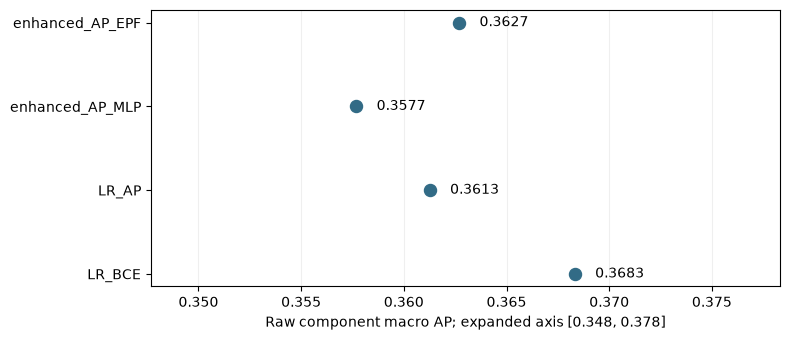

In [14]:
names=['enhanced_AP_EPF','enhanced_AP_MLP','LR_AP','LR_BCE']
values=[R['models'][k]['performance']['clean']['raw_components']['macro_ap'] for k in names]
lo=max(0,min(values)-.01);hi=min(1,max(values)+.01)
fig,ax=plt.subplots(figsize=(8,3.5))
ax.scatter(values,range(len(names)),s=75,color='#326b86')
ax.set_yticks(range(len(names)),names);ax.invert_yaxis();ax.set_xlim(lo,hi)
ax.set_xlabel(f'Raw component macro AP; expanded axis [{lo:.3f}, {hi:.3f}]')
ax.grid(axis='x',alpha=.2)
for i,v in enumerate(values):ax.text(v+.001,i,f'{v:.4f}',va='center')
fig.tight_layout();display(fig);plt.close(fig)

## 1차 paired AP 차이와 95% PSU 구간

한 번 뽑은 PSU 가중치를 모든 모델과 seed에 공통 적용한 고정 OOF 조건부 구간이다.

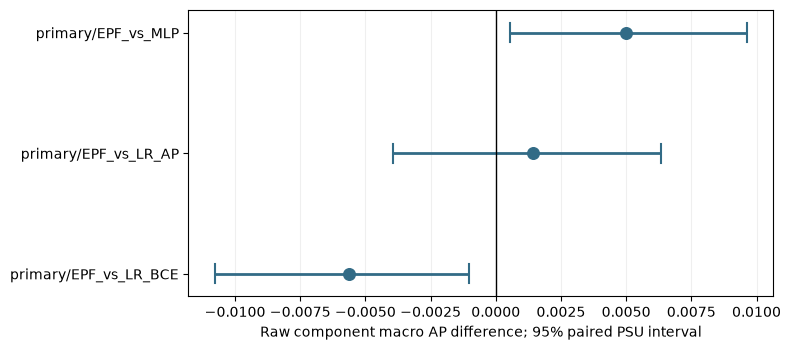

In [15]:
names=['primary/EPF_vs_MLP','primary/EPF_vs_LR_AP','primary/EPF_vs_LR_BCE']
rows=[(name,R['contrasts'][name]['metrics'][R['primary_metric']]) for name in names]
fig,ax=plt.subplots(figsize=(8,3.6))
for i,(name,metric) in enumerate(rows):
    low,high=metric['ci95']
    ax.hlines(i,low,high,color='#326b86',linewidth=2)
    ax.plot([low,low],[i-.08,i+.08],color='#326b86')
    ax.plot([high,high],[i-.08,i+.08],color='#326b86')
    ax.scatter([metric['estimate']],[i],color='#326b86',s=70,zorder=3)
ax.axvline(0,color='black',linewidth=1)
ax.set_yticks(range(len(names)),names);ax.invert_yaxis()
ax.set_xlabel('Raw component macro AP difference; 95% paired PSU interval')
ax.grid(axis='x',alpha=.2)
fig.tight_layout();display(fig);plt.close(fig)

PSU 구간은 재학습·선택 변동을 포함하지 않으며 다중 비교를 보정하지 않는다. 이 코호트는 v16–v20에서 이미 사용했다. 개인별 예측·역할 인덱스·원자료는 포함하지 않는다.